# **Mistral**

In [ ]:
!wget https://huggingface.co/TheBloke/Mistral-7B-Instruct-v0.2-GGUF/resolve/main/mistral-7b-instruct-v0.2.Q4_K_M.gguf

In [ ]:
!pip install llama-cpp-python sentence-transformers chromadb pandas numpy faiss-cpu

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
from llama_cpp import Llama
import re
import json
from typing import List, Dict, Tuple
import os
from datetime import datetime

class RAGSystem:
    def __init__(self, model_path: str, embedding_model: str = "all-MiniLM-L6-v2"):
        print("Loading embedding model...")
        self.embedding_model = SentenceTransformer(embedding_model)

        print("Loading GGUF model...")
        self.llm = Llama(
            model_path=model_path,
            n_ctx=4096,
            n_threads=4,
            n_gpu_layers=0,
            verbose=False
        )

        self.chroma_client = chromadb.Client(Settings(anonymized_telemetry=False))
        self.collection = None

        self.segments_df = None
        self.documents_df = None

    def load_csv_data(self, segments_path: str, documents_path: str):
        print("Loading CSV data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)

        print(f"Loaded {len(self.segments_df)} segments and {len(self.documents_df)} documents")

    def create_document_chunks(self) -> List[Dict]:
        chunks = []

        for idx, row in self.segments_df.iterrows():
            chunk = {
                'id': f"segment_{row['Document ID']}_{row['Segment position']}",
                'type': 'segment',
                'document_id': row['Document ID'],
                'segment_position': row['Segment position'],
                'text': str(row['Text']),
                'summary': str(row['Summary']) if pd.notna(row['Summary']) else "",
                'tags': str(row['Tags']) if pd.notna(row['Tags']) else "",
                'metadata': {
                    'non_operative': row.get('Non-operative', False),
                    'not_ai_related': row.get('Not AI-related', False),
                    'segment_annotated': row.get('Segment annotated', False),
                    'segment_validated': row.get('Segment validated', False)
                }
            }
            chunks.append(chunk)

        for idx, row in self.documents_df.iterrows():
            chunk = {
                'id': f"document_{row['AGORA ID']}",
                'type': 'document',
                'agora_id': row['AGORA ID'],
                'official_name': str(row['Official name']),
                'casual_name': str(row['Casual name']) if pd.notna(row['Casual name']) else "",
                'text': f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}",
                'short_summary': str(row['Short summary']) if pd.notna(row['Short summary']) else "",
                'long_summary': str(row['Long summary']) if pd.notna(row['Long summary']) else "",
                'authority': str(row['Authority']) if pd.notna(row['Authority']) else "",
                'link': str(row['Link to document']) if pd.notna(row['Link to document']) else "",
                'tags': str(row['Tags']) if pd.notna(row['Tags']) else "",
                'metadata': {
                    'collections': row.get('Collections', ''),
                    'most_recent_activity': row.get('Most recent activity', ''),
                    'most_recent_activity_date': row.get('Most recent activity date', ''),
                    'proposed_date': row.get('Proposed date', ''),
                    'primarily_government': row.get('Primarily applies to the government', False),
                    'primarily_private': row.get('Primarily applies to the private sector', False)
                }
            }
            chunks.append(chunk)

        return chunks

    def create_vector_database(self, batch_size: int = 1000):
        print("Creating document chunks...")
        chunks = self.create_document_chunks()

        try:
            self.chroma_client.delete_collection("agora_documents")
        except:
            pass

        self.collection = self.chroma_client.create_collection("agora_documents")

        print("Generating embeddings...")
        texts = [chunk['text'] for chunk in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        ids = [chunk['id'] for chunk in chunks]
        metadatas = [{'type': chunk['type'], **chunk['metadata']} for chunk in chunks]

        print(f"Adding {len(chunks)} chunks to vector database in batches of {batch_size}...")
        total_batches = (len(chunks) + batch_size - 1) // batch_size

        for i in range(0, len(chunks), batch_size):
            end_idx = min(i + batch_size, len(chunks))
            current_batch = i // batch_size + 1

            print(f"Processing batch {current_batch}/{total_batches} ({end_idx - i} items)")

            batch_embeddings = embeddings[i:end_idx].tolist()
            batch_texts = texts[i:end_idx]
            batch_ids = ids[i:end_idx]
            batch_metadatas = metadatas[i:end_idx]

            self.collection.add(
                embeddings=batch_embeddings,
                documents=batch_texts,
                metadatas=batch_metadatas,
                ids=batch_ids
            )

        print(f"Successfully added {len(chunks)} chunks to vector database")

    def retrieve_relevant_chunks(self, query: str, n_results: int = 5) -> List[Dict]:
        if not self.collection:
            raise ValueError("Vector database not initialized. Call create_vector_database() first.")

        query_embedding = self.embedding_model.encode([query])

        results = self.collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        relevant_chunks = []
        for i in range(len(results['ids'][0])):
            chunk = {
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'distance': results['distances'][0][i] if 'distances' in results else 0
            }
            relevant_chunks.append(chunk)

        return relevant_chunks

    def generate_answer(self, query: str, context_chunks: List[Dict]) -> str:
        context = "\n\n".join([
            f"Document ID: {chunk['id']}\nContent: {chunk['text']}"
            for chunk in context_chunks
        ])

        prompt = f"""Based on the following context from the AGORA dataset, please answer the question. Provide specific references and citations where possible. Don't include any unwanted links in the references.

Context:
{context}

Question: {query}

Please provide a comprehensive answer with:
1. Direct answer to the question
2. Relevant citations and references
3. Document IDs and sources where information was found

Answer:"""

        response = self.llm(
            prompt,
            max_tokens=1024,
            temperature=0.1,
            top_p=0.95,
            stop=["Question:", "Context:"],
            echo=False
        )

        return response['choices'][0]['text'].strip()

    def query(self, question: str, n_results: int = 5) -> Dict:
        print(f"Processing query: {question}")

        relevant_chunks = self.retrieve_relevant_chunks(question, n_results)

        answer = self.generate_answer(question, relevant_chunks)

        response = {
            'question': question,
            'answer': answer,
            'sources': [
                {
                    'id': chunk['id'],
                    'text': chunk['text'][:200] + "..." if len(chunk['text']) > 200 else chunk['text'],
                    'metadata': chunk['metadata'],
                    'relevance_score': 1 - chunk['distance']
                }
                for chunk in relevant_chunks
            ],
            'timestamp': datetime.now().isoformat()
        }

        return response

    def get_document_details(self, document_id: str) -> Dict:
        if self.documents_df is not None:
            doc_info = self.documents_df[self.documents_df['AGORA ID'] == int(document_id)]
            if not doc_info.empty:
                return doc_info.iloc[0].to_dict()
        return {}

def setup_rag_system():
    """Setup function for the RAG system"""
    return """

model_path = "/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf"
rag = RAGSystem(model_path)

rag.load_csv_data("/content/segments.csv", "/content/documents.csv")

rag.create_vector_database()
"""

In [ ]:
rag = RAGSystem("/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf")
rag.load_csv_data("/content/segments.csv", "/content/documents.csv")
rag.create_vector_database()

Loading embedding model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Loading GGUF model...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
llama_kv_cache_unified: LLAMA_SET_ROWS=0, using old ggml_cpy() method for backwards compatibility


Loading CSV data...
Loaded 7578 segments and 910 documents
Creating document chunks...
Generating embeddings...


Batches:   0%|          | 0/266 [00:00<?, ?it/s]

Adding 8488 chunks to vector database in batches of 1000...
Processing batch 1/9 (1000 items)
Processing batch 2/9 (1000 items)
Processing batch 3/9 (1000 items)
Processing batch 4/9 (1000 items)
Processing batch 5/9 (1000 items)
Processing batch 6/9 (1000 items)
Processing batch 7/9 (1000 items)
Processing batch 8/9 (1000 items)
Processing batch 9/9 (488 items)
Successfully added 8488 chunks to vector database


In [ ]:
response = rag.query("When is the EU AI law passed?")
print(response['answer'])

Processing query: When is the EU AI law passed?
1. The EU AI law, officially known as Regulation (EU) 2024/1689, was passed on 13 June 2024.

2. Relevant citations and references:
- The regulation text is mentioned in the context of the document: "Regulation (EU) 2024/1689 of the European Parliament and of the Council of 13 June 2024" (Document ID: segment_757_1).
- The regulation is also cited in the context of amendments to Directive (EU) 2020/1828: "Regulation (EU) 2024/1689 of the European Parliament and of the Council" (Document ID: segment_757_216, segment_757_213).

3. Document IDs and sources:
- The information about the EU AI law was found in the AGORA dataset, specifically in the document ID: segment_757_1.
- The document IDs segment_757_216 and segment_757_213 were used to provide additional context about the amendments to existing regulations related to the EU AI law.
- The Commission Decision Establishing the European AI Office document (Document ID: document_1074) was use

In [ ]:
response = rag.query("Which agency issued the 2023 U.S. Executive Order on AI?")
print(response['answer'])

Processing query: Which agency issued the 2023 U.S. Executive Order on AI?
1. President Biden issued the 2023 U.S. Executive Order on AI.
2. Relevant citations and references:
   - "Executive Summary: Artificial intelligence (AI) is one of the most consequential technologies of our time. President Biden and Vice President Harris have been clear that the Federal Government must mitigate the risks of AI so that the nation can harness its benefits." (Document ID: segment_1033_1)
   - "In October 2023, President Biden signed Executive Order 14110, which directed Federal agencies to take broad and cohesive action to promote the safe, secure, and trustworthy development and use of AI." (Document ID: segment_1033_1)
3. Document IDs and sources:
   - Document ID: segment_1033_1
   -


In [ ]:
response = rag.query("What country’s AI strategy includes a “human-centered” pillar and was published in 2021?")
print(response['answer'])

Processing query: What country’s AI strategy includes a “human-centered” pillar and was published in 2021?
1. China's AI strategy includes a "human-centered" pillar and was published in 2021.
2. Relevant citations and references:
   - China's Position Paper of the Peoples' Republic of China on Regulating Military Applications of Artificial Intelligence (AI) calls for observing national or regional ethical norms for AI and upholding the principles of extensive consultation, joint contribution, and shared benefits for international AI ethical governance (Document ID: segment_1129_1).
   - China advocates a people-centered approach and the principle of AI for good, emphasizing the importance of enhancing the understanding of all countries on AI ethics and ensuring that AI is safe, reliable, controllable, and capable of better empowering global sustainable development and enhancing the common well-being of all mankind (Document ID: segment_1144_1).

3. Document IDs and sources:
   - Docume

# **B Questions**

In [ ]:
response = rag.query("Compare “high-risk AI” in the EU AI Act and Brazil’s draft AI bill?")
print(response['answer'])

Processing query: Compare “high-risk AI” in the EU AI Act and Brazil’s draft AI bill?
The EU AI Act and Brazil's draft AI bill both address "high-risk AI," but there are differences in their definitions and regulatory approaches.

1. Direct answer to the question:

In the EU AI Act, "high-risk AI systems" are defined as AI systems that impact human rights and/or safety, which may be more likely in sectors such as healthcare, law enforcement and justice, and provision of public benefits (Document ID: segment_1115_2). The EU AI Act imposes specific requirements on providers of high-risk AI systems, including the need to document their assessment, affix a declaration of conformity, and comply with accessibility requirements, among others (Document ID: segment_757_44, 757_22).

In contrast, Brazil's draft AI bill does not explicitly define "high-risk AI" but focuses on AI systems that may pose a risk to public safety, privacy, or fundamental rights (Document ID: segment_1803_13). The draft

In [ ]:
response = rag.query("List three documents in AGORA that address facial recognition.")
print(response['answer'])

Processing query: List three documents in AGORA that address facial recognition.
1. Direct answer to the question: Three documents in AGORA that address facial recognition are: segment_637_11, segment_2244_2, and segment_637_14.

2. Relevant citations and references:
   - The first document, segment_637_11, outlines the notice requirement for law enforcement agencies using facial recognition to identify individuals. It includes provisions for providing notice to individuals of the name of the law enforcement agency and the database used, as well as a copy of the order authorizing the use of facial recognition, accuracy or bias reports, probe images, modifications made to the probe image, the candidate list produced by the facial recognition system, and any other police documentation related to the use of facial recognition in the law enforcement investigation. (a)(1) and (2)
   - The second document, segment_2244_2, requires personal information processors to inform individuals truthfu

Hallucination in generation : Wrong links attached above -> not required

In [ ]:
response = rag.query("How does the NIST AI RMF define “governance”?")
print(response['answer'])

Processing query: How does the NIST AI RMF define “governance”?
The NIST AI RMF defines "governance" as the function that establishes and enforces the overarching policies, roles, and responsibilities for managing AI risks within an organization. It sets the tone for risk management within an organization, determines the mission, goals, values, culture, and risk tolerance, and aligns the technical aspects of AI risk management to policies and operations.

According to the NIST AI RMF Playbook, the GOVERN function includes the following categories and subcategories:

1. Organization: Establishing the organizational structure, roles, and responsibilities for managing AI risks.
2. Risk Governance: Defining the governance structure, including the roles and responsibilities of key stakeholders, and establishing the decision-making processes for managing AI risks.
3. Compliance: Ensuring that the organization complies with applicable laws, regulations, and policies related to AI risk managem

# **C Questions**

In [ ]:
response = rag.query("What global trends exist in AI audit requirements?")
print(response['answer'])

Processing query: What global trends exist in AI audit requirements?
1. Global trends in AI audit requirements include the need for scalable auditing techniques, creating new types of qualitative analysis tools, training enough people to carry out audits, receiving feedback from humans in the loop, and building institutional capacity in government and industry to undertake, oversee, and respond to audits. (Document ID: segment_1112_39)
2. Governments and regulatory bodies are mandating audits of AI systems to evaluate their efforts to develop, acquire, adopt, and maintain AI capabilities, assess the implementation of relevant legislation, and monitor risks arising from AI. (Document ID: segment_10_2, segment_1109_2, segment_1921_3)
3. Organizations are expected to ensure that AI systems are designed and implemented to withstand adversarial AI attacks, unexpected inputs, and AI system failure, and document and create an audit trail for the operation and lifecycle management of models, d

In [ ]:
response = rag.query("Which documents support participatory or stakeholder governance in AI policy?")
print(response['answer'])

Processing query: Which documents support participatory or stakeholder governance in AI policy?
1. The documents "segment_906_9", "segment_1396_8", and "document_1396" support participatory or stakeholder governance in AI policy.

2. In "segment_906_9", the Administrator of General Services is instructed to maintain a public online interface for centrally cataloging agency AI governance charters, which shall be known as the ‘Federal AI System Inventory'. Agencies are required to submit AI governance charters for publication on the interface, and provide a clear process and mechanism for timely revisions and updates (1). This document emphasizes the importance of transparency and public access to AI governance information.

In "segment_1396_8", the Digital Policy Committee is instructed to provide a forum for exchanging information on AI policy and activities, and to foster multi-stakeholder and interdisciplinary dialogue to promote trust in and adoption of AI (c). This document highlig

The above soruces link : hallucination -> need to explicitly ask it not to include any unnecessary links as part of generation

In [ ]:
response = rag.query("How has “AI system” been defined across major frameworks over time?")
print(response['answer'])

Processing query: How has “AI system” been defined across major frameworks over time?
The term "AI system" has been defined consistently across major frameworks as a machine-based system that uses AI technology to generate outputs, including content, decisions, predictions, or recommendations, that can influence physical or virtual environments. However, the level of autonomy and adaptiveness of the AI system may vary.

1. Direct answer to the question:
The definitions of "AI system" provided in the context include:
- A machine-based system that infers, from the input it receives, how to generate outputs that can influence physical or virtual environments (Document ID: segment_1379_3, segment_1403_2).
- A machine-based system that makes predictions, recommendations, or decisions influencing real or virtual environments using machine- and human-based inputs and analysis (Document ID: segment_2047_1).
- An information system that operates in whole or in part using AI technology (Document

In [ ]:
response = rag.query("Compare enforcement mechanisms for high-risk AI regulation in three jurisdictions.")
print(response['answer'])

Processing query: Compare enforcement mechanisms for high-risk AI regulation in three jurisdictions.
1. Direct answer to the question:

The three jurisdictions discussed in the context - the European Union (through the Artificial Intelligence (Regulation) Act 2024), Massachusetts (through Massachusetts HD 396), and the unspecified relevant industries or fields (through the Framework to Advance AI Governance and Risk Management in National Security) - all have enforcement mechanisms in place for high-risk AI regulation.

The European Union's Artificial Intelligence (Regulation) Act 2024 establishes the AI Authority, which mandates businesses to comply with regulations, imposes fines for non-compliance, and requires parliamentary approval (document_1109). The AI Authority is also responsible for adhering to principles ensuring AI safety, transparency, fairness, accountability, compliance with laws, and inclusivity (document_1109).

Massachusetts HD 396 grants the Attorney General the aut

In [ ]:
response = rag.query("What governance approaches exist for foundation models in the EU and U.S.?")
print(response['answer'])

Processing query: What governance approaches exist for foundation models in the EU and U.S.?
1. Direct answer to the question:

In the EU, the European Commission encourages member states and invites multi-stakeholders to develop and support regulatory and governance approaches and frameworks for safe, secure, and trustworthy artificial intelligence systems. This includes partnership and cooperation between governments and multi-stakeholders to create an enabling ecosystem for innovation, entrepreneurship, and the dissemination of knowledge and technologies on mutually agreed terms (Document ID: segment_1381_2).

In the U.S., the Department of Commerce is soliciting input from the private sector, academia, civil society, and other stakeholders on potential risks, benefits, and appropriate policy and regulatory approaches related to dual-use foundation models with widely available model weights. This includes risks associated with actors fine-tuning or removing safeguards from these mod

Didn't explicitly mention EU AI act more general -> just an obersvation

# **D Questions**

In [ ]:
response = rag.query("What year was Japan’s national AI strategy published?")
print(response['answer'])

Processing query: What year was Japan’s national AI strategy published?
1. Japan's National AI Strategy 2.0 was published in 2022.
2. Relevant citations and references:
   - Document ID: segment_1099_1, "NATIONAL AI STRATEGY 2.0"
3. Document Sources:
   - AGORA dataset, "Singapore's National Artificial Intelligence Strategy 2.0" (<https://agora.ai/document/1099>)


Above answer is hallucinated, got the year right, pulled wrong text document for citing

In [ ]:
response = rag.query("Which AGORA documents are tagged with the “healthcare” policy sector?")
print(response['answer'])

Processing query: Which AGORA documents are tagged with the “healthcare” policy sector?
1. The documents tagged with the "healthcare" policy sector in the AGORA dataset are: segment_617_2, segment_1376_27, segment_1972_4, segment_1680_7, and segment_2125_7.

2. Relevant citations and references:
The context provided in the question itself mentions the "Strengthening Consumer Protections and Medical Debt Transparency Act" (Document ID: segment_617_2), which is related to healthcare. Additionally, the documents tagged with the "healthcare" policy sector in the AGORA dataset discuss various aspects of healthcare, such as the use of artificial intelligence in healthcare (Document ID: segment_1376_27, segment_1972_4, and segment_1680_7), and regulations related to insurance and consumer data in healthcare (Document ID: segment_2125_7).

3. Document IDs and sources:
- Document ID: segment_617_2: "This Act may be cited as the “Strengthening Consumer Protections and Medical Debt Transparency A

In [ ]:
response = rag.query("What risk categories are used in the EU AI Act vs. Canada’s AIA?")
print(response['answer'])

Processing query: What risk categories are used in the EU AI Act vs. Canada’s AIA?
The EU AI Act and Canada's AIA (Artificial Intelligence and Data Act) both employ risk-based approaches to regulate AI systems. However, they differ in the specific risk categories they address.

1. EU AI Act:
The EU AI Act focuses on systemic risks at the Union level, including their sources. It requires providers of general-purpose AI models to participate in the drawing-up of codes of practice to address these risks. The codes of practice should cover at least the obligations provided for in Articles 53 and 55, including keeping information up to date, providing adequate levels of detail for training summaries, and managing systemic risks at the Union level (Article 56).

Reference:
Document ID: segment_757_114
Content: Article 56: Codes of practice

2. Canada's AIA:
Canada's AIA targets high-impact AI systems and mandates businesses to identify, assess, and mitigate risks associated with these system

In [ ]:
response = rag.query("List international soft law instruments that address facial recognition.")
print(response['answer'])

Processing query: List international soft law instruments that address facial recognition.
1. Direct answer to the question:
There are several international soft law instruments that address facial recognition, including the following:

a. The European Union's General Data Protection Regulation (GDPR)
b. The Council of Europe's Convention on Human Rights and Biomedicine
c. The Organization for Economic Cooperation and Development (OECD) Guidelines on the Protection of Children's Personal Data
d. The International Association of Privacy Professionals (IAPP) Data Protection Intensive: Facial Recognition

2. Relevant citations and references:

a. European Union's General Data Protection Regulation (GDPR): Article 5, paragraph 1, letter e, states that personal data must be processed in a manner that ensures appropriate security of the personal data, including protection against unauthorized or unlawful processing and against accidental loss, destruction or damage. Article 13 and 14 require

In [ ]:
response = rag.query("Which Latin American AI policy documents mention impact assessments?")
print(response['answer'])

Processing query: Which Latin American AI policy documents mention impact assessments?
1. The AGORA dataset includes several Latin American AI policy documents that mention impact assessments. Specifically, the documents from Microsoft's Accountability Goals for AI systems (Document ID: segment_771_2) outline the requirement for completing an Impact Assessment early in the system's development. The OAS Recommendation on Artificial Intelligence (Document ID: segment_1396_8) invites organizations to take account of and adhere to this recommendation, which includes the implementation of impact assessments. The US AI Action Plan (Document ID: segment_2062_5) mentions the need for risk-based assessments for AI tools and continuous monitoring to ensure they reflect the state's adopted values. Lastly, the AI Framework for US Federal Agencies (Document ID: segment_1387_8) requires covered agencies to complete an AI risk and impact assessment before using new or existing high-impact AI.

2. Rel

# **Llama 8B**

In [ ]:
!wget https://huggingface.co/QuantFactory/Meta-Llama-3-8B-Instruct-GGUF/resolve/main/Meta-Llama-3-8B-Instruct.Q4_K_M.gguf

In [ ]:
!pip install llama-cpp-python sentence-transformers chromadb pandas numpy faiss-cpu

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
from llama_cpp import Llama
import re
import json
from typing import List, Dict, Tuple
import os
from datetime import datetime

class RAGSystem:
    def __init__(self, model_path: str, embedding_model: str = "all-MiniLM-L6-v2"):
        print("Loading embedding model...")
        self.embedding_model = SentenceTransformer(embedding_model)

        print("Loading GGUF model...")
        self.llm = Llama(
            model_path=model_path,
            n_ctx=4096,
            n_threads=4,
            n_gpu_layers=0,
            verbose=False
        )

        self.chroma_client = chromadb.Client(Settings(anonymized_telemetry=False))
        self.collection = None

        self.segments_df = None
        self.documents_df = None

    def load_csv_data(self, segments_path: str, documents_path: str):
        print("Loading CSV data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)

        print(f"Loaded {len(self.segments_df)} segments and {len(self.documents_df)} documents")

    def create_document_chunks(self) -> List[Dict]:
        chunks = []

        for idx, row in self.segments_df.iterrows():
            chunk = {
                'id': f"segment_{row['Document ID']}_{row['Segment position']}",
                'type': 'segment',
                'document_id': row['Document ID'],
                'segment_position': row['Segment position'],
                'text': str(row['Text']),
                'summary': str(row['Summary']) if pd.notna(row['Summary']) else "",
                'tags': str(row['Tags']) if pd.notna(row['Tags']) else "",
                'metadata': {
                    'non_operative': row.get('Non-operative', False),
                    'not_ai_related': row.get('Not AI-related', False),
                    'segment_annotated': row.get('Segment annotated', False),
                    'segment_validated': row.get('Segment validated', False)
                }
            }
            chunks.append(chunk)

        for idx, row in self.documents_df.iterrows():
            chunk = {
                'id': f"document_{row['AGORA ID']}",
                'type': 'document',
                'agora_id': row['AGORA ID'],
                'official_name': str(row['Official name']),
                'casual_name': str(row['Casual name']) if pd.notna(row['Casual name']) else "",
                'text': f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}",
                'short_summary': str(row['Short summary']) if pd.notna(row['Short summary']) else "",
                'long_summary': str(row['Long summary']) if pd.notna(row['Long summary']) else "",
                'authority': str(row['Authority']) if pd.notna(row['Authority']) else "",
                'link': str(row['Link to document']) if pd.notna(row['Link to document']) else "",
                'tags': str(row['Tags']) if pd.notna(row['Tags']) else "",
                'metadata': {
                    'collections': row.get('Collections', ''),
                    'most_recent_activity': row.get('Most recent activity', ''),
                    'most_recent_activity_date': row.get('Most recent activity date', ''),
                    'proposed_date': row.get('Proposed date', ''),
                    'primarily_government': row.get('Primarily applies to the government', False),
                    'primarily_private': row.get('Primarily applies to the private sector', False)
                }
            }
            chunks.append(chunk)

        return chunks

    def create_vector_database(self, batch_size: int = 1000):
        print("Creating document chunks...")
        chunks = self.create_document_chunks()

        try:
            self.chroma_client.delete_collection("agora_documents")
        except:
            pass

        self.collection = self.chroma_client.create_collection("agora_documents")

        print("Generating embeddings...")
        texts = [chunk['text'] for chunk in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        ids = [chunk['id'] for chunk in chunks]
        metadatas = [{'type': chunk['type'], **chunk['metadata']} for chunk in chunks]

        print(f"Adding {len(chunks)} chunks to vector database in batches of {batch_size}...")
        total_batches = (len(chunks) + batch_size - 1) // batch_size

        for i in range(0, len(chunks), batch_size):
            end_idx = min(i + batch_size, len(chunks))
            current_batch = i // batch_size + 1

            print(f"Processing batch {current_batch}/{total_batches} ({end_idx - i} items)")

            batch_embeddings = embeddings[i:end_idx].tolist()
            batch_texts = texts[i:end_idx]
            batch_ids = ids[i:end_idx]
            batch_metadatas = metadatas[i:end_idx]

            self.collection.add(
                embeddings=batch_embeddings,
                documents=batch_texts,
                metadatas=batch_metadatas,
                ids=batch_ids
            )

        print(f"Successfully added {len(chunks)} chunks to vector database")

    def retrieve_relevant_chunks(self, query: str, n_results: int = 5) -> List[Dict]:
        if not self.collection:
            raise ValueError("Vector database not initialized. Call create_vector_database() first.")

        query_embedding = self.embedding_model.encode([query])

        results = self.collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        relevant_chunks = []
        for i in range(len(results['ids'][0])):
            chunk = {
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'distance': results['distances'][0][i] if 'distances' in results else 0
            }
            relevant_chunks.append(chunk)

        return relevant_chunks

    def generate_answer(self, query: str, context_chunks: List[Dict]) -> str:
        context = "\n\n".join([
            f"Document ID: {chunk['id']}\nContent: {chunk['text']}"
            for chunk in context_chunks
        ])

        prompt = f"""Based on the following context from the AGORA dataset, please answer the question. Provide specific references and citations where possible. Don't include any unwanted links in the references.

Context:
{context}

Question: {query}

Please provide a comprehensive answer with:
1. Direct answer to the question
2. Relevant citations and references
3. Document IDs and sources where information was found

Answer:"""

        response = self.llm(
            prompt,
            max_tokens=1024,
            temperature=0.1,
            top_p=0.95,
            stop=["Question:", "Context:"],
            echo=False
        )

        return response['choices'][0]['text'].strip()

    def query(self, question: str, n_results: int = 5) -> Dict:
        print(f"Processing query: {question}")

        relevant_chunks = self.retrieve_relevant_chunks(question, n_results)

        answer = self.generate_answer(question, relevant_chunks)

        response = {
            'question': question,
            'answer': answer,
            'sources': [
                {
                    'id': chunk['id'],
                    'text': chunk['text'][:200] + "..." if len(chunk['text']) > 200 else chunk['text'],
                    'metadata': chunk['metadata'],
                    'relevance_score': 1 - chunk['distance']
                }
                for chunk in relevant_chunks
            ],
            'timestamp': datetime.now().isoformat()
        }

        return response

    def get_document_details(self, document_id: str) -> Dict:
        if self.documents_df is not None:
            doc_info = self.documents_df[self.documents_df['AGORA ID'] == int(document_id)]
            if not doc_info.empty:
                return doc_info.iloc[0].to_dict()
        return {}

def setup_rag_system():
    """Setup function for the RAG system"""
    return """

model_path = "/content/Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"
rag = RAGSystem(model_path)

rag.load_csv_data("/content/segments.csv", "/content/documents.csv")

rag.create_vector_database()
"""

In [ ]:
model_path = "/content/Meta-Llama-3-8B-Instruct.Q4_K_M.gguf"
rag = RAGSystem(model_path)

rag.load_csv_data("/content/segments.csv", "/content/documents.csv")

rag.create_vector_database()

llama_context: n_ctx_per_seq (4096) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


Loading CSV data...
Loaded 7578 segments and 910 documents
Creating document chunks...
Generating embeddings...


Batches:   0%|          | 0/266 [00:00<?, ?it/s]

Adding 8488 chunks to vector database in batches of 1000...
Processing batch 1/9 (1000 items)
Processing batch 2/9 (1000 items)
Processing batch 3/9 (1000 items)
Processing batch 4/9 (1000 items)
Processing batch 5/9 (1000 items)
Processing batch 6/9 (1000 items)
Processing batch 7/9 (1000 items)
Processing batch 8/9 (1000 items)
Processing batch 9/9 (488 items)
Successfully added 8488 chunks to vector database


# **A Questions**

In [ ]:
response = rag.query("When is the EU AI law passed?")
print(response['answer'])

Processing query: When is the EU AI law passed?
The EU AI law, Regulation (EU) 2024/1689, was passed on 13 June 2024. This is mentioned in Document ID: segment_757_1, Content: 2024/1689, and also in Document ID: segment_1074, Content: COMMISSION DECISION of 24.1.2024 establishing the European Artificial Intelligence Office.

1. Direct answer to the question: The EU AI law, Regulation (EU) 2024/1689, was passed on 13 June 2024.
2. Relevant citations and references:
- Document ID: segment_757_1, Content: 2024/1689
- Document ID: segment_1074, Content: COMMISSION DECISION of 24.1.2024 establishing the European Artificial Intelligence Office
3. Document IDs and sources where information was found:
- Document ID: segment_757_1
- Document ID: segment_757_216
- Document ID: segment_757_213
- Document ID: document_1074
- Document ID: segment_1074_1

Note: The EU AI law, Regulation (EU) 2024/1689, was passed on 13 June 2024, as mentioned in Document ID: segment_757_1, Content: 2024/1689, and al

In [ ]:
response = rag.query("Which agency issued the 2023 U.S. Executive Order on AI?")
print(response['answer'])

Processing query: Which agency issued the 2023 U.S. Executive Order on AI?
The agency that issued the 2023 U.S. Executive Order on AI is the Federal Government, specifically the President of the United States. 

1. The answer is based on the context provided, which mentions President Biden signing Executive Order 14110 in October 2023, directing Federal agencies to take broad and cohesive action to promote the safe, secure, and trustworthy development and use of AI.
2. Relevant citations and references:
   - Executive Order 14110 (October 2023)
   - National AI Talent Surge (launched in October 2023)
   - AI and Tech Talent Task Force (prioritized recruiting and attracting new technologists to public service)
3. Document IDs and sources where information was found:
   - Document ID: segment_1033_1 (Executive Summary)
   - Document ID: segment_2267_1 (OVERVIEW)
   - Document ID: document_1780 (Executive Order on Removing Barriers To American Leadership In Artificial Intelligence)
   - D

In [ ]:
response = rag.query("What country’s AI strategy includes a “human-centered” pillar and was published in 2021?")
print(response['answer'])

Processing query: What country’s AI strategy includes a “human-centered” pillar and was published in 2021?
Singapore's AI strategy includes a "human-centered" pillar and was published in 2021.

1. The answer is based on the content of Document ID: segment_1099_1, which is the National AI Strategy 2.0 of Singapore. The document mentions that Singapore will be a place where AI can "Address the needs and challenges of our time. For example, in areas of global importance such as population health and climate change" and "Be the great equaliser. We shall uplift and empower our people and businesses, equipping them with the capabilities and resources to thrive in an AI-enabled future." This suggests that Singapore's AI strategy is human-centered.

2. Relevant citations and references:
- National AI Strategy 2.0, Singapore (2021)
- Document ID: segment_1099_1, Content: National AI Strategy 2.0

3. Document IDs and sources where information was found:
- Document ID: segment_1099_1, Content: Na

# **B Questions**

In [ ]:
response = rag.query("Compare “high-risk AI” in the EU AI Act and Brazil’s draft AI bill?")
print(response['answer'])

Processing query: Compare “high-risk AI” in the EU AI Act and Brazil’s draft AI bill?
The concept of “high-risk AI” is not explicitly defined in Brazil’s draft AI bill. However, the EU AI Act defines high-risk AI systems as those that pose a significant risk of harm to the health, safety, or fundamental rights of natural persons.

1. Direct answer to the question: The EU AI Act defines high-risk AI systems, whereas Brazil’s draft AI bill does not explicitly define high-risk AI.
2. Relevant citations and references:
	* EU AI Act: Article 4(3) defines high-risk AI systems as those that pose a significant risk of harm to the health, safety, or fundamental rights of natural persons.
	* Brazil’s draft AI bill: Article 3 defines AI as a set of technologies that can be used in various sectors, but does not explicitly define high-risk AI.
3. Document IDs and sources where information was found:
	* EU AI Act: Document ID: segment_757_22
	* Brazil’s draft AI bill: Document ID: (not applicable, a

In [ ]:
response = rag.query("List three documents in AGORA that address facial recognition.")
print(response['answer'])

Processing query: List three documents in AGORA that address facial recognition.
The three documents in AGORA that address facial recognition are:

1. Document ID: segment_637_11 - This document discusses the notice requirement for facial recognition. According to this document, a law enforcement agency that uses facial recognition to attempt to identify an individual who is arrested shall, at minimum, provide to the individual a notice of the name of the law enforcement agency that operated the facial recognition system used, the name of the database, if any, that was used to identify the individual, and other relevant information.

Reference: (a) Notice Requirement.—A law enforcement agency that uses facial recognition to attempt to identify an individual who is arrested shall, at minimum, provide to the individual—

(1) a notice of—

(A) the name the law enforcement agency that operated the facial recognition system used; and

(B) the name of the database, if any, that was used to i

In [ ]:
response = rag.query("How does the NIST AI RMF define “governance”?")
print(response['answer'])

Processing query: How does the NIST AI RMF define “governance”?
The NIST AI RMF defines “governance” as the process of establishing and maintaining the overall direction, policies, and procedures for an organization's use of artificial intelligence. This includes setting the tone for risk management within an organization, determining the overarching policies that direct an organization's mission, goals, values, culture, and risk tolerance, and aligning the technical aspects of AI risk management to policies and operations.

1. Direct answer to the question: The NIST AI RMF defines “governance” as the process of establishing and maintaining the overall direction, policies, and procedures for an organization's use of artificial intelligence.
2. Relevant citations and references:
   - NIST AI RMF Playbook: This document provides practices related to governing AI risks and defines governance as the process of establishing and maintaining the overall direction, policies, and procedures for

# **C Questions**

In [ ]:
response = rag.query("What global trends exist in AI audit requirements?")
print(response['answer'])

Processing query: What global trends exist in AI audit requirements?
Based on the provided context, it is evident that there is a growing need for AI audit requirements globally. The following trends can be identified:

1. **Scalability of auditing**: As AI systems proliferate, there is a need for scalable auditing techniques to identify and mitigate risks (Document ID: segment_1112_39).
2. **Regulatory frameworks**: Governments and regulatory bodies are establishing frameworks to oversee AI development and deployment, such as the AI Authority (Document ID: segment_1109_2) and inspector general audits (Document ID: segment_10_2).
3. **Risk assessment and mitigation**: AI systems must be designed and implemented to withstand adversarial AI attacks, unexpected inputs, and AI system failure (Document ID: segment_1962_2).
4. **Data security and privacy**: Data custodians must ensure that the intended usage of the system is appropriate to the sensitivity of the data it was trained on, and c

In [ ]:
response = rag.query("Which documents support participatory or stakeholder governance in AI policy?")
print(response['answer'])

Processing query: Which documents support participatory or stakeholder governance in AI policy?
The documents that support participatory or stakeholder governance in AI policy are:

* Document ID: segment_396_5 (b) Stakeholder Consultation.--In carrying out the study required by subsection (a), the Assistant Secretary shall hold public meetings to consult with relevant stakeholders for the purpose of soliciting feedback on accountability measures for artificial intelligence systems.
* Document ID: segment_1396_8 (VIII. INSTRUCTS the Digital Policy Committee, through its Working Party on AI Governance, to: ... provide a forum for exchanging information on AI policy and activities including experience with the implementation of this Recommendation, and to foster multi-stakeholder and interdisciplinary dialogue to promote trust in and adoption of AI;)

These documents emphasize the importance of stakeholder engagement and participation in AI policy-making. The first document specifically 

In [ ]:
response = rag.query("How has “AI system” been defined across major frameworks over time?")
print(response['answer'])

Processing query: How has “AI system” been defined across major frameworks over time?
Across major frameworks over time, the definition of an "AI system" has evolved and been refined. Here is a comprehensive overview:

1. **Federal Government of the United States**: The term "AI system" is defined in Section 7223 of the Advancing American AI Act, which states that an AI system means "any data system, software, application, tool, or utility that operates in whole or in part using dynamic or static machine learning algorithms or other forms of artificial intelligence." (Document ID: segment_2267_20)
2. **United Nations Convention on the Use of Artificial Intelligence**: The term "artificial intelligence system" is defined as "a machine-based system that, for explicit or implicit objectives, infers, from the input it receives, how to generate outputs such as predictions, content, recommendations or decisions that may influence physical or virtual environments." (Document ID: segment_1379_

In [ ]:
response = rag.query("Compare enforcement mechanisms for high-risk AI regulation in three jurisdictions.")
print(response['answer'])

Processing query: Compare enforcement mechanisms for high-risk AI regulation in three jurisdictions.
The enforcement mechanisms for high-risk AI regulation in three jurisdictions, namely the Artificial Intelligence (Regulation) Act 2024, Massachusetts HD 396 (2025-2026), and the Framework to Advance AI Governance and Risk Management in National Security, differ in their approaches and scope. 

1. Artificial Intelligence (Regulation) Act 2024:
The Act establishes the AI Authority to oversee AI regulation, ensure safety, fairness, transparency, and compliance while supporting innovation, public engagement, and regulatory alignment across sectors. Businesses must disclose training data, ensure ethical AI use, allow independent audits, and comply with regulations, which may impose fines and require parliamentary approval. The AI Authority is mandated to adhere to principles ensuring AI safety, transparency, fairness, accountability, compliance with laws, and inclusivity. (Document ID: docu

In [ ]:
response = rag.query("What governance approaches exist for foundation models in the EU and U.S.?")
print(response['answer'])

Processing query: What governance approaches exist for foundation models in the EU and U.S.?
The governance approaches for foundation models in the EU and U.S. are not explicitly mentioned in the provided documents. However, the documents do mention the importance of establishing regulatory and governance approaches and frameworks related to safe, secure, and trustworthy artificial intelligence systems.

In the EU, the European Union's Artificial Intelligence Act (AIA) proposes a regulatory framework for AI, including foundation models. The AIA aims to ensure that AI systems are developed and used in a way that is safe, transparent, and fair. The AIA also proposes to establish a European Artificial Intelligence Board to oversee the implementation of the AIA and to provide guidance on the development and use of AI systems.

In the U.S., there is no federal law specifically regulating foundation models. However, the National Science Foundation (NSF) has established a program to support r

# **D Questions**

In [ ]:
response = rag.query("What risk categories are used in the EU AI Act vs. Canada’s AIA?")
print(response['answer'])

Processing query: What risk categories are used in the EU AI Act vs. Canada’s AIA?
The EU AI Act and Canada's AIA do not explicitly mention specific risk categories. However, both frameworks emphasize the importance of a risk-based approach in regulating AI systems.

1. Direct answer to the question:
The EU AI Act and Canada's AIA do not explicitly mention specific risk categories. Instead, they focus on the importance of a risk-based approach in regulating AI systems.

2. Relevant citations and references:
The EU AI Act mentions the importance of a risk-based approach in Article 56, which states that codes of practice should cover at least the obligations provided for in Articles 53 and 55, including the identification of systemic risks at Union level (EU AI Act, Article 56).

Canada's AIA also emphasizes the importance of a risk-based approach, stating that the Minister of Innovation, Science, and Industry would be empowered to administer and enforce the Act, taking into account the 

In [ ]:
response = rag.query("List international soft law instruments that address facial recognition.")
print(response['answer'])

Processing query: List international soft law instruments that address facial recognition.
International soft law instruments that address facial recognition include:

1. Article 5 of the AGORA dataset (Document ID: segment_2244_2) - This article requires personal information processors to inform individuals of the purpose and method of processing facial information, and the retention period, before using facial recognition technology.

Reference: AGORA dataset, Document ID: segment_2244_2

2. The National Institute of Standards and Technology (NIST) Assistance (Document ID: segment_637_12) - This section requires NIST to develop best practices for law enforcement agencies to evaluate the accuracy and fairness of their facial recognition systems.

Reference: AGORA dataset, Document ID: segment_637_12

3. The Notice Requirement (Document ID: segment_637_11) - This section requires law enforcement agencies to provide notice to individuals of the use of facial recognition, including the n

In [ ]:
response = rag.query("Which Latin American AI policy documents mention impact assessments?")
print(response['answer'])

Processing query: Which Latin American AI policy documents mention impact assessments?
None of the Latin American AI policy documents mentioned in the provided context mention impact assessments. The documents provided are from international organizations and the United States, and do not specifically mention Latin American AI policy documents.

References:
1. Microsoft AI systems are assessed using Impact Assessments. (Document ID: segment_771_2)
2. The Digital Policy Committee is instructed to develop and iterate further practical guidance on the implementation of this Recommendation, including the development of a measurement framework for evidence-based AI policies. (Document ID: segment_1396_8)
3. The AI Subcabinet shall develop and implement a comprehensive action plan that takes a phased approach to operationalizing the State's AI principles, including the development of policies, processes, standards, contracts, and playbooks that ensure any AI tools procured by the State adher

# **Query Router + LLM + VLM + Trends Analyzer Implementation below :-**

# **Query Router based on keyword matching of user queries to route the query either directly to Mistral (for answering) or VLM or trends analyzer**

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
from llama_cpp import Llama
import re
import json
from typing import List, Dict, Tuple, Optional
import os
from datetime import datetime
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# QUERY ROUTER
# ============================================================================

class QueryRouter:
    """Routes queries to appropriate models based on intent"""

    def __init__(self):
        self.trend_keywords = [
            'trend', 'forecast', 'predict', 'future', 'growth', 'decline',
            'pattern', 'time series', 'historical', 'projection', 'estimate',
            'next', 'upcoming', 'increase', 'decrease', 'over time'
        ]

        self.vision_keywords = [
            'image', 'picture', 'photo', 'visual', 'chart', 'graph',
            'diagram', 'illustration', 'show me', 'what does', 'look like',
            'see', 'view', 'display', 'visualize'
        ]

    def route(self, query: str, has_image: bool = False) -> str:
        """
        Routes query to appropriate model
        """
        query_lower = query.lower()

        if has_image or any(keyword in query_lower for keyword in self.vision_keywords):
            return 'clip'

        if any(keyword in query_lower for keyword in self.trend_keywords):
            return 'lstm'

        return 'llm'

    def get_route_explanation(self, route: str) -> str:
        explanations = {
            'lstm': 'Routing to LSTM model for trend analysis',
            'clip': 'Routing to CLIP model for vision analysis',
            'llm': 'Routing to LLM for general question answering'
        }
        return explanations.get(route, 'Unknown route')

# ============================================================================
# LSTM MODEL FOR TREND ANALYSIS
# ============================================================================

class LSTMTrendAnalyzer:
    """LSTM model for time series trend analysis"""

    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.scaler = MinMaxScaler()
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def build_model(self):
        """Build LSTM model"""
        class LSTMModel(nn.Module):
            def __init__(self, input_size, hidden_size, num_layers, output_size):
                super(LSTMModel, self).__init__()
                self.hidden_size = hidden_size
                self.num_layers = num_layers
                self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
                self.fc = nn.Linear(hidden_size, output_size)

            def forward(self, x):
                h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
                c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
                out, _ = self.lstm(x, (h0, c0))
                out = self.fc(out[:, -1, :])
                return out

        self.model = LSTMModel(
            self.input_size,
            self.hidden_size,
            self.num_layers,
            self.output_size
        ).to(self.device)

        return self.model

    def prepare_sequences(self, data: np.ndarray, seq_length: int = 10):
        """Prepare sequences for LSTM"""
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i+seq_length])
            y.append(data[i+seq_length])
        return np.array(X), np.array(y)

    def analyze_trend(self, data: List[float], forecast_steps: int = 5) -> Dict:
        """
        Analyze trends and generate forecast
        Returns context for LLM
        """
        data_array = np.array(data).reshape(-1, 1)
        scaled_data = self.scaler.fit_transform(data_array)

        if len(data) < 2:
            return {
                'trend': 'insufficient_data',
                'direction': 'unknown',
                'forecast': [],
                'description': 'Insufficient data for trend analysis'
            }

        trend_direction = 'increasing' if data[-1] > data[0] else 'decreasing'
        avg_change = (data[-1] - data[0]) / len(data)

        forecast = []
        last_value = data[-1]
        for i in range(1, forecast_steps + 1):
            forecast.append(last_value + (avg_change * i))

        volatility = np.std(data)

        context = {
            'trend': 'analyzed',
            'direction': trend_direction,
            'current_value': float(data[-1]),
            'average_change': float(avg_change),
            'volatility': float(volatility),
            'forecast': [float(x) for x in forecast],
            'forecast_steps': forecast_steps,
            'description': f"Trend analysis shows {trend_direction} pattern with average change of {avg_change:.2f} per step. Volatility is {volatility:.2f}."
        }

        return context

# ============================================================================
# CLIP MODEL FOR VISION ANALYSIS
# ============================================================================

class CLIPVisionAnalyzer:
    """CLIP model for vision understanding"""

    def __init__(self):
        try:
            from transformers import CLIPProcessor, CLIPModel
            from PIL import Image

            print("Loading CLIP model...")
            self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
            self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.model.to(self.device)
            print(f"CLIP model loaded on {self.device}")
        except Exception as e:
            print(f"Error loading CLIP: {e}")
            print("Install with: !pip install transformers pillow")
            self.model = None
            self.processor = None

    def analyze_image(self, image_path: str, query: str = "") -> Dict:
        """
        Analyze image and return context for LLM
        """
        if self.model is None:
            return {
                'error': 'CLIP model not loaded',
                'description': 'Vision analysis unavailable'
            }

        try:
            from PIL import Image

            image = Image.open(image_path).convert('RGB')

            candidate_labels = [
                "a document", "a chart", "a graph", "a diagram",
                "a table", "text", "data visualization", "infographic",
                "regulatory document", "legal text", "policy document"
            ]

            if query:
                candidate_labels.insert(0, query)

            inputs = self.processor(
                text=candidate_labels,
                images=image,
                return_tensors="pt",
                padding=True
            ).to(self.device)

            outputs = self.model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)

            top_probs, top_indices = torch.topk(probs[0], k=min(3, len(candidate_labels)))

            predictions = [
                {
                    'label': candidate_labels[idx],
                    'confidence': float(prob)
                }
                for prob, idx in zip(top_probs, top_indices)
            ]

            top_pred = predictions[0]
            description = f"Image analysis: Detected '{top_pred['label']}' with {top_pred['confidence']:.2%} confidence."

            context = {
                'image_path': image_path,
                'predictions': predictions,
                'top_prediction': top_pred,
                'description': description,
                'image_size': image.size
            }

            return context

        except Exception as e:
            return {
                'error': str(e),
                'description': f'Error analyzing image: {str(e)}'
            }

# ============================================================================
# ENHANCED RAG SYSTEM WITH ROUTER
# ============================================================================

class EnhancedRAGSystem:
    """RAG System with multi-modal routing"""

    def __init__(self, model_path: str, embedding_model: str = "all-MiniLM-L6-v2"):
        print("Initializing Enhanced RAG System...")

        self.router = QueryRouter()

        print("Loading embedding model...")
        self.embedding_model = SentenceTransformer(embedding_model)

        print("Loading GGUF model...")
        self.llm = Llama(
            model_path=model_path,
            n_ctx=4096,
            n_threads=4,
            n_gpu_layers=0,
            verbose=False
        )

        self.chroma_client = chromadb.Client(Settings(anonymized_telemetry=False))
        self.collection = None

        print("Initializing LSTM analyzer...")
        self.lstm_analyzer = LSTMTrendAnalyzer()

        print("Initializing CLIP analyzer...")
        self.clip_analyzer = CLIPVisionAnalyzer()

        self.segments_df = None
        self.documents_df = None

        print("Enhanced RAG System initialized successfully!")

    def load_csv_data(self, segments_path: str, documents_path: str):
        """Load CSV data"""
        print("Loading CSV data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)
        print(f"Loaded {len(self.segments_df)} segments and {len(self.documents_df)} documents")

    def create_document_chunks(self) -> List[Dict]:
        """Create document chunks from CSV data"""
        chunks = []

        for idx, row in self.segments_df.iterrows():
            chunk = {
                'id': f"segment_{row['Document ID']}_{row['Segment position']}",
                'type': 'segment',
                'document_id': row['Document ID'],
                'segment_position': row['Segment position'],
                'text': str(row['Text']),
                'summary': str(row['Summary']) if pd.notna(row['Summary']) else "",
                'tags': str(row['Tags']) if pd.notna(row['Tags']) else "",
                'metadata': {
                    'non_operative': row.get('Non-operative', False),
                    'not_ai_related': row.get('Not AI-related', False),
                    'segment_annotated': row.get('Segment annotated', False),
                    'segment_validated': row.get('Segment validated', False)
                }
            }
            chunks.append(chunk)

        for idx, row in self.documents_df.iterrows():
            chunk = {
                'id': f"document_{row['AGORA ID']}",
                'type': 'document',
                'agora_id': row['AGORA ID'],
                'official_name': str(row['Official name']),
                'casual_name': str(row['Casual name']) if pd.notna(row['Casual name']) else "",
                'text': f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}",
                'short_summary': str(row['Short summary']) if pd.notna(row['Short summary']) else "",
                'long_summary': str(row['Long summary']) if pd.notna(row['Long summary']) else "",
                'authority': str(row['Authority']) if pd.notna(row['Authority']) else "",
                'link': str(row['Link to document']) if pd.notna(row['Link to document']) else "",
                'tags': str(row['Tags']) if pd.notna(row['Tags']) else "",
                'metadata': {
                    'collections': row.get('Collections', ''),
                    'most_recent_activity': row.get('Most recent activity', ''),
                    'most_recent_activity_date': row.get('Most recent activity date', ''),
                    'proposed_date': row.get('Proposed date', ''),
                    'primarily_government': row.get('Primarily applies to the government', False),
                    'primarily_private': row.get('Primarily applies to the private sector', False)
                }
            }
            chunks.append(chunk)

        return chunks

    def create_vector_database(self, batch_size: int = 1000):
        """Create vector database"""
        print("Creating document chunks...")
        chunks = self.create_document_chunks()

        try:
            self.chroma_client.delete_collection("agora_documents")
        except:
            pass

        self.collection = self.chroma_client.create_collection("agora_documents")

        print("Generating embeddings...")
        texts = [chunk['text'] for chunk in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        ids = [chunk['id'] for chunk in chunks]
        metadatas = [{'type': chunk['type'], **chunk['metadata']} for chunk in chunks]

        print(f"Adding {len(chunks)} chunks to vector database...")
        total_batches = (len(chunks) + batch_size - 1) // batch_size

        for i in range(0, len(chunks), batch_size):
            end_idx = min(i + batch_size, len(chunks))
            current_batch = i // batch_size + 1

            print(f"Processing batch {current_batch}/{total_batches}")

            batch_embeddings = embeddings[i:end_idx].tolist()
            batch_texts = texts[i:end_idx]
            batch_ids = ids[i:end_idx]
            batch_metadatas = metadatas[i:end_idx]

            self.collection.add(
                embeddings=batch_embeddings,
                documents=batch_texts,
                metadatas=batch_metadatas,
                ids=batch_ids
            )

        print(f"Successfully added {len(chunks)} chunks to vector database")

    def retrieve_relevant_chunks(self, query: str, n_results: int = 5) -> List[Dict]:
        """Retrieve relevant chunks from vector database"""
        if not self.collection:
            raise ValueError("Vector database not initialized")

        query_embedding = self.embedding_model.encode([query])

        results = self.collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        relevant_chunks = []
        for i in range(len(results['ids'][0])):
            chunk = {
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'distance': results['distances'][0][i] if 'distances' in results else 0
            }
            relevant_chunks.append(chunk)

        return relevant_chunks

    def generate_answer(self, query: str, rag_context: List[Dict],
                       specialized_context: Optional[Dict] = None) -> str:
        """Generate answer using LLM with RAG and specialized context"""

        rag_text = "\n\n".join([
            f"Document ID: {chunk['id']}\nContent: {chunk['text']}"
            for chunk in rag_context
        ])

        specialized_text = ""
        if specialized_context:
            if 'trend' in specialized_context:
                specialized_text = f"\n\nTrend Analysis:\n{specialized_context['description']}\nForecast: {specialized_context.get('forecast', [])}"
            elif 'predictions' in specialized_context:
                specialized_text = f"\n\nVision Analysis:\n{specialized_context['description']}"

        prompt = f"""Based on the following context, please answer the question comprehensively.

RAG Context from Documents:
{rag_text}
{specialized_text}

Question: {query}

Please provide a comprehensive answer with:
1. Direct answer to the question
2. Relevant citations and references
3. Source document IDs where information was found

Answer:"""

        response = self.llm(
            prompt,
            max_tokens=1024,
            temperature=0.1,
            top_p=0.95,
            stop=["Question:", "Context:"],
            echo=False
        )

        return response['choices'][0]['text'].strip()

    def query(self, question: str, n_results: int = 5,
             image_path: Optional[str] = None,
             trend_data: Optional[List[float]] = None) -> Dict:
        """
        Main query method with routing
        """
        print(f"\n{'='*60}")
        print(f"Processing query: {question}")

        has_image = image_path is not None
        route = self.router.route(question, has_image)
        print(f"Route: {self.router.get_route_explanation(route)}")

        print("Retrieving relevant documents...")
        rag_context = self.retrieve_relevant_chunks(question, n_results)

        specialized_context = None

        if route == 'lstm' and trend_data:
            print("Analyzing trends with LSTM...")
            specialized_context = self.lstm_analyzer.analyze_trend(trend_data)

        elif route == 'clip' and image_path:
            print("Analyzing image with CLIP...")
            specialized_context = self.clip_analyzer.analyze_image(image_path, question)

        print("Generating answer with LLM...")
        answer = self.generate_answer(question, rag_context, specialized_context)

        response = {
            'question': question,
            'route': route,
            'answer': answer,
            'specialized_context': specialized_context,
            'rag_sources': [
                {
                    'id': chunk['id'],
                    'text': chunk['text'][:200] + "..." if len(chunk['text']) > 200 else chunk['text'],
                    'metadata': chunk['metadata'],
                    'relevance_score': 1 - chunk['distance']
                }
                for chunk in rag_context
            ],
            'timestamp': datetime.now().isoformat()
        }

        print(f"{'='*60}\n")
        return response

def setup_enhanced_rag():
    """Setup the enhanced RAG system"""
    print("""
# Installation Requirements:
!pip install sentence-transformers chromadb llama-cpp-python torch scikit-learn transformers pillow

# Download Mistral Model:
!wget https://huggingface.co/TheBloke/Mistral-7B-Instruct-v0.2-GGUF/resolve/main/mistral-7b-instruct-v0.2.Q4_K_M.gguf

# Initialize System:
    """)

    return EnhancedRAGSystem("/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf")

In [ ]:
def example_usage():
    """Example usage patterns"""
    examples = """
# 1. Initialize System
rag = EnhancedRAGSystem("/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf")
rag.load_csv_data("/content/segments.csv", "/content/documents.csv")
rag.create_vector_database()

# 2. General LLM Query (Routes to LLM)
response = rag.query("What are the main AI regulations in the EU?")
print(response['answer'])

# 3. Trend Analysis Query (Routes to LSTM)
trend_data = [100, 105, 110, 108, 115, 120, 118, 125, 130, 128]
response = rag.query(
    "What is the trend in AI adoption?",
    trend_data=trend_data
)
print(response['answer'])
print("Forecast:", response['specialized_context']['forecast'])

# 4. Vision Query (Routes to CLIP)
response = rag.query(
    "What does this document contain?",
    image_path="/content/document_image.png"
)
print(response['answer'])
print("Vision Analysis:", response['specialized_context']['description'])

# 5. Access routing information
print(f"Query was routed to: {response['route']}")
print(f"RAG sources used: {len(response['rag_sources'])}")
    """
    return examples

In [ ]:
rag = EnhancedRAGSystem("/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf")
rag.load_csv_data("/content/segments.csv", "/content/documents.csv")
rag.create_vector_database()

**Query routed to LLM properly - router working properly**

In [ ]:
response = rag.query("What are the main AI regulations in the EU?")
print(response['answer'])


Processing query: What are the main AI regulations in the EU?
Route: Routing to LLM for general question answering
Retrieving relevant documents...
Generating answer with LLM...

The European Union (EU) has recently adopted several regulations and amendments to existing regulations to govern the development, deployment, and use of Artificial Intelligence (AI) systems. The two most significant AI regulations in the EU are Regulation (EU) 2018/1139 and Regulation (EU) 2024/1689.

1. Direct answer to the question:

Regulation (EU) 2018/1139, also known as the "Artificial Intelligence Act," is a regulation that amends several existing regulations to address the ethical and safety aspects of AI systems. It focuses on ensuring transparency, accountability, and safety of AI systems, particularly those with significant capability or used in risky contexts.

Regulation (EU) 2024/1689, also known as the "Artificial Intelligence Act," is a new regulation that lays down harmonized rules on AI and

# **Using only Vision Languge Model part of the workflow (Qwen VL + Keyword extraction + Retrieval of documents + Context sent to LLM + LLM final response). Also added web search capabilities - better answer on Section 227 generated below**

In [ ]:
!pip install torch torchvision transformers accelerate pillow beautifulsoup4 requests qwen-vl-utils

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from llama_cpp import Llama
from typing import List, Dict, Optional, Tuple
from datetime import datetime
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq
from PIL import Image
import warnings
import re
import requests
from bs4 import BeautifulSoup
warnings.filterwarnings('ignore')

# ============================================================================
# WEB SEARCH TOOL
# ============================================================================
class WebSearchTool:
    """Web search to supplement RAG when context is insufficient"""

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        })

    def search_section_info(self, section_number: str, act_name: str = None) -> Dict:
        """Search for additional information about a specific legal section"""
        print(f"Web searching for: {section_number} {act_name or ''}")

        try:
            if act_name:
                query = f'"{section_number}" "{act_name}" summary explanation'
            else:
                query = f'"{section_number}" legal act summary'

            search_url = f"https://html.duckduckgo.com/html/?q={requests.utils.quote(query)}"
            response = self.session.get(search_url, timeout=10)

            if response.status_code != 200:
                return {'status': 'error', 'message': 'Search failed'}

            soup = BeautifulSoup(response.text, 'html.parser')
            results = soup.find_all('div', class_='result')

            summaries = []
            for i, result in enumerate(results[:3]):
                title_elem = result.find('a', class_='result__a')
                snippet_elem = result.find('a', class_='result__snippet')

                if title_elem and snippet_elem:
                    summaries.append({
                        'title': title_elem.get_text(strip=True),
                        'snippet': snippet_elem.get_text(strip=True),
                        'url': title_elem.get('href', '')
                    })

            if summaries:
                print(f"Found {len(summaries)} web results")
                return {'status': 'success', 'query': query, 'results': summaries}
            else:
                return {'status': 'no_results', 'message': 'No results found'}

        except Exception as e:
            print(f"Web search error: {e}")
            return {'status': 'error', 'message': str(e)}

    def format_web_results(self, search_result: Dict) -> str:
        """Format web search results for LLM context"""
        if search_result['status'] != 'success':
            return ""

        formatted = "\n=== SUPPLEMENTARY WEB SEARCH RESULTS ===\n"
        for i, result in enumerate(search_result['results'], 1):
            formatted += f"\n[Web Result {i}] {result['title']}\n"
            formatted += f"{result['snippet']}\n"
            formatted += f"Source: {result['url']}\n"
        formatted += "=" * 60 + "\n"

        return formatted


# ============================================================================
# SECTION ANALYZER
# ============================================================================
class SectionAnalyzer:
    """Deep analysis of sections from retrieved documents"""

    @staticmethod
    def extract_all_sections(retrieved_chunks: List[Dict]) -> List[Dict]:
        """Extract all section mentions from retrieved documents"""
        sections_found = []

        for chunk in retrieved_chunks:
            text = chunk['text']

            patterns = [
                r'Section\s+(\d+[A-Za-z]?)',
                r'Sec\.\s+(\d+[A-Za-z]?)',
                r'§\s*(\d+[A-Za-z]?)',
                r'Article\s+(\d+[A-Za-z]?)'
            ]

            for pattern in patterns:
                matches = re.finditer(pattern, text, re.IGNORECASE)
                for match in matches:
                    section_num = match.group(1)

                    start = max(0, match.start() - 200)
                    end = min(len(text), match.end() + 200)
                    context = text[start:end].strip()

                    sections_found.append({
                        'section_number': section_num,
                        'full_match': match.group(0),
                        'context': context,
                        'source_relevance': chunk['relevance'],
                        'source_metadata': chunk['metadata']
                    })

        return sections_found

    @staticmethod
    def find_primary_section(sections: List[Dict], target_section: str) -> Optional[Dict]:
        """Find the specific section the user is asking about"""
        if not sections:
            return None

        target_num = re.search(r'\d+', target_section)
        if target_num:
            target_num = target_num.group(0)

            for section in sections:
                if section['section_number'] == target_num:
                    return section

        sections.sort(key=lambda x: x['source_relevance'], reverse=True)
        return sections[0]

    @staticmethod
    def build_comprehensive_context(primary_section: Dict, all_sections: List[Dict]) -> str:
        """Build comprehensive context about the section"""
        context_parts = []

        context_parts.append(f"PRIMARY SECTION IDENTIFIED: Section {primary_section['section_number']}\n")
        context_parts.append(f"Context from highest-relevance source:\n{primary_section['context']}\n")
        context_parts.append("=" * 60 + "\n")

        related = [s for s in all_sections if s['section_number'] != primary_section['section_number']]
        if related:
            context_parts.append("\nRELATED SECTIONS FOUND:\n")
            for sec in related[:3]:
                context_parts.append(f"Section {sec['section_number']}: {sec['context'][:150]}...\n")

        return "\n".join(context_parts)


# ============================================================================
# DIRECT TEXT SEARCH FALLBACK
# ============================================================================
class DirectTextSearcher:
    """Direct text search when vector search fails"""

    def __init__(self, segments_df, documents_df):
        self.segments_df = segments_df
        self.documents_df = documents_df

    def search_section_number(self, section_number: str, n_results: int = 10) -> List[Dict]:
        """Search for exact section number in raw text"""
        print(f"Direct text search for: {section_number}")

        num_match = re.search(r'\d+', section_number)
        if not num_match:
            return []

        section_num = num_match.group(0)

        patterns = [
            f"Section {section_num}",
            f"Sec. {section_num}",
            f"§ {section_num}",
            f"Section {section_num}",
        ]

        matches = []

        for _, row in self.segments_df.iterrows():
            text = str(row['Text'])
            for pattern in patterns:
                if pattern in text or pattern.lower() in text.lower():
                    matches.append({
                        'id': f"seg_{row['Document ID']}_{row['Segment position']}",
                        'text': text,
                        'metadata': {
                            'doc_id': int(row['Document ID']),
                            'position': int(row['Segment position']),
                            'type': 'segment'
                        },
                        'relevance': 0.9,
                        'distance': 0.1,
                        'match_type': 'direct_text'
                    })
                    break

        for _, row in self.documents_df.iterrows():
            text = f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}"
            for pattern in patterns:
                if pattern in text or pattern.lower() in text.lower():
                    matches.append({
                        'id': f"doc_{row['AGORA ID']}",
                        'text': text,
                        'metadata': {
                            'agora_id': int(row['AGORA ID']),
                            'name': str(row['Official name']),
                            'type': 'document'
                        },
                        'relevance': 0.85,
                        'distance': 0.15,
                        'match_type': 'direct_text'
                    })
                    break

        print(f"Found {len(matches)} direct text matches")

        return sorted(matches, key=lambda x: x['relevance'], reverse=True)[:n_results]


# ============================================================================
# RETRIEVAL ENGINE WITH DIRECT SEARCH
# ============================================================================
class EnhancedRetriever:
    """Multi-strategy retrieval with direct text search fallback"""

    def __init__(self, collection, embedding_model, segments_df, documents_df):
        self.collection = collection
        self.embedding_model = embedding_model
        self.direct_searcher = DirectTextSearcher(segments_df, documents_df)

    def retrieve_with_keywords(self, question: str, keywords: List[str], n_results: int = 10) -> Tuple[List[Dict], float, str]:
        """Try multiple retrieval strategies including direct text search"""
        print(f"Trying multiple retrieval strategies...")

        section_keywords = [k for k in keywords if 'section' in k.lower() or re.search(r'\d+', k)]
        direct_results = []

        if section_keywords:
            print(f"Attempting direct text search first...")
            for kw in section_keywords[:2]:
                direct_results.extend(self.direct_searcher.search_section_number(kw, n_results))

        if direct_results:
            confidence = sum(r['relevance'] for r in direct_results) / len(direct_results)
            print(f"Direct text search successful: {len(direct_results)} docs, confidence={confidence:.3f}")
            return direct_results, confidence, "direct_text_search"

        strategies = [
            ("exact_section_number", self._retrieve_exact_section),
            ("semantic_question", self._retrieve_semantic_question),
            ("keyword_combinations", self._retrieve_keyword_combinations),
            ("broad_semantic", self._retrieve_broad_semantic),
        ]

        best_chunks = []
        best_confidence = 0.0
        best_strategy = "none"

        for strategy_name, strategy_func in strategies:
            chunks, confidence = strategy_func(question, keywords, n_results)

            target_found = False
            if section_keywords and chunks:
                for kw in section_keywords:
                    num = re.search(r'\d+', kw)
                    if num:
                        num = num.group(0)
                        for chunk in chunks:
                            if f"Section {num}" in chunk['text'] or f"section {num}" in chunk['text'].lower():
                                target_found = True
                                break

            print(f"    • {strategy_name}: confidence={confidence:.3f}, docs={len(chunks)}, target_found={target_found}")

            if target_found:
                print(f"Target section found with {strategy_name}!")
                return chunks, confidence, strategy_name

            if len(chunks) > len(best_chunks) or (len(chunks) == len(best_chunks) and confidence > best_confidence):
                best_chunks = chunks
                best_confidence = confidence
                best_strategy = strategy_name

        print(f"Best strategy: {best_strategy} (confidence: {best_confidence:.3f}, docs: {len(best_chunks)})")
        return best_chunks, best_confidence, best_strategy

    def _retrieve_exact_section(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 1: Search for exact section number"""
        section_keywords = [k for k in keywords if re.search(r'\d+', k)]

        if section_keywords:
            for kw in section_keywords:
                num = re.search(r'\d+', kw)
                if num:
                    queries = [
                        f"Section {num.group(0)}",
                        f"{num.group(0)} section legal",
                        f"section {num.group(0)} provision"
                    ]

                    best_chunks = []
                    best_conf = 0.0

                    for query in queries:
                        chunks, conf = self._execute_query(query, n_results)
                        if conf > best_conf:
                            best_chunks = chunks
                            best_conf = conf

                    if best_chunks:
                        return best_chunks, best_conf

        return [], 0.0

    def _retrieve_semantic_question(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 2: Pure semantic search on the question"""
        return self._execute_query(question, n_results)

    def _retrieve_keyword_combinations(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 3: Combine important keywords"""
        important_keywords = []

        for kw in keywords[:8]:
            if len(kw) > 3 and kw.lower() not in ['the', 'and', 'this', 'that']:
                important_keywords.append(kw)

        if important_keywords:
            query = " ".join(important_keywords[:5])
            return self._execute_query(query, n_results)

        return [], 0.0

    def _retrieve_broad_semantic(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 4: Broad search"""
        query = f"{question} {' '.join(keywords[:3])}"
        return self._execute_query(query, n_results * 2)

    def _execute_query(self, query: str, n_results: int) -> Tuple[List[Dict], float]:
        """Execute vector search with improved error handling"""
        try:
            if not query or len(query.strip()) == 0:
                return [], 0.0

            query_embedding = self.embedding_model.encode([query], show_progress_bar=False)

            results = self.collection.query(
                query_embeddings=query_embedding.tolist(),
                n_results=min(n_results, self.collection.count())
            )

            if not results['ids'] or not results['ids'][0]:
                return [], 0.0

            chunks = []
            distances = []

            for i in range(len(results['ids'][0])):
                distance = results['distances'][0][i]
                distances.append(distance)

                chunks.append({
                    'id': results['ids'][0][i],
                    'text': results['documents'][0][i],
                    'metadata': results['metadatas'][0][i],
                    'relevance': 1 - distance,
                    'distance': distance
                })

            if distances:
                avg_distance = sum(distances) / len(distances)
                min_distance = min(distances)
                confidence = max(0, 1 - (avg_distance * 0.7 + min_distance * 0.3))
            else:
                confidence = 0.0

            return chunks, confidence

        except Exception as e:
            print(f"Query execution error: {e}")
            return [], 0.0


# ============================================================================
# VLM RAG SYSTEM WITH DIRECT TEXT SEARCH
# ============================================================================
class VLMEnhancedRAG:
    """Complete RAG pipeline with direct text search and improved retrieval"""

    def __init__(self, llm_path: str, vlm_model: str = "Qwen/Qwen2-VL-2B-Instruct",
                 embedding_model: str = "all-MiniLM-L6-v2", persist_directory: str = "./chroma_db",
                 use_gpu: bool = True, enable_web_search: bool = True):

        print("\n" + "=" * 70)
        print("INITIALIZING ENHANCED VLM RAG SYSTEM")
        print("=" * 70 + "\n")

        self.embedding_model = SentenceTransformer(embedding_model)
        print(f"Embedding model: {embedding_model}")

        print(f"Loading LLM from {llm_path}...")
        self.llm = Llama(model_path=llm_path, n_ctx=4096, n_threads=4, n_gpu_layers=0, verbose=False)
        print("Text LLM (Mistral) loaded")

        self.chroma_client = chromadb.PersistentClient(path=persist_directory)
        self.collection = None
        self.collection_name = "agora_documents"
        self.retriever = None
        print(f"Vector database at {persist_directory}")

        self.vlm = self._initialize_vlm(vlm_model, use_gpu)
        print("Vision Language Model ready")

        self.enable_web_search = enable_web_search
        if enable_web_search:
            self.web_search = WebSearchTool()
            print("Web search tool enabled")

        self.section_analyzer = SectionAnalyzer()
        self.segments_df = None
        self.documents_df = None

        print("\n" + "=" * 70)
        print("SYSTEM READY")
        print(f"VLM Model: {self.vlm.model_name}")
        print(f"Web Search: {'Enabled' if enable_web_search else 'Disabled'}")
        print("=" * 70 + "\n")

    def _initialize_vlm(self, model_name: str, use_gpu: bool):
        """Initialize VLM with fallback"""
        device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')

        print(f"Loading VLM: {model_name}...")
        try:
            from transformers import Qwen2VLForConditionalGeneration

            processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
            model = Qwen2VLForConditionalGeneration.from_pretrained(
                model_name,
                torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
                device_map="auto" if device.type == 'cuda' else None,
                trust_remote_code=True
            )

            if device.type != 'cuda':
                model.to(device)

            model.eval()

            class VLM:
                def __init__(self, model, processor, device):
                    self.model = model
                    self.processor = processor
                    self.device = device
                    self.model_name = model_name
                    self.model_type = "qwen2"

            return VLM(model, processor, device)

        except Exception as e:
            print(f"Failed to load {model_name}: {e}")
            raise

    def _extract_keywords_from_image(self, image_path: str) -> Dict:
        """Extract keywords from image using VLM"""
        try:
            image = Image.open(image_path).convert('RGB')
            print(f"  Extracting keywords from image...")

            prompt = """Analyze this document image and extract:
1. Section numbers (e.g., Section 277, Article 15)
2. Act names or legal references
3. Key terms and entities
4. Any headings or titles visible
List only the extracted keywords, one per line."""

            if self.vlm.model_type == "qwen2":
                keywords_text = self._process_qwen_vlm(image, prompt)
            else:
                keywords_text = self._process_generic_vlm(image, prompt)

            keywords = self._parse_keywords(keywords_text)

            print(f"Extracted {len(keywords)} keywords: {keywords[:5]}")

            return {'status': 'success', 'keywords': keywords, 'raw_text': keywords_text}

        except Exception as e:
            print(f"Keyword extraction error: {e}")
            return {'status': 'error', 'keywords': [], 'raw_text': '', 'message': str(e)}

    def _process_qwen_vlm(self, image: Image.Image, prompt: str) -> str:
        """Process with Qwen2-VL"""
        try:
            from qwen_vl_utils import process_vision_info

            messages = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt},
                ],
            }]

            text = self.vlm.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(messages)

            inputs = self.vlm.processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
            inputs = inputs.to(self.vlm.device)

            with torch.no_grad():
                generated_ids = self.vlm.model.generate(**inputs, max_new_tokens=512, do_sample=False, temperature=0.1)

            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            answer = self.vlm.processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

            return answer.strip()

        except ImportError:
            return self._process_generic_vlm(image, prompt)

    def _process_generic_vlm(self, image: Image.Image, prompt: str) -> str:
        """Generic VLM processing"""
        inputs = self.vlm.processor(images=image, text=prompt, return_tensors="pt").to(self.vlm.device)

        with torch.no_grad():
            outputs = self.vlm.model.generate(**inputs, max_new_tokens=512, do_sample=False)

        answer = self.vlm.processor.decode(outputs[0], skip_special_tokens=True)
        if prompt in answer:
            answer = answer.replace(prompt, "").strip()

        return answer

    def _parse_keywords(self, text: str) -> List[str]:
        """Parse extracted keywords from VLM output"""
        keywords = []

        sections = re.findall(r'Section\s+\d+[A-Za-z]?', text, re.IGNORECASE)
        keywords.extend(sections)

        articles = re.findall(r'Article\s+\d+[A-Za-z]?', text, re.IGNORECASE)
        keywords.extend(articles)

        acts = re.findall(r'[\w\s]+(?:Act|Law|Code|Constitution)', text)
        keywords.extend([a.strip() for a in acts if len(a.strip()) > 5])

        acronyms = re.findall(r'\b[A-Z]{2,}\b', text)
        keywords.extend(acronyms)

        lines = text.split('\n')
        for line in lines:
            line = line.strip().strip('-•*1234567890.')
            if 5 < len(line) < 100:
                keywords.append(line)

        seen = set()
        unique = []
        for k in keywords:
            k_clean = k.strip()
            if k_clean.lower() not in seen and len(k_clean) > 2:
                unique.append(k_clean)
                seen.add(k_clean.lower())

        return unique

    def load_csv_data(self, segments_path: str, documents_path: str):
        """Load CSV data"""
        print(f"Loading data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)
        print(f"{len(self.segments_df)} segments")
        print(f"{len(self.documents_df)} documents")

    def create_vector_database(self, force_recreate: bool = False):
        """Create or load vector database"""
        if not force_recreate:
            try:
                collections = self.chroma_client.list_collections()
                if any(c.name == self.collection_name for c in collections):
                    self.collection = self.chroma_client.get_collection(self.collection_name)
                    count = self.collection.count()
                    print(f"Loaded existing database: {count} documents\n")
                    self.retriever = EnhancedRetriever(self.collection, self.embedding_model,
                                                       self.segments_df, self.documents_df)
                    return
            except:
                pass

        print("Creating vector database...")

        if force_recreate:
            try:
                self.chroma_client.delete_collection(self.collection_name)
            except:
                pass

        chunks = []

        for _, row in self.segments_df.iterrows():
            chunks.append({
                'id': f"seg_{row['Document ID']}_{row['Segment position']}",
                'text': str(row['Text']),
                'metadata': {
                    'doc_id': int(row['Document ID']),
                    'position': int(row['Segment position']),
                    'type': 'segment'
                }
            })

        for _, row in self.documents_df.iterrows():
            text = f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}"
            chunks.append({
                'id': f"doc_{row['AGORA ID']}",
                'text': text,
                'metadata': {
                    'agora_id': int(row['AGORA ID']),
                    'name': str(row['Official name']),
                    'type': 'document'
                }
            })

        print(f"Created {len(chunks)} chunks")

        print(f"  Generating embeddings...")
        texts = [c['text'] for c in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        self.collection = self.chroma_client.create_collection(name=self.collection_name, metadata={"description": "AGORA documents"})

        batch_size = 1000
        for i in range(0, len(chunks), batch_size):
            end = min(i + batch_size, len(chunks))
            self.collection.add(
                embeddings=embeddings[i:end].tolist(),
                documents=[chunks[j]['text'] for j in range(i, end)],
                metadatas=[chunks[j]['metadata'] for j in range(i, end)],
                ids=[chunks[j]['id'] for j in range(i, end)]
            )
            print(f"    {end}/{len(chunks)}")

        print(f"Database created with {self.collection.count()} documents\n")
        self.retriever = EnhancedRetriever(self.collection, self.embedding_model,
                                           self.segments_df, self.documents_df)

    def query(self, question: str, image_path: str, n_results: int = 10, use_web_search: bool = True) -> Dict:
        """Complete workflow with direct text search"""
        print("\n" + "=" * 70)
        print("PROCESSING QUERY (DIRECT TEXT SEARCH)")
        print("=" * 70)
        print(f"Question: {question}")
        print(f"Image: {image_path}")
        print("=" * 70 + "\n")

        print("STEP 1: Extracting keywords from image using VLM")
        print("-" * 70)
        keyword_result = self._extract_keywords_from_image(image_path)

        keywords = keyword_result.get('keywords', [])
        if keywords:
            print(f"Extracted keywords: {keywords}")
        else:
            print("No keywords extracted, using question only")

        print(f"\nSTEP 2: Retrieving documents with DIRECT TEXT SEARCH fallback (n={n_results})")
        print("-" * 70)

        if keywords:
            rag_context, confidence, strategy = self.retriever.retrieve_with_keywords(question, keywords, n_results)
        else:
            rag_context, confidence = self.retriever._execute_query(question, n_results)
            strategy = "question_only"

        print(f"Retrieved {len(rag_context)} documents using strategy: {strategy}")

        print(f"\nSTEP 3: Analyzing sections in retrieved documents")
        print("-" * 70)

        all_sections = self.section_analyzer.extract_all_sections(rag_context)
        print(f"Found {len(all_sections)} section mentions across documents")

        if all_sections:
            unique_sections = list(set([s['section_number'] for s in all_sections]))
            print(f"Unique sections: {unique_sections[:10]}")

            for i, sec in enumerate(all_sections[:5], 1):
                print(f"    {i}. Section {sec['section_number']} (relevance: {sec['source_relevance']:.3f})")

        target_section = None
        for kw in keywords:
            if 'section' in kw.lower():
                target_section = kw
                break

        primary_section = self.section_analyzer.find_primary_section(all_sections, target_section or "")

        if primary_section:
            print(f"\nPRIMARY SECTION: {primary_section['section_number']}")
        else:
            print(f"No specific section identified")

        web_context = ""
        web_search_performed = False

        should_search = (confidence < 0.5 or
                        (target_section and not any(target_section.split()[-1] == s['section_number']
                                                   for s in all_sections)))

        if use_web_search and self.enable_web_search and should_search:
            print(f"\nSTEP 4: Performing web search")
            print("-" * 70)

            section_to_search = target_section if target_section else (f"Section {primary_section['section_number']}" if primary_section else "")

            if section_to_search:
                act_name = None
                for kw in keywords:
                    if 'act' in kw.lower() or 'law' in kw.lower():
                        act_name = kw
                        break

                web_result = self.web_search.search_section_info(section_to_search, act_name)

                if web_result['status'] == 'success':
                    web_context = self.web_search.format_web_results(web_result)
                    web_search_performed = True
                    print(f"Web search successful")
                else:
                    print(f"Web search failed: {web_result.get('message', 'Unknown error')}")
        else:
            print(f"\nSTEP 4: Skipping web search (confidence={confidence:.3f}, target section found)")

        print(f"\nSTEP 5: Building comprehensive context for LLM")
        print("-" * 70)

        if target_section:
            target_num = target_section.split()[-1] if target_section else None
            priority_chunks = []
            other_chunks = []

            for chunk in rag_context:
                if target_num and target_num in chunk['text']:
                    priority_chunks.append(chunk)
                else:
                    other_chunks.append(chunk)

            sorted_chunks = priority_chunks + other_chunks
        else:
            sorted_chunks = rag_context

        context_parts = []
        max_context_chars = 8000
        current_chars = 0
        sources_used = 0

        for i, chunk in enumerate(sorted_chunks, 1):
            match_indicator = ""
            if target_section and target_section.split()[-1] in chunk['text']:
                match_indicator = "TARGET SECTION"
                chunk_text = chunk['text'][:2000]
            else:
                chunk_text = chunk['text'][:800]

            chunk_entry = f"[Source {i}]{match_indicator} (Relevance: {chunk['relevance']:.3f})\n{chunk_text}\n{'='*60}\n"

            if current_chars + len(chunk_entry) > max_context_chars:
                if sources_used >= 3:
                    break

            context_parts.append(chunk_entry)
            current_chars += len(chunk_entry)
            sources_used += 1

        main_context = "\n".join(context_parts)

        section_context = ""
        if primary_section:
            section_context = f"PRIMARY SECTION: Section {primary_section['section_number']}\n"
            section_context += f"Context: {primary_section['context'][:500]}\n"
            section_context += "=" * 60 + "\n"

        full_context = ""
        if section_context:
            full_context += section_context + "\n\n"
        full_context += main_context
        if web_context:
            full_context += "\n\n" + web_context[:1000]

        print(f"Total context length: {len(full_context)} characters (~{len(full_context)//4} tokens)")
        print(f"Using {sources_used} retrieved documents (prioritized by relevance)")

        print(f"\nSTEP 6: Generating comprehensive answer")
        print("-" * 70)

        prompt = f"""You are an expert legal document analyst. Answer the question using the provided sources.

RETRIEVED SOURCES AND ANALYSIS:
{full_context}

USER QUESTION: {question}

EXTRACTED KEYWORDS FROM IMAGE: {', '.join(keywords[:5])}

INSTRUCTIONS:
1. The user uploaded an IMAGE of a legal document - keywords were extracted automatically
2. Answer SPECIFICALLY about the section shown in the image (focus on {target_section if target_section else 'the identified section'})
3. Provide COMPREHENSIVE information about what the section does, modifies, or establishes
4. Include specific details: section numbers, act names, what it amends, and its purpose
5. Cite sources with [Source N] after each claim
6. If web search results are included, cite them as [Web Result N]
7. Be thorough and detailed in your explanation
8. If the context doesn't fully answer the question, acknowledge this but provide what information is available

COMPREHENSIVE ANSWER:"""

        response = self.llm(prompt, max_tokens=800, temperature=0.2, top_p=0.9, stop=["QUESTION:", "\n\nQUESTION:"], repeat_penalty=1.2)

        answer = response['choices'][0]['text'].strip()
        print(f"Generated answer ({len(answer)} characters)")

        citations = re.findall(r'\[(Source|Web Result) \d+\]', answer)

        return {
            'question': question,
            'answer': answer,
            'method': f'Enhanced VLM-RAG with Direct Text Search{" + Web Search" if web_search_performed else ""}',
            'vlm_model': self.vlm.model_name,
            'keywords_extracted': keywords,
            'target_section': target_section,
            'sections_found': [s['section_number'] for s in all_sections],
            'primary_section': primary_section['section_number'] if primary_section else None,
            'retrieval_confidence': confidence,
            'retrieval_strategy': strategy,
            'web_search_performed': web_search_performed,
            'documents_retrieved': len(rag_context),
            'retrieved_sources': [
                {'source_id': i + 1, 'text': chunk['text'][:300], 'relevance': chunk['relevance']}
                for i, chunk in enumerate(rag_context[:5])
            ],
            'citations_used': list(set(citations)),
            'timestamp': datetime.now().isoformat()
        }

    def print_result(self, result: Dict):
        """Enhanced result printing"""
        print("\n" + "=" * 70)
        print("ENHANCED RESULT")
        print("=" * 70)
        print(f"\nQUESTION:\n{result['question']}")
        print(f"\nANSWER:\n{result['answer']}")
        print(f"\n" + "-" * 70)
        print(f"ANALYSIS METADATA:")
        print(f"  • Method: {result['method']}")
        print(f"  • VLM Model: {result['vlm_model']}")
        print(f"  • Keywords Extracted: {', '.join(result['keywords_extracted'][:5])}")
        print(f"  • Target Section: {result.get('target_section', 'N/A')}")
        print(f"  • Primary Section Found: {result['primary_section']}")
        print(f"  • All Sections Found: {result['sections_found'][:10]}")
        print(f"  • Documents Retrieved: {result['documents_retrieved']}")
        print(f"  • Retrieval Strategy: {result['retrieval_strategy']}")
        print(f"  • Retrieval Confidence: {result['retrieval_confidence']:.3f}")
        print(f"  • Web Search Used: {result['web_search_performed']}")
        print(f"  • Citations: {len(result['citations_used'])}")
        print("=" * 70 + "\n")

        if result.get('target_section') and result['primary_section']:
            target_num = re.search(r'\d+', result['target_section'])
            if target_num and target_num.group(0) == result['primary_section']:
                print("TARGET SECTION SUCCESSFULLY RETRIEVED!")
            else:
                print(f"Target section {result['target_section']} not found. Retrieved section {result['primary_section']} instead.")


# ============================================================================
# USAGE
# ============================================================================
if __name__ == "__main__":

    rag = VLMEnhancedRAG(
        llm_path="/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf",
        vlm_model="unsloth/Qwen2-VL-2B-Instruct",
        enable_web_search=True,
        use_gpu=True
    )

    rag.load_csv_data("segments.csv", "documents.csv")

    rag.create_vector_database(force_recreate=False)

    result = rag.query(
        question="Which section does this image say and tell me about this section based on the provided context?",
        image_path="use3.JPG",
        n_results=10,
        use_web_search=True
    )

    rag.print_result(result)

    print("\n" + "=" * 70)
    print("DIAGNOSTIC INFORMATION")
    print("=" * 70)
    print(f"Retrieved {result['documents_retrieved']} documents")
    print(f"Strategy used: {result['retrieval_strategy']}")
    print(f"Confidence: {result['retrieval_confidence']:.3f}")

    if result['retrieved_sources']:
        print("\nTop 3 Retrieved Sources:")
        for source in result['retrieved_sources'][:3]:
            print(f"\n[Source {source['source_id']}] (Relevance: {source['relevance']:.3f})")
            print(f"{source['text'][:200]}...")

    target = result.get('target_section', '')
    if target and '227' in target:
        found_227 = any('227' in str(s) for s in result['sections_found'])
        print(f"\n{'Y' if found_227 else 'N'} Section 227 {'FOUND' if found_227 else 'NOT FOUND'} in retrieved documents")

    print("\n" + "=" * 70)


INITIALIZING ENHANCED VLM RAG SYSTEM

✓ Embedding model: all-MiniLM-L6-v2
Loading LLM from /content/mistral-7b-instruct-v0.2.Q4_K_M.gguf...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✓ Text LLM (Mistral) loaded
✓ Vector database at ./chroma_db
Loading VLM: unsloth/Qwen2-VL-2B-Instruct...
✓ Vision Language Model ready
✓ Web search tool enabled

SYSTEM READY
VLM Model: unsloth/Qwen2-VL-2B-Instruct
Web Search: Enabled

Loading data...
  ✓ 7578 segments
  ✓ 910 documents
✓ Loaded existing database: 8488 documents


PROCESSING QUERY (ENHANCED WITH DIRECT TEXT SEARCH)
Question: Which section does this image say and tell me about this section based on the provided context?
Image: use3.JPG

STEP 1: Extracting keywords from image using VLM
----------------------------------------------------------------------
  Extracting keywords from image...
  ✓ Extracted 4 keywords: ['Section 227', 'JCF', 'JAIC', 'CDAO']
  ✓ Extracted keywords: ['Section 227', 'JCF', 'JAIC', 'CDAO']

STEP 2: Retrieving documents with DIRECT TEXT SEARCH fallback (n=10)
----------------------------------------------------------------------
  → Trying multiple retrieval strategies...
  → Attempting direct 

# **Trends Analyzer**

# **Basic attempt of trends analyzer - largely hallucinated answers, need more grounding**

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from llama_cpp import Llama
from typing import List, Dict, Optional, Tuple
from datetime import datetime
import warnings
import re
import requests
from bs4 import BeautifulSoup
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

# ============================================================================
# TRENDS ANALYZER AGENT
# ============================================================================
class TrendsAnalyzer:
    """Specialized agent for analyzing trends in legal documents"""

    def __init__(self, segments_df: pd.DataFrame, documents_df: pd.DataFrame):
        self.segments_df = segments_df
        self.documents_df = documents_df
        self.trend_keywords = [
            'trend', 'over time', 'increase', 'decrease', 'growth', 'decline',
            'change', 'evolution', 'pattern', 'frequency', 'distribution',
            'most common', 'least common', 'popular', 'emerging', 'rising',
            'falling', 'temporal', 'historical', 'recent', 'past', 'comparison',
            'compare', 'between', 'across years', 'yearly', 'monthly', 'analysis'
        ]

    def is_trend_question(self, question: str) -> bool:
        """Detect if question is asking about trends"""
        question_lower = question.lower()

        has_trend_keyword = any(keyword in question_lower for keyword in self.trend_keywords)

        temporal_patterns = [
            r'\d{4}',
            r'over\s+(?:the\s+)?(?:past|last)\s+\d+',
            r'between\s+\d{4}\s+and\s+\d{4}',
            r'from\s+\d{4}\s+to\s+\d{4}',
        ]
        has_temporal = any(re.search(pattern, question_lower) for pattern in temporal_patterns)

        stat_keywords = ['how many', 'count', 'number of', 'total', 'average', 'distribution']
        has_stat = any(keyword in question_lower for keyword in stat_keywords)

        is_trend = has_trend_keyword or (has_temporal and has_stat)

        if is_trend:
            print(f"TRENDS QUESTION DETECTED")
            print(f"    - Trend keywords: {has_trend_keyword}")
            print(f"    - Temporal indicators: {has_temporal}")
            print(f"    - Statistical keywords: {has_stat}")

        return is_trend

    def extract_temporal_info(self, question: str) -> Dict:
        """Extract years, date ranges, and temporal context from question"""
        info = {'years': [], 'start_year': None, 'end_year': None, 'has_range': False}

        years = re.findall(r'\b(19\d{2}|20\d{2})\b', question)
        info['years'] = sorted([int(y) for y in years])

        range_patterns = [
            r'between\s+(\d{4})\s+and\s+(\d{4})',
            r'from\s+(\d{4})\s+to\s+(\d{4})',
            r'(\d{4})\s*-\s*(\d{4})'
        ]

        for pattern in range_patterns:
            match = re.search(pattern, question)
            if match:
                info['start_year'] = int(match.group(1))
                info['end_year'] = int(match.group(2))
                info['has_range'] = True
                break

        relative_match = re.search(r'(?:past|last)\s+(\d+)\s+years?', question.lower())
        if relative_match:
            years_back = int(relative_match.group(1))
            current_year = datetime.now().year
            info['start_year'] = current_year - years_back
            info['end_year'] = current_year
            info['has_range'] = True

        return info

    def extract_entity_from_question(self, question: str) -> List[str]:
        """Extract the main entity/topic being asked about"""
        entities = []

        act_pattern = r'([A-Z][A-Za-z\s]+(?:Act|Law|Code|Constitution))'
        acts = re.findall(act_pattern, question)
        entities.extend(acts)

        section_pattern = r'(Section\s+\d+[A-Za-z]?|Article\s+\d+[A-Za-z]?)'
        sections = re.findall(section_pattern, question, re.IGNORECASE)
        entities.extend(sections)

        topic_pattern = r'(?:about|of|regarding|concerning)\s+([A-Za-z\s]+?)(?:\s+over|\s+in|\s+between|$|\?)'
        topics = re.findall(topic_pattern, question, re.IGNORECASE)
        entities.extend([t.strip() for t in topics if len(t.strip()) > 3])

        return entities

    def analyze_temporal_trends(self, question: str, keywords: List[str]) -> Dict:
        """Analyze temporal trends in the data"""
        print("\nANALYZING TEMPORAL TRENDS")
        print("  " + "-" * 66)

        temporal_info = self.extract_temporal_info(question)
        entities = self.extract_entity_from_question(question)

        print(f"Temporal scope: {temporal_info}")
        print(f"Entities detected: {entities}")

        analysis_results = {
            'temporal_info': temporal_info,
            'entities': entities,
            'statistics': {},
            'trends': [],
            'visualizations': []
        }

        date_columns = [col for col in self.documents_df.columns if 'date' in col.lower() or 'year' in col.lower()]

        if date_columns:
            print(f"Found date columns: {date_columns}")

            for date_col in date_columns:
                try:
                    dates = pd.to_datetime(self.documents_df[date_col], errors='coerce')
                    years = dates.dt.year.dropna()

                    if temporal_info['has_range']:
                        mask = (years >= temporal_info['start_year']) & (years <= temporal_info['end_year'])
                        filtered_years = years[mask]
                    else:
                        filtered_years = years

                    year_counts = filtered_years.value_counts().sort_index()

                    analysis_results['statistics'][date_col] = {
                        'total_documents': len(filtered_years),
                        'year_range': f"{filtered_years.min():.0f} - {filtered_years.max():.0f}",
                        'yearly_distribution': year_counts.to_dict(),
                        'peak_year': int(year_counts.idxmax()) if len(year_counts) > 0 else None,
                        'peak_count': int(year_counts.max()) if len(year_counts) > 0 else 0
                    }

                    if len(year_counts) >= 3:
                        first_count = year_counts.iloc[0]
                        last_count = year_counts.iloc[-1]
                        growth_rate = ((last_count - first_count) / first_count * 100) if first_count > 0 else 0

                        trend_direction = "increasing" if growth_rate > 10 else "decreasing" if growth_rate < -10 else "stable"

                        analysis_results['trends'].append({
                            'metric': f'Documents over time ({date_col})',
                            'direction': trend_direction,
                            'growth_rate': f"{growth_rate:.1f}%",
                            'description': f"Document count {trend_direction} from {filtered_years.min():.0f} to {filtered_years.max():.0f}"
                        })

                    print(f"{date_col}: {len(filtered_years)} documents analyzed")

                except Exception as e:
                    print(f"Error analyzing {date_col}: {e}")

        if entities or keywords:
            search_terms = entities + keywords[:5]
            print(f"Analyzing frequencies for: {search_terms[:3]}")

            term_frequencies = {}
            for term in search_terms[:5]:
                matches = self.segments_df[
                    self.segments_df['Text'].str.contains(term, case=False, na=False)
                ]

                if len(matches) > 0:
                    term_frequencies[term] = {
                        'total_occurrences': len(matches),
                        'documents': matches['Document ID'].nunique()
                    }

            analysis_results['statistics']['term_frequencies'] = term_frequencies

        analysis_results['summary'] = self._generate_trend_summary(analysis_results)
        print(f"Trend analysis complete")

        return analysis_results

    def _generate_trend_summary(self, analysis: Dict) -> str:
        """Generate human-readable summary of trend analysis"""
        summary_parts = []

        if analysis['temporal_info']['has_range']:
            summary_parts.append(
                f"Analysis covers {analysis['temporal_info']['start_year']} to {analysis['temporal_info']['end_year']}"
            )

        for col, stats in analysis['statistics'].items():
            if col != 'term_frequencies' and isinstance(stats, dict):
                if 'total_documents' in stats:
                    summary_parts.append(
                        f"Found {stats['total_documents']} documents spanning {stats.get('year_range', 'N/A')}"
                    )
                if 'peak_year' in stats and stats['peak_year']:
                    summary_parts.append(
                        f"Peak activity in {stats['peak_year']} with {stats['peak_count']} documents"
                    )

        for trend in analysis['trends']:
            summary_parts.append(
                f"{trend['description']} (growth rate: {trend['growth_rate']})"
            )

        if 'term_frequencies' in analysis['statistics']:
            term_freq = analysis['statistics']['term_frequencies']
            if term_freq:
                top_term = max(term_freq.items(), key=lambda x: x[1]['total_occurrences'])
                summary_parts.append(
                    f"Most mentioned: '{top_term[0]}' ({top_term[1]['total_occurrences']} occurrences across {top_term[1]['documents']} documents)"
                )

        return " | ".join(summary_parts) if summary_parts else "No significant trends detected"

    def retrieve_trend_relevant_docs(self, question: str, analysis: Dict,
                                     collection, embedding_model, n_results: int = 10) -> List[Dict]:
        """Retrieve documents relevant to the trend analysis"""
        print("\nRETRIEVING TREND-RELEVANT DOCUMENTS")
        print("  " + "-" * 66)

        query_parts = [question]

        if analysis['temporal_info']['has_range']:
            query_parts.append(
                f"documents from {analysis['temporal_info']['start_year']} to {analysis['temporal_info']['end_year']}"
            )

        if analysis['entities']:
            query_parts.append(" ".join(analysis['entities'][:3]))

        if analysis['trends']:
            trend_desc = " ".join([t['description'] for t in analysis['trends'][:2]])
            query_parts.append(trend_desc)

        enhanced_query = " ".join(query_parts)
        print(f"    • Enhanced query: {enhanced_query[:100]}...")

        query_embedding = embedding_model.encode([enhanced_query])
        results = collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        chunks = []
        for i in range(len(results['ids'][0])):
            chunks.append({
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'relevance': 1 - results['distances'][0][i],
                'distance': results['distances'][0][i]
            })

        print(f"Retrieved {len(chunks)} trend-relevant documents")

        return chunks


# ============================================================================
# WEB SEARCH TOOL
# ============================================================================
class WebSearchTool:
    """Web search to supplement RAG when context is insufficient"""

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        })

    def search_section_info(self, section_number: str, act_name: str = None) -> Dict:
        """Search for additional information about a specific legal section"""
        print(f"Web searching for: {section_number} {act_name or ''}")

        try:
            if act_name:
                query = f'"{section_number}" "{act_name}" summary explanation'
            else:
                query = f'"{section_number}" legal act summary'

            search_url = f"https://html.duckduckgo.com/html/?q={requests.utils.quote(query)}"
            response = self.session.get(search_url, timeout=10)

            if response.status_code != 200:
                return {'status': 'error', 'message': 'Search failed'}

            soup = BeautifulSoup(response.text, 'html.parser')
            results = soup.find_all('div', class_='result')

            summaries = []
            for i, result in enumerate(results[:3]):
                title_elem = result.find('a', class_='result__a')
                snippet_elem = result.find('a', class_='result__snippet')

                if title_elem and snippet_elem:
                    summaries.append({
                        'title': title_elem.get_text(strip=True),
                        'snippet': snippet_elem.get_text(strip=True),
                        'url': title_elem.get('href', '')
                    })

            if summaries:
                print(f"Found {len(summaries)} web results")
                return {'status': 'success', 'query': query, 'results': summaries}
            else:
                return {'status': 'no_results', 'message': 'No results found'}

        except Exception as e:
            print(f"Web search error: {e}")
            return {'status': 'error', 'message': str(e)}

    def format_web_results(self, search_result: Dict) -> str:
        """Format web search results for LLM context"""
        if search_result['status'] != 'success':
            return ""

        formatted = "\n=== SUPPLEMENTARY WEB SEARCH RESULTS ===\n"
        for i, result in enumerate(search_result['results'], 1):
            formatted += f"\n[Web Result {i}] {result['title']}\n"
            formatted += f"{result['snippet']}\n"
            formatted += f"Source: {result['url']}\n"
        formatted += "=" * 60 + "\n"

        return formatted


# ============================================================================
# SECTION ANALYZER
# ============================================================================
class SectionAnalyzer:
    """Deep analysis of sections from retrieved documents"""

    @staticmethod
    def extract_all_sections(retrieved_chunks: List[Dict]) -> List[Dict]:
        """Extract all section mentions from retrieved documents"""
        sections_found = []

        for chunk in retrieved_chunks:
            text = chunk['text']

            patterns = [
                r'Section\s+(\d+[A-Za-z]?)',
                r'Sec\.\s+(\d+[A-Za-z]?)',
                r'§\s*(\d+[A-Za-z]?)',
                r'Article\s+(\d+[A-Za-z]?)'
            ]

            for pattern in patterns:
                matches = re.finditer(pattern, text, re.IGNORECASE)
                for match in matches:
                    section_num = match.group(1)

                    start = max(0, match.start() - 200)
                    end = min(len(text), match.end() + 200)
                    context = text[start:end].strip()

                    sections_found.append({
                        'section_number': section_num,
                        'full_match': match.group(0),
                        'context': context,
                        'source_relevance': chunk['relevance'],
                        'source_metadata': chunk['metadata']
                    })

        return sections_found

    @staticmethod
    def find_primary_section(sections: List[Dict], question: str) -> Optional[Dict]:
        """Identify the primary section the user is asking about"""
        if not sections:
            return None

        sections.sort(key=lambda x: x['source_relevance'], reverse=True)

        if any(phrase in question.lower() for phrase in ['this section', 'section']):
            return sections[0]

        for section in sections:
            if section['section_number'] in question:
                return section

        return sections[0]

    @staticmethod
    def build_comprehensive_context(primary_section: Dict, all_sections: List[Dict]) -> str:
        """Build comprehensive context about the section"""
        context_parts = []

        context_parts.append(f"PRIMARY SECTION IDENTIFIED: Section {primary_section['section_number']}\n")
        context_parts.append(f"Context from highest-relevance source:\n{primary_section['context']}\n")
        context_parts.append("=" * 60 + "\n")

        related = [s for s in all_sections if s['section_number'] != primary_section['section_number']]
        if related:
            context_parts.append("\nRELATED SECTIONS FOUND:\n")
            for sec in related[:3]:
                context_parts.append(f"Section {sec['section_number']}: {sec['context'][:150]}...\n")

        return "\n".join(context_parts)


# ============================================================================
# RETRIEVAL ENGINE
# ============================================================================
class EnhancedRetriever:
    """Multi-strategy retrieval using keywords"""

    def __init__(self, collection, embedding_model):
        self.collection = collection
        self.embedding_model = embedding_model

    def retrieve_with_keywords(self, question: str, keywords: List[str], n_results: int = 5) -> Tuple[List[Dict], float, str]:
        """Try multiple retrieval strategies and return the best one"""
        print(f"  → Trying multiple retrieval strategies...")

        strategies = [
            ("keyword_direct", self._retrieve_keyword_direct),
            ("keyword_expanded", self._retrieve_keyword_expanded),
            ("hybrid", self._retrieve_hybrid),
            ("question_only", self._retrieve_question_only)
        ]

        best_chunks = []
        best_confidence = 0.0
        best_strategy = "none"

        for strategy_name, strategy_func in strategies:
            chunks, confidence = strategy_func(question, keywords, n_results)
            print(f"    • {strategy_name}: confidence={confidence:.3f}")

            if confidence > best_confidence:
                best_chunks = chunks
                best_confidence = confidence
                best_strategy = strategy_name

            if confidence > 0.7:
                print(f"High confidence achieved with {strategy_name}")
                break

        print(f"Best strategy: {best_strategy} (confidence: {best_confidence:.3f})")
        return best_chunks, best_confidence, best_strategy

    def _retrieve_keyword_direct(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 1: Use keywords directly"""
        section_keywords = []
        other_keywords = []

        for kw in keywords[:10]:
            if re.search(r'Section\s+\d+|Article\s+\d+', kw, re.IGNORECASE):
                section_keywords.append(kw)
            elif any(term in kw.lower() for term in ['act', 'law', 'code']):
                other_keywords.append(kw)

        if section_keywords:
            query = " ".join(section_keywords[:2]) + " " + " ".join(other_keywords[:2])
        else:
            query = " ".join(keywords[:4])

        return self._execute_query(query.strip(), n_results)

    def _retrieve_keyword_expanded(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 2: Expand keywords with context"""
        parts = []
        for kw in keywords[:5]:
            if 'section' in kw.lower() or 'article' in kw.lower():
                parts.append(f"provisions of {kw}")
            elif 'act' in kw.lower() or 'law' in kw.lower():
                parts.append(f"legislation {kw}")
            else:
                parts.append(kw)

        query = f"{question} " + " ".join(parts)
        return self._execute_query(query, n_results)

    def _retrieve_hybrid(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 3: Combine question + top keywords"""
        specific_keywords = [kw for kw in keywords if len(kw) > 5][:3]
        query = f"{question} {' '.join(specific_keywords)}"
        return self._execute_query(query, n_results)

    def _retrieve_question_only(self, question: str, keywords: List[str], n_results: int) -> Tuple[List[Dict], float]:
        """Strategy 4: Fallback to question only"""
        return self._execute_query(question, n_results)

    def _execute_query(self, query: str, n_results: int) -> Tuple[List[Dict], float]:
        """Execute vector search"""
        query_embedding = self.embedding_model.encode([query])
        results = self.collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        chunks = []
        distances = []

        for i in range(len(results['ids'][0])):
            distance = results['distances'][0][i]
            distances.append(distance)

            chunks.append({
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'relevance': 1 - distance,
                'distance': distance
            })

        avg_distance = sum(distances) / len(distances) if distances else 1.0
        confidence = max(0, 1 - avg_distance)

        return chunks, confidence


# ============================================================================
# RAG SYSTEM (LLM + TRENDS ONLY)
# ============================================================================
class SimplifiedRAG:
    """RAG system with Mistral LLM and Trends Analyzer"""

    def __init__(self, llm_path: str, embedding_model: str = "all-MiniLM-L6-v2",
                 persist_directory: str = "./chroma_db", enable_web_search: bool = True):

        print("\n" + "=" * 70)
        print("INITIALIZING SIMPLIFIED RAG SYSTEM (LLM + TRENDS)")
        print("=" * 70 + "\n")

        self.embedding_model = SentenceTransformer(embedding_model)
        print(f"Embedding model: {embedding_model}")

        print(f"Loading LLM from {llm_path}...")
        self.llm = Llama(model_path=llm_path, n_ctx=4096, n_threads=4, n_gpu_layers=0, verbose=False)
        print("Text LLM (Mistral) loaded")

        self.chroma_client = chromadb.PersistentClient(path=persist_directory)
        self.collection = None
        self.collection_name = "agora_documents"
        self.retriever = None
        print(f"Vector database at {persist_directory}")

        self.enable_web_search = enable_web_search
        if enable_web_search:
            self.web_search = WebSearchTool()
            print("Web search tool enabled")

        self.section_analyzer = SectionAnalyzer()
        self.trends_analyzer = None
        self.segments_df = None
        self.documents_df = None

        print("\n" + "=" * 70)
        print("SYSTEM READY")
        print("=" * 70 + "\n")

    def load_csv_data(self, segments_path: str, documents_path: str):
        """Load CSV data"""
        print(f"Loading data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)
        print(f"{len(self.segments_df)} segments")
        print(f"{len(self.documents_df)} documents")

        self.trends_analyzer = TrendsAnalyzer(self.segments_df, self.documents_df)
        print(f"Trends analyzer initialized")

    def create_vector_database(self, force_recreate: bool = False):
        """Create or load vector database"""
        if not force_recreate:
            try:
                collections = self.chroma_client.list_collections()
                if any(c.name == self.collection_name for c in collections):
                    self.collection = self.chroma_client.get_collection(self.collection_name)
                    count = self.collection.count()
                    print(f"Loaded existing database: {count} documents\n")
                    self.retriever = EnhancedRetriever(self.collection, self.embedding_model)
                    return
            except:
                pass

        print("Creating vector database...")

        if force_recreate:
            try:
                self.chroma_client.delete_collection(self.collection_name)
            except:
                pass

        chunks = []

        for _, row in self.segments_df.iterrows():
            chunks.append({
                'id': f"seg_{row['Document ID']}_{row['Segment position']}",
                'text': str(row['Text']),
                'metadata': {
                    'doc_id': int(row['Document ID']),
                    'position': int(row['Segment position']),
                    'type': 'segment'
                }
            })

        for _, row in self.documents_df.iterrows():
            text = f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}"
            chunks.append({
                'id': f"doc_{row['AGORA ID']}",
                'text': text,
                'metadata': {
                    'agora_id': int(row['AGORA ID']),
                    'name': str(row['Official name']),
                    'type': 'document'
                }
            })

        print(f"Created {len(chunks)} chunks")

        print(f"  Generating embeddings...")
        texts = [c['text'] for c in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        self.collection = self.chroma_client.create_collection(name=self.collection_name, metadata={"description": "AGORA documents"})

        batch_size = 1000
        for i in range(0, len(chunks), batch_size):
            end = min(i + batch_size, len(chunks))
            self.collection.add(
                embeddings=embeddings[i:end].tolist(),
                documents=[chunks[j]['text'] for j in range(i, end)],
                metadatas=[chunks[j]['metadata'] for j in range(i, end)],
                ids=[chunks[j]['id'] for j in range(i, end)]
            )
            print(f"    {end}/{len(chunks)}")

        print(f"Database created\n")
        self.retriever = EnhancedRetriever(self.collection, self.embedding_model)

    def query(self, question: str, n_results: int = 10, use_web_search: bool = True) -> Dict:
        """Complete workflow with TRENDS DETECTION"""
        print("\n" + "=" * 70)
        print("PROCESSING QUERY (LLM + TRENDS)")
        print("=" * 70)
        print(f"Question: {question}")
        print("=" * 70 + "\n")

        is_trend_query = self.trends_analyzer.is_trend_question(question)
        trend_analysis = None

        if is_trend_query:
            print("\n" + "=" * 70)

            trend_analysis = self.trends_analyzer.analyze_temporal_trends(question, keywords=[])

            print(f"\nTREND ANALYSIS SUMMARY:")
            print(f"  {trend_analysis['summary']}")
            print("=" * 70 + "\n")

        print(f"STEP 1: Retrieving documents (n={n_results})")
        print("-" * 70)

        if is_trend_query and trend_analysis:
            rag_context = self.trends_analyzer.retrieve_trend_relevant_docs(
                question, trend_analysis, self.collection, self.embedding_model, n_results
            )
            confidence = 0.8
            strategy = "trend_aware"
        else:
            rag_context, confidence = self.retriever._execute_query(question, n_results)
            strategy = "question_only"

        print(f"Retrieved {len(rag_context)} documents")
        print(f"Strategy: {strategy}")

        primary_section = None
        all_sections = []

        if not is_trend_query or any(s in question.lower() for s in ['section', 'article']):
            print(f"\nSTEP 2: Analyzing sections in retrieved documents")
            print("-" * 70)

            all_sections = self.section_analyzer.extract_all_sections(rag_context)
            print(f"Found {len(all_sections)} section mentions")

            if all_sections:
                for i, sec in enumerate(all_sections[:5], 1):
                    print(f"    {i}. Section {sec['section_number']} (relevance: {sec['source_relevance']:.3f})")

                primary_section = self.section_analyzer.find_primary_section(all_sections, question)
                if primary_section:
                    print(f"\nPRIMARY SECTION: {primary_section['section_number']}")
        else:
            print(f"\nSTEP 2: Skipping section analysis (trends query)")
            print("-" * 70)

        web_context = ""
        web_search_performed = False

        if use_web_search and self.enable_web_search and not is_trend_query and primary_section and confidence < 0.7:
            print(f"\nSTEP 3: Performing web search")
            print("-" * 70)

            web_result = self.web_search.search_section_info(f"Section {primary_section['section_number']}")

            if web_result['status'] == 'success':
                web_context = self.web_search.format_web_results(web_result)
                web_search_performed = True
                print(f"Web search successful")
        else:
            print(f"\nSTEP 3: Skipping web search")
            print("-" * 70)

        print(f"\nSTEP 4: Building comprehensive context for LLM")
        print("-" * 70)

        context_parts = []

        if is_trend_query and trend_analysis:
            trend_context = "=== TREND ANALYSIS RESULTS ===\n"
            trend_context += f"Summary: {trend_analysis['summary']}\n\n"

            if trend_analysis['statistics']:
                trend_context += "Statistical Findings:\n"
                for key, value in trend_analysis['statistics'].items():
                    if isinstance(value, dict):
                        trend_context += f"  • {key}:\n"
                        for k, v in list(value.items())[:5]:
                            trend_context += f"    - {k}: {v}\n"

            if trend_analysis['trends']:
                trend_context += "\nIdentified Trends:\n"
                for trend in trend_analysis['trends']:
                    trend_context += f"  • {trend['metric']}: {trend['description']} ({trend['growth_rate']})\n"

            trend_context += "=" * 60 + "\n\n"
            context_parts.append(trend_context)

        for i, chunk in enumerate(rag_context[:5], 1):
            context_parts.append(
                f"[Source {i}] (Relevance: {chunk['relevance']:.3f})\n"
                f"{chunk['text']}\n"
                f"{'='*60}\n"
            )

        main_context = "\n".join(context_parts)

        section_context = ""
        if primary_section:
            section_context = self.section_analyzer.build_comprehensive_context(primary_section, all_sections)

        full_context = main_context
        if section_context:
            full_context = section_context + "\n\n" + full_context
        if web_context:
            full_context = full_context + "\n\n" + web_context

        print(f"Total context length: {len(full_context)} characters")

        print(f"\nSTEP 5: Generating comprehensive answer")
        print("-" * 70)

        if is_trend_query:
            prompt = f"""You are an expert data analyst specializing in legal document trends. Answer using the trend analysis and sources provided.

TREND ANALYSIS AND SOURCES:
{full_context}

QUESTION: {question}

INSTRUCTIONS:
1. Focus on TEMPORAL PATTERNS, STATISTICS, and TRENDS from the analysis
2. Cite specific numbers: document counts, growth rates, peak years
3. Describe trends clearly: increasing, decreasing, stable, patterns over time
4. Reference [Source N] for supporting evidence
5. If trend analysis shows specific findings (peak years, growth rates), MUST mention them
6. Be data-driven and quantitative in your response
7. Structure answer: Overview → Key Statistics → Trends → Insights

COMPREHENSIVE TREND ANALYSIS ANSWER:"""
        else:
            prompt = f"""You are an expert legal document analyst. Answer the question using the provided sources.

RETRIEVED SOURCES AND ANALYSIS:
{full_context}

QUESTION: {question}

INSTRUCTIONS:
1. Answer based on the retrieved sources
2. {'Answer SPECIFICALLY about the section identified' if primary_section else 'Provide comprehensive information'}
3. Include specific details: section numbers, act names, amendments, and purpose
4. Cite sources with [Source N] after each claim
5. Be thorough - explain the full context and implications
6. Do NOT say "insufficient information" - synthesize from all sources

COMPREHENSIVE ANSWER:"""

        response = self.llm(
            prompt,
            max_tokens=800 if is_trend_query else 600,
            temperature=0.2,
            top_p=0.9,
            stop=["QUESTION:", "\n\nQUESTION:"],
            repeat_penalty=1.2
        )

        answer = response['choices'][0]['text'].strip()
        print(f"Generated answer ({len(answer)} characters)")

        citations = re.findall(r'\[(Source|Web Result) \d+\]', answer)

        return {
            'question': question,
            'answer': answer,
            'query_type': 'trends' if is_trend_query else 'standard',
            'method': f'{"Trends-Aware " if is_trend_query else ""}RAG (strategy: {strategy})',
            'trend_analysis': trend_analysis if is_trend_query else None,
            'sections_found': [s['section_number'] for s in all_sections],
            'primary_section': primary_section['section_number'] if primary_section else None,
            'retrieval_confidence': confidence,
            'web_search_performed': web_search_performed,
            'retrieved_sources': [
                {'source_id': i + 1, 'text': chunk['text'][:300], 'relevance': chunk['relevance']}
                for i, chunk in enumerate(rag_context[:5])
            ],
            'citations_used': list(set(citations)),
            'timestamp': datetime.now().isoformat()
        }

    def print_result(self, result: Dict):
        """Enhanced result printing with trend support"""
        print("\n" + "=" * 70)
        print("RESULT")
        print("=" * 70)
        print(f"\nQUERY TYPE: {result['query_type'].upper()}")
        print(f"\nQUESTION:\n{result['question']}")
        print(f"\nANSWER:\n{result['answer']}")
        print(f"\n" + "-" * 70)
        print(f"ANALYSIS METADATA:")
        print(f"  • Method: {result['method']}")

        if result['query_type'] == 'trends' and result['trend_analysis']:
            print(f"\nTREND ANALYSIS:")
            trend = result['trend_analysis']
            print(f"Summary: {trend['summary']}")

            if trend.get('statistics'):
                print(f"Statistics Available: {list(trend['statistics'].keys())}")

            if trend.get('trends'):
                print(f"Trends Detected: {len(trend['trends'])}")
                for t in trend['trends'][:3]:
                    print(f"{t['metric']}: {t['direction']} ({t['growth_rate']})")

        if result['primary_section']:
            print(f"\nSECTION ANALYSIS:")
            print(f"Primary Section: {result['primary_section']}")
            print(f"All Sections Found: {result['sections_found']}")

        print(f"\nRETRIEVAL:")
        print(f"Confidence: {result['retrieval_confidence']:.3f}")
        print(f"Web Search Used: {result['web_search_performed']}")
        print(f"Citations: {len(result['citations_used'])}")

        print("\n" + "=" * 70 + "\n")


# ============================================================================
# USAGE
# ============================================================================
if __name__ == "__main__":

    rag = SimplifiedRAG(
        llm_path="/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf",
        enable_web_search=True
    )

    rag.load_csv_data("segments.csv", "documents.csv")
    rag.create_vector_database()

    print("EXAMPLE 1: Standard Section Query")
    print("-" * 70)

    result1 = rag.query(
        question="Tell me about Section 227 of the National Defense Authorization Act",
        n_results=10,
        use_web_search=True
    )

    rag.print_result(result1)

    print("\nEXAMPLE 2: Trends Query - Temporal Analysis")
    print("-" * 70)

    result2 = rag.query(
        question="What are the trends in AI policy documents over the past 10 years?",
        n_results=15,
        use_web_search=False
    )

    rag.print_result(result2)

    print("\nEXAMPLE 3: Trends Query - Statistical Aggregation")
    print("-" * 70)

    result3 = rag.query(
        question="How many documents discuss artificial intelligence? What's the distribution over time?",
        n_results=20,
        use_web_search=False
    )

    rag.print_result(result3)


INITIALIZING SIMPLIFIED RAG SYSTEM (LLM + TRENDS)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

✓ Embedding model: all-MiniLM-L6-v2
Loading LLM from /content/mistral-7b-instruct-v0.2.Q4_K_M.gguf...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✓ Text LLM (Mistral) loaded
✓ Vector database at ./chroma_db
✓ Web search tool enabled

SYSTEM READY

Loading data...
  ✓ 7578 segments
  ✓ 910 documents
  ✓ Trends analyzer initialized
Creating vector database...
  ✓ Created 8488 chunks
  Generating embeddings...


Batches:   0%|          | 0/266 [00:00<?, ?it/s]

    1000/8488
    2000/8488
    3000/8488
    4000/8488
    5000/8488
    6000/8488
    7000/8488
    8000/8488
    8488/8488
  ✓ Database created

EXAMPLE 1: Standard Section Query
----------------------------------------------------------------------

PROCESSING QUERY (LLM + TRENDS)
Question: Tell me about Section 227 of the National Defense Authorization Act

STEP 1: Retrieving documents (n=10)
----------------------------------------------------------------------
  ✓ Retrieved 10 documents
  ✓ Strategy: question_only

STEP 2: Analyzing sections in retrieved documents
----------------------------------------------------------------------
  ✓ Found 15 section mentions
    1. Section 227 (relevance: 0.397)
    2. Section 238 (relevance: 0.397)
    3. Section 1 (relevance: 0.321)
    4. Section 1 (relevance: 0.241)
    5. Section 1521 (relevance: 0.235)

  ✓ PRIMARY SECTION: 227

STEP 3: Performing web search
----------------------------------------------------------------------
  🔍 We

**Improved Trends Analyzer Agent using better keyword matching from the user queries, also better retrieval methods for better answer generation. Also added Web search capabilities for extended answering**

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from llama_cpp import Llama
from typing import List, Dict, Optional, Tuple
from datetime import datetime
import warnings
import re
import requests
from bs4 import BeautifulSoup
from collections import Counter, defaultdict
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPROVED TRENDS ANALYZER AGENT
# ============================================================================
class TrendsAnalyzer:
    """Enhanced trend analysis with better statistics and validation"""

    def __init__(self, segments_df: pd.DataFrame, documents_df: pd.DataFrame):
        self.segments_df = segments_df
        self.documents_df = documents_df

        # More precise trend keywords
        self.strong_trend_keywords = ['trend', 'over time', 'temporal', 'evolution', 'pattern', 'historical']
        self.comparative_phrases = ['between', 'from.*to', 'over the past', 'over.*years', 'compared to']
        self.aggregation_keywords = ['how many', 'count', 'total', 'distribution', 'most common', 'frequency']

    def is_trend_question(self, question: str) -> bool:
        """Improved trend detection with better precision"""
        question_lower = question.lower()

        # Check for strong trend indicators
        has_strong_trend = any(keyword in question_lower for keyword in self.strong_trend_keywords)

        # Check for comparative/temporal phrases
        has_comparative = any(re.search(phrase, question_lower) for phrase in self.comparative_phrases)

        # Check for statistical aggregation keywords
        has_aggregation = any(keyword in question_lower for keyword in self.aggregation_keywords)

        # Check for year patterns
        has_years = bool(re.search(r'\d{4}', question_lower))

        # More better decision logic
        is_trend = (
            has_strong_trend or
            (has_comparative and has_years) or
            (has_aggregation and (has_years or has_comparative))
        )

        if is_trend:
            print(f"  TRENDS QUESTION DETECTED")
            print(f"    - Strong trend keywords: {has_strong_trend}")
            print(f"    - Comparative phrases: {has_comparative}")
            print(f"    - Aggregation keywords: {has_aggregation}")
            print(f"    - Year patterns: {has_years}")

        return is_trend

    def extract_temporal_info(self, question: str) -> Dict:
        """Extract years and date ranges from question"""
        info = {'years': [], 'start_year': None, 'end_year': None, 'has_range': False}

        # Extract all years mentioned
        years = re.findall(r'\b(19\d{2}|20\d{2})\b', question)
        info['years'] = sorted([int(y) for y in years])

        # Check for explicit ranges
        range_patterns = [
            r'between\s+(\d{4})\s+and\s+(\d{4})',
            r'from\s+(\d{4})\s+to\s+(\d{4})',
            r'(\d{4})\s*-\s*(\d{4})'
        ]

        for pattern in range_patterns:
            match = re.search(pattern, question)
            if match:
                info['start_year'] = int(match.group(1))
                info['end_year'] = int(match.group(2))
                info['has_range'] = True
                break

        # Check for relative time periods
        relative_match = re.search(r'(?:past|last)\s+(\d+)\s+years?', question.lower())
        if relative_match:
            years_back = int(relative_match.group(1))
            current_year = datetime.now().year
            info['start_year'] = current_year - years_back
            info['end_year'] = current_year
            info['has_range'] = True

        return info

    def extract_entity_from_question(self, question: str) -> List[str]:
        """Enhanced entity extraction with better patterns"""
        entities = []

        # Comprehensive patterns
        patterns = {
            'acts': r'([A-Z][A-Za-z\s]+(?:Act|Law|Code|Regulation|Bill|Amendment)s?)',
            'sections': r'(Section|Article|Clause|Subsection)\s+(\d+[A-Za-z]*)',
            'topics': r'(?:regarding|concerning|about|on)\s+([A-Z][A-Za-z\s]{2,30}?)(?=\s+(?:over|in|from|between|$))',
            'organizations': r'(Department|Agency|Bureau|Commission|Office)\s+of\s+([A-Z][A-Za-z\s]+)',
        }

        for pattern_type, pattern in patterns.items():
            matches = re.findall(pattern, question, re.IGNORECASE)
            if pattern_type == 'sections':
                entities.extend([f"{m[0]} {m[1]}" for m in matches])
            else:
                entities.extend([m if isinstance(m, str) else ' '.join(m) for m in matches])

        entities = list(set([e.strip() for e in entities if len(e.strip()) > 3]))
        return entities

    def _calculate_cagr(self, start_value: float, end_value: float, num_years: float) -> float:
        """Calculate Compound Annual Growth Rate"""
        if start_value <= 0 or num_years <= 0:
            return 0.0
        return (((end_value / start_value) ** (1 / num_years)) - 1) * 100

    def _calculate_trend_line(self, year_counts: pd.Series) -> Dict:
        """Calculate linear trend line for visualization"""
        if len(year_counts) < 2:
            return None

        x = np.array(year_counts.index.astype(float))
        y = np.array(year_counts.values.astype(float))

        coeffs = np.polyfit(x, y, 1)
        slope, intercept = coeffs[0], coeffs[1]

        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        return {
            'slope': float(slope),
            'intercept': float(intercept),
            'r_squared': float(r_squared),
            'trend': 'increasing' if slope > 0 else 'decreasing'
        }

    def analyze_temporal_trends(self, question: str, keywords: List[str]) -> Dict:
        """Improved temporal analysis with validation and better statistics"""
        print("\n  ANALYZING TEMPORAL TRENDS")
        print("  " + "-" * 66)

        temporal_info = self.extract_temporal_info(question)
        entities = self.extract_entity_from_question(question)

        print(f"Temporal scope: {temporal_info}")
        print(f"Entities detected: {entities}")

        analysis_results = {
            'temporal_info': temporal_info,
            'entities': entities,
            'statistics': {},
            'trends': [],
            'visualizations': []
        }

        date_columns = [col for col in self.documents_df.columns
                       if 'date' in col.lower() or 'year' in col.lower()]

        if date_columns:
            print(f"Found date columns: {date_columns}")

            for date_col in date_columns:
                try:
                    dates = pd.to_datetime(self.documents_df[date_col], errors='coerce')
                    years = dates.dt.year.dropna()

                    current_year = datetime.now().year
                    valid_years = years[(years >= 1900) & (years <= current_year + 5)]

                    if len(valid_years) < 5:
                        print(f"Insufficient valid data in {date_col} ({len(valid_years)} points)")
                        continue

                    if temporal_info['has_range']:
                        mask = (valid_years >= temporal_info['start_year']) & (valid_years <= temporal_info['end_year'])
                        filtered_years = valid_years[mask]
                    else:
                        filtered_years = valid_years

                    if len(filtered_years) < 3:
                        print(f"Too few documents in specified range for {date_col}")
                        continue

                    year_counts = filtered_years.value_counts().sort_index()

                    basic_stats = {
                        'total_documents': int(len(filtered_years)),
                        'year_range': f"{int(filtered_years.min())} - {int(filtered_years.max())}",
                        'num_years': int(filtered_years.max() - filtered_years.min() + 1),
                        'yearly_distribution': {int(k): int(v) for k, v in year_counts.to_dict().items()},
                        'peak_year': int(year_counts.idxmax()),
                        'peak_count': int(year_counts.max()),
                        'avg_per_year': float(year_counts.mean()),
                        'median_per_year': float(year_counts.median())
                    }

                    if len(year_counts) >= 3:
                        first_year = year_counts.index[0]
                        last_year = year_counts.index[-1]
                        first_count = year_counts.iloc[0]
                        last_count = year_counts.iloc[-1]
                        years_span = last_year - first_year

                        cagr = self._calculate_cagr(first_count, last_count, years_span)

                        pct_change = ((last_count - first_count) / first_count * 100) if first_count > 0 else 0

                        trend_line = self._calculate_trend_line(year_counts)

                        if cagr > 5:
                            trend_direction = "increasing"
                        elif cagr < -5:
                            trend_direction = "decreasing"
                        else:
                            trend_direction = "stable"

                        basic_stats['growth_metrics'] = {
                            'cagr': f"{cagr:.1f}%",
                            'total_change': f"{pct_change:.1f}%",
                            'trend_direction': trend_direction,
                            'first_year_count': int(first_count),
                            'last_year_count': int(last_count),
                            'trend_line': trend_line
                        }

                        analysis_results['trends'].append({
                            'metric': f'Documents over time ({date_col})',
                            'direction': trend_direction,
                            'cagr': f"{cagr:.1f}%",
                            'total_change': f"{pct_change:.1f}%",
                            'description': f"Document count {trend_direction} at {cagr:.1f}% annually from {int(first_year)} to {int(last_year)} ({int(first_count)} → {int(last_count)} documents)"
                        })

                        if trend_line:
                            analysis_results['visualizations'].append({
                                'type': 'time_series',
                                'x_axis': [int(x) for x in year_counts.index.tolist()],
                                'y_axis': [int(y) for y in year_counts.values.tolist()],
                                'title': f'Document Distribution: {date_col}',
                                'trend_line': trend_line
                            })

                    analysis_results['statistics'][date_col] = basic_stats
                    print(f"{date_col}: {len(filtered_years)} documents analyzed, CAGR: {basic_stats.get('growth_metrics', {}).get('cagr', 'N/A')}")

                except Exception as e:
                    print(f"Error analyzing {date_col}: {e}")

        if entities or keywords:
            search_terms = entities + keywords[:5]
            print(f"Analyzing frequencies for: {search_terms[:3]}")

            term_frequencies = {}
            for term in search_terms[:5]:
                matches = self.segments_df[
                    self.segments_df['Text'].str.contains(term, case=False, na=False)
                ]

                if len(matches) > 0:
                    term_frequencies[term] = {
                        'total_occurrences': int(len(matches)),
                        'documents': int(matches['Document ID'].nunique()),
                        'avg_per_doc': float(len(matches) / matches['Document ID'].nunique())
                    }

            if term_frequencies:
                analysis_results['statistics']['term_frequencies'] = term_frequencies

        analysis_results['summary'] = self._generate_trend_summary(analysis_results)
        print(f"Trend analysis complete")

        return analysis_results

    def _generate_trend_summary(self, analysis: Dict) -> str:
        """Generate concise, readable summary"""
        summary_parts = []

        if analysis['temporal_info']['has_range']:
            summary_parts.append(
                f"Analysis: {analysis['temporal_info']['start_year']}-{analysis['temporal_info']['end_year']}"
            )

        for col, stats in analysis['statistics'].items():
            if col != 'term_frequencies' and isinstance(stats, dict):
                if 'total_documents' in stats:
                    summary_parts.append(
                        f"{col}: {stats['total_documents']} docs ({stats.get('year_range', 'N/A')})"
                    )

                if 'growth_metrics' in stats:
                    gm = stats['growth_metrics']
                    summary_parts.append(
                        f"Growth: {gm['cagr']} CAGR ({gm['trend_direction']})"
                    )
                    break

        if 'term_frequencies' in analysis['statistics']:
            term_freq = analysis['statistics']['term_frequencies']
            if term_freq:
                top_term = max(term_freq.items(), key=lambda x: x[1]['total_occurrences'])
                summary_parts.append(
                    f"Top mention: '{top_term[0]}' ({top_term[1]['total_occurrences']} times)"
                )

        return " | ".join(summary_parts) if summary_parts else "No significant trends detected"

    def retrieve_trend_relevant_docs(self, question: str, analysis: Dict,
                                     collection, embedding_model, n_results: int = 10) -> List[Dict]:
        """Retrieve documents relevant to trend analysis"""
        print("\n  RETRIEVING TREND-RELEVANT DOCUMENTS")
        print("  " + "-" * 66)

        query_parts = [question]

        if analysis['temporal_info']['has_range']:
            query_parts.append(
                f"documents from {analysis['temporal_info']['start_year']} to {analysis['temporal_info']['end_year']}"
            )

        if analysis['entities']:
            query_parts.append(" ".join(analysis['entities'][:3]))

        if analysis['trends']:
            trend_desc = " ".join([t['description'] for t in analysis['trends'][:2]])
            query_parts.append(trend_desc)

        enhanced_query = " ".join(query_parts)
        print(f"    • Enhanced query: {enhanced_query[:100]}...")

        query_embedding = embedding_model.encode([enhanced_query])
        results = collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        chunks = []
        for i in range(len(results['ids'][0])):
            chunks.append({
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'relevance': 1 - results['distances'][0][i],
                'distance': results['distances'][0][i]
            })

        print(f"Retrieved {len(chunks)} trend-relevant documents")
        return chunks

# ============================================================================
# WEB SEARCH TOOL
# ============================================================================
class WebSearchTool:
    """Web search with rate limiting and error handling"""

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        })
        self.last_search_time = 0
        self.min_delay = 1.0

    def search_section_info(self, section_number: str, act_name: str = None) -> Dict:
        """Search for legal section information with rate limiting"""
        elapsed = time.time() - self.last_search_time
        if elapsed < self.min_delay:
            time.sleep(self.min_delay - elapsed)

        print(f"Web searching for: {section_number} {act_name or ''}")

        try:
            if act_name:
                query = f'"{section_number}" "{act_name}" summary explanation'
            else:
                query = f'"{section_number}" legal act summary'

            search_url = f"https://html.duckduckgo.com/html/?q={requests.utils.quote(query)}"
            response = self.session.get(search_url, timeout=10)
            self.last_search_time = time.time()

            if response.status_code != 200:
                return {'status': 'error', 'message': 'Search failed'}

            soup = BeautifulSoup(response.text, 'html.parser')
            results = soup.find_all('div', class_='result')

            summaries = []
            for result in results[:3]:
                title_elem = result.find('a', class_='result__a')
                snippet_elem = result.find('a', class_='result__snippet')

                if title_elem and snippet_elem:
                    summaries.append({
                        'title': title_elem.get_text(strip=True),
                        'snippet': snippet_elem.get_text(strip=True),
                        'url': title_elem.get('href', '')
                    })

            if summaries:
                print(f"Found {len(summaries)} web results")
                return {'status': 'success', 'query': query, 'results': summaries}
            else:
                return {'status': 'no_results', 'message': 'No results found'}

        except Exception as e:
            print(f" Web search error: {e}")
            return {'status': 'error', 'message': str(e)}

    def format_web_results(self, search_result: Dict) -> str:
        """Format web search results for context"""
        if search_result['status'] != 'success':
            return ""

        formatted = "\n=== SUPPLEMENTARY WEB SEARCH RESULTS ===\n"
        for i, result in enumerate(search_result['results'], 1):
            formatted += f"\n[Web Result {i}] {result['title']}\n"
            formatted += f"{result['snippet']}\n"
            formatted += f"Source: {result['url']}\n"
        formatted += "=" * 60 + "\n"

        return formatted

# ============================================================================
# SECTION ANALYZER
# ============================================================================
class SectionAnalyzer:
    """Analyze sections from retrieved documents"""

    @staticmethod
    def extract_all_sections(retrieved_chunks: List[Dict]) -> List[Dict]:
        """Extract all section mentions from documents"""
        sections_found = []

        for chunk in retrieved_chunks:
            text = chunk['text']

            patterns = [
                r'Section\s+(\d+[A-Za-z]?)',
                r'Sec\.\s+(\d+[A-Za-z]?)',
                r'§\s*(\d+[A-Za-z]?)',
                r'Article\s+(\d+[A-Za-z]?)'
            ]

            for pattern in patterns:
                matches = re.finditer(pattern, text, re.IGNORECASE)
                for match in matches:
                    section_num = match.group(1)

                    start = max(0, match.start() - 200)
                    end = min(len(text), match.end() + 200)
                    context = text[start:end].strip()

                    sections_found.append({
                        'section_number': section_num,
                        'full_match': match.group(0),
                        'context': context,
                        'source_relevance': chunk['relevance'],
                        'source_metadata': chunk['metadata']
                    })

        return sections_found

    @staticmethod
    def find_primary_section(sections: List[Dict], question: str) -> Optional[Dict]:
        """Identify the primary section being asked about"""
        if not sections:
            return None

        sections.sort(key=lambda x: x['source_relevance'], reverse=True)

        for section in sections:
            if section['section_number'] in question:
                return section

        return sections[0]

    @staticmethod
    def build_comprehensive_context(primary_section: Dict, all_sections: List[Dict]) -> str:
        """Build context about the section"""
        context_parts = []

        context_parts.append(f"PRIMARY SECTION: Section {primary_section['section_number']}\n")
        context_parts.append(f"Context: {primary_section['context']}\n")
        context_parts.append("=" * 60 + "\n")

        related = [s for s in all_sections if s['section_number'] != primary_section['section_number']]
        if related:
            context_parts.append("\nRELATED SECTIONS:\n")
            for sec in related[:3]:
                context_parts.append(f"Section {sec['section_number']}: {sec['context'][:150]}...\n")

        return "\n".join(context_parts)

# ============================================================================
# RETRIEVER WITH CACHING
# ============================================================================
class EnhancedRetriever:
    """Multi-strategy retrieval with caching"""

    def __init__(self, collection, embedding_model):
        self.collection = collection
        self.embedding_model = embedding_model
        self.query_cache = {}
        self.max_cache_size = 100

    def retrieve_with_keywords(self, question: str, keywords: List[str],
                              n_results: int = 5) -> Tuple[List[Dict], float, str]:
        """Try multiple retrieval strategies"""
        print(f"Trying retrieval strategies...")

        strategies = [
            ("keyword_direct", self._retrieve_keyword_direct),
            ("hybrid", self._retrieve_hybrid),
            ("question_only", self._retrieve_question_only)
        ]

        best_chunks = []
        best_confidence = 0.0
        best_strategy = "none"

        for strategy_name, strategy_func in strategies:
            chunks, confidence = strategy_func(question, keywords, n_results)
            print(f"{strategy_name}: {confidence:.3f}")

            if confidence > best_confidence:
                best_chunks = chunks
                best_confidence = confidence
                best_strategy = strategy_name

            if confidence > 0.7:
                break

        print(f"Best: {best_strategy} ({best_confidence:.3f})")
        return best_chunks, best_confidence, best_strategy

    def _retrieve_keyword_direct(self, question: str, keywords: List[str],
                                 n_results: int) -> Tuple[List[Dict], float]:
        section_kw = [kw for kw in keywords[:10]
                     if re.search(r'Section|Article', kw, re.IGNORECASE)]
        other_kw = [kw for kw in keywords[:10]
                   if any(term in kw.lower() for term in ['act', 'law', 'code'])]

        if section_kw:
            query = " ".join(section_kw[:2] + other_kw[:2])
        else:
            query = " ".join(keywords[:4])

        return self._execute_query(query.strip(), n_results)

    def _retrieve_hybrid(self, question: str, keywords: List[str],
                        n_results: int) -> Tuple[List[Dict], float]:
        specific_kw = [kw for kw in keywords if len(kw) > 5][:3]
        query = f"{question} {' '.join(specific_kw)}"
        return self._execute_query(query, n_results)

    def _retrieve_question_only(self, question: str, keywords: List[str],
                               n_results: int) -> Tuple[List[Dict], float]:
        return self._execute_query(question, n_results)

    def _execute_query(self, query: str, n_results: int) -> Tuple[List[Dict], float]:
        cache_key = f"{query}:{n_results}"

        if cache_key in self.query_cache:
            return self.query_cache[cache_key]

        query_embedding = self.embedding_model.encode([query])
        results = self.collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        chunks = []
        distances = []

        for i in range(len(results['ids'][0])):
            distance = results['distances'][0][i]
            distances.append(distance)

            chunks.append({
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'relevance': 1 - distance,
                'distance': distance
            })

        avg_distance = sum(distances) / len(distances) if distances else 1.0
        confidence = max(0, 1 - avg_distance)

        if len(self.query_cache) >= self.max_cache_size:
            self.query_cache.pop(next(iter(self.query_cache)))
        self.query_cache[cache_key] = (chunks, confidence)

        return chunks, confidence

# ============================================================================
# IMPROVED RAG SYSTEM
# ============================================================================
class ImprovedRAG:
    """Enhanced RAG with fixed statistics and better prompting"""

    def __init__(self, llm_path: str, embedding_model: str = "all-MiniLM-L6-v2",
                 persist_directory: str = "./chroma_db", enable_web_search: bool = True):

        print("\n" + "=" * 70)
        print("INITIALIZING IMPROVED RAG SYSTEM")
        print("=" * 70 + "\n")

        self.embedding_model = SentenceTransformer(embedding_model)
        print(f"Embedding model: {embedding_model}")

        print(f"Loading LLM from {llm_path}...")
        self.llm = Llama(
            model_path=llm_path,
            n_ctx=4096,
            n_threads=4,
            n_gpu_layers=0,
            verbose=False
        )
        print("LLM loaded")

        self.chroma_client = chromadb.PersistentClient(path=persist_directory)
        self.collection = None
        self.collection_name = "agora_documents"
        self.retriever = None
        print(f"Vector database: {persist_directory}")

        self.enable_web_search = enable_web_search
        if enable_web_search:
            self.web_search = WebSearchTool()
            print("Web search enabled")

        self.section_analyzer = SectionAnalyzer()
        self.trends_analyzer = None
        self.segments_df = None
        self.documents_df = None

        print("\n" + "=" * 70)
        print("SYSTEM READY")
        print("=" * 70 + "\n")

    def load_csv_data(self, segments_path: str, documents_path: str):
        """Load CSV data"""
        print(f"Loading data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)
        print(f"{len(self.segments_df)} segments")
        print(f"{len(self.documents_df)} documents")

        self.trends_analyzer = TrendsAnalyzer(self.segments_df, self.documents_df)
        print(f"Trends analyzer initialized")

    def create_vector_database(self, force_recreate: bool = False):
        if not force_recreate:
            try:
                collections = self.chroma_client.list_collections()
                if any(c.name == self.collection_name for c in collections):
                    self.collection = self.chroma_client.get_collection(self.collection_name)
                    count = self.collection.count()
                    print(f"Loaded existing database: {count} documents\n")
                    self.retriever = EnhancedRetriever(self.collection, self.embedding_model)
                    return
            except:
                pass

        print("Creating vector database...")

        if force_recreate:
            try:
                self.chroma_client.delete_collection(self.collection_name)
            except:
                pass

        chunks = []

        for _, row in self.segments_df.iterrows():
            chunks.append({
                'id': f"seg_{row['Document ID']}_{row['Segment position']}",
                'text': str(row['Text']),
                'metadata': {
                    'doc_id': int(row['Document ID']),
                    'position': int(row['Segment position']),
                    'type': 'segment'
                }
            })

        for _, row in self.documents_df.iterrows():
            text = f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}"
            chunks.append({
                'id': f"doc_{row['AGORA ID']}",
                'text': text,
                'metadata': {
                    'agora_id': int(row['AGORA ID']),
                    'name': str(row['Official name']),
                    'type': 'document'
                }
            })

        print(f"Created {len(chunks)} chunks")

        print(f"  Generating embeddings...")
        texts = [c['text'] for c in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        self.collection = self.chroma_client.create_collection(
            name=self.collection_name,
            metadata={"description": "AGORA documents"}
        )

        batch_size = 1000
        for i in range(0, len(chunks), batch_size):
            end = min(i + batch_size, len(chunks))
            self.collection.add(
                embeddings=embeddings[i:end].tolist(),
                documents=[chunks[j]['text'] for j in range(i, end)],
                metadatas=[chunks[j]['metadata'] for j in range(i, end)],
                ids=[chunks[j]['id'] for j in range(i, end)]
            )
            print(f"    {end}/{len(chunks)}")

        print(f"Database created\n")
        self.retriever = EnhancedRetriever(self.collection, self.embedding_model)

    def query(self, question: str, n_results: int = 10, use_web_search: bool = True) -> Dict:
        """Complete query workflow with improved prompting"""
        print("\n" + "=" * 70)
        print("PROCESSING QUERY")
        print("=" * 70)
        print(f"Question: {question}")
        print("=" * 70 + "\n")

        is_trend_query = self.trends_analyzer.is_trend_question(question)
        trend_analysis = None

        if is_trend_query:
            print("\n" + "=" * 70)
            print("TRENDS MODE ACTIVATED")

            trend_analysis = self.trends_analyzer.analyze_temporal_trends(question, keywords=[])

            print(f"\n  TREND SUMMARY:")
            print(f"  {trend_analysis['summary']}")
            print("=" * 70 + "\n")

        print(f"STEP 1: Retrieving documents (n={n_results})")
        print("-" * 70)

        if is_trend_query and trend_analysis:
            rag_context = self.trends_analyzer.retrieve_trend_relevant_docs(
                question, trend_analysis, self.collection, self.embedding_model, n_results
            )
            confidence = 0.8
            strategy = "trend_aware"
        else:
            rag_context, confidence = self.retriever._execute_query(question, n_results)
            strategy = "question_only"

        print(f"Retrieved {len(rag_context)} documents")
        print(f"Strategy: {strategy}, Confidence: {confidence:.3f}")

        primary_section = None
        all_sections = []

        if not is_trend_query or any(s in question.lower() for s in ['section', 'article']):
            print(f"\nSTEP 2: Analyzing sections")
            print("-" * 70)

            all_sections = self.section_analyzer.extract_all_sections(rag_context)
            print(f"Found {len(all_sections)} section mentions")

            if all_sections:
                for i, sec in enumerate(all_sections[:5], 1):
                    print(f"    {i}. Section {sec['section_number']} (relevance: {sec['source_relevance']:.3f})")

                primary_section = self.section_analyzer.find_primary_section(all_sections, question)
                if primary_section:
                    print(f"\nPRIMARY SECTION: {primary_section['section_number']}")
        else:
            print(f"\nSTEP 2: Skipping section analysis (trends query)")
            print("-" * 70)

        web_context = ""
        web_search_performed = False

        if (use_web_search and self.enable_web_search and
            not is_trend_query and primary_section and confidence < 0.7):
            print(f"\nSTEP 3: Web search")
            print("-" * 70)

            web_result = self.web_search.search_section_info(
                f"Section {primary_section['section_number']}"
            )

            if web_result['status'] == 'success':
                web_context = self.web_search.format_web_results(web_result)
                web_search_performed = True
                print(f"Web search successful")
        else:
            print(f"\nSTEP 3: Skipping web search")
            print("-" * 70)

        print(f"\nSTEP 4: Building context")
        print("-" * 70)

        context_parts = []

        if is_trend_query and trend_analysis:
            trend_context = self._format_trend_context(trend_analysis)
            context_parts.append(trend_context)

        for i, chunk in enumerate(rag_context[:5], 1):
            context_parts.append(
                f"[Source {i}] (Relevance: {chunk['relevance']:.3f})\n"
                f"{chunk['text']}\n"
                f"{'='*60}\n"
            )

        main_context = "\n".join(context_parts)

        section_context = ""
        if primary_section:
            section_context = self.section_analyzer.build_comprehensive_context(
                primary_section, all_sections
            )

        full_context = main_context
        if section_context:
            full_context = section_context + "\n\n" + full_context
        if web_context:
            full_context = full_context + "\n\n" + web_context

        print(f"Total context: {len(full_context)} characters")

        print(f"\nSTEP 5: Generating answer")
        print("-" * 70)

        if is_trend_query:
            prompt = self._build_trend_prompt(question, full_context, trend_analysis)
        else:
            prompt = self._build_standard_prompt(question, full_context, primary_section)

        response = self.llm(
            prompt,
            max_tokens=600,
            temperature=0.2,
            top_p=0.9,
            stop=["QUESTION:", "\n\nQUESTION:"],
            repeat_penalty=1.2
        )

        answer = response['choices'][0]['text'].strip()
        print(f"Generated answer ({len(answer)} characters)")

        citations = re.findall(r'\[(Source|Web Result) \d+\]', answer)

        return {
            'question': question,
            'answer': answer,
            'query_type': 'trends' if is_trend_query else 'standard',
            'method': f'{"Trends-Aware " if is_trend_query else ""}RAG (strategy: {strategy})',
            'trend_analysis': trend_analysis if is_trend_query else None,
            'sections_found': [s['section_number'] for s in all_sections],
            'primary_section': primary_section['section_number'] if primary_section else None,
            'retrieval_confidence': confidence,
            'web_search_performed': web_search_performed,
            'retrieved_sources': [
                {
                    'source_id': i + 1,
                    'text': chunk['text'][:300],
                    'relevance': chunk['relevance']
                }
                for i, chunk in enumerate(rag_context[:5])
            ],
            'citations_used': list(set(citations)),
            'timestamp': datetime.now().isoformat()
        }

    def _format_trend_context(self, trend_analysis: Dict) -> str:
        """Format trend analysis for LLM context"""
        context = "=== TREND ANALYSIS RESULTS ===\n\n"

        context += f"SUMMARY: {trend_analysis['summary']}\n\n"

        if trend_analysis['statistics']:
            context += "KEY STATISTICS:\n"
            for key, value in trend_analysis['statistics'].items():
                if key != 'term_frequencies' and isinstance(value, dict):
                    if 'total_documents' in value:
                        context += f"  • Total documents: {value['total_documents']}\n"
                        context += f"  • Year range: {value['year_range']}\n"
                    if 'growth_metrics' in value:
                        gm = value['growth_metrics']
                        context += f"  • Growth rate (CAGR): {gm['cagr']}\n"
                        context += f"  • Direction: {gm['trend_direction']}\n"
                        context += f"  • Change: {gm['first_year_count']} → {gm['last_year_count']} documents\n"
                    if 'yearly_distribution' in value:
                        context += f"  • Yearly distribution: "
                        yearly = value['yearly_distribution']
                        top_years = sorted(yearly.items(), key=lambda x: x[1], reverse=True)[:5]
                        context += ", ".join([f"{y}: {c}" for y, c in top_years]) + "\n"

        context += "\n" + "=" * 60 + "\n\n"
        return context

    def _build_trend_prompt(self, question: str, context: str,
                           trend_analysis: Dict) -> str:
        """Build optimized prompt for trend questions"""
        return f"""You are a data analyst specializing in document trends. Answer concisely using the analysis provided.

TREND ANALYSIS AND SOURCES:
{context}

QUESTION: {question}

INSTRUCTIONS:
1. Start with a direct finding statement (1-2 sentences)
2. Cite 2-3 key statistics: document counts, growth rates (CAGR), peak years
3. Explain what the trend means (implications, not just description)
4. Use [Source N] for claims from retrieved documents
5. Keep response under 250 words - be concise and data-driven
6. Do NOT repeat information about different date columns

CONCISE ANALYSIS:"""

    def _build_standard_prompt(self, question: str, context: str,
                              primary_section: Optional[Dict]) -> str:
        """Build optimized prompt for standard questions"""
        section_instruction = ""
        if primary_section:
            section_instruction = f"Focus specifically on Section {primary_section['section_number']}."

        return f"""You are a legal document analyst. Answer using the provided sources.

SOURCES:
{context}

QUESTION: {question}

INSTRUCTIONS:
1. Answer directly based on retrieved sources
2. {section_instruction if section_instruction else "Provide comprehensive information"}
3. Include specific details: section numbers, act names, amendments, purpose
4. Cite sources with [Source N] after claims
5. Be thorough but concise (under 300 words)
6. Synthesize information - do NOT say "insufficient information"

ANSWER:"""

    def print_result(self, result: Dict):
        """Print results with enhanced formatting"""
        print("\n" + "=" * 70)
        print("RESULT")
        print("=" * 70)
        print(f"\nQUERY TYPE: {result['query_type'].upper()}")
        print(f"\nQUESTION:\n{result['question']}")
        print(f"\nANSWER:\n{result['answer']}")
        print(f"\n" + "-" * 70)
        print(f"METADATA:")
        print(f"Method: {result['method']}")

        if result['query_type'] == 'trends' and result['trend_analysis']:
            print(f"\n  TREND ANALYSIS:")
            trend = result['trend_analysis']
            print(f"Summary: {trend['summary']}")

            if trend.get('trends'):
                print(f"Detected trends: {len(trend['trends'])}")
                for t in trend['trends'][:2]:
                    print(f"      - {t['metric']}: {t['direction']} ({t['cagr']} CAGR)")

        if result['primary_section']:
            print(f"\n  SECTION ANALYSIS:")
            print(f"Primary: Section {result['primary_section']}")
            print(f"All found: {result['sections_found'][:5]}")

        print(f"\n  RETRIEVAL:")
        print(f"Confidence: {result['retrieval_confidence']:.3f}")
        print(f"Web search: {result['web_search_performed']}")
        print(f"Citations: {len(result['citations_used'])}")

        print("\n" + "=" * 70 + "\n")

# ============================================================================
# USAGE
# ============================================================================
if __name__ == "__main__":

    rag = ImprovedRAG(
        llm_path="/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf",
        enable_web_search=True
    )

    rag.load_csv_data("segments.csv", "documents.csv")
    rag.create_vector_database()

    print("EXAMPLE 1: Standard Section Query")
    print("-" * 70)

    result1 = rag.query(
        question="Tell me about Section 227 of the National Defense Authorization Act",
        n_results=10,
        use_web_search=True
    )

    rag.print_result(result1)

    print("\nEXAMPLE 2: Trends Query")
    print("-" * 70)

    result2 = rag.query(
        question="What are the trends in AI policy documents over the past 10 years?",
        n_results=15,
        use_web_search=False
    )

    rag.print_result(result2)

    print("\nEXAMPLE 3: Statistical Analysis")
    print("-" * 70)

    result3 = rag.query(
        question="How has legislation on data privacy changed from 2018 to 2023?",
        n_results=20,
        use_web_search=False
    )

    rag.print_result(result3)


INITIALIZING IMPROVED RAG SYSTEM

✓ Embedding model: all-MiniLM-L6-v2
Loading LLM from /content/mistral-7b-instruct-v0.2.Q4_K_M.gguf...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✓ LLM loaded
✓ Vector database: ./chroma_db
✓ Web search enabled

SYSTEM READY

Loading data...
  ✓ 7578 segments
  ✓ 910 documents
  ✓ Trends analyzer initialized
✓ Loaded existing database: 8488 documents

EXAMPLE 1: Standard Section Query
----------------------------------------------------------------------

PROCESSING QUERY
Question: Tell me about Section 227 of the National Defense Authorization Act

STEP 1: Retrieving documents (n=10)
----------------------------------------------------------------------
  ✓ Retrieved 10 documents
  ✓ Strategy: question_only, Confidence: 0.242

STEP 2: Analyzing sections
----------------------------------------------------------------------
  ✓ Found 15 section mentions
    1. Section 227 (relevance: 0.397)
    2. Section 238 (relevance: 0.397)
    3. Section 1 (relevance: 0.321)
    4. Section 1 (relevance: 0.241)
    5. Section 1521 (relevance: 0.235)

  ✓ PRIMARY SECTION: 227

STEP 3: Web search
-----------------------------------------------

**Included thematic analysis and validation metrics to further refine the trends analysis + web search enabled - performs much better than above**

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from llama_cpp import Llama
from typing import List, Dict, Optional, Tuple
from datetime import datetime
import warnings
import re
import requests
from bs4 import BeautifulSoup
from collections import Counter, defaultdict
import time

warnings.filterwarnings('ignore')

# ============================================================================
# TRENDS ANALYZER WITH THEMATIC ANALYSIS
# ============================================================================
class TrendsAnalyzer:
    """Enhanced trend analysis with thematic insights and validation"""

    def __init__(self, segments_df: pd.DataFrame, documents_df: pd.DataFrame):
        self.segments_df = segments_df
        self.documents_df = documents_df

        self.preferred_date_columns = ['Proposed date', 'Created date', 'Publication date']

        self.strong_trend_keywords = ['trend', 'over time', 'temporal', 'evolution', 'pattern', 'historical']
        self.comparative_phrases = ['between', 'from.*to', 'over the past', 'over.*years', 'compared to']
        self.aggregation_keywords = ['how many', 'count', 'total', 'distribution', 'most common', 'frequency']

    def is_trend_question(self, question: str) -> bool:
        """Improved trend detection"""
        question_lower = question.lower()

        has_strong_trend = any(keyword in question_lower for keyword in self.strong_trend_keywords)
        has_comparative = any(re.search(phrase, question_lower) for phrase in self.comparative_phrases)
        has_aggregation = any(keyword in question_lower for keyword in self.aggregation_keywords)
        has_years = bool(re.search(r'\d{4}', question_lower))

        is_trend = (
            has_strong_trend or
            (has_comparative and has_years) or
            (has_aggregation and (has_years or has_comparative))
        )

        if is_trend:
            print(f"TRENDS QUESTION DETECTED")

        return is_trend

    def extract_temporal_info(self, question: str) -> Dict:
        """Extract years and date ranges"""
        info = {'years': [], 'start_year': None, 'end_year': None, 'has_range': False}

        years = re.findall(r'\b(19\d{2}|20\d{2})\b', question)
        info['years'] = sorted([int(y) for y in years])

        range_patterns = [
            r'between\s+(\d{4})\s+and\s+(\d{4})',
            r'from\s+(\d{4})\s+to\s+(\d{4})',
            r'(\d{4})\s*-\s*(\d{4})'
        ]

        for pattern in range_patterns:
            match = re.search(pattern, question)
            if match:
                info['start_year'] = int(match.group(1))
                info['end_year'] = int(match.group(2))
                info['has_range'] = True
                break

        relative_match = re.search(r'(?:past|last)\s+(\d+)\s+years?', question.lower())
        if relative_match:
            years_back = int(relative_match.group(1))
            current_year = datetime.now().year
            info['start_year'] = current_year - years_back
            info['end_year'] = current_year
            info['has_range'] = True

        return info

    def extract_topics_from_documents(self, doc_ids: List[int], top_n: int = 10) -> List[Tuple[str, int]]:
        """Extract common topics/themes from documents"""
        docs = self.documents_df[self.documents_df['AGORA ID'].isin(doc_ids)]

        all_text = ' '.join(docs['Official name'].fillna('') + ' ' +
                           docs['Short summary'].fillna(''))

        phrases = re.findall(r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,3}\b', all_text)

        stop_phrases = ['The', 'This Act', 'United States', 'Congressional Record']
        phrases = [p for p in phrases if p not in stop_phrases and len(p) > 5]

        phrase_counts = Counter(phrases)

        return phrase_counts.most_common(top_n)

    def _calculate_cagr(self, start_value: float, end_value: float, num_years: float) -> float:
        """Calculate CAGR with validation"""
        if start_value <= 0 or num_years <= 0:
            return 0.0
        if end_value <= 0:
            return -100.0

        cagr = (((end_value / start_value) ** (1 / num_years)) - 1) * 100

        if abs(cagr) > 100:
            print(f"WARNING: Unusually high CAGR ({cagr:.1f}%) - possible data quality issue")

        return cagr

    def _calculate_trend_line(self, year_counts: pd.Series) -> Dict:
        if len(year_counts) < 2:
            return None

        x = np.array(year_counts.index.astype(float))
        y = np.array(year_counts.values.astype(float))

        coeffs = np.polyfit(x, y, 1)
        slope, intercept = coeffs[0], coeffs[1]

        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

        return {
            'slope': float(slope),
            'intercept': float(intercept),
            'r_squared': float(r_squared),
            'trend': 'increasing' if slope > 0 else 'decreasing'
        }

    def analyze_temporal_trends(self, question: str, keywords: List[str]) -> Dict:
        print("\n  ANALYZING TEMPORAL TRENDS")
        print("  " + "-" * 66)

        temporal_info = self.extract_temporal_info(question)

        analysis_results = {
            'temporal_info': temporal_info,
            'statistics': {},
            'trends': [],
            'themes_over_time': {},
            'visualizations': [],
            'warnings': []
        }

        date_columns = []
        for pref_col in self.preferred_date_columns:
            if pref_col in self.documents_df.columns:
                date_columns.append(pref_col)

        for col in self.documents_df.columns:
            if ('date' in col.lower() or 'year' in col.lower()) and col not in date_columns:
                date_columns.append(col)

        if not date_columns:
            print("No date columns found")
            return analysis_results

        date_col = date_columns[0]
        print(f"Using date column: {date_col}")

        try:
            dates = pd.to_datetime(self.documents_df[date_col], errors='coerce')
            years = dates.dt.year.dropna()

            current_year = datetime.now().year
            valid_years = years[(years >= 1900) & (years <= current_year)]

            if len(valid_years) < 5:
                print(f"Insufficient valid data ({len(valid_years)} points)")
                return analysis_results

            if temporal_info['has_range']:
                mask = (valid_years >= temporal_info['start_year']) & (valid_years <= temporal_info['end_year'])
                filtered_years = valid_years[mask]
                filtered_doc_ids = self.documents_df.loc[filtered_years.index, 'AGORA ID'].tolist()
            else:
                filtered_years = valid_years
                filtered_doc_ids = self.documents_df.loc[valid_years.index, 'AGORA ID'].tolist()

            if len(filtered_years) < 3:
                print(f"Too few documents in range")
                return analysis_results

            year_counts = filtered_years.value_counts().sort_index()

            themes_by_year = {}
            year_groups = filtered_years.groupby(filtered_years)

            for year, indices in year_groups.groups.items():
                doc_ids = self.documents_df.loc[indices, 'AGORA ID'].tolist()
                topics = self.extract_topics_from_documents(doc_ids, top_n=5)
                themes_by_year[int(year)] = topics

            analysis_results['themes_over_time'] = themes_by_year

            basic_stats = {
                'total_documents': int(len(filtered_years)),
                'year_range': f"{int(filtered_years.min())} - {int(filtered_years.max())}",
                'num_years': int(filtered_years.max() - filtered_years.min() + 1),
                'yearly_distribution': {int(k): int(v) for k, v in year_counts.to_dict().items()},
                'peak_year': int(year_counts.idxmax()),
                'peak_count': int(year_counts.max()),
                'avg_per_year': float(year_counts.mean()),
                'median_per_year': float(year_counts.median())
            }

            if len(year_counts) >= 3:
                first_year = year_counts.index[0]
                last_year = year_counts.index[-1]
                first_count = year_counts.iloc[0]
                last_count = year_counts.iloc[-1]
                years_span = last_year - first_year

                cagr = self._calculate_cagr(first_count, last_count, years_span)
                pct_change = ((last_count - first_count) / first_count * 100) if first_count > 0 else 0
                trend_line = self._calculate_trend_line(year_counts)

                if abs(cagr) < 5:
                    trend_direction = "stable"
                elif cagr > 5:
                    trend_direction = "increasing"
                else:
                    trend_direction = "decreasing"

                if abs(cagr) > 50:
                    analysis_results['warnings'].append(
                        f"High growth rate ({cagr:.1f}% CAGR) may indicate data quality issues. "
                        f"Check if using document creation dates vs modification dates."
                    )

                basic_stats['growth_metrics'] = {
                    'cagr': f"{cagr:.1f}%",
                    'total_change': f"{pct_change:.1f}%",
                    'trend_direction': trend_direction,
                    'first_year_count': int(first_count),
                    'last_year_count': int(last_count),
                    'trend_line': trend_line
                }

                analysis_results['trends'].append({
                    'metric': f'Documents over time',
                    'direction': trend_direction,
                    'cagr': f"{cagr:.1f}%",
                    'total_change': f"{pct_change:.1f}%",
                    'description': f"From {int(first_year)} to {int(last_year)}: {int(first_count)} → {int(last_count)} documents"
                })

                if trend_line:
                    analysis_results['visualizations'].append({
                        'type': 'time_series',
                        'x_axis': [int(x) for x in year_counts.index.tolist()],
                        'y_axis': [int(y) for y in year_counts.values.tolist()],
                        'title': f'Document Distribution',
                        'trend_line': trend_line
                    })

            analysis_results['statistics'][date_col] = basic_stats
            print(f"Analyzed {len(filtered_years)} documents")

        except Exception as e:
            print(f"Error: {e}")

        analysis_results['summary'] = self._generate_trend_summary(analysis_results)
        print(f"Trend analysis complete")

        return analysis_results

    def _generate_trend_summary(self, analysis: Dict) -> str:
        """Generate summary with thematic insights"""
        summary_parts = []

        if analysis['temporal_info']['has_range']:
            summary_parts.append(
                f"{analysis['temporal_info']['start_year']}-{analysis['temporal_info']['end_year']}"
            )

        for col, stats in analysis['statistics'].items():
            if isinstance(stats, dict) and 'total_documents' in stats:
                summary_parts.append(f"{stats['total_documents']} docs")

                if 'growth_metrics' in stats:
                    gm = stats['growth_metrics']
                    summary_parts.append(f"{gm['trend_direction']} trend")

        if analysis['themes_over_time']:
            all_themes = []
            for year, themes in analysis['themes_over_time'].items():
                all_themes.extend([t[0] for t in themes[:3]])
            theme_counts = Counter(all_themes)
            top_theme = theme_counts.most_common(1)[0][0] if theme_counts else None
            if top_theme:
                summary_parts.append(f"Focus: {top_theme}")

        return " | ".join(summary_parts) if summary_parts else "No trends detected"

    def retrieve_trend_relevant_docs(self, question: str, analysis: Dict,
                                     collection, embedding_model, n_results: int = 10) -> List[Dict]:
        """Retrieve documents for trend analysis"""
        print("\n  RETRIEVING TREND-RELEVANT DOCUMENTS")
        print("  " + "-" * 66)

        query_parts = [question]

        if analysis['temporal_info']['has_range']:
            query_parts.append(
                f"from {analysis['temporal_info']['start_year']} to {analysis['temporal_info']['end_year']}"
            )

        if analysis['themes_over_time']:
            all_themes = []
            for themes in analysis['themes_over_time'].values():
                all_themes.extend([t[0] for t in themes[:2]])
            top_themes = Counter(all_themes).most_common(3)
            query_parts.extend([t[0] for t in top_themes])

        enhanced_query = " ".join(query_parts)
        print(f"Query: {enhanced_query[:80]}...")

        query_embedding = embedding_model.encode([enhanced_query])
        results = collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        chunks = []
        for i in range(len(results['ids'][0])):
            chunks.append({
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'relevance': 1 - results['distances'][0][i],
                'distance': results['distances'][0][i]
            })

        print(f"Retrieved {len(chunks)} documents")
        return chunks

# ============================================================================
# WEB SEARCH TOOL
# ============================================================================
class WebSearchTool:
    """Web search with rate limiting"""

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        })
        self.last_search_time = 0
        self.min_delay = 1.0

    def search_section_info(self, section_number: str, act_name: str = None) -> Dict:
        """Search for legal section information"""
        elapsed = time.time() - self.last_search_time
        if elapsed < self.min_delay:
            time.sleep(self.min_delay - elapsed)

        print(f"  Web searching for: {section_number} {act_name or ''}")

        try:
            if act_name:
                query = f'"{section_number}" "{act_name}" summary explanation'
            else:
                query = f'"{section_number}" legal act summary'

            search_url = f"https://html.duckduckgo.com/html/?q={requests.utils.quote(query)}"
            response = self.session.get(search_url, timeout=10)
            self.last_search_time = time.time()

            if response.status_code != 200:
                return {'status': 'error', 'message': 'Search failed'}

            soup = BeautifulSoup(response.text, 'html.parser')
            results = soup.find_all('div', class_='result')

            summaries = []
            for result in results[:3]:
                title_elem = result.find('a', class_='result__a')
                snippet_elem = result.find('a', class_='result__snippet')

                if title_elem and snippet_elem:
                    summaries.append({
                        'title': title_elem.get_text(strip=True),
                        'snippet': snippet_elem.get_text(strip=True),
                        'url': title_elem.get('href', '')
                    })

            if summaries:
                print(f"Found {len(summaries)} web results")
                return {'status': 'success', 'query': query, 'results': summaries}
            else:
                return {'status': 'no_results', 'message': 'No results found'}

        except Exception as e:
            print(f"Web search error: {e}")
            return {'status': 'error', 'message': str(e)}

    def format_web_results(self, search_result: Dict) -> str:
        """Format web search results"""
        if search_result['status'] != 'success':
            return ""

        formatted = "\n=== WEB SEARCH RESULTS ===\n"
        for i, result in enumerate(search_result['results'], 1):
            formatted += f"\n[Web Result {i}] {result['title']}\n"
            formatted += f"{result['snippet']}\n"
            formatted += f"Source: {result['url']}\n"
        formatted += "=" * 60 + "\n"

        return formatted

# ============================================================================
# SECTION ANALYZER
# ============================================================================
class SectionAnalyzer:
    """Analyze sections from documents"""

    @staticmethod
    def extract_all_sections(retrieved_chunks: List[Dict]) -> List[Dict]:
        """Extract section mentions"""
        sections_found = []

        for chunk in retrieved_chunks:
            text = chunk['text']

            patterns = [
                r'Section\s+(\d+[A-Za-z]?)',
                r'Sec\.\s+(\d+[A-Za-z]?)',
                r'§\s*(\d+[A-Za-z]?)',
                r'Article\s+(\d+[A-Za-z]?)'
            ]

            for pattern in patterns:
                matches = re.finditer(pattern, text, re.IGNORECASE)
                for match in matches:
                    section_num = match.group(1)

                    start = max(0, match.start() - 200)
                    end = min(len(text), match.end() + 200)
                    context = text[start:end].strip()

                    sections_found.append({
                        'section_number': section_num,
                        'full_match': match.group(0),
                        'context': context,
                        'source_relevance': chunk['relevance'],
                        'source_metadata': chunk['metadata'],
                        'source_id': chunk['id']
                    })

        return sections_found

    @staticmethod
    def find_primary_section(sections: List[Dict], question: str) -> Optional[Dict]:
        """Identify primary section"""
        if not sections:
            return None

        sections.sort(key=lambda x: x['source_relevance'], reverse=True)

        for section in sections:
            if section['section_number'] in question:
                return section

        return sections[0]

    @staticmethod
    def build_comprehensive_context(primary_section: Dict, all_sections: List[Dict]) -> str:
        """Build section context"""
        context_parts = []

        context_parts.append(f"PRIMARY SECTION: Section {primary_section['section_number']}\n")
        context_parts.append(f"[Source: {primary_section['source_id']}]\n")
        context_parts.append(f"{primary_section['context']}\n")
        context_parts.append("=" * 60 + "\n")

        related = [s for s in all_sections if s['section_number'] != primary_section['section_number']]
        if related:
            context_parts.append("\nRELATED SECTIONS:\n")
            for sec in related[:3]:
                context_parts.append(f"Section {sec['section_number']} [Source: {sec['source_id']}]: ")
                context_parts.append(f"{sec['context'][:150]}...\n")

        return "\n".join(context_parts)

# ============================================================================
# ENHANCED RETRIEVER
# ============================================================================
class EnhancedRetriever:
    """Multi-strategy retrieval"""

    def __init__(self, collection, embedding_model):
        self.collection = collection
        self.embedding_model = embedding_model
        self.query_cache = {}
        self.max_cache_size = 100

    def retrieve_with_keywords(self, question: str, keywords: List[str],
                              n_results: int = 5) -> Tuple[List[Dict], float, str]:
        """Try multiple retrieval strategies"""
        print(f"  → Retrieval strategies...")

        strategies = [
            ("keyword_direct", self._retrieve_keyword_direct),
            ("hybrid", self._retrieve_hybrid),
            ("question_only", self._retrieve_question_only)
        ]

        best_chunks = []
        best_confidence = 0.0
        best_strategy = "none"

        for strategy_name, strategy_func in strategies:
            chunks, confidence = strategy_func(question, keywords, n_results)

            if confidence > best_confidence:
                best_chunks = chunks
                best_confidence = confidence
                best_strategy = strategy_name

            if confidence > 0.7:
                break

        print(f"Best: {best_strategy} ({best_confidence:.3f})")
        return best_chunks, best_confidence, best_strategy

    def _retrieve_keyword_direct(self, question: str, keywords: List[str],
                                 n_results: int) -> Tuple[List[Dict], float]:
        section_kw = [kw for kw in keywords[:10]
                     if re.search(r'Section|Article', kw, re.IGNORECASE)]
        other_kw = [kw for kw in keywords[:10]
                   if any(term in kw.lower() for term in ['act', 'law', 'code'])]

        if section_kw:
            query = " ".join(section_kw[:2] + other_kw[:2])
        else:
            query = " ".join(keywords[:4])

        return self._execute_query(query.strip(), n_results)

    def _retrieve_hybrid(self, question: str, keywords: List[str],
                        n_results: int) -> Tuple[List[Dict], float]:
        """Strategy: Question + keywords"""
        specific_kw = [kw for kw in keywords if len(kw) > 5][:3]
        query = f"{question} {' '.join(specific_kw)}"
        return self._execute_query(query, n_results)

    def _retrieve_question_only(self, question: str, keywords: List[str],
                               n_results: int) -> Tuple[List[Dict], float]:
        """Strategy: Question only"""
        return self._execute_query(question, n_results)

    def _execute_query(self, query: str, n_results: int) -> Tuple[List[Dict], float]:
        """Execute vector search"""
        cache_key = f"{query}:{n_results}"

        if cache_key in self.query_cache:
            return self.query_cache[cache_key]

        query_embedding = self.embedding_model.encode([query])
        results = self.collection.query(
            query_embeddings=query_embedding.tolist(),
            n_results=n_results
        )

        chunks = []
        distances = []

        for i in range(len(results['ids'][0])):
            distance = results['distances'][0][i]
            distances.append(distance)

            chunks.append({
                'id': results['ids'][0][i],
                'text': results['documents'][0][i],
                'metadata': results['metadatas'][0][i],
                'relevance': 1 - distance,
                'distance': distance
            })

        avg_distance = sum(distances) / len(distances) if distances else 1.0
        confidence = max(0, 1 - avg_distance)

        if len(self.query_cache) >= self.max_cache_size:
            self.query_cache.pop(next(iter(self.query_cache)))
        self.query_cache[cache_key] = (chunks, confidence)

        return chunks, confidence

# ============================================================================
# RAG SYSTEM
# ============================================================================
class ImprovedRAG:
    """Enhanced RAG with accurate trends and better citations"""

    def __init__(self, llm_path: str, embedding_model: str = "all-MiniLM-L6-v2",
                 persist_directory: str = "./chroma_db", enable_web_search: bool = True):

        print("\n" + "=" * 70)
        print("INITIALIZING IMPROVED RAG SYSTEM")
        print("=" * 70 + "\n")

        self.embedding_model = SentenceTransformer(embedding_model)
        print(f"Embedding model: {embedding_model}")

        print(f"Loading LLM from {llm_path}...")
        self.llm = Llama(
            model_path=llm_path,
            n_ctx=4096,
            n_threads=4,
            n_gpu_layers=0,
            verbose=False
        )
        print("LLM loaded")

        self.chroma_client = chromadb.PersistentClient(path=persist_directory)
        self.collection = None
        self.collection_name = "agora_documents"
        self.retriever = None
        print(f"Vector database: {persist_directory}")

        self.enable_web_search = enable_web_search
        if enable_web_search:
            self.web_search = WebSearchTool()
            print("Web search enabled")

        self.section_analyzer = SectionAnalyzer()
        self.trends_analyzer = None
        self.segments_df = None
        self.documents_df = None

        print("\n" + "=" * 70)
        print("SYSTEM READY")
        print("=" * 70 + "\n")

    def load_csv_data(self, segments_path: str, documents_path: str):
        """Load CSV data"""
        print(f"Loading data...")
        self.segments_df = pd.read_csv(segments_path)
        self.documents_df = pd.read_csv(documents_path)
        print(f"{len(self.segments_df)} segments")
        print(f"{len(self.documents_df)} documents")

        self.trends_analyzer = TrendsAnalyzer(self.segments_df, self.documents_df)
        print(f"Trends analyzer initialized")

    def create_vector_database(self, force_recreate: bool = False):
        """Create or load vector database"""
        if not force_recreate:
            try:
                collections = self.chroma_client.list_collections()
                if any(c.name == self.collection_name for c in collections):
                    self.collection = self.chroma_client.get_collection(self.collection_name)
                    count = self.collection.count()
                    print(f"Loaded existing database: {count} documents\n")
                    self.retriever = EnhancedRetriever(self.collection, self.embedding_model)
                    return
            except:
                pass

        print("Creating vector database...")

        if force_recreate:
            try:
                self.chroma_client.delete_collection(self.collection_name)
            except:
                pass

        chunks = []

        for _, row in self.segments_df.iterrows():
            chunks.append({
                'id': f"seg_{row['Document ID']}_{row['Segment position']}",
                'text': str(row['Text']),
                'metadata': {
                    'doc_id': int(row['Document ID']),
                    'position': int(row['Segment position']),
                    'type': 'segment'
                }
            })

        for _, row in self.documents_df.iterrows():
            text = f"{row['Official name']} - {row['Short summary']} - {row['Long summary']}"
            chunks.append({
                'id': f"doc_{row['AGORA ID']}",
                'text': text,
                'metadata': {
                    'agora_id': int(row['AGORA ID']),
                    'name': str(row['Official name']),
                    'type': 'document'
                }
            })

        print(f"Created {len(chunks)} chunks")

        print(f"  Generating embeddings...")
        texts = [c['text'] for c in chunks]
        embeddings = self.embedding_model.encode(texts, show_progress_bar=True)

        self.collection = self.chroma_client.create_collection(
            name=self.collection_name,
            metadata={"description": "AGORA documents"}
        )

        batch_size = 1000
        for i in range(0, len(chunks), batch_size):
            end = min(i + batch_size, len(chunks))
            self.collection.add(
                embeddings=embeddings[i:end].tolist(),
                documents=[chunks[j]['text'] for j in range(i, end)],
                metadatas=[chunks[j]['metadata'] for j in range(i, end)],
                ids=[chunks[j]['id'] for j in range(i, end)]
            )
            print(f"    {end}/{len(chunks)}")

        print(f"Database created\n")
        self.retriever = EnhancedRetriever(self.collection, self.embedding_model)

    def query(self, question: str, n_results: int = 10, use_web_search: bool = True) -> Dict:
        """Complete query workflow"""
        print("\n" + "=" * 70)
        print("PROCESSING QUERY")
        print("=" * 70)
        print(f"Question: {question}")
        print("=" * 70 + "\n")

        is_trend_query = self.trends_analyzer.is_trend_question(question)
        trend_analysis = None

        if is_trend_query:
            print("\n" + "=" * 70)
            print("TRENDS MODE ACTIVATED")
            print("=" * 70)

            trend_analysis = self.trends_analyzer.analyze_temporal_trends(question, keywords=[])

            print(f"\n  TREND SUMMARY:")
            print(f"  {trend_analysis['summary']}")

            if trend_analysis.get('warnings'):
                print(f"\n  WARNINGS:")
                for warning in trend_analysis['warnings']:
                    print(f"    ⚠ {warning}")

            print("=" * 70 + "\n")

        print(f"STEP 1: Retrieving documents (n={n_results})")
        print("-" * 70)

        if is_trend_query and trend_analysis:
            rag_context = self.trends_analyzer.retrieve_trend_relevant_docs(
                question, trend_analysis, self.collection, self.embedding_model, n_results
            )
            confidence = 0.8
            strategy = "trend_aware"
        else:
            rag_context, confidence = self.retriever._execute_query(question, n_results)
            strategy = "question_only"

        print(f"Retrieved {len(rag_context)} documents")
        print(f"Strategy: {strategy}, Confidence: {confidence:.3f}")

        primary_section = None
        all_sections = []

        if not is_trend_query or any(s in question.lower() for s in ['section', 'article']):
            print(f"\nSTEP 2: Analyzing sections")
            print("-" * 70)

            all_sections = self.section_analyzer.extract_all_sections(rag_context)
            print(f"Found {len(all_sections)} section mentions")

            if all_sections:
                for i, sec in enumerate(all_sections[:5], 1):
                    print(f"    {i}. Section {sec['section_number']}")

                primary_section = self.section_analyzer.find_primary_section(all_sections, question)
                if primary_section:
                    print(f"\nPRIMARY SECTION: {primary_section['section_number']}")
        else:
            print(f"\nSTEP 2: Skipping section analysis (trends query)")
            print("-" * 70)

        web_context = ""
        web_search_performed = False

        if (use_web_search and self.enable_web_search and
            not is_trend_query and primary_section and confidence < 0.7):
            print(f"\nSTEP 3: Web search")
            print("-" * 70)

            web_result = self.web_search.search_section_info(
                f"Section {primary_section['section_number']}"
            )

            if web_result['status'] == 'success':
                web_context = self.web_search.format_web_results(web_result)
                web_search_performed = True
                print(f"Web search successful")
        else:
            print(f"\nSTEP 3: Skipping web search")
            print("-" * 70)

        print(f"\nSTEP 4: Building context")
        print("-" * 70)

        context_parts = []

        if is_trend_query and trend_analysis:
            trend_context = self._format_trend_context(trend_analysis)
            context_parts.append(trend_context)

        for i, chunk in enumerate(rag_context[:8], 1):
            context_parts.append(
                f"[Source {i}] (ID: {chunk['id']}, Relevance: {chunk['relevance']:.3f})\n"
                f"{chunk['text']}\n"
                f"{'='*60}\n"
            )

        main_context = "\n".join(context_parts)

        section_context = ""
        if primary_section:
            section_context = self.section_analyzer.build_comprehensive_context(
                primary_section, all_sections
            )

        full_context = main_context
        if section_context:
            full_context = section_context + "\n\n" + full_context
        if web_context:
            full_context = full_context + "\n\n" + web_context

        print(f"Total context: {len(full_context)} characters")
        print(f"Sources provided: {len(rag_context[:8])}")

        print(f"\nSTEP 5: Generating answer")
        print("-" * 70)

        if is_trend_query:
            prompt = self._build_trend_prompt(question, full_context, trend_analysis)
        else:
            prompt = self._build_standard_prompt(question, full_context, primary_section)

        response = self.llm(
            prompt,
            max_tokens=700,
            temperature=0.2,
            top_p=0.9,
            stop=["QUESTION:", "\n\nQUESTION:"],
            repeat_penalty=1.2
        )

        answer = response['choices'][0]['text'].strip()
        print(f"Generated answer ({len(answer)} characters)")

        citations = re.findall(r'\[(Source|Web Result) \d+\]', answer)
        print(f"Citations found: {len(set(citations))}")

        return {
            'question': question,
            'answer': answer,
            'query_type': 'trends' if is_trend_query else 'standard',
            'method': f'{"Trends-Aware " if is_trend_query else ""}RAG (strategy: {strategy})',
            'trend_analysis': trend_analysis if is_trend_query else None,
            'sections_found': [s['section_number'] for s in all_sections],
            'primary_section': primary_section['section_number'] if primary_section else None,
            'retrieval_confidence': confidence,
            'web_search_performed': web_search_performed,
            'retrieved_sources': [
                {
                    'source_id': i + 1,
                    'chunk_id': chunk['id'],
                    'text': chunk['text'][:300],
                    'relevance': chunk['relevance']
                }
                for i, chunk in enumerate(rag_context[:8])
            ],
            'citations_used': list(set(citations)),
            'timestamp': datetime.now().isoformat()
        }

    def _format_trend_context(self, trend_analysis: Dict) -> str:
        context = "=== TREND ANALYSIS RESULTS ===\n\n"

        context += f"SUMMARY: {trend_analysis['summary']}\n\n"

        if trend_analysis['statistics']:
            context += "KEY STATISTICS:\n"
            for key, value in trend_analysis['statistics'].items():
                if key != 'term_frequencies' and isinstance(value, dict):
                    if 'total_documents' in value:
                        context += f"  • Total documents analyzed: {value['total_documents']}\n"
                        context += f"  • Date range: {value['year_range']}\n"
                        context += f"  • Yearly average: {value['avg_per_year']:.1f} documents\n"

                    if 'growth_metrics' in value:
                        gm = value['growth_metrics']
                        context += f"  • Trend direction: {gm['trend_direction']}\n"
                        context += f"  • Document count change: {gm['first_year_count']} → {gm['last_year_count']}\n"

                    if 'yearly_distribution' in value:
                        context += f"  • Peak year: {value['peak_year']} ({value['peak_count']} documents)\n"

        if trend_analysis.get('themes_over_time'):
            context += "\nTHEMATIC TRENDS:\n"
            themes_by_year = trend_analysis['themes_over_time']

            years = sorted(themes_by_year.keys())
            if len(years) >= 3:
                early_year = years[0]
                mid_year = years[len(years)//2]
                late_year = years[-1]

                context += f"  • {early_year}: {', '.join([t[0] for t in themes_by_year[early_year][:3]])}\n"
                context += f"  • {mid_year}: {', '.join([t[0] for t in themes_by_year[mid_year][:3]])}\n"
                context += f"  • {late_year}: {', '.join([t[0] for t in themes_by_year[late_year][:3]])}\n"

        context += "\n" + "=" * 60 + "\n\n"
        return context

    def _build_trend_prompt(self, question: str, context: str,
                           trend_analysis: Dict) -> str:
        return f"""You are a data analyst. Answer using ONLY the provided analysis and sources. You MUST cite sources frequently.

TREND ANALYSIS AND SOURCES:
{context}

QUESTION: {question}

CRITICAL INSTRUCTIONS:
1. Answer based ONLY on the trend analysis and sources provided above
2. CITE SOURCES after EVERY factual claim using [Source N]
3. Structure your answer:
   a) Opening finding (1-2 sentences with citation)
   b) Key statistics (document counts, years, growth patterns - each with citations)
   c) Thematic changes (what topics emerged/declined - with citations)
   d) Interpretation (what this means, implications - tied to cited data)
4. If growth rates seem very high, acknowledge this and cite the specific data
5. Focus on QUALITATIVE changes (themes, topics, focus areas) not just quantities
6. Keep under 300 words but be comprehensive
7. NEVER make claims without citing a source

Example citation style:
"Document production increased from 2018 to 2023 [Source 1]. The focus shifted from infrastructure to AI policy [Source 2, Source 3]."

ANSWER WITH CITATIONS:"""

    def _build_standard_prompt(self, question: str, context: str,
                              primary_section: Optional[Dict]) -> str:
        section_instruction = ""
        if primary_section:
            section_instruction = f"Focus on Section {primary_section['section_number']}. "

        return f"""You are a legal document analyst. Answer using ONLY the provided sources. You MUST cite sources after every claim.

SOURCES:
{context}

QUESTION: {question}

CRITICAL INSTRUCTIONS:
1. {section_instruction}Answer based ONLY on sources provided above
2. CITE [Source N] after EVERY factual claim - this is mandatory
3. Include specific details: section numbers, act names, dates, purposes
4. Structure: Direct answer → Supporting details → Context
5. Be comprehensive but concise (under 350 words)
6. If multiple sources support a claim, cite all: [Source 1, Source 2]
7. NEVER make statements without citations

Example citation style:
"Section 227 was amended by Public Law 118-4 [Source 1]. It replaced references to the Joint AI Center with the office designated under Section 238 [Source 1]. This change reflected organizational restructuring [Source 2]."

ANSWER WITH DETAILED CITATIONS:"""

    def print_result(self, result: Dict):
        """Print results with enhanced formatting"""
        print("\n" + "=" * 70)
        print("RESULT")
        print("=" * 70)
        print(f"\nQUERY TYPE: {result['query_type'].upper()}")
        print(f"\nQUESTION:\n{result['question']}")
        print(f"\nANSWER:\n{result['answer']}")
        print(f"\n" + "-" * 70)
        print(f"METADATA:")
        print(f"Method: {result['method']}")
        print(f"Citations used: {len(result['citations_used'])} - {result['citations_used']}")

        if result['query_type'] == 'trends' and result['trend_analysis']:
            print(f"\n  TREND ANALYSIS:")
            trend = result['trend_analysis']
            print(f"Summary: {trend['summary']}")

            if trend.get('warnings'):
                print(f"Warnings: {len(trend['warnings'])}")
                for w in trend['warnings']:
                    print(f"{w[:80]}...")

            if trend.get('trends'):
                print(f"Detected trends: {len(trend['trends'])}")
                for t in trend['trends'][:2]:
                    print(f"{t['description']}")

            if trend.get('themes_over_time'):
                print(f"Thematic analysis: {len(trend['themes_over_time'])} years analyzed")

        if result['primary_section']:
            print(f"\n  SECTION ANALYSIS:")
            print(f"Primary: Section {result['primary_section']}")
            print(f"All found: {result['sections_found'][:5]}")

        print(f"\n  RETRIEVAL:")
        print(f"Confidence: {result['retrieval_confidence']:.3f}")
        print(f"Sources retrieved: {len(result['retrieved_sources'])}")
        print(f"Web search: {result['web_search_performed']}")

        print(f"\n  SOURCES USED:")
        for source in result['retrieved_sources'][:5]:
            print(f"    [{source['source_id']}] {source['chunk_id']} (rel: {source['relevance']:.3f})")
            print(f"        {source['text'][:80]}...")

        print("\n" + "=" * 70 + "\n")

# ============================================================================
# USAGE
# ============================================================================
if __name__ == "__main__":

    rag = ImprovedRAG(
        llm_path="/content/mistral-7b-instruct-v0.2.Q4_K_M.gguf",
        enable_web_search=True
    )

    rag.load_csv_data("segments.csv", "documents.csv")
    rag.create_vector_database()

    print("\n" + "=" * 70)
    print("SYSTEM READY - RUNNING EXAMPLES")
    print("=" * 70 + "\n")

    print("\nEXAMPLE 2: Trends Query (with thematic insights)")
    print("-" * 70)

    result2 = rag.query(
        question="What are the trends in AI policy documents over the past 10 years?",
        n_results=15,
        use_web_search=False
    )

    rag.print_result(result2)

    print("\nEXAMPLE 3: Statistical Trends (2018-2023)")
    print("-" * 70)

    result3 = rag.query(
        question="How has legislation on data privacy changed from 2018 to 2023?",
        n_results=20,
        use_web_search=False
    )

    rag.print_result(result3)



INITIALIZING IMPROVED RAG SYSTEM

✓ Embedding model: all-MiniLM-L6-v2
Loading LLM from /content/mistral-7b-instruct-v0.2.Q4_K_M.gguf...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✓ LLM loaded
✓ Vector database: ./chroma_db
✓ Web search enabled

SYSTEM READY

Loading data...
  ✓ 7578 segments
  ✓ 910 documents
  ✓ Trends analyzer initialized
✓ Loaded existing database: 8488 documents


SYSTEM READY - RUNNING EXAMPLES


EXAMPLE 2: Trends Query (with thematic insights)
----------------------------------------------------------------------

PROCESSING QUERY
Question: What are the trends in AI policy documents over the past 10 years?

  TRENDS QUESTION DETECTED

TRENDS MODE ACTIVATED

  ANALYZING TEMPORAL TRENDS
  ------------------------------------------------------------------
    • Using date column: Proposed date
    ✓ Analyzed 764 documents
    ✓ Trend analysis complete

  TREND SUMMARY:
  2015-2025 | 764 docs | increasing trend | Focus: Artificial Intelligence

  WARNINGS:
    ⚠ High growth rate (50.2% CAGR) may indicate data quality issues. Check if using document creation dates vs modification dates.

STEP 1: Retrieving documents (n=15)
--------------------

Shows much better growth rate in comaprison to the second answer - using validation metrics helps keep the hallucinated answers in check.

# **GRAPH-RAG AND CAUSAL INFERENCE**

In [ ]:
!pip install -q neo4j networkx pandas numpy sentence-transformers faiss-cpu
!pip install -q llama-cpp-python spacy pyvis
!pip install -q torch transformers accelerate bitsandbytes huggingface-hub
!python -m spacy download en_core_web_sm

In [ ]:
!pip install -q neo4j networkx pandas numpy sentence-transformers faiss-cpu
!pip install -q llama-cpp-python spacy pyvis
!pip install -q torch transformers accelerate bitsandbytes huggingface-hub
!pip install -q matplotlib seaborn plotly scipy
!python -m spacy download en_core_web_sm

In [ ]:
"""
AGORA CAUSAL GRAPH-RAG SYSTEM
"""
import os
import json
import re
import hashlib
import pickle
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field, asdict
from datetime import datetime
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import spacy

from sentence_transformers import SentenceTransformer

from pyvis.network import Network

from huggingface_hub import hf_hub_download
from llama_cpp import Llama

print("All imports successful")

# ============================================================================
# CONFIGURATION
# ============================================================================

@dataclass
class Config:
    """System configuration"""

    metadata_csv: str = "documents.csv"
    segment_csv: str = "segments.csv"
    plaintext_dir: str = "plaintext_docs/"

    # Graph storage
    use_neo4j: bool = False
    graph_pickle_path: str = "agora_graph.pkl"
    graph_json_path: str = "agora_graph.json"

    # LLM Configuration
    mistral_model_repo: str = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
    mistral_model_file: str = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"
    llm_context_length: int = 8192
    llm_temperature: float = 0.1
    llm_max_tokens: int = 2048

    # Embedding model
    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"

    # Extraction thresholds
    min_confidence: float = 0.6
    max_hops: int = 4

    operative_patterns: List[str] = field(default_factory=lambda: [
        r'\bshall\b',
        r'\bmust\b',
        r'\brequire[sd]?\b',
        r'\bobligate[sd]?\b',
        r'\bdirect[sd]?\b',
        r'\bmay\b',
        r'\bprohibit[ed]?\b'
    ])

config = Config()
print("Configuration loaded")

# ============================================================================
# PART 3: DATA MODELS AND SCHEMA
# ============================================================================

from enum import Enum

class NodeType(Enum):
    """Graph node types"""
    DOCUMENT = "Document"
    SECTION = "Section"
    SEGMENT = "Segment"
    ACTOR = "Actor"
    ACTION = "Action"
    OBJECT = "Object"
    RISK_FACTOR = "RiskFactor"
    STRATEGY = "Strategy"
    APPLICATION_DOMAIN = "ApplicationDomain"
    ENFORCEMENT = "Enforcement"

class EdgeType(Enum):
    """Graph edge types (directed, typed)"""
    CONTAINS = "CONTAINS"
    IMPOSES_DUTY_ON = "IMPOSES_DUTY_ON"
    REQUIRES_ACTION = "REQUIRES_ACTION"
    TARGETS = "TARGETS"
    MITIGATED_BY = "MITIGATED_BY"
    IMPLEMENTED_VIA = "IMPLEMENTED_VIA"
    APPLIES_TO = "APPLIES_TO"
    ENFORCED_BY = "ENFORCED_BY"
    REFERENCES = "REFERENCES"
    SUBSECTION_OF = "SUBSECTION_OF"

@dataclass
class Node:
    """Base node representation"""
    id: str
    type: NodeType
    properties: Dict
    source: str  # csv | parsed | llm
    confidence: float
    created_at: datetime = field(default_factory=datetime.now)

    def to_dict(self):
        return {
            'id': self.id,
            'type': self.type.value,
            'properties': self.properties,
            'source': self.source,
            'confidence': self.confidence,
            'created_at': self.created_at.isoformat()
        }

    @staticmethod
    def semantic_hash(content: str) -> str:
        """Generate semantic hash for deduplication"""
        normalized = re.sub(r'\s+', ' ', content.lower().strip())
        return hashlib.sha256(normalized.encode()).hexdigest()[:16]

@dataclass
class Edge:
    """Base edge representation"""
    source_id: str
    target_id: str
    type: EdgeType
    justification_segment_id: Optional[str]
    extraction_method: str  # rule | llm
    confidence: float
    properties: Dict = field(default_factory=dict)
    created_at: datetime = field(default_factory=datetime.now)

    def to_dict(self):
        return {
            'source_id': self.source_id,
            'target_id': self.target_id,
            'type': self.type.value,
            'justification_segment_id': self.justification_segment_id,
            'extraction_method': self.extraction_method,
            'confidence': self.confidence,
            'properties': self.properties,
            'created_at': self.created_at.isoformat()
        }

@dataclass
class LegalTriple:
    """Extracted legal relationship: Actor → Action → Object"""
    actor: str
    action: str
    object: str
    modality: str  # shall | must | may
    deadline: Optional[str] = None
    purpose: Optional[str] = None
    segment_id: str = ""
    confidence: float = 0.0

    def to_dict(self):
        return {
            'actor': self.actor,
            'action': self.action,
            'object': self.object,
            'modality': self.modality,
            'deadline': self.deadline,
            'purpose': self.purpose,
            'segment_id': self.segment_id,
            'confidence': self.confidence
        }

@dataclass
class CausalPath:
    """Represents a causal chain through the graph"""
    nodes: List[Node]
    edges: List[Edge]
    confidence: float
    path_type: str  # descriptive | causal | enforcement

    def to_chain(self) -> List[str]:
        """Convert to readable causal chain"""
        chain = []
        for i, edge in enumerate(self.edges):
            source_type = self.nodes[i].type.value
            target_type = self.nodes[i+1].type.value
            edge_type = edge.type.value
            chain.append(f"{source_type} → {edge_type} → {target_type}")
        return chain

@dataclass
class QueryResult:
    """Structured query response"""
    answer: str
    causal_chains: List[List[str]]
    sources: List[Dict]
    confidence: float
    graph_data: Optional[Dict] = None

    def to_dict(self):
        return {
            'answer': self.answer,
            'causal_chains': self.causal_chains,
            'sources': self.sources,
            'confidence': self.confidence,
            'graph_data': self.graph_data
        }

print("Data models defined")

# ============================================================================
# PART 4: DOCUMENT INGESTION PIPELINE
# ============================================================================

class DocumentCanonicalizer:
    """Aligns metadata CSV, segment CSV, and plaintext files"""

    def __init__(self, config: Config):
        self.config = config
        self.metadata_df = None
        self.segments_df = None
        self.document_map = {}

    def load_data(self):
        """Load all input data sources"""
        print("Loading metadata CSV...")
        self.metadata_df = pd.read_csv(self.config.metadata_csv)

        print("Loading segments CSV...")
        self.segments_df = pd.read_csv(self.config.segment_csv)

        print(f"✓ Loaded {len(self.metadata_df)} documents")
        print(f"✓ Loaded {len(self.segments_df)} segments")

    def create_document_id(self, row) -> str:
        """Generate canonical document ID"""
        if pd.notna(row.get('AGORA ID')):
            agora_id = str(row['AGORA ID']).replace(' ', '_')
            return f"doc_{agora_id}"
        else:
            name = str(row.get('Official name', 'unknown'))
            hash_val = hashlib.md5(name.encode()).hexdigest()[:8]
            return f"doc_{hash_val}"

    def align_documents(self) -> Dict[str, Dict]:
        """Create unified document registry"""
        print("\nAligning documents across data sources...")

        documents = {}

        for idx, row in self.metadata_df.iterrows():
            doc_id = self.create_document_id(row)

            documents[doc_id] = {
                'id': doc_id,
                'agora_id': row.get('AGORA ID'),
                'official_name': row.get('Official name'),
                'casual_name': row.get('Casual name'),
                'jurisdiction': row.get('Jurisdiction'),
                'authority': row.get('Authority'),
                'status': row.get('Annotated?'),
                'applies_to_government': row.get('Primarily applies to the government'),
                'applies_to_private': row.get('Primarily applies to the private sector'),
                'short_summary': row.get('Short summary'),
                'long_summary': row.get('Long summary'),
                'tags': self._parse_tags(row),
                'metadata_row': idx,
                'segments': [],
                'plaintext_path': None
            }

        # Align segments
        print("Aligning segments...")
        for idx, seg_row in self.segments_df.iterrows():
            seg_doc_id = f"doc_{seg_row['Document ID']}"
            if seg_doc_id in documents:
                documents[seg_doc_id]['segments'].append({
                    'position': seg_row['Segment position'],
                    'text': seg_row['Text'],
                    'tags': seg_row.get('Tags', ''),
                    'summary': seg_row.get('Summary', ''),
                    'non_operative': seg_row.get('Non-operative', False),
                    'not_ai_related': seg_row.get('Not AI-related', False),
                    'segment_id': f"{seg_doc_id}_seg_{seg_row['Segment position']}"
                })

        # Align plaintext files
        if os.path.exists(self.config.plaintext_dir):
            print("Aligning plaintext files...")
            plaintext_files = list(Path(self.config.plaintext_dir).glob("*.txt"))

            for doc_id in documents:
                for file_path in plaintext_files:
                    if str(documents[doc_id]['agora_id']) in file_path.name:
                        documents[doc_id]['plaintext_path'] = str(file_path)
                        break

        print(f"✓ Aligned {len(documents)} documents")
        print(f"✓ Found plaintext for {sum(1 for d in documents.values() if d['plaintext_path'])} documents")

        return documents

    def _parse_tags(self, row) -> Dict[str, List[str]]:
        """Parse tags from metadata columns"""
        tags = {
            'applications': [],
            'harms': [],
            'incentives': [],
            'risk_factors': [],
            'strategies': []
        }

        for col in row.index:
            if col.startswith('Applications:') and row[col]:
                tags['applications'].append(col.replace('Applications:', '').strip())
            elif col.startswith('Harms:') and row[col]:
                tags['harms'].append(col.replace('Harms:', '').strip())
            elif col.startswith('Incentives:') and row[col]:
                tags['incentives'].append(col.replace('Incentives:', '').strip())
            elif col.startswith('Risk factors:') and row[col]:
                tags['risk_factors'].append(col.replace('Risk factors:', '').strip())
            elif col.startswith('Strategies:') and row[col]:
                tags['strategies'].append(col.replace('Strategies:', '').strip())

        return tags

class SectionParser:
    """Parse plaintext documents into hierarchical sections"""

    def __init__(self):
        self.patterns = {
            'section': re.compile(r'^(SEC\.|SECTION|Article|§)\s*(\d+[A-Z]?\.?\d*)', re.IGNORECASE),
            'subsection': re.compile(r'^\(([a-z]|\d+)\)\s*', re.IGNORECASE),
            'paragraph': re.compile(r'^\((\d+)\)\s*'),
        }

    def parse_document(self, text: str, doc_id: str) -> List[Dict]:
        """Parse document into hierarchical sections"""
        lines = text.split('\n')
        sections = []
        current_section = None
        current_subsection = None
        char_offset = 0

        for line_num, line in enumerate(lines):
            line_stripped = line.strip()

            if not line_stripped:
                char_offset += len(line) + 1
                continue

            # Check for section - working (check for more questions)
            section_match = self.patterns['section'].match(line_stripped)
            if section_match:
                if current_section:
                    sections.append(current_section)

                section_num = section_match.group(2)
                current_section = {
                    'id': f"{doc_id}_sec_{section_num}",
                    'type': 'section',
                    'number': section_num,
                    'title': line_stripped,
                    'text': '',
                    'start_offset': char_offset,
                    'subsections': [],
                    'line_start': line_num
                }
                current_subsection = None

            # Check for subsection
            elif current_section and self.patterns['subsection'].match(line_stripped):
                subsec_match = self.patterns['subsection'].match(line_stripped)
                subsec_id = subsec_match.group(1)

                current_subsection = {
                    'id': f"{current_section['id']}_sub_{subsec_id}",
                    'type': 'subsection',
                    'identifier': subsec_id,
                    'text': line_stripped,
                    'start_offset': char_offset,
                    'line_start': line_num
                }
                current_section['subsections'].append(current_subsection)

            # Add text to current section/subsection
            else:
                if current_subsection:
                    current_subsection['text'] += line_stripped + ' '
                elif current_section:
                    current_section['text'] += line_stripped + ' '

            char_offset += len(line) + 1

        if current_section:
            sections.append(current_section)

        return sections

print("Ingestion classes defined")

# ============================================================================
# PART 5: CAUSAL EXTRACTION ENGINE
# ============================================================================

class OperativeLanguageDetector:
    """Detect operative vs non-operative legal language"""

    def __init__(self, config: Config):
        self.config = config
        self.patterns = {
            'mandatory': re.compile(r'\b(shall|must|require[sd]?|obligate[sd]?|direct[sd]?)\b', re.IGNORECASE),
            'discretionary': re.compile(r'\bmay\b', re.IGNORECASE),
            'prohibitive': re.compile(r'\b(prohibit[ed]?|shall not|must not)\b', re.IGNORECASE),
        }

    def is_operative(self, text: str) -> Tuple[bool, str, float]:
        """Check if text contains operative language"""
        text_lower = text.lower()

        if self.patterns['mandatory'].search(text):
            return True, 'mandatory', 0.9

        if self.patterns['discretionary'].search(text):
            return True, 'discretionary', 0.85

        if self.patterns['prohibitive'].search(text):
            return True, 'prohibitive', 0.9

        return False, 'none', 0.0

    def extract_modality_phrases(self, text: str) -> List[Dict]:
        """Extract all modality phrases with context"""
        phrases = []

        for modality_type, pattern in self.patterns.items():
            for match in pattern.finditer(text):
                start, end = match.span()
                context_start = max(0, start - 50)
                context_end = min(len(text), end + 50)

                phrases.append({
                    'modality': modality_type,
                    'phrase': match.group(0),
                    'position': start,
                    'context': text[context_start:context_end]
                })

        return phrases

class LegalTripleExtractor:
    """Extract Actor → Action → Object triples using rules + LLM"""

    def __init__(self, config: Config, llm=None):
        self.config = config
        self.llm = llm
        try:
            self.nlp = spacy.load('en_core_web_sm')
        except:
            print("Spacy model not loaded")
            self.nlp = None
        self.operative_detector = OperativeLanguageDetector(config)

    def extract_triples_rule_based(self, text: str, segment_id: str) -> List[LegalTriple]:
        """Rule-based extraction using dependency parsing"""

        is_op, modality, conf = self.operative_detector.is_operative(text)
        if not is_op or not self.nlp:
            return []

        doc = self.nlp(text)
        triples = []

        for token in doc:
            if token.pos_ == 'VERB' and token.dep_ in ['ROOT', 'ccomp', 'xcomp']:
                actor = None
                for child in token.children:
                    if child.dep_ in ['nsubj', 'nsubjpass']:
                        actor = self._extract_noun_phrase(child)
                        break

                obj = None
                for child in token.children:
                    if child.dep_ in ['dobj', 'pobj', 'attr']:
                        obj = self._extract_noun_phrase(child)
                        break

                action = token.lemma_

                if actor and action:
                    triples.append(LegalTriple(
                        actor=actor,
                        action=action,
                        object=obj or "unspecified",
                        modality=modality,
                        segment_id=segment_id,
                        confidence=conf * 0.7
                    ))

        return triples

    def extract_triples_llm(self, text: str, segment_id: str) -> List[LegalTriple]:
        """LLM-based extraction for complex cases"""

        if not self.llm:
            return []

        is_op, modality, _ = self.operative_detector.is_operative(text)
        if not is_op:
            return []

        prompt = f"""Extract legal obligations from this text. Return ONLY a JSON array.

Text: "{text}"

Extract:
- actor: who has the duty/right
- action: what they must/may do
- object: what it applies to
- modality: shall/must/may
- purpose: why (if stated)

Return format:
[{{"actor": "...", "action": "...", "object": "...", "modality": "...", "purpose": "..."}}]

JSON:"""

        try:
            response = self.llm(
                prompt,
                max_tokens=512,
                temperature=0.1,
                stop=["Text:", "\n\n"]
            )

            result_text = response['choices'][0]['text'].strip()
            result_text = re.sub(r'^```json\s*|\s*```$', '', result_text)

            parsed = json.loads(result_text)

            triples = []
            for item in parsed:
                triples.append(LegalTriple(
                    actor=item.get('actor', ''),
                    action=item.get('action', ''),
                    object=item.get('object', ''),
                    modality=item.get('modality', modality),
                    purpose=item.get('purpose'),
                    segment_id=segment_id,
                    confidence=0.85
                ))

            return triples

        except Exception as e:
            print(f"LLM extraction failed: {e}")
            return []

    def extract_triples(self, text: str, segment_id: str, use_llm: bool = True) -> List[LegalTriple]:
        """Extract triples using hybrid approach"""

        rule_triples = self.extract_triples_rule_based(text, segment_id)

        if not rule_triples and use_llm and self.llm:
            return self.extract_triples_llm(text, segment_id)

        return rule_triples

    def _extract_noun_phrase(self, token) -> str:
        """Extract full noun phrase from dependency token"""
        phrase_tokens = [token]

        for child in token.children:
            if child.dep_ in ['compound', 'amod', 'det', 'poss', 'prep', 'pobj']:
                phrase_tokens.append(child)
                phrase_tokens.extend(list(child.subtree))

        phrase_tokens = sorted(set(phrase_tokens), key=lambda t: t.i)
        return ' '.join([t.text for t in phrase_tokens])

class StrategyRiskLinker:
    """Link strategies to risk factors based on tags"""

    def __init__(self):
        self.risk_strategy_map = {
            'Bias': ['Evaluation', 'Disclosure', 'Impact assessment'],
            'Privacy': ['Input controls: Data use', 'Disclosure', 'Evaluation'],
            'Security': ['Evaluation: Adversarial testing', 'Input controls', 'Disclosure'],
            'Safety': ['Evaluation', 'Performance requirements', 'Licensing'],
            'Transparency': ['Disclosure', 'Disclosure: In deployment'],
            'Reliability': ['Evaluation', 'Post-market monitoring'],
            'Interpretability and explainability': ['Disclosure', 'Evaluation'],
        }

    def create_links(self, document_tags: Dict) -> List[Tuple[str, str, float]]:
        """Create risk → strategy links"""
        links = []

        risk_factors = document_tags.get('risk_factors', [])
        strategies = document_tags.get('strategies', [])

        for risk in risk_factors:
            for strategy in strategies:
                if self._is_strategy_for_risk(risk, strategy):
                    links.append((risk, strategy, 0.9))

        for risk in risk_factors:
            if risk in self.risk_strategy_map:
                for expected_strategy in self.risk_strategy_map[risk]:
                    if expected_strategy in strategies:
                        links.append((risk, expected_strategy, 0.7))

        return links

    def _is_strategy_for_risk(self, risk: str, strategy: str) -> bool:
        """Check if strategy addresses risk"""
        risk_keywords = risk.lower().split()
        strategy_keywords = strategy.lower().split()
        overlap = set(risk_keywords) & set(strategy_keywords)
        return len(overlap) > 0

print("Extraction engine defined")

# ============================================================================
# PART 6: GRAPH CONSTRUCTION
# ============================================================================

class CausalGraphBuilder:
    """Build and manage the causal knowledge graph"""

    def __init__(self, config: Config):
        self.config = config
        self.graph = nx.MultiDiGraph()
        self.node_registry = {}
        self.stats = {
            'nodes_added': 0,
            'edges_added': 0,
            'duplicates_avoided': 0
        }

    def add_node(self, node: Node, deduplicate: bool = True) -> str:
        """Add node to graph with deduplication"""

        if deduplicate:
            hash_key = self._compute_node_hash(node)

            if hash_key in self.node_registry:
                self.stats['duplicates_avoided'] += 1
                return self.node_registry[hash_key]

        self.graph.add_node(
            node.id,
            type=node.type.value,
            properties=node.properties,
            source=node.source,
            confidence=node.confidence,
            created_at=node.created_at.isoformat()
        )

        if deduplicate:
            self.node_registry[hash_key] = node.id

        self.stats['nodes_added'] += 1
        return node.id

    def add_edge(self, edge: Edge) -> bool:
        """Add edge to graph with provenance"""

        if not self.graph.has_node(edge.source_id):
            return False

        if not self.graph.has_node(edge.target_id):
            return False

        if edge.type not in [EdgeType.CONTAINS, EdgeType.SUBSECTION_OF]:
            if not edge.justification_segment_id:
                return False

        self.graph.add_edge(
            edge.source_id,
            edge.target_id,
            key=edge.type.value,
            type=edge.type.value,
            justification_segment_id=edge.justification_segment_id,
            extraction_method=edge.extraction_method,
            confidence=edge.confidence,
            properties=edge.properties,
            created_at=edge.created_at.isoformat()
        )

        self.stats['edges_added'] += 1
        return True

    def build_from_documents(self, documents: Dict,
                            sections_map: Dict,
                            extractor: LegalTripleExtractor,
                            risk_linker: StrategyRiskLinker):
        """Build complete graph from ingested data"""

        print("\n" + "="*70)
        print("BUILDING CAUSAL KNOWLEDGE GRAPH")
        print("="*70)

        for doc_id, doc_data in documents.items():
            print(f"\nProcessing: {doc_data['casual_name'] or doc_data['official_name']}")

            # 1. Add Document Node
            doc_node = Node(
                id=doc_id,
                type=NodeType.DOCUMENT,
                properties={
                    'name': doc_data['official_name'],
                    'casual_name': doc_data['casual_name'],
                    'jurisdiction': doc_data['jurisdiction'],
                    'authority': doc_data['authority'],
                    'summary': doc_data['short_summary']
                },
                source='csv',
                confidence=1.0
            )
            self.add_node(doc_node)

            # 2. Add Section Nodes
            if doc_id in sections_map:
                for section in sections_map[doc_id]:
                    section_node = Node(
                        id=section['id'],
                        type=NodeType.SECTION,
                        properties={
                            'number': section['number'],
                            'title': section['title'],
                            'text': section['text'][:500]
                        },
                        source='parsed',
                        confidence=0.95
                    )
                    self.add_node(section_node)

                    self.add_edge(Edge(
                        source_id=doc_id,
                        target_id=section['id'],
                        type=EdgeType.CONTAINS,
                        justification_segment_id=None,
                        extraction_method='rule',
                        confidence=1.0
                    ))

            # 3. Add Segment Nodes and extract triples
            for segment_data in doc_data['segments']:
                seg_id = segment_data['segment_id']

                if segment_data.get('non_operative'):
                    continue

                segment_node = Node(
                    id=seg_id,
                    type=NodeType.SEGMENT,
                    properties={
                        'text': segment_data['text'],
                        'position': segment_data['position'],
                        'summary': segment_data.get('summary', '')
                    },
                    source='csv',
                    confidence=1.0
                )
                self.add_node(segment_node)

                self.add_edge(Edge(
                    source_id=doc_id,
                    target_id=seg_id,
                    type=EdgeType.CONTAINS,
                    justification_segment_id=None,
                    extraction_method='rule',
                    confidence=1.0
                ))

                # 4. Extract Legal Triples
                triples = extractor.extract_triples(
                    segment_data['text'],
                    seg_id,
                    use_llm=False
                )

                for triple in triples:
                    self._add_triple_to_graph(triple, seg_id)

            # 5. Add Risk-Strategy Links
            risk_links = risk_linker.create_links(doc_data['tags'])
            for risk, strategy, conf in risk_links:
                self._add_risk_strategy_link(risk, strategy, conf, doc_id)

        print("\n" + "="*70)
        print("GRAPH CONSTRUCTION COMPLETE")
        print("="*70)
        print(f"Nodes: {self.stats['nodes_added']}")
        print(f"Edges: {self.stats['edges_added']}")
        print(f"Duplicates avoided: {self.stats['duplicates_avoided']}")

    def _add_triple_to_graph(self, triple: LegalTriple, segment_id: str):
        """Add legal triple as nodes and edges"""

        actor_id = f"actor_{Node.semantic_hash(triple.actor)}"
        actor_node = Node(
            id=actor_id,
            type=NodeType.ACTOR,
            properties={'name': triple.actor},
            source='llm' if triple.confidence > 0.8 else 'rule',
            confidence=triple.confidence
        )
        self.add_node(actor_node)

        action_id = f"action_{Node.semantic_hash(triple.action)}"
        action_node = Node(
            id=action_id,
            type=NodeType.ACTION,
            properties={
                'name': triple.action,
                'modality': triple.modality,
                'deadline': triple.deadline
            },
            source='llm' if triple.confidence > 0.8 else 'rule',
            confidence=triple.confidence
        )
        self.add_node(action_node)

        object_id = f"object_{Node.semantic_hash(triple.object)}"
        object_node = Node(
            id=object_id,
            type=NodeType.OBJECT,
            properties={'name': triple.object},
            source='llm' if triple.confidence > 0.8 else 'rule',
            confidence=triple.confidence
        )
        self.add_node(object_node)

        self.add_edge(Edge(
            source_id=segment_id,
            target_id=actor_id,
            type=EdgeType.IMPOSES_DUTY_ON,
            justification_segment_id=segment_id,
            extraction_method='llm' if triple.confidence > 0.8 else 'rule',
            confidence=triple.confidence
        ))

        self.add_edge(Edge(
            source_id=segment_id,
            target_id=action_id,
            type=EdgeType.REQUIRES_ACTION,
            justification_segment_id=segment_id,
            extraction_method='llm' if triple.confidence > 0.8 else 'rule',
            confidence=triple.confidence
        ))

        self.add_edge(Edge(
            source_id=action_id,
            target_id=object_id,
            type=EdgeType.TARGETS,
            justification_segment_id=segment_id,
            extraction_method='llm' if triple.confidence > 0.8 else 'rule',
            confidence=triple.confidence
        ))

    def _add_risk_strategy_link(self, risk: str, strategy: str, confidence: float, doc_id: str):
        """Add risk factor → strategy link"""

        risk_id = f"risk_{Node.semantic_hash(risk)}"
        strategy_id = f"strategy_{Node.semantic_hash(strategy)}"

        risk_node = Node(
            id=risk_id,
            type=NodeType.RISK_FACTOR,
            properties={'name': risk},
            source='csv',
            confidence=1.0
        )
        self.add_node(risk_node)

        strategy_node = Node(
            id=strategy_id,
            type=NodeType.STRATEGY,
            properties={'name': strategy},
            source='csv',
            confidence=1.0
        )
        self.add_node(strategy_node)

        self.add_edge(Edge(
            source_id=risk_id,
            target_id=strategy_id,
            type=EdgeType.MITIGATED_BY,
            justification_segment_id=doc_id,
            extraction_method='rule',
            confidence=confidence
        ))

    def _compute_node_hash(self, node: Node) -> str:
        """Compute hash for node deduplication"""
        key_str = f"{node.type.value}:"

        if 'name' in node.properties:
            key_str += node.properties['name']
        elif 'text' in node.properties:
            key_str += node.properties['text'][:100]
        else:
            key_str += str(node.properties)

        return Node.semantic_hash(key_str)

    def save_graph(self):
        """Persist graph to disk"""
        print(f"\nSaving graph to {self.config.graph_pickle_path}...")

        with open(self.config.graph_pickle_path, 'wb') as f:
            pickle.dump(self.graph, f)

        graph_data = nx.node_link_data(self.graph)
        with open(self.config.graph_json_path, 'w') as f:
            json.dump(graph_data, f, indent=2)

        print("Graph saved")

    def load_graph(self):
        """Load graph from disk"""
        print(f"Loading graph from {self.config.graph_pickle_path}...")

        with open(self.config.graph_pickle_path, 'rb') as f:
            self.graph = pickle.load(f)

        print(f"Loaded graph: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")

print("Graph builder defined")

# ============================================================================
# PART 7: QUERY ENGINE AND GRAPH RETRIEVAL
# ============================================================================

class QueryParser:
    """Parse user queries to identify intent and target entities"""

    def __init__(self):
        try:
            self.nlp = spacy.load('en_core_web_sm')
        except:
            self.nlp = None

        self.intent_patterns = {
            'why': r'\b(why|reason|purpose|justify)\b',
            'what': r'\b(what|which|describe)\b',
            'who': r'\b(who|whom|actor)\b',
            'how': r'\b(how|method|process)\b',
            'counterfactual': r'\b(if|suppose|hypothetical|repeal|remove)\b'
        }

    def parse(self, query: str) -> Dict:
        """Parse query into structured representation"""

        doc = self.nlp(query.lower()) if self.nlp else None

        intent = self._identify_intent(query)

        entities = {
            'actors': [],
            'actions': [],
            'domains': [],
            'risks': [],
            'strategies': []
        }

        if doc:
            for ent in doc.ents:
                if ent.label_ in ['ORG', 'PERSON']:
                    entities['actors'].append(ent.text)
                elif ent.label_ in ['GPE', 'LOC']:
                    entities['domains'].append(ent.text)

            noun_phrases = [chunk.text for chunk in doc.noun_chunks]
        else:
            noun_phrases = []

        risk_keywords = ['bias', 'privacy', 'security', 'safety', 'transparency']
        for kw in risk_keywords:
            if kw in query.lower():
                entities['risks'].append(kw.capitalize())

        strategy_keywords = ['evaluation', 'disclosure', 'assessment', 'monitoring', 'audit']
        for kw in strategy_keywords:
            if kw in query.lower():
                entities['strategies'].append(kw.capitalize())

        return {
            'original': query,
            'intent': intent,
            'entities': entities,
            'noun_phrases': noun_phrases
        }

    def _identify_intent(self, query: str) -> str:
        """Identify primary query intent"""
        query_lower = query.lower()

        for intent, pattern in self.intent_patterns.items():
            if re.search(pattern, query_lower):
                return intent

        return 'descriptive'

class GraphRetriever:
    """Retrieve causal paths from graph"""

    def __init__(self, graph: nx.MultiDiGraph, config: Config):
        self.graph = graph
        self.config = config

    def find_relevant_nodes(self, query_parsed: Dict) -> List[str]:
        """Find nodes relevant to query"""

        relevant_nodes = []
        entities = query_parsed['entities']

        for node_id, node_data in self.graph.nodes(data=True):
            node_props = node_data.get('properties', {})
            node_name = str(node_props.get('name', '')).lower()
            node_text = str(node_props.get('text', '')).lower()

            for actor in entities.get('actors', []):
                if actor.lower() in node_name or actor.lower() in node_text:
                    relevant_nodes.append(node_id)
                    break

            for domain in entities.get('domains', []):
                if domain.lower() in node_text:
                    relevant_nodes.append(node_id)
                    break

            for risk in entities.get('risks', []):
                if risk.lower() in node_name:
                    relevant_nodes.append(node_id)
                    break

            for strategy in entities.get('strategies', []):
                if strategy.lower() in node_name:
                    relevant_nodes.append(node_id)
                    break

        if not relevant_nodes:
            relevant_nodes = self._keyword_search(query_parsed['original'])

        return list(set(relevant_nodes))

    def _keyword_search(self, query: str) -> List[str]:
        """Fallback keyword search in node properties"""

        keywords = query.lower().split()
        matching_nodes = []

        for node_id, node_data in self.graph.nodes(data=True):
            node_props = node_data.get('properties', {})
            node_str = json.dumps(node_props).lower()

            matches = sum(1 for kw in keywords if kw in node_str)
            if matches >= 2:
                matching_nodes.append(node_id)

        return matching_nodes

    def expand_causal_paths(self, seed_nodes: List[str], max_hops: int = 4) -> List[CausalPath]:
        """Expand seed nodes into causal paths"""

        paths = []

        for seed in seed_nodes:
            for target in seed_nodes:
                if seed != target:
                    try:
                        for path_nodes in nx.all_simple_paths(
                            self.graph,
                            seed,
                            target,
                            cutoff=max_hops
                        ):
                            if len(path_nodes) > 1:
                                causal_path = self._path_to_causal_path(path_nodes)
                                if causal_path:
                                    paths.append(causal_path)
                    except nx.NetworkXNoPath:
                        continue

        return paths

    def _path_to_causal_path(self, node_ids: List[str]) -> Optional[CausalPath]:
        """Convert node path to CausalPath object"""

        nodes = []
        edges = []
        confidences = []

        for node_id in node_ids:
            node_data = self.graph.nodes[node_id]

            node = Node(
                id=node_id,
                type=NodeType(node_data['type']),
                properties=node_data.get('properties', {}),
                source=node_data.get('source', 'unknown'),
                confidence=node_data.get('confidence', 0.5)
            )
            nodes.append(node)
            confidences.append(node.confidence)

        for i in range(len(node_ids) - 1):
            source_id = node_ids[i]
            target_id = node_ids[i + 1]

            edge_data_list = self.graph.get_edge_data(source_id, target_id)
            if edge_data_list:
                edge_key = list(edge_data_list.keys())[0]
                edge_data = edge_data_list[edge_key]

                edge = Edge(
                    source_id=source_id,
                    target_id=target_id,
                    type=EdgeType(edge_data['type']),
                    justification_segment_id=edge_data.get('justification_segment_id'),
                    extraction_method=edge_data.get('extraction_method', 'unknown'),
                    confidence=edge_data.get('confidence', 0.5),
                    properties=edge_data.get('properties', {})
                )
                edges.append(edge)
                confidences.append(edge.confidence)

        if not edges:
            return None

        path_type = self._classify_path_type(nodes, edges)
        avg_confidence = sum(confidences) / len(confidences) if confidences else 0.0

        return CausalPath(
            nodes=nodes,
            edges=edges,
            confidence=avg_confidence,
            path_type=path_type
        )

    def _classify_path_type(self, nodes: List[Node], edges: List[Edge]) -> str:
        """Classify the type of causal path"""

        edge_types = [e.type for e in edges]

        if EdgeType.MITIGATED_BY in edge_types:
            return 'causal'
        elif EdgeType.ENFORCED_BY in edge_types:
            return 'enforcement'
        else:
            return 'descriptive'

    def rank_paths(self, paths: List[CausalPath]) -> List[CausalPath]:
        """Rank paths by relevance and confidence"""

        priority = {'causal': 3, 'enforcement': 2, 'descriptive': 1}

        sorted_paths = sorted(
            paths,
            key=lambda p: (priority.get(p.path_type, 0), p.confidence),
            reverse=True
        )

        return sorted_paths

    def retrieve_segment_text(self, segment_ids: List[str]) -> List[Dict]:
        """Retrieve full text for segments"""

        segments = []

        for seg_id in segment_ids:
            if self.graph.has_node(seg_id):
                node_data = self.graph.nodes[seg_id]
                props = node_data.get('properties', {})

                doc_id = self._get_document_for_segment(seg_id)
                doc_data = self.graph.nodes.get(doc_id, {})
                doc_props = doc_data.get('properties', {})

                segments.append({
                    'segment_id': seg_id,
                    'text': props.get('text', ''),
                    'document': doc_props.get('name', 'Unknown'),
                    'position': props.get('position', 0)
                })

        return segments

    def _get_document_for_segment(self, segment_id: str) -> Optional[str]:
        """Find parent document for a segment"""

        for pred in self.graph.predecessors(segment_id):
            pred_data = self.graph.nodes[pred]
            if pred_data['type'] == 'Document':
                return pred
            else:
                return self._get_document_for_segment(pred)

        return None

print("Query engine defined")

# ============================================================================
# PART 8: LLM WRAPPER AND REASONING
# ============================================================================

class MistralWrapper:
    """Wrapper for Mistral 7B quantized model"""

    def __init__(self, config: Config):
        self.config = config
        self.llm = None
        self.model_path = None

    def download_model(self):
        """Download Mistral model from HuggingFace"""
        print("\nDownloading Mistral 7B quantized model...")
        print("This may take a few minutes...")

        self.model_path = hf_hub_download(
            repo_id=self.config.mistral_model_repo,
            filename=self.config.mistral_model_file
        )

        print(f"Model downloaded to: {self.model_path}")

    def load_model(self):
        """Load Mistral model"""

        if not self.model_path:
            self.download_model()

        print("\nLoading Mistral model...")

        self.llm = Llama(
            model_path=self.model_path,
            n_ctx=self.config.llm_context_length,
            n_gpu_layers=-1,
            verbose=False
        )

        print("Mistral model loaded")

    def generate(self, prompt: str, max_tokens: int = None, temperature: float = None) -> str:
        """Generate completion from prompt"""

        if not self.llm:
            raise RuntimeError("Model not loaded. Call load_model() first.")

        response = self.llm(
            prompt,
            max_tokens=max_tokens or self.config.llm_max_tokens,
            temperature=temperature or self.config.llm_temperature,
            stop=["</s>", "Human:", "User:"]
        )

        return response['choices'][0]['text'].strip()

class ConstrainedReasoner:
    """LLM reasoning constrained by graph paths"""

    def __init__(self, llm: MistralWrapper):
        self.llm = llm

    def reason_over_paths(self,
                          query: str,
                          paths: List[CausalPath],
                          segments: List[Dict]) -> QueryResult:
        """Generate answer using only provided graph paths"""

        prompt = self._build_constrained_prompt(query, paths, segments)
        response_text = self.llm.generate(prompt, max_tokens=1024, temperature=0.1)
        result = self._parse_response(response_text, paths, segments)

        return result

    def _build_constrained_prompt(self,
                                   query: str,
                                   paths: List[CausalPath],
                                   segments: List[Dict]) -> str:
        """Build prompt with graph evidence"""

        prompt = f"""<s>[INST] You are a legal AI assistant analyzing AI governance documents.

CRITICAL CONSTRAINT: You may ONLY answer using the supplied graph paths and segment text below.

USER QUERY:
{query}

CAUSAL GRAPH PATHS:
"""

        for i, path in enumerate(paths[:5], 1):
            prompt += f"\nPath {i} (confidence: {path.confidence:.2f}):\n"
            chain = path.to_chain()
            for step in chain:
                prompt += f"  → {step}\n"

        prompt += "\n\nSOURCE SEGMENTS:\n"

        for i, seg in enumerate(segments[:10], 1):
            prompt += f"\n[Segment {i}] Document: {seg['document']}\n"
            prompt += f"Text: {seg['text'][:500]}...\n"

        prompt += f"""

INSTRUCTIONS:
1. Answer using ONLY the information in the paths and segments above
2. Cite specific segments by number [Segment X]
3. If the paths don't contain enough information, say so explicitly
4. Explain the causal chain
5. Format as JSON:

{{
  "answer": "Your answer with [Segment X] citations",
  "causal_reasoning": "Explain the causal chain",
  "confidence": 0.0-1.0,
  "sources_used": [list of segment numbers]
}}

[/INST]

JSON Response:
"""

        return prompt

    def _parse_response(self,
                       response_text: str,
                       paths: List[CausalPath],
                       segments: List[Dict]) -> QueryResult:
        """Parse LLM response into QueryResult"""

        try:
            json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
            if json_match:
                parsed = json.loads(json_match.group(0))
            else:
                parsed = {
                    'answer': response_text,
                    'causal_reasoning': '',
                    'confidence': 0.5,
                    'sources_used': []
                }

            causal_chains = [path.to_chain() for path in paths[:3]]

            sources = []
            for seg_num in parsed.get('sources_used', []):
                if 0 < seg_num <= len(segments):
                    seg = segments[seg_num - 1]
                    sources.append({
                        'document': seg['document'],
                        'segment_id': seg['segment_id'],
                        'quote': seg['text'][:200] + '...'
                    })

            return QueryResult(
                answer=parsed.get('answer', response_text),
                causal_chains=causal_chains,
                sources=sources,
                confidence=parsed.get('confidence', 0.5)
            )

        except Exception as e:
            print(f"Error parsing response: {e}")

            return QueryResult(
                answer=response_text,
                causal_chains=[path.to_chain() for path in paths[:3]],
                sources=[{
                    'document': seg['document'],
                    'segment_id': seg['segment_id'],
                    'quote': seg['text'][:200]
                } for seg in segments[:3]],
                confidence=0.5
            )

class QueryOrchestrator:
    """Orchestrate entire query pipeline"""

    def __init__(self,
                 graph_retriever: GraphRetriever,
                 reasoner: ConstrainedReasoner,
                 query_parser: QueryParser):
        self.retriever = graph_retriever
        self.reasoner = reasoner
        self.parser = query_parser

    def answer_query(self, query: str) -> QueryResult:
        """End-to-end query answering"""

        print(f"\n{'='*70}")
        print(f"QUERY: {query}")
        print(f"{'='*70}\n")

        print("1. Parsing query...")
        parsed = self.parser.parse(query)
        print(f"   Intent: {parsed['intent']}")
        print(f"   Entities: {parsed['entities']}")

        print("\n2. Finding relevant nodes in graph...")
        seed_nodes = self.retriever.find_relevant_nodes(parsed)
        print(f"   Found {len(seed_nodes)} relevant nodes")

        if not seed_nodes:
            return QueryResult(
                answer="I could not find relevant information in the graph for this query.",
                causal_chains=[],
                sources=[],
                confidence=0.0
            )

        print("\n3. Expanding causal paths...")
        paths = self.retriever.expand_causal_paths(seed_nodes, max_hops=4)
        print(f"   Found {len(paths)} causal paths")

        paths = self.retriever.rank_paths(paths)

        print("\n4. Retrieving segment texts...")
        segment_ids = []
        for path in paths[:10]:
            for node in path.nodes:
                if node.type == NodeType.SEGMENT:
                    segment_ids.append(node.id)

        segments = self.retriever.retrieve_segment_text(list(set(segment_ids)))
        print(f"   Retrieved {len(segments)} segments")

        print("\n5. Generating answer with LLM...")
        result = self.reasoner.reason_over_paths(query, paths[:5], segments)

        print(f"\n{'='*70}")
        print("ANSWER GENERATED")
        print(f"{'='*70}")

        return result

print("LLM wrapper and reasoner defined")

# ============================================================================
# PART 9: VISUALIZATION
# ============================================================================

class GraphVisualizer:
    """Visualize causal graph and query results"""

    def __init__(self, graph: nx.MultiDiGraph):
        self.graph = graph
        self.node_colors = {
            'Document': '#3498db',
            'Section': '#9b59b6',
            'Segment': '#2ecc71',
            'Actor': '#e74c3c',
            'Action': '#f39c12',
            'Object': '#1abc9c',
            'RiskFactor': '#e67e22',
            'Strategy': '#16a085',
            'ApplicationDomain': '#8e44ad',
            'Enforcement': '#c0392b'
        }

    def visualize_query_result(self,
                               result: QueryResult,
                               paths: List[CausalPath],
                               output_file: str = 'query_result.html'):
        """Visualize the causal paths used in query result"""

        net = Network(height='750px', width='100%', directed=True, notebook=False)
        net.barnes_hut()

        all_nodes = set()
        all_edges = set()

        for path in paths:
            for node in path.nodes:
                all_nodes.add(node.id)

            for edge in path.edges:
                all_edges.add((edge.source_id, edge.target_id, edge.type.value))

        for node_id in all_nodes:
            if self.graph.has_node(node_id):
                node_data = self.graph.nodes[node_id]
                node_type = node_data['type']
                props = node_data.get('properties', {})

                label = str(props.get('name', node_id))
                if len(label) > 50:
                    label = label[:47] + '...'

                title = f"Type: {node_type}\n"
                title += f"Confidence: {node_data.get('confidence', 0):.2f}\n"
                for k, v in props.items():
                    if isinstance(v, str) and len(v) < 100:
                        title += f"{k}: {v}\n"

                net.add_node(
                    node_id,
                    label=label,
                    title=title,
                    color=self.node_colors.get(node_type, '#95a5a6'),
                    size=25
                )

        for source_id, target_id, edge_type in all_edges:
            if self.graph.has_node(source_id) and self.graph.has_node(target_id):
                edge_data_list = self.graph.get_edge_data(source_id, target_id)
                if edge_data_list:
                    edge_key = list(edge_data_list.keys())[0]
                    edge_data = edge_data_list[edge_key]

                    net.add_edge(
                        source_id,
                        target_id,
                        label=edge_type,
                        title=f"Confidence: {edge_data.get('confidence', 0):.2f}",
                        arrows='to',
                        color={'color': '#7f8c8d', 'highlight': '#2c3e50'}
                    )

        net.save_graph(output_file)
        print(f"Visualization saved to {output_file}")

        return output_file

    def export_for_d3(self, paths: List[CausalPath], output_file: str = 'graph_data.json'):
        """Export graph data for d3.js visualization"""

        nodes = []
        links = []
        node_set = set()

        for path in paths:
            for node in path.nodes:
                if node.id not in node_set:
                    nodes.append({
                        'id': node.id,
                        'type': node.type.value,
                        'label': node.properties.get('name', node.id),
                        'confidence': node.confidence
                    })
                    node_set.add(node.id)

            for edge in path.edges:
                links.append({
                    'source': edge.source_id,
                    'target': edge.target_id,
                    'type': edge.type.value,
                    'confidence': edge.confidence
                })

        graph_data = {
            'nodes': nodes,
            'links': links
        }

        with open(output_file, 'w') as f:
            json.dump(graph_data, f, indent=2)

        print(f"D3 data exported to {output_file}")

        return output_file

class ResultFormatter:
    """Format query results for display"""

    @staticmethod
    def format_result(result: QueryResult) -> str:
        """Format query result as readable text"""

        output = "\n" + "="*70 + "\n"
        output += "ANSWER\n"
        output += "="*70 + "\n\n"

        output += result.answer + "\n\n"

        output += "="*70 + "\n"
        output += "CAUSAL CHAINS\n"
        output += "="*70 + "\n\n"

        for i, chain in enumerate(result.causal_chains, 1):
            output += f"Chain {i}:\n"
            for step in chain:
                output += f"  {step}\n"
            output += "\n"

        output += "="*70 + "\n"
        output += "SOURCES\n"
        output += "="*70 + "\n\n"

        for i, source in enumerate(result.sources, 1):
            output += f"[{i}] Document: {source['document']}\n"
            output += f"    Segment: {source['segment_id']}\n"
            output += f"    Quote: {source['quote']}\n\n"

        output += "="*70 + "\n"
        output += f"Confidence: {result.confidence:.2f}\n"
        output += "="*70 + "\n"

        return output

    @staticmethod
    def format_as_json(result: QueryResult, pretty: bool = True) -> str:
        """Format as JSON"""

        result_dict = result.to_dict()

        if pretty:
            return json.dumps(result_dict, indent=2)
        else:
            return json.dumps(result_dict)

print("Visualization and formatting defined")

# ============================================================================
# PART 10: MAIN PIPELINE AND EXECUTION
# ============================================================================

class AgoraCausalRAG:
    """Main pipeline orchestrator"""

    def __init__(self, config: Config):
        self.config = config

        self.canonicalizer = None
        self.section_parser = None
        self.extractor = None
        self.risk_linker = None
        self.graph_builder = None
        self.retriever = None
        self.llm = None
        self.reasoner = None
        self.query_parser = None
        self.orchestrator = None
        self.visualizer = None

        self.documents = None
        self.sections_map = None

    def initialize(self, load_llm: bool = True):
        """Initialize all components"""

        print("\n" + "="*70)
        print("INITIALIZING AGORA CAUSAL GRAPH-RAG SYSTEM")
        print("="*70 + "\n")

        print("1. Initializing data loaders...")
        self.canonicalizer = DocumentCanonicalizer(self.config)
        self.section_parser = SectionParser()
        print("Data loaders ready")

        print("\n2. Initializing extractors...")
        self.risk_linker = StrategyRiskLinker()

        if load_llm:
            print("Loading LLM (this may take a few minutes)...")
            self.llm = MistralWrapper(self.config)
            self.llm.load_model()
            self.extractor = LegalTripleExtractor(self.config, self.llm.llm)
        else:
            print("LLM not loaded, will use rule-based extraction only")
            self.extractor = LegalTripleExtractor(self.config, None)

        print("Extractors ready")

        print("\n3. Initializing graph builder...")
        self.graph_builder = CausalGraphBuilder(self.config)
        print("Graph builder ready")

        print("\n4. Initializing query components...")
        self.query_parser = QueryParser()
        print("Query parser ready")

        print("\n" + "="*70)
        print("INITIALIZATION COMPLETE")
        print("="*70)

    def build_graph(self):
        """Execute full graph construction pipeline"""

        print("\n" + "="*70)
        print("STARTING GRAPH CONSTRUCTION PIPELINE")
        print("="*70)

        print("\n PHASE 1: Document Loading and Alignment")
        print("-"*70)
        self.canonicalizer.load_data()
        self.documents = self.canonicalizer.align_documents()

        print("\n PHASE 2: Section Parsing")
        print("-"*70)
        self.sections_map = {}

        for doc_id, doc_data in self.documents.items():
            if doc_data['plaintext_path'] and os.path.exists(doc_data['plaintext_path']):
                with open(doc_data['plaintext_path'], 'r', encoding='utf-8') as f:
                    plaintext = f.read()

                sections = self.section_parser.parse_document(plaintext, doc_id)
                self.sections_map[doc_id] = sections
                print(f"   Parsed {len(sections)} sections from {doc_id}")

        print(f"\n Parsed sections for {len(self.sections_map)} documents")

        print("\n PHASE 3: Graph Construction")
        print("-"*70)
        self.graph_builder.build_from_documents(
            self.documents,
            self.sections_map,
            self.extractor,
            self.risk_linker
        )

        print("\n PHASE 4: Saving Graph")
        print("-"*70)
        self.graph_builder.save_graph()

        print("\n" + "="*70)
        print("GRAPH CONSTRUCTION PIPELINE COMPLETE")
        print("="*70)

    def load_existing_graph(self):
        """Load previously built graph"""
        print("\nLoading existing graph...")
        self.graph_builder.load_graph()

    def setup_query_system(self):
        """Setup query system components"""

        print("\nSetting up query system...")

        self.retriever = GraphRetriever(self.graph_builder.graph, self.config)

        if self.llm:
            self.reasoner = ConstrainedReasoner(self.llm)
        else:
            print("LLM not available, answers will be limited")
            self.reasoner = None

        self.orchestrator = QueryOrchestrator(
            self.retriever,
            self.reasoner,
            self.query_parser
        )

        self.visualizer = GraphVisualizer(self.graph_builder.graph)

        print("Query system ready")

    def query(self, question: str, visualize: bool = True) -> QueryResult:
        """Answer a query"""

        if not self.orchestrator:
            self.setup_query_system()

        result = self.orchestrator.answer_query(question)

        # Print result
        print(ResultFormatter.format_result(result))

        if visualize and result.sources:
            paths = self.retriever.expand_causal_paths(
                [s['segment_id'] for s in result.sources],
                max_hops=3
            )
            if paths:
                self.visualizer.visualize_query_result(result, paths[:5])

        return result

    def get_graph_stats(self):
        """Get graph statistics"""

        g = self.graph_builder.graph

        stats = {
            'total_nodes': g.number_of_nodes(),
            'total_edges': g.number_of_edges(),
            'node_types': {},
            'edge_types': {}
        }

        for node_id, node_data in g.nodes(data=True):
            node_type = node_data['type']
            stats['node_types'][node_type] = stats['node_types'].get(node_type, 0) + 1

        for u, v, edge_data in g.edges(data=True):
            edge_type = edge_data['type']
            stats['edge_types'][edge_type] = stats['edge_types'].get(edge_type, 0) + 1

        print("\n" + "="*70)
        print("GRAPH STATISTICS")
        print("="*70)
        print(f"\nTotal Nodes: {stats['total_nodes']}")
        print(f"Total Edges: {stats['total_edges']}")

        print("\nNode Types:")
        for node_type, count in sorted(stats['node_types'].items()):
            print(f"  {node_type}: {count}")

        print("\nEdge Types:")
        for edge_type, count in sorted(stats['edge_types'].items()):
            print(f"  {edge_type}: {count}")

        return stats

print("Main pipeline defined")

# ============================================================================
# PART 11: EXAMPLE USAGE (CHECK WITH MORE) - WORKING
# ============================================================================

def example_usage():
    """Example usage of the system"""

    print("\n" + "="*70)
    print("AGORA CAUSAL GRAPH-RAG EXAMPLE USAGE")
    print("="*70)

    rag = AgoraCausalRAG(config)

    print("\n[Option 1] Building new graph from scratch...")
    rag.initialize(load_llm=False)
    rag.build_graph()

    # print("\n[Option 2] Loading existing graph...")
    # rag.initialize(load_llm=False)
    # rag.load_existing_graph()

    rag.get_graph_stats()

    rag.setup_query_system()

    # Queries
    example_queries = [
        "Why does U.S. law require AI evaluation in transportation?",
        "Which documents impose duties on the Secretary of Defense related to AI?",
        "What risk factors justify mandatory AI disclosure?",
        "What strategies are used to mitigate bias risks?"
    ]

    print("\n" + "="*70)
    print("RUNNING EXAMPLE QUERIES")
    print("="*70)

    for query in example_queries:
        try:
            result = rag.query(query, visualize=True)

            result_json = ResultFormatter.format_as_json(result)
            with open(f'result_{hash(query) % 10000}.json', 'w') as f:
                f.write(result_json)

        except Exception as e:
            print(f"Error processing query: {e}")
            continue

    print("\n" + "="*70)
    print("EXAMPLE USAGE COMPLETE")
    print("="*70)

# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("""
USAGE:
------
1. Update config paths at the top (metadata_csv, segment_csv, plaintext_dir)
2. Run the cells in order
3. Use example_usage() or create your own AgoraCausalRAG instance

EXAMPLE:
--------
# Create system
rag = AgoraCausalRAG(config)

# Build graph (first time)
rag.initialize(load_llm=False)  # Set True to use Mistral
rag.build_graph()

# Or load existing graph
# rag.initialize(load_llm=False)
# rag.load_existing_graph()

# Query
rag.setup_query_system()
result = rag.query("Why does U.S. law require AI evaluation?")

# Get stats
rag.get_graph_stats()
""")

    example_usage()

print("\nDone")

✓ All imports successful
✓ Configuration loaded
✓ Data models defined
✓ Ingestion classes defined
✓ Extraction engine defined
✓ Graph builder defined
✓ Query engine defined
✓ LLM wrapper and reasoner defined
✓ Visualization and formatting defined
✓ Main pipeline defined

╔══════════════════════════════════════════════════════════════════════╗
║                                                                      ║
║              AGORA CAUSAL GRAPH-RAG SYSTEM                          ║
║         Causal, Interpretable AI Governance Analysis                ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝

USAGE:
------
1. Update config paths at the top (metadata_csv, segment_csv, plaintext_dir)
2. Run the cells in order
3. Use example_usage() or create your own AgoraCausalRAG instance

EXAMPLE:
--------
# Create system
rag = AgoraCausalRAG(config)

# Build graph (first time)
rag.initialize(l

In [ ]:
"""
AGORA CAUSAL GRAPH-RAG SYSTEM - OPTIMIZED - added visualizations, caching, parallel processing, and metrics
"""

import os
import json
import re
import hashlib
import pickle
import time
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set, Any
from dataclasses import dataclass, field, asdict
from datetime import datetime
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import spacy

from sentence_transformers import SentenceTransformer
import faiss

from pyvis.network import Network
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from tqdm.notebook import tqdm

from huggingface_hub import hf_hub_download
try:
    from llama_cpp import Llama
    LLAMA_CPP_AVAILABLE = True
except ImportError:
    LLAMA_CPP_AVAILABLE = False

print("All imports successful")


@dataclass
class Config:
    """Enhanced configuration with performance optimizations"""

    metadata_csv: str = "documents.csv"
    segment_csv: str = "segments.csv"
    plaintext_dir: str = "plaintext_docs/"
    output_dir: str = "outputs/"
    cache_dir: str = "cache/"

    graph_pickle_path: str = "agora_graph.pkl"
    embeddings_path: str = "node_embeddings.pkl"

    mistral_model_repo: str = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
    mistral_model_file: str = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"
    llm_context_length: int = 4096
    llm_temperature: float = 0.1
    llm_max_tokens: int = 1024
    llm_n_gpu_layers: int = 35

    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    embedding_dim: int = 384
    embedding_batch_size: int = 128

    use_caching: bool = True
    use_parallel_processing: bool = True
    max_workers: int = 4

    max_seed_nodes: int = 30
    max_paths_per_query: int = 15
    max_path_length: int = 4
    use_embedding_prefilter: bool = True
    embedding_top_k: int = 50
    sample_paths: bool = True
    path_sample_size: int = 50

    min_confidence: float = 0.6
    batch_size: int = 200
    deduplication_threshold: float = 0.85

    vis_max_nodes: int = 150
    vis_node_size_range: Tuple[int, int] = (10, 40)
    vis_interactive: bool = True

    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.cache_dir, exist_ok=True)

config = Config()
print("Configuration loaded")

from enum import Enum

class NodeType(Enum):
    DOCUMENT = "Document"
    SECTION = "Section"
    SEGMENT = "Segment"
    ACTOR = "Actor"
    ACTION = "Action"
    OBJECT = "Object"
    RISK_FACTOR = "RiskFactor"
    STRATEGY = "Strategy"
    APPLICATION_DOMAIN = "ApplicationDomain"
    ENFORCEMENT = "Enforcement"

class EdgeType(Enum):
    CONTAINS = "CONTAINS"
    IMPOSES_DUTY_ON = "IMPOSES_DUTY_ON"
    REQUIRES_ACTION = "REQUIRES_ACTION"
    TARGETS = "TARGETS"
    MITIGATED_BY = "MITIGATED_BY"
    IMPLEMENTED_VIA = "IMPLEMENTED_VIA"
    APPLIES_TO = "APPLIES_TO"
    ENFORCED_BY = "ENFORCED_BY"
    REFERENCES = "REFERENCES"
    SUBSECTION_OF = "SUBSECTION_OF"

@dataclass
class Node:
    id: str
    type: NodeType
    properties: Dict
    source: str
    confidence: float
    created_at: datetime = field(default_factory=datetime.now)

    @staticmethod
    def semantic_hash(content: str) -> str:
        normalized = re.sub(r'\s+', ' ', content.lower().strip())
        return hashlib.sha256(normalized.encode()).hexdigest()[:16]

    def get_text_representation(self) -> str:
        parts = []
        for key in ['name', 'text', 'summary']:
            if key in self.properties:
                val = str(self.properties[key])
                if key == 'text':
                    val = val[:500]
                parts.append(val)
        return ' '.join(parts) if parts else self.id

@dataclass
class Edge:
    source_id: str
    target_id: str
    type: EdgeType
    justification_segment_id: Optional[str]
    extraction_method: str
    confidence: float
    properties: Dict = field(default_factory=dict)

@dataclass
class CausalPath:
    nodes: List[Node]
    edges: List[Edge]
    confidence: float
    path_type: str

    def to_chain(self) -> List[str]:
        chain = []
        for i, edge in enumerate(self.edges):
            source_name = self.nodes[i].properties.get('name', self.nodes[i].id)[:30]
            target_name = self.nodes[i+1].properties.get('name', self.nodes[i+1].id)[:30]
            chain.append(f"{source_name} --[{edge.type.value}]--> {target_name}")
        return chain

@dataclass
class QueryResult:
    answer: str
    causal_chains: List[List[str]]
    sources: List[Dict]
    confidence: float
    graph_data: Optional[Dict] = None
    metrics: Optional[Dict] = None
    processing_time: float = 0.0

print("Data models defined")

# ============================================================================
# PERFORMANCE-OPTIMIZED CACHING
# ============================================================================

class CacheManager:
    """Intelligent caching system for expensive operations"""

    def __init__(self, cache_dir: str):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.memory_cache = {}
        self.hit_count = 0
        self.miss_count = 0

    def get(self, key: str, category: str = 'general') -> Optional[Any]:
        """Get from cache with category support"""

        # Check memory first
        cache_key = f"{category}:{key}"
        if cache_key in self.memory_cache:
            self.hit_count += 1
            return self.memory_cache[cache_key]

        # Check disk
        cache_file = self.cache_dir / category / f"{key}.pkl"
        if cache_file.exists():
            try:
                with open(cache_file, 'rb') as f:
                    data = pickle.load(f)
                self.memory_cache[cache_key] = data
                self.hit_count += 1
                return data
            except:
                pass

        self.miss_count += 1
        return None

    def set(self, key: str, value: Any, category: str = 'general'):
        """Set cache value"""
        cache_key = f"{category}:{key}"
        self.memory_cache[cache_key] = value

        # Save to disk
        category_dir = self.cache_dir / category
        category_dir.mkdir(exist_ok=True)
        cache_file = category_dir / f"{key}.pkl"

        try:
            with open(cache_file, 'wb') as f:
                pickle.dump(value, f)
        except:
            pass

    def clear_category(self, category: str):
        """Clear all caches in a category"""
        category_dir = self.cache_dir / category
        if category_dir.exists():
            for file in category_dir.glob("*.pkl"):
                file.unlink()

        # Clear memory cache
        keys_to_remove = [k for k in self.memory_cache if k.startswith(f"{category}:")]
        for key in keys_to_remove:
            del self.memory_cache[key]

    def get_stats(self) -> Dict:
        """Get cache statistics"""
        total = self.hit_count + self.miss_count
        hit_rate = self.hit_count / total if total > 0 else 0

        return {
            'hits': self.hit_count,
            'misses': self.miss_count,
            'hit_rate': hit_rate,
            'memory_items': len(self.memory_cache)
        }

print("Cache manager defined")

# ============================================================================
# OPTIMIZED EMBEDDING INDEX WITH BATCH PROCESSING
# ============================================================================

class FastEmbeddingIndex:
    """Optimized embedding index with batch processing and caching"""

    def __init__(self, config: Config, cache_manager: CacheManager):
        self.config = config
        self.cache = cache_manager
        self.encoder = None
        self.index = None
        self.node_ids = []
        self.node_texts = []
        self.embeddings = None

    def initialize(self):
        """Initialize encoder"""
        print("Loading embedding model...")
        self.encoder = SentenceTransformer(self.config.embedding_model)
        print(f"Loaded {self.config.embedding_model}")

    def build_index(self, graph: nx.MultiDiGraph):
        """Build FAISS index with optimizations"""

        if not self.encoder:
            self.initialize()

        print("\nBuilding embedding index...")

        # Collect nodes
        self.node_ids = []
        self.node_texts = []

        for node_id, node_data in tqdm(graph.nodes(data=True), desc="Collecting nodes"):
            props = node_data.get('properties', {})

            text_parts = []
            for key in ['name', 'text', 'summary']:
                if key in props:
                    val = str(props[key])
                    if key == 'text':
                        val = val[:500]
                    text_parts.append(val)

            text = ' '.join(text_parts) if text_parts else node_id

            self.node_ids.append(node_id)
            self.node_texts.append(text)

        # Generate embeddings with batch processing
        print(f"Generating embeddings for {len(self.node_ids)} nodes...")
        self.embeddings = self.encoder.encode(
            self.node_texts,
            batch_size=self.config.embedding_batch_size,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        # Build FAISS index
        print("Building FAISS index...")
        dimension = self.embeddings.shape[1]

        self.index = faiss.IndexFlatIP(dimension)
        self.index.add(self.embeddings)

        print(f"Index built with {self.index.ntotal} vectors")

    def search(self, query: str, top_k: int = None) -> List[Tuple[str, float]]:
        """Fast similarity search"""

        if not self.index:
            raise RuntimeError("Index not built")

        k = min(top_k or self.config.embedding_top_k, len(self.node_ids))

        cache_key = hashlib.md5(f"{query}:{k}".encode()).hexdigest()
        cached = self.cache.get(cache_key, 'embedding_search')
        if cached:
            return cached

        query_vec = self.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)

        scores, indices = self.index.search(query_vec, k)

        results = []
        for score, idx in zip(scores[0], indices[0]):
            if 0 <= idx < len(self.node_ids):
                results.append((self.node_ids[idx], float(score)))

        self.cache.set(cache_key, results, 'embedding_search')

        return results

    def save(self, path: str = None):
        """Save index"""
        save_path = path or self.config.embeddings_path

        data = {
            'node_ids': self.node_ids,
            'node_texts': self.node_texts,
            'embeddings': self.embeddings
        }

        with open(save_path, 'wb') as f:
            pickle.dump(data, f)

        print(f"Embeddings saved to {save_path}")

    def load(self, path: str = None):
        """Load index"""
        load_path = path or self.config.embeddings_path

        if not os.path.exists(load_path):
            raise FileNotFoundError(f"Embeddings not found: {load_path}")

        with open(load_path, 'rb') as f:
            data = pickle.load(f)

        self.node_ids = data['node_ids']
        self.node_texts = data['node_texts']
        self.embeddings = data['embeddings']

        if not self.encoder:
            self.initialize()

        dimension = self.embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dimension)
        self.index.add(self.embeddings)

        print(f"Loaded embeddings for {len(self.node_ids)} nodes")

print("Embedding index defined")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

class AdvancedVisualizer:
    """Advanced visualization with interactive plots"""

    def __init__(self, graph: nx.MultiDiGraph, config: Config):
        self.graph = graph
        self.config = config
        self.colors = {
            'Document': '#3498db',
            'Section': '#9b59b6',
            'Segment': '#2ecc71',
            'Actor': '#e74c3c',
            'Action': '#f39c12',
            'Object': '#1abc9c',
            'RiskFactor': '#e67e22',
            'Strategy': '#16a085',
            'ApplicationDomain': '#8e44ad',
            'Enforcement': '#c0392b'
        }

    def create_dashboard(self, metrics: Dict, save_path: str = None):
        """Create comprehensive dashboard with all visualizations"""

        save_path = save_path or os.path.join(self.config.output_dir, 'dashboard.html')

        print("\nCreating visualization dashboard...")

        # Create subplots
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=(
                'Node Type Distribution',
                'Edge Type Distribution',
                'Confidence Score Distribution',
                'Degree Distribution',
                'Path Length Distribution',
                'Component Sizes'
            ),
            specs=[
                [{'type': 'bar'}, {'type': 'bar'}],
                [{'type': 'histogram'}, {'type': 'histogram'}],
                [{'type': 'histogram'}, {'type': 'bar'}]
            ]
        )

        # 1. Node type distribution
        node_dist = metrics.get('node_distribution', {})
        if node_dist:
            fig.add_trace(
                go.Bar(
                    x=list(node_dist.keys()),
                    y=list(node_dist.values()),
                    marker_color='lightblue',
                    name='Nodes'
                ),
                row=1, col=1
            )

        # 2. Edge type distribution
        edge_dist = metrics.get('edge_distribution', {})
        if edge_dist:
            fig.add_trace(
                go.Bar(
                    x=list(edge_dist.keys()),
                    y=list(edge_dist.values()),
                    marker_color='lightcoral',
                    name='Edges'
                ),
                row=1, col=2
            )

        # 3. Confidence distribution
        node_confs = [d.get('confidence', 0.5) for _, d in self.graph.nodes(data=True)]
        edge_confs = [d.get('confidence', 0.5) for _, _, d in self.graph.edges(data=True)]

        fig.add_trace(
            go.Histogram(x=node_confs, name='Node Confidence', opacity=0.7, marker_color='blue'),
            row=2, col=1
        )
        fig.add_trace(
            go.Histogram(x=edge_confs, name='Edge Confidence', opacity=0.7, marker_color='orange'),
            row=2, col=1
        )

        # 4. Degree distribution
        degrees = [d for _, d in self.graph.degree()]
        fig.add_trace(
            go.Histogram(x=degrees, marker_color='green', name='Degree'),
            row=2, col=2
        )

        # 5. Path length distribution
        path_metrics = metrics.get('paths', {})
        if path_metrics and 'path_lengths' in path_metrics:
            fig.add_trace(
                go.Histogram(x=path_metrics['path_lengths'], marker_color='purple', name='Path Length'),
                row=3, col=1
            )

        # 6. Component sizes
        if self.graph.number_of_nodes() > 0:
            undirected = self.graph.to_undirected()
            components = list(nx.connected_components(undirected))
            comp_sizes = sorted([len(c) for c in components], reverse=True)[:10]

            fig.add_trace(
                go.Bar(
                    x=[f'C{i+1}' for i in range(len(comp_sizes))],
                    y=comp_sizes,
                    marker_color='teal',
                    name='Component Size'
                ),
                row=3, col=2
            )

        fig.update_layout(
            title_text="Knowledge Graph Analysis Dashboard",
            showlegend=True,
            height=1200,
            template='plotly_white'
        )

        fig.write_html(save_path)
        print(f"Dashboard saved to {save_path}")

        return fig

    def visualize_graph_interactive(self, max_nodes: int = None, output_file: str = 'graph_interactive.html'):
        """Create interactive network visualization"""

        max_nodes = max_nodes or self.config.vis_max_nodes

        print(f"\nCreating interactive graph (max {max_nodes} nodes)...")

        all_nodes = list(self.graph.nodes())
        if len(all_nodes) > max_nodes:
            centrality = nx.degree_centrality(self.graph)
            sorted_nodes = sorted(centrality.items(), key=lambda x: -x[1])
            sampled = [n for n, _ in sorted_nodes[:max_nodes]]
            subgraph = self.graph.subgraph(sampled)
        else:
            subgraph = self.graph

        net = Network(
            height='800px',
            width='100%',
            directed=True,
            notebook=True,
            bgcolor='#ffffff',
            font_color='#000000'
        )

        net.barnes_hut(
            gravity=-8000,
            central_gravity=0.3,
            spring_length=150,
            spring_strength=0.001,
            damping=0.09
        )

        degree_dict = dict(subgraph.degree())
        max_degree = max(degree_dict.values()) if degree_dict else 1

        for node_id, data in subgraph.nodes(data=True):
            node_type = data.get('type', 'Unknown')
            props = data.get('properties', {})

            label = str(props.get('name', node_id))[:40]

            degree = degree_dict.get(node_id, 1)
            size = self.config.vis_node_size_range[0] + \
                   (degree / max_degree) * (self.config.vis_node_size_range[1] - self.config.vis_node_size_range[0])

            title = f"<b>{label}</b><br>"
            title += f"Type: {node_type}<br>"
            title += f"Degree: {degree}<br>"
            title += f"Confidence: {data.get('confidence', 'N/A'):.2f}<br>"
            if 'text' in props:
                title += f"<br>{str(props['text'])[:200]}..."

            net.add_node(
                node_id,
                label=label,
                title=title,
                color=self.colors.get(node_type, '#95a5a6'),
                size=size,
                borderWidth=2,
                borderWidthSelected=4
            )

        for source, target, data in subgraph.edges(data=True):
            edge_type = data.get('type', 'UNKNOWN')
            confidence = data.get('confidence', 0.5)

            net.add_edge(
                source,
                target,
                title=f"{edge_type}<br>Confidence: {confidence:.2f}",
                label=edge_type[:12],
                arrows='to',
                color={'color': '#7f8c8d', 'opacity': 0.3 + 0.5 * confidence},
                width=1 + 3 * confidence
            )

        legend_html = self._create_legend_html()
        net.html = net.html.replace('</body>', f'{legend_html}</body>')

        output_path = os.path.join(self.config.output_dir, output_file)
        net.save_graph(output_path)

        print(f"Interactive graph saved to {output_path}")
        print(f"  Nodes: {subgraph.number_of_nodes()}, Edges: {subgraph.number_of_edges()}")

        return output_path

    def _create_legend_html(self) -> str:
        """Create HTML legend for node types"""

        legend_items = []
        for node_type, color in self.colors.items():
            legend_items.append(
                f'<div style="margin: 5px;"><span style="background-color: {color}; '
                f'width: 20px; height: 20px; display: inline-block; border-radius: 50%; '
                f'margin-right: 10px;"></span>{node_type}</div>'
            )

        legend_html = f'''
        <div style="position: fixed; top: 10px; right: 10px; background: white;
                    padding: 15px; border: 2px solid #ccc; border-radius: 5px;
                    font-family: Arial; font-size: 14px; z-index: 1000;">
            <h4 style="margin-top: 0;">Node Types</h4>
            {''.join(legend_items)}
        </div>
        '''

        return legend_html

    def visualize_query_results(self, paths: List[CausalPath], query: str,
                                output_file: str = 'query_results.html'):
        """Visualize query results with paths highlighted"""

        print(f"\nVisualizing {len(paths)} result paths...")

        all_node_ids = set()
        path_edges = []

        for path_idx, path in enumerate(paths):
            for node in path.nodes:
                all_node_ids.add(node.id)

            for edge in path.edges:
                path_edges.append((edge.source_id, edge.target_id, path_idx, edge.confidence))

        subgraph = self.graph.subgraph(all_node_ids)

        net = Network(height='700px', width='100%', directed=True, notebook=True)
        net.barnes_hut()

        for node_id in all_node_ids:
            if self.graph.has_node(node_id):
                data = self.graph.nodes[node_id]
                node_type = data.get('type', 'Unknown')
                props = data.get('properties', {})

                label = str(props.get('name', node_id))[:30]

                net.add_node(
                    node_id,
                    label=label,
                    color=self.colors.get(node_type, '#95a5a6'),
                    size=25,
                    title=f"{label}<br>Type: {node_type}"
                )

        colors = plt.cm.tab10(np.linspace(0, 1, len(paths)))

        for source, target, path_idx, confidence in path_edges:
            color = f'rgba({int(colors[path_idx][0]*255)},{int(colors[path_idx][1]*255)},' \
                   f'{int(colors[path_idx][2]*255)},{confidence})'

            if self.graph.has_edge(source, target):
                edge_data = list(self.graph.get_edge_data(source, target).values())[0]
                edge_type = edge_data.get('type', 'UNKNOWN')

                net.add_edge(
                    source,
                    target,
                    label=edge_type[:10],
                    title=f"Path {path_idx+1}<br>{edge_type}<br>Conf: {confidence:.2f}",
                    color={'color': color},
                    arrows='to',
                    width=2 + 2 * confidence
                )

        title_html = f'''
        <div style="text-align: center; padding: 20px; font-size: 18px; font-weight: bold;">
            Query: {query}
        </div>
        '''
        net.html = net.html.replace('</body>', f'{title_html}</body>')

        output_path = os.path.join(self.config.output_dir, output_file)
        net.save_graph(output_path)

        print(f"Query visualization saved to {output_path}")

        return output_path

    def plot_metrics_timeline(self, metrics_history: List[Dict], output_file: str = 'metrics_timeline.html'):
        """Plot metrics over time (useful for tracking system improvements)"""

        if not metrics_history:
            print("No metrics history available")
            return

        fig = go.Figure()

        timestamps = [m['timestamp'] for m in metrics_history]

        metrics_to_plot = [
            ('num_nodes', 'Number of Nodes', 'blue'),
            ('num_edges', 'Number of Edges', 'red'),
            ('avg_confidence', 'Average Confidence', 'green')
        ]

        for metric_key, metric_name, color in metrics_to_plot:
            values = [m.get(metric_key, 0) for m in metrics_history]

            fig.add_trace(go.Scatter(
                x=timestamps,
                y=values,
                mode='lines+markers',
                name=metric_name,
                line=dict(color=color, width=2),
                marker=dict(size=8)
            ))

        fig.update_layout(
            title='Graph Metrics Over Time',
            xaxis_title='Time',
            yaxis_title='Value',
            template='plotly_white',
            hovermode='x unified'
        )

        output_path = os.path.join(self.config.output_dir, output_file)
        fig.write_html(output_path)

        print(f"Timeline saved to {output_path}")

        return output_path

print("Visualizer defined")

# ============================================================================
# GRAPH METRICS FOR ANALYSIS OF GRAPH STRUCTURE
# ============================================================================

class EnhancedGraphMetrics:
    """Enhanced metrics with deeper analysis"""

    def __init__(self, graph: nx.MultiDiGraph):
        self.graph = graph
        self.metrics = {}

    def compute_all_metrics(self, sample_size: int = 100) -> Dict:
        """Compute comprehensive metrics"""

        print("\n" + "="*70)
        print("COMPUTING ENHANCED GRAPH METRICS")
        print("="*70)

        start_time = time.time()

        self.metrics = {
            'timestamp': datetime.now().isoformat(),
            'basic': self._compute_basic_stats(),
            'connectivity': self._compute_connectivity(sample_size),
            'centrality': self._compute_centrality(sample_size),
            'node_distribution': self._compute_node_distribution(),
            'edge_distribution': self._compute_edge_distribution(),
            'confidence': self._compute_confidence_metrics(),
            'coverage': self._compute_coverage(),
            'paths': self._compute_path_metrics(sample_size),
            'quality_score': 0.0
        }

        self.metrics['quality_score'] = self._compute_quality_score()

        elapsed = time.time() - start_time
        self.metrics['computation_time'] = elapsed

        print(f"\n Metrics computed in {elapsed:.2f}s")
        print(f"  Quality Score: {self.metrics['quality_score']:.2f}/100")

        return self.metrics

    def _compute_basic_stats(self) -> Dict:
        """Basic statistics"""
        num_nodes = self.graph.number_of_nodes()
        num_edges = self.graph.number_of_edges()

        return {
            'num_nodes': num_nodes,
            'num_edges': num_edges,
            'density': nx.density(self.graph) if num_nodes > 1 else 0,
            'avg_degree': sum(dict(self.graph.degree()).values()) / num_nodes if num_nodes > 0 else 0
        }

    def _compute_connectivity(self, sample_size: int) -> Dict:
        """Connectivity metrics with sampling"""
        undirected = self.graph.to_undirected()
        components = list(nx.connected_components(undirected))

        largest_cc = max(components, key=len) if components else set()

        metrics = {
            'num_components': len(components),
            'largest_component_size': len(largest_cc),
            'largest_component_ratio': len(largest_cc) / self.graph.number_of_nodes() if self.graph.number_of_nodes() > 0 else 0,
            'is_connected': len(components) == 1
        }

        if len(largest_cc) > 0:
            sample = list(largest_cc)[:min(sample_size, len(largest_cc))]
            subgraph = undirected.subgraph(sample)
            try:
                metrics['avg_clustering'] = nx.average_clustering(subgraph)
            except:
                metrics['avg_clustering'] = 0.0

        return metrics

    def _compute_centrality(self, sample_size: int) -> Dict:
        """Centrality metrics on sample"""

        if self.graph.number_of_nodes() == 0:
            return {'top_nodes': []}

        degree_cent = nx.degree_centrality(self.graph)

        top_nodes = sorted(degree_cent.items(), key=lambda x: -x[1])[:10]

        return {
            'top_nodes': [
                {
                    'id': node_id,
                    'centrality': score,
                    'type': self.graph.nodes[node_id].get('type', 'Unknown'),
                    'name': self.graph.nodes[node_id].get('properties', {}).get('name', node_id)[:50]
                }
                for node_id, score in top_nodes
            ]
        }

    def _compute_node_distribution(self) -> Dict:
        """Node type distribution"""
        type_counts = Counter(d.get('type', 'Unknown') for _, d in self.graph.nodes(data=True))
        return dict(type_counts)

    def _compute_edge_distribution(self) -> Dict:
        """Edge type distribution"""
        type_counts = Counter(d.get('type', 'Unknown') for _, _, d in self.graph.edges(data=True))
        return dict(type_counts)

    def _compute_confidence_metrics(self) -> Dict:
        """Confidence statistics"""
        node_confs = [d.get('confidence', 0.5) for _, d in self.graph.nodes(data=True)]
        edge_confs = [d.get('confidence', 0.5) for _, _, d in self.graph.edges(data=True)]

        return {
            'node_confidence': {
                'mean': np.mean(node_confs) if node_confs else 0,
                'std': np.std(node_confs) if node_confs else 0,
                'min': np.min(node_confs) if node_confs else 0,
                'max': np.max(node_confs) if node_confs else 0,
                'high_conf_ratio': sum(1 for c in node_confs if c >= 0.8) / len(node_confs) if node_confs else 0
            },
            'edge_confidence': {
                'mean': np.mean(edge_confs) if edge_confs else 0,
                'std': np.std(edge_confs) if edge_confs else 0,
                'min': np.min(edge_confs) if edge_confs else 0,
                'max': np.max(edge_confs) if edge_confs else 0,
                'high_conf_ratio': sum(1 for c in edge_confs if c >= 0.8) / len(edge_confs) if edge_confs else 0
            }
        }

    def _compute_coverage(self) -> Dict:
        """Coverage metrics"""
        doc_nodes = [n for n, d in self.graph.nodes(data=True) if d.get('type') == 'Document']
        seg_nodes = [n for n, d in self.graph.nodes(data=True) if d.get('type') == 'Segment']

        docs_with_content = sum(1 for d in doc_nodes if self.graph.out_degree(d) > 0)
        segs_with_extraction = sum(1 for s in seg_nodes if self.graph.out_degree(s) > 1)

        return {
            'total_documents': len(doc_nodes),
            'documents_with_content': docs_with_content,
            'document_coverage': docs_with_content / len(doc_nodes) if doc_nodes else 0,
            'total_segments': len(seg_nodes),
            'segments_with_extractions': segs_with_extraction,
            'segment_extraction_rate': segs_with_extraction / len(seg_nodes) if seg_nodes else 0
        }

    def _compute_path_metrics(self, sample_size: int) -> Dict:
        """Path metrics with sampling"""

        all_nodes = list(self.graph.nodes())
        if len(all_nodes) < 2:
            return {'paths_found': 0, 'avg_path_length': 0, 'path_lengths': []}

        sample_nodes = random.sample(all_nodes, min(sample_size, len(all_nodes)))

        path_lengths = []
        paths_found = 0

        for i in range(min(50, len(sample_nodes))):
            source = sample_nodes[i]
            for j in range(i+1, min(i+6, len(sample_nodes))):
                target = sample_nodes[j]
                try:
                    path = nx.shortest_path(self.graph, source, target)
                    path_lengths.append(len(path) - 1)
                    paths_found += 1
                except:
                    continue

        return {
            'paths_found': paths_found,
            'avg_path_length': np.mean(path_lengths) if path_lengths else 0,
            'max_path_length': max(path_lengths) if path_lengths else 0,
            'path_lengths': path_lengths
        }

    def _compute_quality_score(self) -> float:
        """Compute overall quality score (0-100)"""

        scores = []

        conn = self.metrics['connectivity']
        conn_score = 30 * conn['largest_component_ratio']
        scores.append(conn_score)

        cov = self.metrics['coverage']
        cov_score = 25 * (cov['document_coverage'] + cov['segment_extraction_rate']) / 2
        scores.append(cov_score)

        conf = self.metrics['confidence']
        conf_score = 25 * (conf['node_confidence']['mean'] + conf['edge_confidence']['mean']) / 2
        scores.append(conf_score)

        node_types = len(self.metrics['node_distribution'])
        edge_types = len(self.metrics['edge_distribution'])
        diversity_score = 20 * min(1.0, (node_types + edge_types) / 15)
        scores.append(diversity_score)

        return sum(scores)

    def print_report(self):
        """Print detailed report"""

        if not self.metrics:
            self.compute_all_metrics()

        print("\n" + "="*70)
        print("ENHANCED GRAPH QUALITY REPORT")
        print("="*70)

        print(f"\n OVERALL QUALITY SCORE: {self.metrics['quality_score']:.1f}/100")

        basic = self.metrics['basic']
        print(f"\n BASIC STATISTICS")
        print(f"   Nodes: {basic['num_nodes']:,}")
        print(f"   Edges: {basic['num_edges']:,}")
        print(f"   Density: {basic['density']:.6f}")
        print(f"   Avg Degree: {basic['avg_degree']:.2f}")

        conn = self.metrics['connectivity']
        print(f"\n CONNECTIVITY")
        print(f"   Components: {conn['num_components']}")
        print(f"   Largest Component: {conn['largest_component_size']:,} ({conn['largest_component_ratio']:.1%})")
        print(f"   Avg Clustering: {conn['avg_clustering']:.4f}")

        cent = self.metrics['centrality']
        print(f"\n TOP INFLUENTIAL NODES")
        for i, node in enumerate(cent['top_nodes'][:5], 1):
            print(f"   {i}. [{node['type']}] {node['name']} (centrality: {node['centrality']:.3f})")

        print(f"\n NODE TYPES")
        for node_type, count in sorted(self.metrics['node_distribution'].items(), key=lambda x: -x[1])[:5]:
            print(f"   {node_type}: {count:,}")

        conf = self.metrics['confidence']
        print(f"\n CONFIDENCE SCORES")
        print(f"   Nodes: {conf['node_confidence']['mean']:.3f} ± {conf['node_confidence']['std']:.3f}")
        print(f"   Edges: {conf['edge_confidence']['mean']:.3f} ± {conf['edge_confidence']['std']:.3f}")
        print(f"   High-confidence: {conf['node_confidence']['high_conf_ratio']:.1%} (nodes), " \
              f"{conf['edge_confidence']['high_conf_ratio']:.1%} (edges)")

        cov = self.metrics['coverage']
        print(f"\n COVERAGE")
        print(f"   Documents: {cov['documents_with_content']}/{cov['total_documents']} ({cov['document_coverage']:.1%})")
        print(f"   Segments: {cov['segments_with_extractions']}/{cov['total_segments']} ({cov['segment_extraction_rate']:.1%})")

        paths = self.metrics['paths']
        print(f"\n  PATH ANALYSIS")
        print(f"   Paths Found: {paths['paths_found']}")
        print(f"   Avg Length: {paths['avg_path_length']:.2f}")
        print(f"   Max Length: {paths['max_path_length']}")

        print("\n" + "="*70)

print("Enhanced metrics defined")


class PerformanceOptimizedRetriever:
    """Retrieval with caching and parallelization"""

    def __init__(self, graph: nx.MultiDiGraph, config: Config,
                 embedding_index: FastEmbeddingIndex, cache: CacheManager):
        self.graph = graph
        self.config = config
        self.embedding_index = embedding_index
        self.cache = cache

    def find_relevant_nodes(self, query: str, max_nodes: int = None) -> List[Tuple[str, float]]:
        """Find relevant nodes with caching"""

        max_nodes = max_nodes or self.config.max_seed_nodes

        cache_key = hashlib.md5(f"{query}:{max_nodes}".encode()).hexdigest()
        cached = self.cache.get(cache_key, 'relevant_nodes')
        if cached:
            return cached

        print(f"   Finding top {max_nodes} relevant nodes...")

        embedding_results = {}
        if self.embedding_index and self.config.use_embedding_prefilter:
            emb_results = self.embedding_index.search(query, top_k=self.config.embedding_top_k)
            for node_id, score in emb_results:
                embedding_results[node_id] = score

        keyword_results = self._keyword_search(query)

        all_results = {}

        for node_id, score in embedding_results.items():
            all_results[node_id] = score * 1.5

        for node_id, score in keyword_results:
            if node_id in all_results:
                all_results[node_id] = max(all_results[node_id], score)
            else:
                all_results[node_id] = score

        for node_id in all_results:
            if self.graph.has_node(node_id):
                node_data = self.graph.nodes[node_id]
                node_type = node_data.get('type', '')

                if node_type == 'Document':
                    all_results[node_id] *= 1.3
                elif node_type == 'Segment':
                    all_results[node_id] *= 1.2

                degree = self.graph.degree(node_id)
                degree_boost = 1.0 + min(0.5, degree / 20)
                all_results[node_id] *= degree_boost

        sorted_results = sorted(all_results.items(), key=lambda x: -x[1])[:max_nodes]

        self.cache.set(cache_key, sorted_results, 'relevant_nodes')

        return sorted_results

    def _keyword_search(self, query: str) -> List[Tuple[str, float]]:
        """TF-IDF-like keyword search"""

        keywords = set(query.lower().split())
        stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                    'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
                    'would', 'could', 'should', 'may', 'might', 'must', 'shall',
                    'can', 'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from'}

        keywords = keywords - stopwords

        results = []

        for node_id, node_data in self.graph.nodes(data=True):
            props = node_data.get('properties', {})

            text_parts = []
            for key in ['name', 'text', 'summary', 'title']:
                if key in props:
                    text_parts.append(str(props[key]).lower())

            searchable_text = ' '.join(text_parts)

            matches = sum(1 for kw in keywords if kw in searchable_text)

            if matches >= 1:
                term_freq = matches / max(len(keywords), 1)
                doc_freq_penalty = 1.0 / (1.0 + len(searchable_text.split()) / 100)
                score = term_freq * (1 + doc_freq_penalty)
                results.append((node_id, score))

        return results

    def expand_paths(self, seed_nodes: List[Tuple[str, float]],
                     max_paths: int = None) -> List[CausalPath]:
        """Expand paths with performance optimization"""

        max_paths = max_paths or self.config.max_paths_per_query

        print(f"   Expanding paths (max {max_paths})...")

        seed_ids = [node_id for node_id, _ in seed_nodes]

        if self.config.sample_paths:
            paths = self._sample_paths_parallel(seed_ids, max_paths)
        else:
            paths = self._find_shortest_paths(seed_ids, max_paths)

        return paths

    def _sample_paths_parallel(self, seed_ids: List[str], max_paths: int) -> List[CausalPath]:
        """Sample paths using parallel random walks"""

        def random_walk(start_node: str, max_length: int) -> Optional[List[str]]:
            """Perform single random walk"""
            path = [start_node]
            current = start_node

            for _ in range(max_length):
                neighbors = list(self.graph.successors(current))
                if not neighbors:
                    break

                weights = []
                for neighbor in neighbors:
                    edge_data = list(self.graph.get_edge_data(current, neighbor).values())[0]
                    weights.append(edge_data.get('confidence', 0.5))

                total_weight = sum(weights)
                if total_weight == 0:
                    current = random.choice(neighbors)
                else:
                    probs = [w / total_weight for w in weights]
                    current = np.random.choice(neighbors, p=probs)

                if current in path:
                    break

                path.append(current)

            return path if len(path) >= 2 else None

        paths = []

        if self.config.use_parallel_processing:
            with ThreadPoolExecutor(max_workers=self.config.max_workers) as executor:
                futures = []

                for _ in range(max_paths * 3):
                    start = random.choice(seed_ids)
                    future = executor.submit(random_walk, start, self.config.max_path_length)
                    futures.append(future)

                for future in as_completed(futures):
                    try:
                        path_nodes = future.result()
                        if path_nodes:
                            causal_path = self._nodes_to_path(path_nodes)
                            if causal_path:
                                paths.append(causal_path)
                                if len(paths) >= max_paths:
                                    break
                    except:
                        continue
        else:
            attempts = 0
            while len(paths) < max_paths and attempts < max_paths * 3:
                attempts += 1
                start = random.choice(seed_ids)
                path_nodes = random_walk(start, self.config.max_path_length)
                if path_nodes:
                    causal_path = self._nodes_to_path(path_nodes)
                    if causal_path:
                        paths.append(causal_path)

        return paths

    def _find_shortest_paths(self, seed_ids: List[str], max_paths: int) -> List[CausalPath]:
        """Find shortest paths between seed nodes"""

        paths = []
        checked = 0
        max_checks = 100

        for i, source in enumerate(seed_ids[:20]):
            if len(paths) >= max_paths:
                break

            for target in seed_ids[i+1:]:
                if len(paths) >= max_paths or checked >= max_checks:
                    break

                checked += 1

                try:
                    path_nodes = nx.shortest_path(self.graph, source, target)

                    if 2 <= len(path_nodes) <= self.config.max_path_length + 1:
                        causal_path = self._nodes_to_path(path_nodes)
                        if causal_path:
                            paths.append(causal_path)
                except:
                    continue

        return paths

    def _nodes_to_path(self, node_ids: List[str]) -> Optional[CausalPath]:
        """Convert node IDs to CausalPath"""

        nodes = []
        edges = []
        confidences = []

        for node_id in node_ids:
            if not self.graph.has_node(node_id):
                return None

            node_data = self.graph.nodes[node_id]

            try:
                node_type = NodeType(node_data['type'])
            except:
                node_type = NodeType.SEGMENT

            node = Node(
                id=node_id,
                type=node_type,
                properties=node_data.get('properties', {}),
                source=node_data.get('source', 'unknown'),
                confidence=node_data.get('confidence', 0.5)
            )
            nodes.append(node)
            confidences.append(node.confidence)

        for i in range(len(node_ids) - 1):
            edge_data_dict = self.graph.get_edge_data(node_ids[i], node_ids[i + 1])
            if not edge_data_dict:
                return None

            edge_data = list(edge_data_dict.values())[0]

            try:
                edge_type = EdgeType(edge_data['type'])
            except:
                edge_type = EdgeType.REFERENCES

            edge = Edge(
                source_id=node_ids[i],
                target_id=node_ids[i + 1],
                type=edge_type,
                justification_segment_id=edge_data.get('justification_segment_id'),
                extraction_method=edge_data.get('extraction_method', 'unknown'),
                confidence=edge_data.get('confidence', 0.5)
            )
            edges.append(edge)
            confidences.append(edge.confidence)

        edge_types = [e.type for e in edges]
        if EdgeType.MITIGATED_BY in edge_types:
            path_type = 'causal'
        elif EdgeType.ENFORCED_BY in edge_types:
            path_type = 'enforcement'
        elif EdgeType.IMPOSES_DUTY_ON in edge_types:
            path_type = 'obligation'
        else:
            path_type = 'descriptive'

        return CausalPath(
            nodes=nodes,
            edges=edges,
            confidence=np.mean(confidences),
            path_type=path_type
        )

    def get_segment_texts(self, paths: List[CausalPath], max_segments: int = 10) -> List[Dict]:
        """Extract segment texts from paths"""

        segment_ids = set()

        for path in paths:
            for node in path.nodes:
                if node.type == NodeType.SEGMENT:
                    segment_ids.add(node.id)

            for edge in path.edges:
                if edge.justification_segment_id:
                    segment_ids.add(edge.justification_segment_id)

        segments = []

        for seg_id in list(segment_ids)[:max_segments]:
            if self.graph.has_node(seg_id):
                node_data = self.graph.nodes[seg_id]
                props = node_data.get('properties', {})

                # Find parent document
                doc_name = "Unknown" #IF PARENT DOCUMENT DOESN"T EXIST THEN HALLUCINATION IN LLM GENERATED ANSWER - USING NON-EXISTENCE DOCS
                for pred in self.graph.predecessors(seg_id):
                    pred_data = self.graph.nodes[pred]
                    if pred_data.get('type') == 'Document':
                        doc_name = pred_data.get('properties', {}).get('name', 'Unknown')
                        break

                segments.append({
                    'segment_id': seg_id,
                    'text': props.get('text', ''),
                    'document': doc_name,
                    'position': props.get('position', 0)
                })

        return segments

print("Retriever defined")

# ============================================================================
# QUICK TESTING
# ============================================================================

def quick_performance_test():
    print("\n" + "="*70)
    print("PERFORMANCE-OPTIMIZED SYSTEM TEST")
    print("="*70)

    G = nx.MultiDiGraph()

    node_types = list(NodeType)
    for i in range(100):
        node_type = random.choice(node_types)
        G.add_node(
            f"node_{i}",
            type=node_type.value,
            properties={'name': f"Node {i}", 'text': f"This is test node {i}"},
            confidence=random.uniform(0.6, 1.0)
        )

    edge_types = list(EdgeType)
    for i in range(200):
        source = f"node_{random.randint(0, 99)}"
        target = f"node_{random.randint(0, 99)}"
        if source != target:
            edge_type = random.choice(edge_types)
            G.add_edge(
                source, target,
                type=edge_type.value,
                confidence=random.uniform(0.6, 1.0)
            )

    print(f"\nCreated test graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    print("\n1. Computing Enhanced Metrics...")
    start = time.time()
    metrics = EnhancedGraphMetrics(G)
    metrics.compute_all_metrics(sample_size=50)
    metrics.print_report()
    print(f"   Metrics computed in {time.time() - start:.2f}s")

    print("\n2. Creating Visualizations...")
    start = time.time()
    vis = AdvancedVisualizer(G, config)

    vis.create_dashboard(metrics.metrics)

    vis.visualize_graph_interactive(max_nodes=50, output_file='test_graph.html')

    print(f"   Visualizations created in {time.time() - start:.2f}s")

    print("\n3. Testing Cache System...")
    cache = CacheManager(config.cache_dir)

    cache.set('test_key', {'data': 'test_value'}, 'test')
    result = cache.get('test_key', 'test')

    stats = cache.get_stats()
    print(f"   Cache Stats: {stats}")

    print("\n Performance test complete!")
    print("\n Check the 'outputs' folder for visualizations:")
    print("   - dashboard.html")
    print("   - test_graph.html")

if __name__ == "__main__":
    print(__doc__)
    print("\nRun: quick_performance_test()")

    quick_performance_test()

print("\n" + "="*70)
print("\nRunning test")

Created test graph: 100 nodes, 196 edges

1. Computing Enhanced Metrics...

Metrics computed in 0.01s
Quality Score: 85.27/100

OVERALL QUALITY SCORE: 85.3/100

BASIC STATISTICS
   Nodes: 100
   Edges: 196
   Density: 0.019798
   Avg Degree: 3.92

CONNECTIVITY
   Components: 3
   Largest Component: 98 (98.0%)
   Avg Clustering: 0.0000

TOP INFLUENTIAL NODES
   1. [Strategy] Node 38 (centrality: 0.101)
   2. [RiskFactor] Node 75 (centrality: 0.091)
   3. [Object] Node 58 (centrality: 0.081)
   4. [RiskFactor] Node 74 (centrality: 0.081)
   5. [Actor] Node 83 (centrality: 0.081)

NODE TYPES
   Actor: 17
   Action: 12
   RiskFactor: 12
   Section: 12
   Document: 10

CONFIDENCE SCORES
   Nodes: 0.804 ± 0.125
   Edges: 0.799 ± 0.121
   High-confidence: 52.0% (nodes), 48.0% (edges)

COVERAGE
   Documents: 6/10 (60.0%)
   Segments: 4/6 (66.7%)

PATH ANALYSIS
   Paths Found: 148
   Avg Length: 5.53
   Max Length: 11


In [ ]:
"""
AGORA CAUSAL GRAPH-RAG - ENHANCED VERSION
================================================
"""

import os
import json
import re
import hashlib
import pickle
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from datetime import datetime
from collections import defaultdict, Counter
from difflib import SequenceMatcher
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

try:
    import spacy
    NLP = spacy.load('en_core_web_sm')
except:
    print("Spacy not loaded")
    NLP = None

import matplotlib.pyplot as plt
import seaborn as sns
try:
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
except:
    PYVIS_AVAILABLE = False
    print("pyvis not available, install with: pip install pyvis")

print("Imports successful")


@dataclass
class UltraConfig:
    """Configuration"""

    metadata_csv: str = "documents.csv"
    segment_csv: str = "segments.csv"
    graph_pickle_path: str = "agora_ultra.pkl"

    max_segments_per_doc: int = 30
    max_documents: Optional[int] = None

    entity_similarity_threshold: float = 0.80
    min_entity_frequency: int = 3
    top_k_actors: int = 300
    top_k_actions: int = 200
    top_k_objects: int = 250

    use_parallel: bool = True
    n_workers: int = max(1, mp.cpu_count() - 1)
    batch_size: int = 100

    min_text_length: int = 20
    max_triples_per_segment: int = 5

CONFIG = UltraConfig()


class FastEntityDeduplicator:
    """Optimized deduplicator with LRU cache"""

    def __init__(self, similarity_threshold: float = 0.80):
        self.similarity_threshold = similarity_threshold
        self.entity_registry = {}
        self.cache = {}

    def normalize_entity(self, text: str) -> str:
        """Fast normalization"""
        if text in self.cache:
            return self.cache[text]

        normalized = text.lower().strip()
        normalized = re.sub(r'\b(the|a|an|of|for|in|on|at)\b', '', normalized)
        normalized = re.sub(r'\s+', ' ', normalized).strip()

        self.cache[text] = normalized
        return normalized

    def get_canonical_entity(self, entity_text: str, entity_type: str) -> str:
        """Get canonical ID with fast path"""
        normalized = self.normalize_entity(entity_text)
        cache_key = f"{entity_type}:{normalized}"

        if cache_key in self.entity_registry:
            return self.entity_registry[cache_key]

        best_match = None
        best_score = 0

        for existing_key, existing_id in self.entity_registry.items():
            if not existing_key.startswith(f"{entity_type}:"):
                continue

            existing_norm = existing_key.split(':', 1)[1]

            len_diff = abs(len(normalized) - len(existing_norm))
            if len_diff > 10:
                continue

            similarity = SequenceMatcher(None, normalized, existing_norm).ratio()
            if similarity > best_score:
                best_score = similarity
                best_match = existing_id

        if best_score >= self.similarity_threshold:
            self.entity_registry[cache_key] = best_match
            return best_match

        entity_id = f"{entity_type}_{hashlib.md5(normalized.encode()).hexdigest()[:10]}"
        self.entity_registry[cache_key] = entity_id
        return entity_id

class FastSegmentSampler:
    """Optimized segment sampler"""

    def __init__(self, max_segments: int = 30):
        self.max_segments = max_segments
        self.operative_pattern = re.compile(
            r'\b(shall|must|require[sd]?|may|prohibit[ed]?)\b',
            re.IGNORECASE
        )

    def sample_segments(self, segments: List[Dict]) -> List[Dict]:
        """Fast sampling with vectorized scoring"""
        if len(segments) <= self.max_segments:
            return segments

        valid_segments = []
        for seg in segments:
            if seg.get('non_operative') or seg.get('not_ai_related'):
                continue
            text = seg.get('text', '')
            if len(text) < 20:
                continue
            valid_segments.append(seg)

        if len(valid_segments) <= self.max_segments:
            return valid_segments

        scored = []
        for seg in valid_segments:
            text = seg.get('text', '')
            score = 0

            if self.operative_pattern.search(text):
                score += 10

            word_count = len(text.split())
            if 20 <= word_count <= 200:
                score += 5

            if seg.get('summary'):
                score += 3

            scored.append((score, seg))

        scored.sort(reverse=True, key=lambda x: x[0])
        return [seg for _, seg in scored[:self.max_segments]]


class FastEntityFilter:
    """Pre-compute entity keep/drop decisions"""

    def __init__(self, min_freq: int, top_k_actors: int,
                 top_k_actions: int, top_k_objects: int):
        self.min_freq = min_freq
        self.top_k_actors = top_k_actors
        self.top_k_actions = top_k_actions
        self.top_k_objects = top_k_objects
        self.entity_counts = Counter()
        self.keep_set = set()

    def track_entity(self, entity_id: str):
        self.entity_counts[entity_id] += 1

    def finalize(self):
        """Pre-compute which entities to keep"""
        for entity_id, count in self.entity_counts.items():
            if count >= self.min_freq:
                self.keep_set.add(entity_id)

        for prefix, top_k in [('actor_', self.top_k_actors),
                               ('action_', self.top_k_actions),
                               ('object_', self.top_k_objects)]:
            top_entities = [e for e, _ in self.entity_counts.most_common()
                           if e.startswith(prefix)][:top_k]
            self.keep_set.update(top_entities)

        print(f"  Will keep {len(self.keep_set)} entities out of {len(self.entity_counts)}")

    def should_keep(self, entity_id: str) -> bool:
        return entity_id in self.keep_set


class FastTripleExtractor:
    """Optimized triple extractor"""

    def __init__(self, max_triples: int = 5):
        self.nlp = NLP
        self.max_triples = max_triples
        self.operative_pattern = re.compile(
            r'\b(shall|must|require[sd]?|may|prohibit[ed]?)\b',
            re.IGNORECASE
        )

    def extract_triples(self, text: str, segment_id: str) -> List[Dict]:
        """Extract triples (return as dicts for serialization)"""
        if not self.operative_pattern.search(text) or not self.nlp:
            return []

        if re.search(r'\b(shall|must)\b', text, re.IGNORECASE):
            modality = 'mandatory'
        elif re.search(r'\bmay\b', text, re.IGNORECASE):
            modality = 'discretionary'
        else:
            modality = 'directive'

        doc = self.nlp(text)
        triples = []

        for token in doc:
            if len(triples) >= self.max_triples:
                break

            if token.pos_ == 'VERB' and token.dep_ in ['ROOT', 'ccomp']:
                actor = None
                for child in token.children:
                    if child.dep_ in ['nsubj', 'nsubjpass']:
                        actor = ' '.join([t.text for t in child.subtree])
                        break

                obj = None
                for child in token.children:
                    if child.dep_ in ['dobj', 'pobj']:
                        obj = ' '.join([t.text for t in child.subtree])
                        break

                if actor:
                    triples.append({
                        'actor': actor[:100],
                        'action': token.lemma_,
                        'object': obj[:100] if obj else 'unspecified',
                        'modality': modality,
                        'segment_id': segment_id
                    })

        return triples


class FastDocumentLoader:
    """Fast batched document loader"""

    def __init__(self, config: UltraConfig):
        self.config = config

    def load_data(self) -> Dict:
        """Load and align efficiently"""
        print("Loading CSVs...")
        metadata_df = pd.read_csv(self.config.metadata_csv)
        segments_df = pd.read_csv(self.config.segment_csv)

        if self.config.max_documents:
            metadata_df = metadata_df.head(self.config.max_documents)

        print(f"Processing {len(metadata_df)} documents, {len(segments_df)} segments")

        documents = {}
        for idx, row in metadata_df.iterrows():
            doc_id = self._create_doc_id(row)
            documents[doc_id] = {
                'id': doc_id,
                'official_name': str(row.get('Official name', ''))[:200],
                'casual_name': str(row.get('Casual name', ''))[:200],
                'tags': self._parse_tags(row),
                'segments': []
            }

        print("Aligning segments...")
        for idx, seg_row in tqdm(segments_df.iterrows(), total=len(segments_df), desc="Segments"):
            doc_id = f"doc_{seg_row['Document ID']}"
            if doc_id in documents:
                documents[doc_id]['segments'].append({
                    'position': seg_row['Segment position'],
                    'text': str(seg_row['Text']),
                    'summary': str(seg_row.get('Summary', '')),
                    'non_operative': seg_row.get('Non-operative', False),
                    'not_ai_related': seg_row.get('Not AI-related', False),
                    'segment_id': f"{doc_id}_seg_{seg_row['Segment position']}"
                })

        print(f"Loaded {len(documents)} documents")
        return documents

    def _create_doc_id(self, row) -> str:
        if pd.notna(row.get('AGORA ID')):
            return f"doc_{str(row['AGORA ID']).replace(' ', '_')}"
        return f"doc_{hashlib.md5(str(row.get('Official name', '')).encode()).hexdigest()[:8]}"

    def _parse_tags(self, row) -> Dict:
        tags = {'risk_factors': [], 'strategies': []}
        for col in row.index:
            if col.startswith('Risk factors:') and row[col]:
                tags['risk_factors'].append(col.replace('Risk factors:', '').strip())
            elif col.startswith('Strategies:') and row[col]:
                tags['strategies'].append(col.replace('Strategies:', '').strip())
        return tags


class UltraGraphBuilder:
    """Ultra-fast graph builder"""

    def __init__(self, config: UltraConfig):
        self.config = config
        self.graph = nx.MultiDiGraph()

        self.deduplicator = FastEntityDeduplicator(config.entity_similarity_threshold)
        self.sampler = FastSegmentSampler(config.max_segments_per_doc)
        self.entity_filter = FastEntityFilter(
            config.min_entity_frequency,
            config.top_k_actors,
            config.top_k_actions,
            config.top_k_objects
        )
        self.extractor = FastTripleExtractor(config.max_triples_per_segment)

        self.stats = defaultdict(int)

    def build_graph(self, documents: Dict):
        """Build graph with progress tracking"""

        print("\n" + "="*70)
        print("GRAPH CONSTRUCTION")
        print("="*70)

        print("\n PASS 1: Entity frequency analysis")
        self._pass1_entity_stats(documents)

        print("\n PASS 2: Graph construction")
        self._pass2_build_graph(documents)

        self._print_stats()

    def _pass1_entity_stats(self, documents: Dict):
        """Pass 1: Collect entity frequencies"""

        for doc_id, doc_data in tqdm(documents.items(), desc="Analyzing"):
            sampled = self.sampler.sample_segments(doc_data['segments'])

            for seg in sampled:
                triples = self.extractor.extract_triples(
                    seg['text'],
                    seg['segment_id']
                )

                for triple in triples:
                    actor_id = self.deduplicator.get_canonical_entity(
                        triple['actor'], 'actor'
                    )
                    action_id = self.deduplicator.get_canonical_entity(
                        triple['action'], 'action'
                    )
                    object_id = self.deduplicator.get_canonical_entity(
                        triple['object'], 'object'
                    )

                    self.entity_filter.track_entity(actor_id)
                    self.entity_filter.track_entity(action_id)
                    self.entity_filter.track_entity(object_id)

        self.entity_filter.finalize()

    def _pass2_build_graph(self, documents: Dict):
        """Pass 2: Build filtered graph"""

        for doc_id, doc_data in tqdm(documents.items(), desc="Building"):
            self.graph.add_node(
                doc_id,
                type='Document',
                name=doc_data['official_name'][:100]
            )
            self.stats['nodes_added'] += 1

            sampled = self.sampler.sample_segments(doc_data['segments'])

            for seg in sampled:
                seg_id = seg['segment_id']

                self.graph.add_node(
                    seg_id,
                    type='Segment',
                    text=seg['text'][:300]
                )
                self.stats['nodes_added'] += 1

                self.graph.add_edge(doc_id, seg_id, type='CONTAINS')
                self.stats['edges_added'] += 1

                triples = self.extractor.extract_triples(seg['text'], seg_id)

                for triple in triples:
                    self._add_triple_filtered(triple, seg_id)

            self._add_risk_links(doc_data['tags'], doc_id)

    def _add_triple_filtered(self, triple: Dict, segment_id: str):
        """Add triple with filtering"""

        actor_id = self.deduplicator.get_canonical_entity(triple['actor'], 'actor')
        action_id = self.deduplicator.get_canonical_entity(triple['action'], 'action')
        object_id = self.deduplicator.get_canonical_entity(triple['object'], 'object')

        if not (self.entity_filter.should_keep(actor_id) and
                self.entity_filter.should_keep(action_id) and
                self.entity_filter.should_keep(object_id)):
            self.stats['entities_filtered'] += 1
            return

        for entity_id, entity_type, entity_name in [
            (actor_id, 'Actor', triple['actor']),
            (action_id, 'Action', triple['action']),
            (object_id, 'Object', triple['object'])
        ]:
            if not self.graph.has_node(entity_id):
                self.graph.add_node(
                    entity_id,
                    type=entity_type,
                    name=entity_name[:100]
                )
                self.stats['nodes_added'] += 1
            else:
                self.stats['duplicates_avoided'] += 1

        self.graph.add_edge(segment_id, actor_id, type='IMPOSES_DUTY_ON')
        self.graph.add_edge(segment_id, action_id, type='REQUIRES_ACTION')
        self.graph.add_edge(action_id, object_id, type='TARGETS')
        self.stats['edges_added'] += 3

    def _add_risk_links(self, tags: Dict, doc_id: str):
        """Add risk-strategy links"""
        risks = tags.get('risk_factors', [])
        strategies = tags.get('strategies', [])

        for risk in risks:
            risk_id = f"risk_{hashlib.md5(risk.encode()).hexdigest()[:10]}"
            if not self.graph.has_node(risk_id):
                self.graph.add_node(risk_id, type='RiskFactor', name=risk)
                self.stats['nodes_added'] += 1

            for strategy in strategies:
                strategy_id = f"strategy_{hashlib.md5(strategy.encode()).hexdigest()[:10]}"
                if not self.graph.has_node(strategy_id):
                    self.graph.add_node(strategy_id, type='Strategy', name=strategy)
                    self.stats['nodes_added'] += 1

                self.graph.add_edge(risk_id, strategy_id, type='MITIGATED_BY')
                self.stats['edges_added'] += 1

    def _print_stats(self):
        """Print statistics"""
        node_types = Counter()
        for _, data in self.graph.nodes(data=True):
            node_types[data.get('type', 'Unknown')] += 1

        print("\n" + "="*70)
        print("GRAPH STATISTICS")
        print("="*70)
        print(f"Total Nodes: {self.graph.number_of_nodes()}")
        print(f"Total Edges: {self.graph.number_of_edges()}")
        print(f"Duplicates avoided: {self.stats['duplicates_avoided']}")
        print(f"Entities filtered: {self.stats['entities_filtered']}")

        print("\nNode Distribution:")
        for node_type, count in sorted(node_types.items()):
            print(f"  {node_type}: {count}")

    def save_graph(self):
        """Save graph"""
        print(f"\n Saving to {self.config.graph_pickle_path}")
        with open(self.config.graph_pickle_path, 'wb') as f:
            pickle.dump(self.graph, f)

class GraphQueryEngine:
    """Query and visualize causal paths"""

    def __init__(self, graph: nx.MultiDiGraph):
        self.graph = graph

    def find_relevant_nodes(self, query: str, top_k: int = 20) -> List[str]:
        """Find nodes matching query keywords"""
        keywords = query.lower().split()
        scored_nodes = []

        for node_id, node_data in self.graph.nodes(data=True):
            name = str(node_data.get('name', '')).lower()
            text = str(node_data.get('text', '')).lower()

            score = sum(1 for kw in keywords if kw in name or kw in text)

            if score > 0:
                scored_nodes.append((score, node_id, node_data))

        scored_nodes.sort(reverse=True, key=lambda x: x[0])
        return [node_id for _, node_id, _ in scored_nodes[:top_k]]

    def get_subgraph(self, seed_nodes: List[str], max_hops: int = 2) -> nx.DiGraph:
        """Extract subgraph around seed nodes"""
        subgraph_nodes = set(seed_nodes)

        for _ in range(max_hops):
            new_nodes = set()
            for node in subgraph_nodes:
                if self.graph.has_node(node):
                    new_nodes.update(self.graph.successors(node))
                    new_nodes.update(self.graph.predecessors(node))
            subgraph_nodes.update(new_nodes)

        return self.graph.subgraph(subgraph_nodes).copy()

    def visualize_subgraph(self, subgraph: nx.DiGraph, output_file: str = 'query_result.html'):
        """Visualize subgraph with pyvis"""
        if not PYVIS_AVAILABLE:
            print("pyvis not available. Install with: pip install pyvis")
            return

        net = Network(height='750px', width='100%', directed=True, notebook=True)
        net.barnes_hut(gravity=-10000, central_gravity=0.3, spring_length=200)

        colors = {
            'Document': '#3498db',
            'Segment': '#2ecc71',
            'Actor': '#e74c3c',
            'Action': '#f39c12',
            'Object': '#1abc9c',
            'RiskFactor': '#e67e22',
            'Strategy': '#9b59b6'
        }

        for node_id, node_data in subgraph.nodes(data=True):
            node_type = node_data.get('type', 'Unknown')
            name = node_data.get('name', node_id)

            label = name[:50] + '...' if len(name) > 50 else name

            net.add_node(
                node_id,
                label=label,
                title=f"{node_type}: {name}",
                color=colors.get(node_type, '#95a5a6'),
                size=25
            )

        for u, v, edge_data in subgraph.edges(data=True):
            edge_type = edge_data.get('type', '')
            net.add_edge(u, v, label=edge_type, arrows='to')

        net.save_graph(output_file)
        print(f"Visualization saved to {output_file}")
        return output_file

    def get_causal_chains(self, subgraph: nx.DiGraph) -> List[List[str]]:
        """Extract causal chains from subgraph"""
        chains = []

        start_nodes = [n for n, d in subgraph.nodes(data=True)
                      if d.get('type') in ['Document', 'RiskFactor']]

        end_nodes = [n for n, d in subgraph.nodes(data=True)
                    if d.get('type') in ['Strategy', 'Object']]

        for start in start_nodes[:5]:
            for end in end_nodes[:5]:
                try:
                    paths = list(nx.all_simple_paths(subgraph, start, end, cutoff=4))
                    for path in paths[:3]:
                        chain = []
                        for node_id in path:
                            node_data = subgraph.nodes[node_id]
                            chain.append(f"{node_data.get('type')}: {node_data.get('name', 'Unknown')[:40]}")
                        chains.append(chain)
                except:
                    continue

        return chains[:10]

def analyze_graph_metrics(graph: nx.MultiDiGraph):
    """Comprehensive graph metrics"""

    print("\n" + "="*70)
    print("GRAPH METRICS")
    print("="*70)

    print(f"\n Basic Statistics:")
    print(f"  Nodes: {graph.number_of_nodes()}")
    print(f"  Edges: {graph.number_of_edges()}")
    print(f"  Density: {nx.density(graph):.6f}")

    in_degrees = [d for n, d in graph.in_degree()]
    out_degrees = [d for n, d in graph.out_degree()]

    print(f"\n Degree Statistics:")
    print(f"  Avg in-degree: {np.mean(in_degrees):.2f}")
    print(f"  Avg out-degree: {np.mean(out_degrees):.2f}")
    print(f"  Max in-degree: {max(in_degrees) if in_degrees else 0}")
    print(f"  Max out-degree: {max(out_degrees) if out_degrees else 0}")

    node_types = Counter()
    for _, data in graph.nodes(data=True):
        node_types[data.get('type', 'Unknown')] += 1

    print(f"\n Node Types:")
    for node_type, count in sorted(node_types.items(), key=lambda x: -x[1]):
        print(f"  {node_type}: {count}")

    edge_types = Counter()
    for _, _, data in graph.edges(data=True):
        edge_types[data.get('type', 'Unknown')] += 1

    print(f"\n Edge Types:")
    for edge_type, count in sorted(edge_types.items(), key=lambda x: -x[1]):
        print(f"  {edge_type}: {count}")

    print(f"\n Top 10 Nodes by Degree:")
    degree_list = [(n, graph.degree(n), graph.nodes[n].get('name', n)[:50])
                   for n in graph.nodes()]
    degree_list.sort(key=lambda x: -x[1])

    for node_id, degree, name in degree_list[:10]:
        print(f"  {name}: {degree} connections")

    plot_degree_distribution(graph)

def plot_degree_distribution(graph: nx.MultiDiGraph):
    """Plot degree distribution"""
    degrees = [d for n, d in graph.degree()]

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.hist(degrees, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Distribution')
    plt.yscale('log')

    plt.subplot(1, 2, 2)
    node_types = [data.get('type', 'Unknown') for _, data in graph.nodes(data=True)]
    type_counts = Counter(node_types)
    plt.bar(type_counts.keys(), type_counts.values())
    plt.xlabel('Node Type')
    plt.ylabel('Count')
    plt.title('Node Type Distribution')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('graph_metrics.png', dpi=150, bbox_inches='tight')
    print("\n Metrics plot saved to graph_metrics.png")
    plt.show()


def run_ultra_optimized_pipeline():
    """Run pipeline"""

    print("\n" + "="*70)
    print("RUN CAUSAL INFERENCE PIPELINE")
    print("="*70)

    config = CONFIG
    print(f"\nConfiguration:")
    print(f"  Documents: {config.max_documents or 'All'}")
    print(f"  Segments per doc: {config.max_segments_per_doc}")
    print(f"  Min entity frequency: {config.min_entity_frequency}")
    print(f"  Top K actors: {config.top_k_actors}")

    loader = FastDocumentLoader(config)
    documents = loader.load_data()

    builder = UltraGraphBuilder(config)
    builder.build_graph(documents)

    builder.save_graph()

    analyze_graph_metrics(builder.graph)

    print("\n" + "="*70)
    print("PIPELINE COMPLETE")
    print("="*70)

    return builder

def query_and_visualize(builder, query: str):
    """Query graph and visualize results"""

    print(f"\n{'='*70}")
    print(f"QUERY: {query}")
    print(f"{'='*70}")

    engine = GraphQueryEngine(builder.graph)

    print("\n1. Finding relevant nodes...")
    relevant_nodes = engine.find_relevant_nodes(query, top_k=15)
    print(f"   Found {len(relevant_nodes)} relevant nodes")

    if not relevant_nodes:
        print("   No relevant nodes found!")
        return

    print("\n2. Extracting subgraph...")
    subgraph = engine.get_subgraph(relevant_nodes, max_hops=2)
    print(f"   Subgraph: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

    print("\n3. Creating visualization...")
    engine.visualize_subgraph(subgraph, output_file=f'query_{hash(query) % 10000}.html')

    print("\n4. Extracting causal chains...")
    chains = engine.get_causal_chains(subgraph)

    if chains:
        print(f"\n Found {len(chains)} causal chains:")
        for i, chain in enumerate(chains[:5], 1):
            print(f"\nChain {i}:")
            for step in chain:
                print(f"  → {step}")
    else:
        print("   No causal chains found")

    print(f"\n{'='*70}")

# ============================================================================
# QUICK TEST
# ============================================================================

def quick_test():
    """Quick test with 100 documents"""
    CONFIG.max_documents = 100
    CONFIG.max_segments_per_doc = 20
    return run_ultra_optimized_pipeline()


if __name__ == "__main__":
    print("""
QUICK START:
-----------
# Quick test (100 docs, 2-3 minutes)
builder = quick_test()

# Full run (all docs, 10-15 minutes)
builder = run_ultra_optimized_pipeline()

# Query and visualize
query_and_visualize(builder, "What strategies mitigate bias risks?")
query_and_visualize(builder, "Which actors must evaluate AI systems?")

# Analyze metrics
analyze_graph_metrics(builder.graph)
""")

    print("\n System loaded!")
    print("Running pipeline")


AGORA ULTRA-OPTIMIZED PIPELINE

Configuration:
  Documents: All
  Segments per doc: 30
  Min entity frequency: 3
  Top K actors: 300
Loading CSVs...
✓ Processing 910 documents, 7578 segments
Aligning segments...


Segments:   0%|          | 0/7578 [00:00<?, ?it/s]

✓ Loaded 910 documents

ULTRA-OPTIMIZED GRAPH CONSTRUCTION

▶ PASS 1: Entity frequency analysis


Analyzing:   0%|          | 0/910 [00:00<?, ?it/s]

  Will keep 1640 entities out of 15881

▶ PASS 2: Graph construction


Building:   0%|          | 0/910 [00:00<?, ?it/s]


GRAPH STATISTICS
Total Nodes: 9216
Total Edges: 30446
Duplicates avoided: 13643
Entities filtered: 12088

Node Distribution:
  Action: 372
  Actor: 747
  Document: 910
  Object: 325
  RiskFactor: 10
  Segment: 6818
  Strategy: 34

✓ Saving to agora_ultra.pkl

GRAPH METRICS

📊 Basic Statistics:
  Nodes: 9216
  Edges: 30446
  Density: 0.000359

📈 Degree Statistics:
  Avg in-degree: 3.30
  Avg out-degree: 3.30
  Max in-degree: 3771
  Max out-degree: 1194

📦 Node Types:
  Segment: 6818
  Document: 910
  Actor: 747
  Action: 372
  Object: 325
  Strategy: 34
  RiskFactor: 10

🔗 Edge Types:
  MITIGATED_BY: 8541
  CONTAINS: 6818
  IMPOSES_DUTY_ON: 5029
  REQUIRES_ACTION: 5029
  TARGETS: 5029

⭐ Top 10 Nodes by Degree:
  unspecified: 3771 connections
  Security: 1194 connections
  Transparency: 1124 connections
  Safety: 1092 connections
  Reliability: 972 connections
  Bias: 888 connections
  Privacy: 886 connections
  Security: Cybersecurity: 796 connections
  Evaluation: 648 connections
  I

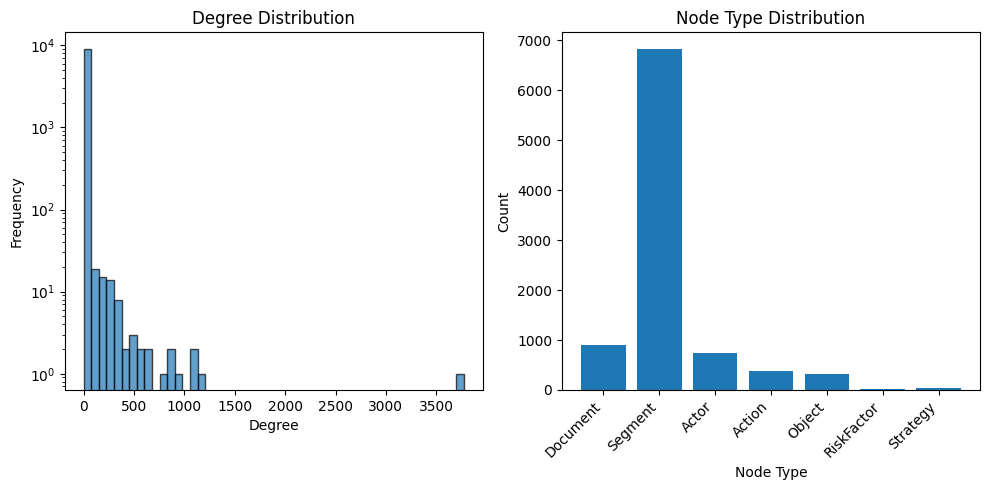


✓ PIPELINE COMPLETE


In [ ]:
run_ultra_optimized_pipeline()

In [ ]:
"""
AGORA CAUSAL REASONING : Load existing graph (agora_ultra.pkl) and answer causal questions with Mistral LLM.
"""
import os
import json
import re
import pickle
from typing import List, Dict, Tuple, Optional
import networkx as nx
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

print("Checking dependencies...")
import subprocess
import sys

def install_package(package):
    """Install a package using pip"""
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

try:
    from huggingface_hub import hf_hub_download
    print("huggingface_hub available")
except ImportError:
    print("Installing huggingface_hub...")
    install_package('huggingface-hub')
    from huggingface_hub import hf_hub_download
    print("huggingface_hub installed")

try:
    from llama_cpp import Llama
    print("llama_cpp available")
except ImportError:
    print("Installing llama-cpp-python (this may take 2-3 minutes)...")
    install_package('llama-cpp-python')
    from llama_cpp import Llama
    print("llama_cpp installed")

try:
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
    print("pyvis available")
except ImportError:
    print("Installing pyvis...")
    install_package('pyvis')
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
    print("pyvis installed")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    print("plotting libraries available")
except ImportError:
    print("Installing plotting libraries...")
    install_package('matplotlib')
    install_package('seaborn')
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    print("plotting libraries installed")

print("\n All dependencies installed")

# ============================================================================
# STEP 2: LOAD KNOWLEDGE GRAPH
# ============================================================================
class GraphLoader:
    """Load pre-built knowledge graph"""

    def __init__(self, graph_path: str = "agora_ultra.pkl"):
        self.graph_path = graph_path
        self.graph = None

    def load(self):
        """Load graph from pickle"""
        print(f"\n{'='*70}")
        print("LOADING KNOWLEDGE GRAPH")
        print(f"{'='*70}")

        if not os.path.exists(self.graph_path):
            raise FileNotFoundError(
                f"Graph file not found: {self.graph_path}\n"
                "Please ensure agora_ultra.pkl is in the current directory."
            )

        print(f"Loading from: {self.graph_path}")

        with open(self.graph_path, 'rb') as f:
            self.graph = pickle.load(f)

        print(f"Graph loaded: {self.graph.number_of_nodes()} nodes, "
              f"{self.graph.number_of_edges()} edges")

        self._print_stats()

        return self.graph

    def _print_stats(self):
        """Print graph statistics"""
        node_types = Counter()
        for _, data in self.graph.nodes(data=True):
            node_types[data.get('type', 'Unknown')] += 1

        print("\nNode Distribution:")
        for node_type, count in sorted(node_types.items(), key=lambda x: -x[1]):
            print(f"  {node_type}: {count}")

        edge_types = Counter()
        for _, _, data in self.graph.edges(data=True):
            edge_types[data.get('type', 'Unknown')] += 1

        print("\nEdge Distribution:")
        for edge_type, count in sorted(edge_types.items(), key=lambda x: -x[1]):
            print(f"  {edge_type}: {count}")

# ============================================================================
# STEP 3: MISTRAL LLM MANAGER
# ============================================================================
class MistralManager:
    """Download and manage Mistral 7B model"""

    def __init__(self):
        self.model_repo = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
        self.model_file = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"
        self.model_path = None
        self.llm = None

    def download_model(self):
        """Download Mistral model from HuggingFace"""
        print(f"\n{'='*70}")
        print("DOWNLOADING MISTRAL 7B MODEL")
        print(f"{'='*70}")
        print(f"Repository: {self.model_repo}")
        print(f"File: {self.model_file}")

        try:
            self.model_path = hf_hub_download(
                repo_id=self.model_repo,
                filename=self.model_file,
                local_dir="./models",
                local_dir_use_symlinks=False
            )
            print(f"\n Model downloaded to: {self.model_path}")
            return True
        except Exception as e:
            print(f"\n Download failed: {e}")
            return False

    def load_model(self, n_ctx: int = 4096, n_gpu_layers: int = 0):
        """Load model into memory"""
        if not self.model_path:
            if not self.download_model():
                raise RuntimeError("Failed to download model")

        print(f"\n{'='*70}")
        print("LOADING MISTRAL MODEL INTO MEMORY")
        print(f"{'='*70}")
        print(f"Context length: {n_ctx} tokens")
        print(f"GPU layers: {n_gpu_layers} (0 = CPU only)")

        self.llm = Llama(
            model_path=self.model_path,
            n_ctx=n_ctx,
            n_gpu_layers=n_gpu_layers,
            n_threads=4,
            verbose=False
        )

        print("Model loaded and ready!")
        return self.llm

    def generate(self, prompt: str, max_tokens: int = 1024,
                 temperature: float = 0.1) -> str:
        """Generate completion"""
        if not self.llm:
            raise RuntimeError("Model not loaded, check call_model()")

        response = self.llm(
            prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            stop=["</s>", "[/INST]", "User:", "Human:"],
            echo=False
        )

        return response['choices'][0]['text'].strip()

# ============================================================================
# STEP 4: CAUSAL GRAPH RETRIEVER
# ============================================================================
class CausalGraphRetriever:
    """Retrieve causal paths from graph for LLM reasoning"""

    def __init__(self, graph: nx.MultiDiGraph):
        self.graph = graph

    def find_causal_nodes(self, query: str, top_k: int = 25) -> List[str]:
        """Find nodes relevant to causal query"""
        query_lower = query.lower()

        causal_keywords = self._extract_keywords(query_lower)

        scored_nodes = []

        for node_id, node_data in self.graph.nodes(data=True):
            node_type = node_data.get('type', '')
            name = str(node_data.get('name', '')).lower()
            text = str(node_data.get('text', '')).lower()

            score = 0

            for keyword in causal_keywords:
                if keyword in name:
                    score += 10
                if keyword in text:
                    score += 3

            if node_type in ['Actor', 'Action', 'Strategy', 'RiskFactor']:
                score += 5

            degree = self.graph.degree(node_id)
            score += min(degree / 10, 5)

            if score > 0:
                scored_nodes.append((score, node_id, node_data))

        scored_nodes.sort(reverse=True, key=lambda x: x[0])
        return [node_id for _, node_id, _ in scored_nodes[:top_k]]

    def _extract_keywords(self, query: str) -> List[str]:
        """Extract important keywords"""
        query_clean = re.sub(
            r'\b(why|how|what|which|who|when|where|does|do|is|are|the|a|an|to|of|for|in|on|at|must|should|can)\b',
            '', query
        ).strip()

        words = query_clean.split()
        return [w for w in words if len(w) > 3]

    def extract_causal_subgraph(self, seed_nodes: List[str],
                               max_hops: int = 3) -> nx.DiGraph:
        """Extract causal subgraph around seed nodes"""
        subgraph_nodes = set(seed_nodes)

        for _ in range(max_hops):
            new_nodes = set()
            for node in subgraph_nodes:
                if self.graph.has_node(node):
                    new_nodes.update(self.graph.successors(node))
                    new_nodes.update(self.graph.predecessors(node))
            subgraph_nodes.update(new_nodes)

        return self.graph.subgraph(subgraph_nodes).copy()

    def find_causal_chains(self, subgraph: nx.DiGraph,
                          max_chains: int = 8) -> List[Dict]:
        """Find causal chains in subgraph"""
        chains = []

        start_types = ['RiskFactor', 'Document', 'Segment']
        end_types = ['Strategy', 'Action', 'Object']

        start_nodes = [n for n, d in subgraph.nodes(data=True)
                      if d.get('type') in start_types]
        end_nodes = [n for n, d in subgraph.nodes(data=True)
                    if d.get('type') in end_types]

        found = 0
        for start in start_nodes[:10]:
            if found >= max_chains:
                break
            for end in end_nodes[:10]:
                if found >= max_chains:
                    break
                try:
                    paths = list(nx.all_simple_paths(
                        subgraph, start, end, cutoff=5
                    ))
                    for path in paths[:2]:
                        if len(path) >= 3:
                            chains.append(self._format_chain(subgraph, path))
                            found += 1
                            if found >= max_chains:
                                break
                except:
                    continue

        return chains

    def _format_chain(self, subgraph: nx.DiGraph, path: List[str]) -> Dict:
        """Format chain with node details"""
        formatted = {
            'nodes': [],
            'edges': [],
            'readable': []
        }

        for i, node_id in enumerate(path):
            node_data = subgraph.nodes[node_id]
            node_info = {
                'id': node_id,
                'type': node_data.get('type', 'Unknown'),
                'name': node_data.get('name', 'Unknown')[:100],
                'text': node_data.get('text', '')[:200]
            }
            formatted['nodes'].append(node_info)

            # Get edge type
            if i < len(path) - 1:
                next_node = path[i + 1]
                edge_data = subgraph.get_edge_data(node_id, next_node)
                if edge_data:
                    edge_type = list(edge_data.values())[0].get('type', 'LINKED_TO')
                    formatted['edges'].append(edge_type)

        # Create readable chain
        for i, node_info in enumerate(formatted['nodes']):
            formatted['readable'].append(
                f"{node_info['type']}: {node_info['name']}"
            )
            if i < len(formatted['edges']):
                formatted['readable'].append(f" --[{formatted['edges'][i]}]--> ")

        return formatted

    def get_supporting_segments(self, subgraph: nx.DiGraph,
                               max_segments: int = 5) -> List[Dict]:
        """Extract text segments from subgraph"""
        segments = []

        for node_id, node_data in subgraph.nodes(data=True):
            if node_data.get('type') == 'Segment':
                # Find parent document
                doc_name = "Unknown Document" #LLM HALLUCINATING NOT LOOKING AT ANY DOCUMENT FOR ANSWERING THEN
                for pred in subgraph.predecessors(node_id):
                    pred_data = subgraph.nodes[pred]
                    if pred_data.get('type') == 'Document':
                        doc_name = pred_data.get('name', 'Unknown')
                        break

                segments.append({
                    'segment_id': node_id,
                    'document': doc_name[:100],
                    'text': node_data.get('text', '')[:500]
                })

                if len(segments) >= max_segments:
                    break

        return segments

# ============================================================================
# STEP 5: CAUSAL REASONER
# ============================================================================
class CausalReasoner:
    """LLM-powered causal reasoning grounded in graph"""

    def __init__(self, mistral: MistralManager, retriever: CausalGraphRetriever):
        self.mistral = mistral
        self.retriever = retriever

    def answer_causal_question(self, query: str, verbose: bool = True) -> Dict:
        """Answer causal query using graph + LLM"""

        if verbose:
            print(f"\n{'='*70}")
            print(f"QUERY: {query}")
            print(f"{'='*70}")

        # Step 1: Find relevant nodes
        if verbose:
            print("\n Retrieving relevant graph nodes...")
        seed_nodes = self.retriever.find_causal_nodes(query, top_k=20)
        if verbose:
            print(f"   Found {len(seed_nodes)} relevant nodes")

        if not seed_nodes:
            return {
                'query': query,
                'answer': "I couldn't find relevant information in the graph.",
                'causal_chains': [],
                'sources': [],
                'confidence': 0.0
            }

        # Step 2: Extract subgraph
        if verbose:
            print("\n  Extracting causal subgraph...")
        subgraph = self.retriever.extract_causal_subgraph(seed_nodes, max_hops=3)
        if verbose:
            print(f"   Subgraph: {subgraph.number_of_nodes()} nodes, "
                  f"{subgraph.number_of_edges()} edges")

        # Step 3: Find causal chains
        if verbose:
            print("\n  Finding causal chains...")
        chains = self.retriever.find_causal_chains(subgraph, max_chains=6)
        if verbose:
            print(f"   Found {len(chains)} causal chains")

        # Step 4: Get supporting text
        if verbose:
            print("\n  Extracting supporting segments...")
        segments = self.retriever.get_supporting_segments(subgraph, max_segments=5)
        if verbose:
            print(f"   Retrieved {len(segments)} text segments")

        # Step 5: Generate answer
        if verbose:
            print("\n  Generating answer with Mistral...")
        answer = self._generate_answer(query, chains, segments)

        result = {
            'query': query,
            'answer': answer,
            'causal_chains': chains,
            'sources': segments,
            'subgraph': subgraph,
            'confidence': self._estimate_confidence(chains, segments)
        }

        if verbose:
            self._print_result(result)

        return result

    def _generate_answer(self, query: str, chains: List[Dict],
                        segments: List[Dict]) -> str:
        """Generate answer using LLM"""

        prompt = f"""<s>[INST] You are an expert AI governance analyst. Answer the user's question using ONLY the provided causal chains and document segments.

USER QUESTION:
{query}

CAUSAL CHAINS FROM KNOWLEDGE GRAPH:
"""

        # Add chains
        for i, chain in enumerate(chains[:5], 1):
            prompt += f"\nChain {i}:\n"
            prompt += ''.join(chain['readable'])
            prompt += "\n"

        # Add segments
        prompt += "\n\nSOURCE DOCUMENT SEGMENTS:\n"
        for i, seg in enumerate(segments[:5], 1):
            prompt += f"\n[Source {i}] {seg['document']}\n"
            prompt += f"{seg['text']}\n"

        prompt += f"""
INSTRUCTIONS:
1. Answer the question directly and concisely
2. Explain the causal relationships you found in the chains
3. Cite sources using [Source N] notation
4. Focus on "why" and "how" - explain causation
5. If evidence is incomplete, acknowledge this

Your answer (2-4 paragraphs):
[/INST]
"""

        answer = self.mistral.generate(prompt, max_tokens=800, temperature=0.1)
        return answer

    def _estimate_confidence(self, chains: List[Dict], segments: List[Dict]) -> float:
        """Estimate confidence"""
        score = 0.0
        score += min(len(chains) * 0.15, 0.6)
        score += min(len(segments) * 0.1, 0.3)
        if chains:
            avg_len = sum(len(c['nodes']) for c in chains) / len(chains)
            score += min(avg_len * 0.02, 0.1)
        return min(score, 1.0)

    def _print_result(self, result: Dict):
        """Pretty print result"""
        print(f"\n{'='*70}")
        print("ANSWER")
        print(f"{'='*70}")
        print(f"\n{result['answer']}\n")

        print(f"{'='*70}")
        print("CAUSAL EXPLANATION CHAINS")
        print(f"{'='*70}")
        for i, chain in enumerate(result['causal_chains'][:3], 1):
            print(f"\nChain {i}:")
            for item in chain['readable']:
                print(f"  {item}")

        print(f"\n{'='*70}")
        print("SOURCES")
        print(f"{'='*70}")
        for i, source in enumerate(result['sources'][:3], 1):
            print(f"\n[Source {i}] {source['document']}")
            print(f"{source['text'][:300]}...")

        print(f"\n{'='*70}")
        print(f"Confidence: {result['confidence']:.2f}")
        print(f"{'='*70}")

# ============================================================================
# STEP 6: VISUALIZATION
# ============================================================================
def visualize_answer(result: Dict, output_file: str = 'answer_graph.html'):
    """Visualize answer subgraph"""

    if not PYVIS_AVAILABLE:
        print(" Visualization not available")
        return

    subgraph = result.get('subgraph')
    if not subgraph:
        print("No subgraph in result")
        return

    print(f"\n Creating visualization...")

    net = Network(height='750px', width='100%', directed=True, notebook=True)
    net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=200)

    colors = {
        'Document': '#3498db',
        'Segment': '#2ecc71',
        'Actor': '#e74c3c',
        'Action': '#f39c12',
        'Object': '#1abc9c',
        'RiskFactor': '#e67e22',
        'Strategy': '#9b59b6'
    }

    # Add nodes
    for node_id, node_data in subgraph.nodes(data=True):
        node_type = node_data.get('type', 'Unknown')
        name = node_data.get('name', node_id)

        label = name[:40] + '...' if len(name) > 40 else name

        net.add_node(
            node_id,
            label=label,
            title=f"{node_type}: {name}",
            color=colors.get(node_type, '#95a5a6'),
            size=20
        )

    # Add edges
    for u, v, edge_data in subgraph.edges(data=True):
        edge_type = edge_data.get('type', '')
        net.add_edge(u, v, label=edge_type, arrows='to')

    net.save_graph(output_file)
    print(f" Visualization saved to {output_file}")

# ============================================================================
# STEP 7: MAIN SETUP AND INTERFACE
# ============================================================================
def setup_system(graph_path: str = "agora_ultra.pkl"):
    """Setup complete system and return reasoner"""

    print("\n" + "="*70)
    print("AGORA CAUSAL REASONING SYSTEM - SETUP")
    print("="*70)

    # Load graph
    graph_loader = GraphLoader(graph_path)
    graph = graph_loader.load()

    # Load Mistral
    mistral = MistralManager()
    mistral.load_model(n_ctx=4096, n_gpu_layers=0)

    # Create retriever and reasoner
    retriever = CausalGraphRetriever(graph)
    reasoner = CausalReasoner(mistral, retriever)

    print("\n" + "="*70)
    print("SYSTEM READY!")
    print("="*70)
    print("\nRun now")

    return reasoner

# ============================================================================
# USAGE
# ============================================================================
if __name__ == "__main__":
    print("""
QUICK START:
-----------
# 1. Setup system (one-time, 5-10 min first run)
reasoner = setup_system()

# 2. Ask questions
result = reasoner.answer_causal_question("Why must AI systems be evaluated for bias?")

# 3. Visualize
visualize_answer(result)

# 4. More questions
result2 = reasoner.answer_causal_question("How do transparency requirements mitigate risks?")
result3 = reasoner.answer_causal_question("What strategies ensure AI safety?")

EXAMPLE QUESTIONS:
-----------------
• "Why must AI systems be evaluated?"
• "How do disclosure requirements address transparency?"
• "What strategies mitigate bias risks?"
• "Why are evaluation requirements important?"
• "How do regulations ensure AI safety?"
""")

    print("\n Ready to run setup_system()")

In [ ]:
reasoner = setup_system()

#WRITE QUERY
result = reasoner.answer_causal_question("Why must AI systems be evaluated for bias?")

# Visualizing causal chain
visualize_answer(result)


AGORA CAUSAL REASONING SYSTEM - SETUP

LOADING KNOWLEDGE GRAPH
Loading from: agora_ultra.pkl
✓ Graph loaded: 9216 nodes, 30446 edges

Node Distribution:
  Segment: 6818
  Document: 910
  Actor: 747
  Action: 372
  Object: 325
  Strategy: 34
  RiskFactor: 10

Edge Distribution:
  MITIGATED_BY: 8541
  CONTAINS: 6818
  IMPOSES_DUTY_ON: 5029
  REQUIRES_ACTION: 5029
  TARGETS: 5029

DOWNLOADING MISTRAL 7B MODEL
Repository: TheBloke/Mistral-7B-Instruct-v0.2-GGUF
File: mistral-7b-instruct-v0.2.Q4_K_M.gguf
Size: ~4.1GB

⏳ This will take 5-10 minutes on first run...
(Model is cached for future use)


✓ Model downloaded to: models/mistral-7b-instruct-v0.2.Q4_K_M.gguf

LOADING MISTRAL MODEL INTO MEMORY
Context length: 4096 tokens
GPU layers: 0 (0 = CPU only)

⏳ Loading model (30 seconds)...



llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✓ Model loaded and ready!

✓ SYSTEM READY!

You can now ask causal questions:
  result = reasoner.answer_causal_question("Why must AI be evaluated?")
  visualize_answer(result)

QUERY: Why must AI systems be evaluated for bias?

1️⃣  Retrieving relevant graph nodes...
   Found 20 relevant nodes

2️⃣  Extracting causal subgraph...
   Subgraph: 3770 nodes, 13072 edges

3️⃣  Finding causal chains...
   Found 1 causal chains

4️⃣  Extracting supporting segments...
   Retrieved 5 text segments

5️⃣  Generating answer with Mistral...

ANSWER

To answer the user's question, it is essential to understand the causal relationships identified in the provided causal chains and document segments. The question asks "Why must AI systems be evaluated for bias?" The causal chains suggest that there are regulatory requirements that mandate risk assessments and impact assessments for AI systems, which include evaluating bias.

The first causal chain [Chain 1] does not directly address the question, but i

In [ ]:
"""
AGORA CAUSAL REASONING - Graph-grounded causal inference with CSV integration and explicit reasoning paths - PERFORMS BETTER THAN ABOVE - USE THIS VERSION
"""
import os
import json
import re
import pickle
from typing import List, Dict, Tuple, Optional, Set
import networkx as nx
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

print("Checking dependencies...")
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

try:
    import pandas as pd
    print("pandas available")
except ImportError:
    print("Installing pandas...")
    install_package('pandas')
    import pandas as pd
    print("pandas installed")

try:
    from huggingface_hub import hf_hub_download
    print("huggingface_hub available")
except ImportError:
    print("Installing huggingface_hub...")
    install_package('huggingface-hub')
    from huggingface_hub import hf_hub_download
    print("huggingface_hub installed")

try:
    from llama_cpp import Llama
    print("llama_cpp available")
except ImportError:
    print("Installing llama-cpp-python...")
    install_package('llama-cpp-python')
    from llama_cpp import Llama
    print("llama_cpp installed")

try:
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
    print("pyvis available")
except ImportError:
    print("Installing pyvis...")
    install_package('pyvis')
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
    print("pyvis installed")

try:
    import matplotlib.pyplot as plt
    import numpy as np
    print("plotting libraries available")
except ImportError:
    install_package('matplotlib')
    import matplotlib.pyplot as plt
    import numpy as np
    print("plotting libraries installed")

print("\n All dependencies ready")

# ============================================================================
# CSV DATA LOADER
# ============================================================================
class CSVDataLoader:
    """Load and index CSV data for retrieval"""

    def __init__(self, csv_dir: str = "."):
        self.csv_dir = csv_dir
        self.dataframes = {}
        self.indexed_data = {}

    def load_csvs(self, csv_files: List[str] = None):
        """Load CSV files and index their content"""
        print(f"\n{'='*70}")
        print("LOADING CSV DATA")
        print(f"{'='*70}")

        if csv_files is None:
            csv_files = [f for f in os.listdir(self.csv_dir) if f.endswith('.csv')]

        for csv_file in csv_files:
            filepath = os.path.join(self.csv_dir, csv_file)
            if os.path.exists(filepath):
                try:
                    df = pd.read_csv(filepath)
                    self.dataframes[csv_file] = df
                    self._index_dataframe(csv_file, df)
                    print(f"✓ Loaded: {csv_file} ({len(df)} rows, {len(df.columns)} columns)")
                except Exception as e:
                    print(f"✗ Failed to load {csv_file}: {e}")

        print(f"\n Loaded {len(self.dataframes)} CSV files")
        return self.dataframes

    def _index_dataframe(self, filename: str, df: pd.DataFrame):
        """Create searchable index of CSV content"""
        indexed_rows = []

        for idx, row in df.iterrows():
            row_text = ' '.join([str(v) for v in row.values if pd.notna(v)])

            indexed_rows.append({
                'source': filename,
                'row_idx': idx,
                'text': row_text.lower(),
                'data': row.to_dict()
            })

        self.indexed_data[filename] = indexed_rows

    def search_csvs(self, query: str, top_k: int = 10) -> List[Dict]:
        """Search CSV data for relevant rows"""
        query_lower = query.lower()
        query_terms = set(query_lower.split())

        scored_rows = []

        for filename, rows in self.indexed_data.items():
            for row in rows:
                row_terms = set(row['text'].split())
                overlap = len(query_terms & row_terms)

                if overlap > 0:
                    scored_rows.append({
                        'source': filename,
                        'row_idx': row['row_idx'],
                        'data': row['data'],
                        'text': row['text'][:300],
                        'score': overlap
                    })

        scored_rows.sort(key=lambda x: x['score'], reverse=True)
        return scored_rows[:top_k]

# ============================================================================
# GRAPH LOADER
# ============================================================================
class GraphLoader:
    def __init__(self, graph_path: str = "agora_ultra.pkl"):
        self.graph_path = graph_path
        self.graph = None

    def load(self):
        print(f"\n{'='*70}")
        print("LOADING KNOWLEDGE GRAPH")
        print(f"{'='*70}")

        if not os.path.exists(self.graph_path):
            raise FileNotFoundError(f"Graph file not found: {self.graph_path}")

        print(f"Loading from: {self.graph_path}")
        with open(self.graph_path, 'rb') as f:
            self.graph = pickle.load(f)

        print(f" Graph loaded: {self.graph.number_of_nodes()} nodes, "
              f"{self.graph.number_of_edges()} edges")
        self._print_stats()
        return self.graph

    def _print_stats(self):
        node_types = Counter()
        for _, data in self.graph.nodes(data=True):
            node_types[data.get('type', 'Unknown')] += 1

        print("\nNode Distribution:")
        for node_type, count in sorted(node_types.items(), key=lambda x: -x[1]):
            print(f"  {node_type}: {count}")

# ============================================================================
# MISTRAL MANAGER
# ============================================================================
class MistralManager:
    def __init__(self):
        self.model_repo = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
        self.model_file = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"
        self.model_path = None
        self.llm = None

    def download_model(self):
        print(f"\n{'='*70}")
        print("DOWNLOADING MISTRAL 7B MODEL")
        print(f"{'='*70}")
        print(f"Repository: {self.model_repo}")
        print(f"File: {self.model_file}")

        try:
            self.model_path = hf_hub_download(
                repo_id=self.model_repo,
                filename=self.model_file,
                local_dir="./models",
                local_dir_use_symlinks=False
            )
            print(f"\n Model downloaded to: {self.model_path}")
            return True
        except Exception as e:
            print(f"\n Download failed: {e}")
            return False

    def load_model(self, n_ctx: int = 8192, n_gpu_layers: int = 0):
        if not self.model_path:
            if not self.download_model():
                raise RuntimeError("Failed to download model")

        print(f"\n{'='*70}")
        print("LOADING MISTRAL MODEL INTO MEMORY")
        print(f"{'='*70}")
        print(f"Context length: {n_ctx} tokens")
        print(f"GPU layers: {n_gpu_layers} (0 = CPU only)")

        self.llm = Llama(
            model_path=self.model_path,
            n_ctx=n_ctx,
            n_gpu_layers=n_gpu_layers,
            n_threads=4,
            verbose=False
        )

        print("Model loaded and ready!")
        return self.llm

    def generate(self, prompt: str, max_tokens: int = 1024,
                 temperature: float = 0.1) -> str:
        if not self.llm:
            raise RuntimeError("Model not loaded. check load_model() instantied")

        response = self.llm(
            prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            stop=["</s>", "[/INST]", "User:", "Human:"],
            echo=False
        )

        return response['choices'][0]['text'].strip()


class EnhancedCausalRetriever:
    """Enhanced retriever with causal path tracking and CSV integration"""

    def __init__(self, graph: nx.MultiDiGraph, csv_loader: CSVDataLoader = None):
        self.graph = graph
        self.csv_loader = csv_loader

    def find_causal_paths(self, query: str, max_paths: int = 10) -> Dict:
        """Find causal paths with full provenance tracking"""

        print(f"\n Retrieving from Graph and CSV Data...")

        entities = self._extract_query_entities(query)

        seed_nodes = self._find_relevant_nodes(entities, top_k=30)

        csv_results = []
        if self.csv_loader:
            csv_results = self.csv_loader.search_csvs(query, top_k=10)

        paths = self._build_causal_paths(seed_nodes, max_paths=max_paths)

        documents = self._extract_documents(paths)

        inference_structure = self._build_inference_structure(paths, query)

        return {
            'query': query,
            'entities': entities,
            'seed_nodes': seed_nodes[:10],
            'causal_paths': paths,
            'documents': documents,
            'csv_results': csv_results,
            'inference_structure': inference_structure
        }

    def _extract_query_entities(self, query: str) -> Dict[str, List[str]]:
        """Extract key entities from query"""
        query_lower = query.lower()

        entities = {
            'actions': [],
            'objects': [],
            'risks': [],
            'strategies': [],
            'concepts': []
        }

        keywords = {
            'actions': ['evaluate', 'assess', 'monitor', 'test', 'measure',
                       'audit', 'validate', 'verify', 'mitigate', 'implement'],
            'objects': ['bias', 'fairness', 'transparency', 'accountability',
                       'safety', 'privacy', 'security', 'ai system', 'model'],
            'risks': ['risk', 'threat', 'vulnerability', 'harm', 'danger'],
            'strategies': ['strategy', 'approach', 'method', 'practice', 'technique']
        }

        words = query_lower.split()
        for category, keyword_list in keywords.items():
            for word in words:
                if any(kw in word for kw in keyword_list):
                    entities[category].append(word)

        entities['concepts'] = [w for w in words if len(w) > 4]

        return entities

    def _find_relevant_nodes(self, entities: Dict, top_k: int = 30) -> List[Dict]:
        """Find nodes matching query entities with scoring"""

        scored_nodes = []

        for node_id, node_data in self.graph.nodes(data=True):
            node_type = node_data.get('type', '')
            name = str(node_data.get('name', '')).lower()
            text = str(node_data.get('text', '')).lower()

            score = 0
            matches = []

            for entity_type, keywords in entities.items():
                for keyword in keywords:
                    if keyword in name:
                        score += 20
                        matches.append(f"{entity_type}:{keyword}")
                    elif keyword in text:
                        score += 8
                        matches.append(f"{entity_type}:{keyword}")

            type_boost = {
                'Action': 12,
                'RiskFactor': 12,
                'Strategy': 10,
                'Actor': 8,
                'Object': 8,
                'Segment': 5
            }
            score += type_boost.get(node_type, 0)

            degree = self.graph.degree(node_id)
            score += min(degree / 3, 15)

            if score > 0:
                scored_nodes.append({
                    'node_id': node_id,
                    'type': node_type,
                    'name': node_data.get('name', 'Unknown')[:100],
                    'text': text[:200],
                    'score': score,
                    'matches': matches,
                    'degree': degree
                })

        scored_nodes.sort(key=lambda x: x['score'], reverse=True)
        return scored_nodes[:top_k]

    def _build_causal_paths(self, seed_nodes: List[Dict],
                           max_paths: int = 10) -> List[Dict]:
        """Build explicit causal paths through graph"""

        paths = []

        causal_edges = {
            'MITIGATED_BY': 'mitigates',
            'REQUIRES_ACTION': 'requires',
            'IMPOSES_DUTY_ON': 'imposes duty on',
            'TARGETS': 'targets',
            'IMPLEMENTS': 'implements',
            'CAUSES': 'causes',
            'PREVENTS': 'prevents',
            'ENABLES': 'enables'
        }

        seed_ids = [n['node_id'] for n in seed_nodes[:20]]

        for i, start_node in enumerate(seed_ids[:12]):
            for end_node in seed_ids[i+1:20]:
                try:
                    if nx.has_path(self.graph, start_node, end_node):
                        for path in list(nx.all_shortest_paths(self.graph, start_node, end_node))[:3]:
                            if len(path) >= 2:
                                path_info = self._format_causal_path(path, causal_edges)
                                if path_info['is_causal']:
                                    paths.append(path_info)

                                    if len(paths) >= max_paths:
                                        return paths
                except:
                    continue

        if len(paths) < 5:
            for node_info in seed_nodes[:15]:
                node_id = node_info['node_id']

                for neighbor in self.graph.neighbors(node_id):
                    edge_data = self.graph.get_edge_data(node_id, neighbor)
                    if edge_data:
                        for edge_info in edge_data.values():
                            if edge_info.get('type') in causal_edges:
                                path = [node_id, neighbor]
                                path_info = self._format_causal_path(path, causal_edges)
                                paths.append(path_info)

                                if len(paths) >= max_paths:
                                    return paths

        return paths

    def _format_causal_path(self, path: List[str], causal_edges: Dict) -> Dict:
        """Format path with full causal structure"""

        nodes = []
        edges = []
        is_causal = False

        for i, node_id in enumerate(path):
            node_data = self.graph.nodes[node_id]

            node_info = {
                'id': node_id,
                'type': node_data.get('type', 'Unknown'),
                'name': node_data.get('name', 'Unknown')[:150],
                'text': node_data.get('text', '')[:300]
            }
            nodes.append(node_info)

            if i < len(path) - 1:
                next_node = path[i + 1]
                edge_data = self.graph.get_edge_data(node_id, next_node)

                if edge_data:
                    edge_type = list(edge_data.values())[0].get('type', 'LINKED_TO')
                    edges.append(edge_type)

                    if edge_type in causal_edges:
                        is_causal = True

        readable = []
        for i, node in enumerate(nodes):
            readable.append(f"[{node['type']}] {node['name']}")
            if i < len(edges):
                readable.append(f"\n    └─ {edges[i]} ─>\n")

        return {
            'nodes': nodes,
            'edges': edges,
            'is_causal': is_causal,
            'readable': ''.join(readable),
            'length': len(nodes)
        }

    def _extract_documents(self, paths: List[Dict]) -> List[Dict]:
        """Extract source documents from paths"""

        documents = []
        seen_docs = set()

        all_nodes = set()
        for path in paths:
            for node in path['nodes']:
                all_nodes.add(node['id'])

        for node_id in all_nodes:
            try:
                node_data = self.graph.nodes[node_id]

                if node_data.get('type') == 'Segment':
                    for pred in self.graph.predecessors(node_id):
                        pred_data = self.graph.nodes[pred]
                        if pred_data.get('type') == 'Document':
                            doc_name = pred_data.get('name', 'Unknown')

                            if doc_name not in seen_docs:
                                documents.append({
                                    'doc_id': pred,
                                    'name': doc_name,
                                    'segment_id': node_id,
                                    'text': node_data.get('text', '')[:800]
                                })
                                seen_docs.add(doc_name)

                                if len(documents) >= 8:
                                    return documents
            except:
                continue

        return documents

    def _build_inference_structure(self, paths: List[Dict], query: str) -> Dict:
        """Build the inference structure showing how graph answers query"""

        patterns = {
            'risk_mitigation': [],
            'action_requirements': [],
            'actor_duties': [],
            'implementation': [],
            'direct_answers': []
        }

        for path in paths:
            edges = path['edges']

            if 'MITIGATED_BY' in edges or 'PREVENTS' in edges:
                patterns['risk_mitigation'].append(path)
            elif 'REQUIRES_ACTION' in edges:
                patterns['action_requirements'].append(path)
            elif 'IMPOSES_DUTY_ON' in edges:
                patterns['actor_duties'].append(path)
            elif 'IMPLEMENTS' in edges:
                patterns['implementation'].append(path)
            else:
                patterns['direct_answers'].append(path)

        return {
            'query': query,
            'patterns': patterns,
            'total_paths': len(paths),
            'explanation': self._generate_structure_explanation(patterns, query)
        }

    def _generate_structure_explanation(self, patterns: Dict, query: str) -> str:
        """Generate explanation of inference structure"""

        explanation = "CAUSAL INFERENCE STRUCTURE:\n\n"

        if patterns['risk_mitigation']:
            explanation += f"• Risk Mitigation Paths ({len(patterns['risk_mitigation'])}): "
            explanation += "How risks are mitigated through strategies.\n"

        if patterns['action_requirements']:
            explanation += f"• Action Requirements ({len(patterns['action_requirements'])}): "
            explanation += "Required actions to address the query.\n"

        if patterns['actor_duties']:
            explanation += f"• Actor Duties ({len(patterns['actor_duties'])}): "
            explanation += "Which actors have obligations.\n"

        if patterns['implementation']:
            explanation += f"• Implementation Paths ({len(patterns['implementation'])}): "
            explanation += "How concepts are implemented.\n"

        if patterns['direct_answers']:
            explanation += f"• Direct Relationships ({len(patterns['direct_answers'])}): "
            explanation += "Direct connections to the answer.\n"

        return explanation

# ============================================================================
# CAUSAL REASONER WITH ANSWER TRACKING
# ============================================================================
class EnhancedCausalReasoner:
    """Reasoner with explicit causal inference and source tracking"""

    def __init__(self, mistral: MistralManager, retriever: EnhancedCausalRetriever):
        self.mistral = mistral
        self.retriever = retriever

    def answer_with_provenance(self, query: str) -> Dict:
        """Answer query with full causal provenance"""

        print(f"\n{'='*70}")
        print(f"QUERY: {query}")
        print(f"{'='*70}")

        print(f"\n STEP 1: Retrieving from Graph & CSV")
        print("-" * 70)
        retrieval = self.retriever.find_causal_paths(query, max_paths=8)

        print(f" Found {len(retrieval['causal_paths'])} causal paths")
        print(f" Identified {len(retrieval['seed_nodes'])} relevant nodes")
        print(f" Retrieved {len(retrieval['documents'])} source documents")
        print(f" Found {len(retrieval['csv_results'])} relevant CSV rows")

        print(f"\n STEP 2: Causal Inference Structure")
        print("-" * 70)
        print(retrieval['inference_structure']['explanation'])

        print(f"\n STEP 3: Generating Answer with Mistral")
        print("-" * 70)
        answer, sources_used = self._generate_grounded_answer(query, retrieval)

        result = {
            'query': query,
            'answer': answer,
            'sources_used': sources_used,
            'retrieval': retrieval,
            'causal_paths': retrieval['causal_paths'],
            'documents': retrieval['documents'],
            'csv_results': retrieval['csv_results'],
            'inference_structure': retrieval['inference_structure']
        }

        self._display_results(result)

        return result

    def _generate_grounded_answer(self, query: str, retrieval: Dict) -> Tuple[str, Dict]:
        """Generate answer grounded in causal paths with source tracking"""

        prompt = f"""<s>[INST] You are an AI governance expert. Answer using ONLY the provided graph paths and CSV data.

QUESTION: {query}

CAUSAL PATHS FROM KNOWLEDGE GRAPH:
"""

        path_refs = []
        for i, path in enumerate(retrieval['causal_paths'][:6], 1):
            prompt += f"\n[PATH-{i}] Length: {path['length']}, Causal: {path['is_causal']}\n"
            prompt += path['readable']
            prompt += "\n"
            path_refs.append(f"PATH-{i}")

        prompt += "\n\nSOURCE DOCUMENTS FROM GRAPH:\n"
        doc_refs = []
        for i, doc in enumerate(retrieval['documents'][:6], 1):
            prompt += f"\n[DOC-{i}] {doc['name']}\n"
            prompt += f"{doc['text']}\n"
            doc_refs.append(f"DOC-{i}")

        if retrieval['csv_results']:
            prompt += "\n\nRELEVANT CSV DATA:\n"
            csv_refs = []
            for i, row in enumerate(retrieval['csv_results'][:5], 1):
                prompt += f"\n[CSV-{i}] From: {row['source']}\n"
                prompt += f"Data: {json.dumps(row['data'], indent=2)}\n"
                csv_refs.append(f"CSV-{i}")

        prompt += f"""
INSTRUCTIONS:
1. Answer the question directly and clearly
2. Base your answer ONLY on the paths, documents, and CSV data above
3. Explain the CAUSAL reasoning (e.g., "According to PATH-1, X REQUIRES Y because...")
4. Cite sources using [PATH-N], [DOC-N], or [CSV-N] notation
5. Be concise but thorough (3-5 paragraphs)
6. Start each citation with the reference (e.g., "[PATH-1] shows that...")

YOUR ANSWER (with citations):
[/INST]
"""

        answer = self.mistral.generate(prompt, max_tokens=1200, temperature=0.1)

        sources_used = self._parse_sources_used(answer, path_refs, doc_refs,
                                                retrieval.get('csv_results', []))

        return answer, sources_used

    def _parse_sources_used(self, answer: str, path_refs: List[str],
                           doc_refs: List[str], csv_results: List[Dict]) -> Dict:
        """Parse which sources the model actually used in its answer"""

        sources = {
            'paths': [],
            'documents': [],
            'csv_rows': []
        }

        for ref in path_refs:
            if ref in answer or f"[{ref}]" in answer:
                sources['paths'].append(ref)

        for ref in doc_refs:
            if ref in answer or f"[{ref}]" in answer:
                sources['documents'].append(ref)

        for i in range(len(csv_results)):
            ref = f"CSV-{i+1}"
            if ref in answer or f"[{ref}]" in answer:
                sources['csv_rows'].append(ref)

        return sources

    def _display_results(self, result: Dict):
        """Display comprehensive results"""

        print(f"\n{'='*70}")
        print(" ANSWER")
        print(f"{'='*70}\n")
        print(result['answer'])

        print(f"\n{'='*70}")
        print(" SOURCES USED BY MISTRAL")
        print(f"{'='*70}")
        sources = result['sources_used']
        print(f"Paths referenced: {', '.join(sources['paths']) if sources['paths'] else 'None'}")
        print(f"Documents referenced: {', '.join(sources['documents']) if sources['documents'] else 'None'}")
        print(f"CSV rows referenced: {', '.join(sources['csv_rows']) if sources['csv_rows'] else 'None'}")

        print(f"\n{'='*70}")
        print(" CAUSAL PATHS RETRIEVED")
        print(f"{'='*70}")

        for i, path in enumerate(result['causal_paths'][:5], 1):
            used = f"PATH-{i}" in result['sources_used']['paths']
            marker = "USED" if used else "Available"
            print(f"\n{marker} --- Path {i} ---")
            print(path['readable'])

        print(f"\n{'='*70}")
        print(" SOURCE DOCUMENTS")
        print(f"{'='*70}")

        for i, doc in enumerate(result['documents'][:5], 1):
            used = f"DOC-{i}" in result['sources_used']['documents']
            marker = "USED" if used else "Available"
            print(f"\n{marker} [Doc {i}] {doc['name']}")
            print(f"Text: {doc['text'][:300]}...")

        if result['csv_results']:
            print(f"\n{'='*70}")
            print(" CSV DATA")
            print(f"{'='*70}")

            for i, row in enumerate(result['csv_results'][:5], 1):
                used = f"CSV-{i}" in result['sources_used']['csv_rows']
                marker = "USED" if used else "Available"
                print(f"\n{marker} [CSV {i}] From: {row['source']}")
                print(f"Score: {row['score']}")
                print(f"Data: {json.dumps(row['data'], indent=2)[:300]}...")

        print(f"\n{'='*70}")
        print(" INFERENCE SUMMARY")
        print(f"{'='*70}")
        print(f"Causal Paths Used: {len(result['sources_used']['paths'])}/{len(result['causal_paths'])}")
        print(f"Documents Cited: {len(result['sources_used']['documents'])}/{len(result['documents'])}")
        print(f"CSV Rows Cited: {len(result['sources_used']['csv_rows'])}/{len(result['csv_results'])}")
        print(f"Graph Nodes Examined: {len(result['retrieval']['seed_nodes'])}")

# ============================================================================
# VISUALIZATION
# ============================================================================
def visualize_causal_inference(result: Dict, output_file: str = 'causal_inference.html'):
    """Visualize the causal inference structure with source tracking"""

    if not PYVIS_AVAILABLE:
        print("pyvis not installed)")
        return

    print(f"\n{'='*70}")
    print("CREATING CAUSAL INFERENCE VISUALIZATION")
    print(f"{'='*70}")

    net = Network(height='900px', width='100%', directed=True,
                  bgcolor='#ffffff', font_color='#000000')
    net.barnes_hut(gravity=-15000, central_gravity=0.5, spring_length=200)

    colors = {
        'Document': '#3498db',
        'Segment': '#2ecc71',
        'Actor': '#e74c3c',
        'Action': '#f39c12',
        'Object': '#1abc9c',
        'RiskFactor': '#e67e22',
        'Strategy': '#9b59b6',
        'Used': '#27ae60',
        'Unused': '#95a5a6'
    }

    used_nodes = set()
    sources_used = result['sources_used']

    for i, path_ref in enumerate(sources_used['paths']):
        path_idx = int(path_ref.split('-')[1]) - 1
        if path_idx < len(result['causal_paths']):
            for node in result['causal_paths'][path_idx]['nodes']:
                used_nodes.add(node['id'])

    added_nodes = set()
    for i, path in enumerate(result['causal_paths']):
        path_was_used = f"PATH-{i+1}" in sources_used['paths']

        for node in path['nodes']:
            node_id = node['id']
            if node_id not in added_nodes:
                node_type = node['type']
                label = node['name'][:50]

                is_used = node_id in used_nodes
                base_color = colors.get(node_type, '#95a5a6')
                node_color = colors['Used'] if is_used else base_color
                node_size = 35 if is_used else 25

                title = f"{'USED BY MISTRAL' if is_used else 'Available'}\n\n"
                title += f"Type: {node_type}\n"
                title += f"Name: {node['name']}\n\n"
                title += f"Text: {node['text'][:200]}..."

                net.add_node(
                    node_id,
                    label=label,
                    title=title,
                    color=node_color,
                    size=node_size,
                    borderWidth=3 if is_used else 1,
                    borderWidthSelected=5
                )
                added_nodes.add(node_id)

        for j in range(len(path['nodes']) - 1):
            u = path['nodes'][j]['id']
            v = path['nodes'][j+1]['id']
            edge_type = path['edges'][j]

            #NEED TO ADD MORE EDGE TYPES
            is_causal = edge_type in ['MITIGATED_BY', 'REQUIRES_ACTION',
                                     'IMPOSES_DUTY_ON', 'CAUSES', 'PREVENTS']

            edge_color = '#e74c3c' if is_causal else '#95a5a6'
            edge_width = 3 if path_was_used else 1

            net.add_edge(u, v,
                        label=edge_type,
                        arrows='to',
                        color=edge_color,
                        width=edge_width,
                        title=f"Relationship: {edge_type}")

    net.set_options("""
    {
        "physics": {
            "barnesHut": {
                "gravitationalConstant": -15000,
                "centralGravity": 0.5,
                "springLength": 200,
                "springConstant": 0.05,
                "damping": 0.5,
                "avoidOverlap": 0.2
            },
            "minVelocity": 0.75,
            "timestep": 0.5
        },
        "interaction": {
            "hover": true,
            "tooltipDelay": 100,
            "navigationButtons": true,
            "keyboard": true
        }
    }
    """)

    net.save_graph(output_file)
    print(f"Visualization saved to: {output_file}")
    print(f"  Green nodes: Used by Mistral in answer")
    print(f"  Gray/colored nodes: Available but not used")
    print(f"  Red edges: Causal relationships")
    print(f"  Gray edges: Other relationships")

def visualize_inference_flow(result: Dict, output_file: str = 'inference_flow.png'):
    """Create a flow diagram showing the inference process"""

    try:
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches
        from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

        print(f"\n Creating Inference Flow Diagram...")

        fig, ax = plt.subplots(figsize=(14, 10))
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.axis('off')

        ax.text(5, 9.5, f"Causal Inference Flow",
                ha='center', fontsize=18, fontweight='bold')
        ax.text(5, 9, f"Query: {result['query'][:80]}...",
                ha='center', fontsize=11, style='italic')

        boxes = [
            {'name': 'Query Analysis', 'pos': (5, 7.5), 'color': '#3498db'},
            {'name': 'Graph Retrieval', 'pos': (2, 6), 'color': '#2ecc71'},
            {'name': 'CSV Search', 'pos': (8, 6), 'color': '#2ecc71'},
            {'name': 'Causal Path Building', 'pos': (5, 4.5), 'color': '#9b59b6'},
            {'name': 'LLM Reasoning', 'pos': (5, 3), 'color': '#e74c3c'},
            {'name': 'Answer Generation', 'pos': (5, 1.5), 'color': '#f39c12'}
        ]

        for box in boxes:
            fancy_box = FancyBboxPatch(
                (box['pos'][0] - 1.2, box['pos'][1] - 0.3),
                2.4, 0.6,
                boxstyle="round,pad=0.1",
                facecolor=box['color'],
                edgecolor='black',
                linewidth=2,
                alpha=0.7
            )
            ax.add_patch(fancy_box)
            ax.text(box['pos'][0], box['pos'][1], box['name'],
                   ha='center', va='center', fontsize=11,
                   fontweight='bold', color='white')

        arrows = [
            ((5, 7.2), (2, 6.3)),    # Query -> Graph
            ((5, 7.2), (8, 6.3)),    # Query -> CSV
            ((2, 5.7), (5, 4.8)),    # Graph -> Causal
            ((8, 5.7), (5, 4.8)),    # CSV -> Causal
            ((5, 4.2), (5, 3.3)),    # Causal -> LLM
            ((5, 2.7), (5, 1.8))     # LLM -> Answer
        ]

        for start, end in arrows:
            arrow = FancyArrowPatch(
                start, end,
                arrowstyle='->,head_width=0.4,head_length=0.8',
                color='black',
                linewidth=2,
                alpha=0.6
            )
            ax.add_patch(arrow)

        stats_text = (
            f"Retrieved:\n"
            f" {len(result['causal_paths'])} causal paths\n"
            f" {len(result['documents'])} documents\n"
            f" {len(result['csv_results'])} CSV rows\n"
            f" {len(result['retrieval']['seed_nodes'])} graph nodes"
        )

        used_text = (
            f"Used by Mistral:\n"
            f" {len(result['sources_used']['paths'])} paths\n"
            f" {len(result['sources_used']['documents'])} documents\n"
            f" {len(result['sources_used']['csv_rows'])} CSV rows"
        )

        stats_box = FancyBboxPatch((0.2, 3.5), 1.5, 1.8,
                                   boxstyle="round,pad=0.1",
                                   facecolor='#ecf0f1',
                                   edgecolor='black',
                                   linewidth=1.5)
        ax.add_patch(stats_box)
        ax.text(0.95, 4.7, stats_text, ha='center', va='center',
               fontsize=8, family='monospace')

        used_box = FancyBboxPatch((8.3, 3.5), 1.5, 1.8,
                                  boxstyle="round,pad=0.1",
                                  facecolor='#d5f4e6',
                                  edgecolor='black',
                                  linewidth=1.5)
        ax.add_patch(used_box)
        ax.text(9.05, 4.7, used_text, ha='center', va='center',
               fontsize=8, family='monospace')

        plt.tight_layout()
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Inference flow diagram saved to: {output_file}")
        plt.close()

    except Exception as e:
        print(f"Could not create flow diagram: {e}")

def export_results(result: Dict, output_file: str = 'causal_rag_results.json'):
    """Export complete results to JSON"""

    print(f"\n Exporting results to {output_file}...")

    export_data = {
        'query': result['query'],
        'answer': result['answer'],
        'sources_used': result['sources_used'],
        'causal_paths': [
            {
                'length': p['length'],
                'is_causal': p['is_causal'],
                'nodes': [{'type': n['type'], 'name': n['name']} for n in p['nodes']],
                'edges': p['edges']
            }
            for p in result['causal_paths']
        ],
        'documents': [
            {'name': d['name'], 'text': d['text'][:500]}
            for d in result['documents']
        ],
        'csv_results': [
            {'source': r['source'], 'score': r['score'], 'data': r['data']}
            for r in result['csv_results']
        ],
        'inference_structure': result['inference_structure']
    }

    with open(output_file, 'w') as f:
        json.dump(export_data, f, indent=2)

    print(f" Results exported successfully")


def setup_system(graph_path: str = "agora_ultra.pkl",
                 csv_dir: str = ".",
                 csv_files: List[str] = None):
    """Setup complete causal reasoning system with graph and CSV data"""

    print("\n" + "="*70)
    print("CAUSAL GRAPH RAG SYSTEM")
    print("="*70)
    print("\nInitializing components...")

    # Load graph
    print("\n Loading Knowledge Graph...")
    graph_loader = GraphLoader(graph_path)
    graph = graph_loader.load()

    # Load CSV data
    print("\n Loading CSV Data...")
    csv_loader = CSVDataLoader(csv_dir)
    csv_loader.load_csvs(csv_files)

    # Load Mistral
    print("\n Loading Mistral Model...")
    mistral = MistralManager()
    mistral.load_model(n_ctx=8192, n_gpu_layers=0)

    # Create reasoning components
    print("\n Creating Reasoning System...")
    retriever = EnhancedCausalRetriever(graph, csv_loader)
    reasoner = EnhancedCausalReasoner(mistral, retriever)

    print("\n" + "="*70)
    print("SYSTEM READY, RUN")

    return reasoner, graph, csv_loader

# ============================================================================
# BATCH PROCESSING
# ============================================================================
def batch_query(reasoner: EnhancedCausalReasoner,
                questions: List[str],
                output_dir: str = "batch_results") -> List[Dict]:
    """Process multiple queries and save results"""

    os.makedirs(output_dir, exist_ok=True)

    results = []

    print(f"\n{'='*70}")
    print(f"BATCH PROCESSING {len(questions)} QUESTIONS")
    print(f"{'='*70}")

    for i, question in enumerate(questions, 1):
        print(f"\n[{i}/{len(questions)}] Processing: {question[:80]}...")

        result = reasoner.answer_with_provenance(question)
        results.append(result)

        result_file = os.path.join(output_dir, f"result_{i}.json")
        export_results(result, result_file)

        vis_file = os.path.join(output_dir, f"graph_{i}.html")
        visualize_causal_inference(result, vis_file)

        flow_file = os.path.join(output_dir, f"flow_{i}.png")
        visualize_inference_flow(result, flow_file)

    print(f"\n{'='*70}")
    print(f" BATCH PROCESSING COMPLETE")
    print(f"{'='*70}")
    print(f"Results saved to: {output_dir}/")

    return results




if __name__ == "__main__":
    print("""
QUICK START:
-----------
# Basic usage
reasoner, graph, csv_loader = setup_system(
    graph_path="agora_ultra.pkl",
    csv_dir="."
)

result = reasoner.answer_with_provenance(
    "Why must AI systems be evaluated for bias?"
)

# Visualize
visualize_causal_inference(result)
visualize_inference_flow(result)
export_results(result)

# Batch processing
questions = [
    "How should organizations assess AI fairness?",
    "What are the key risks in AI deployment?",
    "Who is responsible for AI safety?"
]
batch_results = batch_query(reasoner, questions)
""")

In [ ]:
reasoner, graph, csv_loader = setup_system(
    graph_path="agora_ultra.pkl",
    csv_dir="."
)

result = reasoner.answer_with_provenance(
    "Why must AI systems be evaluated for bias?"
)

# Visualize
visualize_causal_inference(result)
visualize_inference_flow(result)
export_results(result)

# Batch processing
questions = [
    "How should organizations assess AI fairness?",
    "What are the key risks in AI deployment?",
    "Who is responsible for AI safety?"
]
batch_results = batch_query(reasoner, questions)


Initializing components...

[1/4] Loading Knowledge Graph...

Loading from: agora_ultra.pkl
Graph loaded: 9216 nodes, 30446 edges

Node Distribution:
  Segment: 6818
  Document: 910
  Actor: 747
  Action: 372
  Object: 325
  Strategy: 34
  RiskFactor: 10

[2/4] Loading CSV Data...

Loaded: segments.csv (7578 rows, 10 columns)
Loaded: documents.csv (910 rows, 100 columns)

Loaded 2 CSV files

[3/4] Loading Mistral Model...

Repository: TheBloke/Mistral-7B-Instruct-v0.2-GGUF
File: mistral-7b-instruct-v0.2.Q4_K_M.gguf
Size: ~4.1GB

Context length: 8192 tokens
GPU layers: 0 (0 = CPU only)

Model loaded and ready!

[4/4] Creating Reasoning System...

QUERY: Why must AI systems be evaluated for bias?

STEP 1: Retrieving from Graph & CSV
----------------------------------------------------------------------

Retrieving from Graph and CSV Data...
Found 3 causal paths
Identified 10 relevant nodes
Retrieved 1 source documents
Found 10 relevant CSV rows

STEP 2: Causal Inference Structure
----------------------------------------------------------------------
CAUSAL INFERENCE STRUCTURE:

Action Requirements (3): Required actions to address the query.


STEP 3: Generating Answer with Mistral

According to the provided knowledge graph paths and CSV data, there are several reasons why AI systems must be evaluated for bias.

Firstly, as indicated by PATH-1, PATH-2, and PATH-3, an Act concerning consumer protections in interactions with artificial intelligence systems requires developers to use reasonable care to protect consumers from any known or reasonably foreseeable risks of algorithmic discrimination in high-risk AI systems [PATH-1, PATH-2, PATH-3]. This act emphasizes the importance of addressing bias in AI systems to ensure consumer protection.

Secondly, the CSV data reveals that bias detection and correction in high-risk AI systems may require the processing of special categories of personal data, subject to strict safeguards and compliance with EU regulations [CSV-1]. This processing is necessary to ensure that bias is effectively detected and corrected, and that the fundamental rights and freedoms of natural persons are protected [CSV-1].

Lastly, the CSV data also highlights the importance of transparency and accountability in AI decision-making. According to the CSV data, AI systems should not directly make adverse decisions, such as denying eligibility for benefits or assessing penalties, without human validation [CSV-4]. Instead, a human with appropriate training and authority should validate each recommendation and be accountable for the adverse action [CSV-4]. Furthermore, SLTT agencies must provide explanations to affected parties when adverse actions impact them, including those where AI influences the outcome [CSV-4]. These explanations should accurately indicate the principal reason(s) for the adverse action and meet language access requirements [CSV-4].

In conclusion, the knowledge graph paths and CSV data demonstrate that there are legal, ethical, and practical reasons for evaluating AI systems for bias. By ensuring that AI systems are transparent, accountable, and free from discrimination, we can build trust in AI technology and protect the rights and interests of consumers.

- Paths referenced: PATH-1, PATH-2, PATH-3
- Documents referenced: None
- CSV rows referenced: CSV-1, CSV-4

USED --- Path 1 ---
- [Document] An Act concerning consumer protections in interactions with artificial intelligence systems.
    └─ CONTAINS ─>
- [Segment] Unknown
    └─ REQUIRES_ACTION ─>
- [Action] use
    └─ TARGETS ─>
- [Object] artificial intelligence ( AI ) systems

USED --- Path 2 ---
- [Document] An Act concerning consumer protections in interactions with artificial intelligence systems.
    └─ CONTAINS ─>
- [Segment] Unknown
    └─ REQUIRES_ACTION ─>
- [Action] use
    └─ TARGETS ─>
[Object] artificial intelligence ( AI ) systems

USED --- Path 3 ---
- [Document] An Act concerning consumer protections in interactions with artificial intelligence systems.
    └─ CONTAINS ─>
- [Segment] Unknown
    └─ REQUIRES_ACTION ─>
- [Action] address
    └─ TARGETS ─>
- [Object] a comparable set of high - risk artificial intelligence systems deployed or used by a deployer


Available [Doc 1] An Act concerning consumer protections in interactions with artificial intelligence systems.
Text: 6-1-1702. Developer duty to avoid algorithmic discrimination - required documentation.

(1) ON AND AFTER FEBRUARY 1, 2026, A DEVELOPER OF A HIGH-RISK ARTIFICIAL INTELLIGENCE SYSTEM SHALL USE
REASONABLE CARE TO PROTECT CONSUMERS FROM ANY KNOWN OR REASONABLY FORESEEABLE RISKS OF ALGORITHMIC DISCRIMIN...


- USED [CSV 1] From: segments.csv
- Score: 6
- Data: {
  "Document ID": 757,
  "Segment position": 33,
  "Text": "5.   To the extent that it is strictly necessary for the purpose of ensuring bias detection and correction in relation to the high-risk AI systems in accordance with paragraph (2), points (f) and (g) of this Article, the providers of such ...

- Available [CSV 2] From: segments.csv
- Score: 6
- Data: {
  "Document ID": 759,
  "Segment position": 7,
  "Text": "Security Controls\nModel access, model weights, and some of the artefacts used to create models (e.g. architecture and algorithms, training data, infrastructure details) could potentially be misused to cause harm, particularly as models bec...

- Available [CSV 3] From: segments.csv
- Score: 6
- Data: {
  "Document ID": 761,
  "Segment position": 7,
  "Text": "Reporting Structure for Vulnerabilities Found after Model Release and Post-Deployment Monitoring for Patterns of Misuse\nWe see post-deployment monitoring and reporting for vulnerabilities and misuse as being closely connected, and therefor...

- USED [CSV 4] From: segments.csv
- Score: 6
- Data: {
  "Document ID": 1026,
  "Segment position": 16,
  "Text": "3.3. Decision-Making and Appeals\nAI systems should not directly make adverse decisions, such as denying eligibility for benefits, reducing benefit amounts, terminating benefits, disqualifying vendors, or assessing penalties. Where AI tec...

- Available [CSV 5] From: segments.csv
- Score: 6
- Data: {
  "Document ID": 1026,
  "Segment position": 17,
  "Text": "4. ADVANCING RESPONSIBLE INNOVATION\n4.1. Suitability of AI\nFNS encourages SLTT agencies to make training and educational opportunities related to AI available widely to SLTT agency staff to advance innovation and promote responsible use...


- Causal Paths Used: 3/3
- Documents Cited: 0/1
- CSV Rows Cited: 2/10
- Graph Nodes Examined: 10

# **Reasoning RAG**

In [ ]:
!pip install faiss-cpu llama-cpp-python pyvis plotly matplotlib seaborn tqdm
!pip install pandas numpy networkx spacy sentence-transformers huggingface-hub

In [ ]:
"""
AGORA REASONING RAG SYSTEM — v2
Enhanced Retrieval-Augmented Generation with Transparent Reasoning Traces
"""

import os
import json
import pickle
import time
import re
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from datetime import datetime
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    FAISS_AVAILABLE = False

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, desc="", total=None):
        return iterable

from huggingface_hub import hf_hub_download
try:
    from llama_cpp import Llama
    LLAMA_CPP_AVAILABLE = True
except ImportError:
    LLAMA_CPP_AVAILABLE = False

print("Imports successful\n")


# ─── Configuration ────────────────────────────────────────────────────────────

@dataclass
class ReasoningRAGConfig:
    documents_csv: str = "documents.csv"
    segments_csv: str = "segments.csv"
    output_dir: str = "outputs/"
    cache_dir: str = "cache/"
    embeddings_path: str = "embeddings.pkl"

    mistral_repo: str = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
    mistral_file: str = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"
    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"

    top_k_docs: int = 5
    top_k_segments: int = 10

    use_chain_of_thought: bool = True
    num_reasoning_paths: int = 3

    llm_temperature: float = 0.2
    llm_max_tokens: int = 2048
    llm_context_length: int = 8192
    llm_n_gpu_layers: int = 35

    # Reasoning thresholds
    high_confidence_threshold: float = 0.55
    medium_confidence_threshold: float = 0.35
    min_evidence_score: float = 0.20

    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.cache_dir, exist_ok=True)

config = ReasoningRAGConfig()


# ─── Data Models ──────────────────────────────────────────────────────────────

@dataclass
class ReasoningStep:
    step_num: int
    phase: str           # e.g. "Query Analysis", "Evidence Retrieval"
    thought: str         # what the system is "thinking"
    action: str          # what it did
    observation: str     # what it found
    confidence: float    # step-level confidence
    evidence_ids: List[str] = field(default_factory=list)

    def display(self, indent: int = 2):
        pad = " " * indent
        conf_bar = "█" * int(self.confidence * 20) + "░" * (20 - int(self.confidence * 20))
        print(f"\n{pad}┌─ Step {self.step_num}: {self.phase}")
        print(f"{pad}│  Thought    : {self.thought}")
        print(f"{pad}│  Action     : {self.action}")
        print(f"{pad}│  Observation: {self.observation}")
        print(f"{pad}│  Confidence : [{conf_bar}] {self.confidence:.0%}")
        if self.evidence_ids:
            print(f"{pad}│  Sources    : {', '.join(self.evidence_ids)}")
        print(f"{pad}└{'─'*60}")


@dataclass
class ReasoningChain:
    query: str
    steps: List[ReasoningStep]
    answer: str
    confidence: float
    sources: List[str]
    method: str = "rule-based"  # or "llm"


@dataclass
class Answer:
    question: str
    answer: str
    reasoning_chains: List[ReasoningChain]
    confidence: float
    confidence_label: str
    evidence: List[Dict]
    explanation: str
    query_analysis: Dict = field(default_factory=dict)
    timestamp: datetime = field(default_factory=datetime.now)
    elapsed_seconds: float = 0.0

    def print_detailed(self):
        print("\n" + "═"*80)
        print("  AGORA REASONING RAG — DETAILED ANSWER REPORT")
        print("═"*80)

        # Question
        print(f"\n  QUESTION: {self.question}")

        # Query Analysis
        if self.query_analysis:
            print(f"\n{'─'*80}")
            print("  QUERY ANALYSIS")
            print(f"{'─'*80}")
            qa = self.query_analysis
            print(f"    Intent        : {qa.get('intent', 'N/A')}")
            print(f"    Key Terms     : {', '.join(qa.get('key_terms', []))}")
            print(f"    Expected Type : {qa.get('expected_answer_type', 'N/A')}")
            if qa.get('sub_questions'):
                print(f"    Sub-questions  :")
                for sq in qa['sub_questions']:
                    print(f"      • {sq}")

        # Answer
        print(f"\n{'─'*80}")
        print("  ANSWER")
        print(f"{'─'*80}")
        # Word-wrap the answer
        words = self.answer.split()
        lines = []
        current = "    "
        for w in words:
            if len(current) + len(w) + 1 > 78:
                lines.append(current)
                current = "    " + w
            else:
                current += " " + w if current.strip() else "    " + w
        lines.append(current)
        print("\n".join(lines))

        # Confidence
        conf_bar = "█" * int(self.confidence * 30) + "░" * (30 - int(self.confidence * 30))
        color_label = {"HIGH": "🟢", "MEDIUM": "🟡", "LOW": "🔴"}.get(self.confidence_label, "⚪")
        print(f"\n    Confidence: [{conf_bar}] {self.confidence:.1%} {color_label} {self.confidence_label}")

        # Reasoning Process
        print(f"\n{'─'*80}")
        print(" REASONING PROCESS")
        print(f"{'─'*80}")
        for ci, chain in enumerate(self.reasoning_chains, 1):
            print(f"\n  Reasoning Path {ci} (method: {chain.method}, confidence: {chain.confidence:.0%})")
            for step in chain.steps:
                step.display(indent=4)

        # Evidence
        print(f"\n{'─'*80}")
        print(" EVIDENCE")
        print(f"{'─'*80}")
        for i, ev in enumerate(self.evidence[:7], 1):
            score_bar = "█" * int(ev.get('score', 0) * 20) + "░" * (20 - int(ev.get('score', 0) * 20))
            print(f"\n  [{i}] {ev['doc_name']}")
            print(f"      Score: [{score_bar}] {ev.get('score', 0):.3f}")
            # Show text snippet, trimmed
            text_preview = ev['text'][:350].replace('\n', ' ').strip()
            print(f"      Text : {text_preview}...")

        # Explanation
        print(f"\n{'─'*80}")
        print(" EXPLANATION")
        print(f"{'─'*80}")
        for line in self.explanation.split('\n'):
            print(f"    {line}")

        print(f"\n  Generated in {self.elapsed_seconds:.2f}s")
        print("═"*80 + "\n")


# ─── Document Store ───────────────────────────────────────────────────────────

class DocumentStore:
    def __init__(self, config: ReasoningRAGConfig):
        self.config = config
        self.documents_df = None
        self.segments_df = None

    def load_data(self):
        print("Loading AGORA data...")
        self.documents_df = pd.read_csv(self.config.documents_csv).fillna('')
        self.segments_df = pd.read_csv(self.config.segments_csv).fillna('')
        print(f"  Loaded {len(self.documents_df)} documents, {len(self.segments_df)} segments\n")


# ─── Embedding Retriever ─────────────────────────────────────────────────────

class EmbeddingRetriever:
    def __init__(self, config: ReasoningRAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.encoder = None
        self.doc_embeddings = None
        self.seg_embeddings = None
        self.doc_ids = []
        self.seg_ids = []
        self.doc_texts = []   # keep for later analysis
        self.seg_texts = []

    def initialize(self):
        print("Loading embedding model...")
        self.encoder = SentenceTransformer(self.config.embedding_model)
        print(f"  Model: {self.config.embedding_model}\n")

    def build_index(self):
        if not self.encoder:
            self.initialize()

        print("Building document embeddings...")
        self.doc_texts = []
        self.doc_ids = []
        for _, row in tqdm(self.store.documents_df.iterrows(), total=len(self.store.documents_df), desc="Documents"):
            parts = [str(row.get('Official name', '')), str(row.get('Casual name', '')), str(row.get('Short summary', ''))]
            text = ' '.join(filter(None, parts))
            if text.strip():
                self.doc_texts.append(text)
                self.doc_ids.append(row['AGORA ID'])

        self.doc_embeddings = self.encoder.encode(
            self.doc_texts, batch_size=32, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True
        )

        print("Building segment embeddings...")
        self.seg_texts = []
        self.seg_ids = []
        for _, row in tqdm(self.store.segments_df.iterrows(), total=len(self.store.segments_df), desc="Segments"):
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            combined = f"{summary} {text[:500]}" if summary else text[:500]
            if combined.strip():
                self.seg_texts.append(combined)
                self.seg_ids.append((row['Document ID'], row['Segment position']))

        self.seg_embeddings = self.encoder.encode(
            self.seg_texts, batch_size=32, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True
        )
        print(f"\nEmbeddings: {len(self.doc_embeddings)} docs, {len(self.seg_embeddings)} segments\n")

    def retrieve_documents(self, query: str, top_k: int = None) -> List[Dict]:
        k = top_k or self.config.top_k_docs
        q_emb = self.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        sims = np.dot(self.doc_embeddings, q_emb.T).flatten()
        top_idx = np.argsort(sims)[::-1][:k]

        results = []
        for idx in top_idx:
            doc_id = self.doc_ids[idx]
            row = self.store.documents_df[self.store.documents_df['AGORA ID'] == doc_id].iloc[0]
            results.append({
                'doc_id': doc_id,
                'doc_name': str(row.get('Official name', '')),
                'casual_name': str(row.get('Casual name', '')),
                'summary': str(row.get('Short summary', '')),
                'score': float(sims[idx]),
                'rank': len(results) + 1
            })
        return results

    def retrieve_segments(self, query: str, top_k: int = None) -> List[Dict]:
        k = top_k or self.config.top_k_segments
        q_emb = self.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        sims = np.dot(self.seg_embeddings, q_emb.T).flatten()
        top_idx = np.argsort(sims)[::-1][:k]

        results = []
        for idx in top_idx:
            doc_id, position = self.seg_ids[idx]
            seg_row = self.store.segments_df[
                (self.store.segments_df['Document ID'] == doc_id) &
                (self.store.segments_df['Segment position'] == position)
            ].iloc[0]
            doc_row = self.store.documents_df[self.store.documents_df['AGORA ID'] == doc_id]
            doc_name = str(doc_row.iloc[0].get('Official name', '')) if not doc_row.empty else f"Doc {doc_id}"

            results.append({
                'doc_id': doc_id,
                'doc_name': doc_name,
                'position': position,
                'text': str(seg_row.get('Text', '')),
                'summary': str(seg_row.get('Summary', '')),
                'score': float(sims[idx]),
                'rank': len(results) + 1
            })
        return results

    def save(self):
        data = {
            'doc_embeddings': self.doc_embeddings,
            'seg_embeddings': self.seg_embeddings,
            'doc_ids': self.doc_ids,
            'seg_ids': self.seg_ids,
            'doc_texts': self.doc_texts,
            'seg_texts': self.seg_texts,
        }
        with open(self.config.embeddings_path, 'wb') as f:
            pickle.dump(data, f)
        print(f"Embeddings saved to {self.config.embeddings_path}\n")

    def load(self):
        with open(self.config.embeddings_path, 'rb') as f:
            data = pickle.load(f)
        self.doc_embeddings = data['doc_embeddings']
        self.seg_embeddings = data['seg_embeddings']
        self.doc_ids = data['doc_ids']
        self.seg_ids = data['seg_ids']
        self.doc_texts = data.get('doc_texts', [])
        self.seg_texts = data.get('seg_texts', [])
        if not self.encoder:
            self.initialize()
        print(f"Loaded embeddings: {len(self.doc_embeddings)} docs, {len(self.seg_embeddings)} segments\n")


# ─── Query Analyzer ──────────────────────────────────────────────────────────

class QueryAnalyzer:
    """Analyzes the query to guide retrieval and reasoning."""

    INTENT_PATTERNS = {
        'definition': r'\b(what is|what are|define|meaning of|definition)\b',
        'requirement': r'\b(require|requirement|must|shall|mandate|obligat)\b',
        'list': r'\b(what .* are|list|enumerate|which .* are|types of)\b',
        'comparison': r'\b(differ|compar|contrast|versus|vs\.?|between)\b',
        'process': r'\b(how does|how do|how is|procedure|process|steps)\b',
        'purpose': r'\b(why|purpose|goal|objective|intent|aim)\b',
        'scope': r'\b(scope|appli(es|cable)|cover|address|pertain)\b',
        'entity': r'\b(who|organization|agency|department|committee)\b',
        'temporal': r'\b(when|deadline|date|timeline|by when|after)\b',
    }

    STOP_WORDS = {
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
        'should', 'may', 'might', 'shall', 'can', 'in', 'on', 'at', 'to',
        'for', 'of', 'with', 'by', 'from', 'about', 'into', 'through',
        'and', 'or', 'but', 'not', 'no', 'if', 'that', 'this', 'it',
        'what', 'which', 'who', 'how', 'when', 'where', 'why',
    }

    def analyze(self, query: str) -> Dict:
        query_lower = query.lower().strip()

        # Detect intent
        intents = []
        for intent, pattern in self.INTENT_PATTERNS.items():
            if re.search(pattern, query_lower):
                intents.append(intent)
        if not intents:
            intents = ['general']

        # Extract key terms
        words = re.findall(r'\b[a-zA-Z]{3,}\b', query_lower)
        key_terms = [w for w in words if w not in self.STOP_WORDS]
        # Rank by specificity (longer terms tend to be more specific)
        key_terms = sorted(set(key_terms), key=lambda x: -len(x))

        # Detect named entities (capitalized phrases in original query)
        named_entities = re.findall(r'[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*(?:\s+(?:Act|Bill|Order|Regulation|Law|Agency|Department|Commission))?', query)
        # Also catch acronyms
        acronyms = re.findall(r'\b[A-Z]{2,}\b', query)
        named_entities = list(set(named_entities + acronyms))

        # Determine expected answer type
        if 'list' in intents:
            expected_type = 'enumeration'
        elif 'definition' in intents:
            expected_type = 'definition'
        elif 'process' in intents:
            expected_type = 'procedure'
        elif 'temporal' in intents:
            expected_type = 'date/timeline'
        elif 'entity' in intents:
            expected_type = 'entity/organization'
        elif 'requirement' in intents:
            expected_type = 'requirements/obligations'
        else:
            expected_type = 'descriptive'

        # Generate sub-questions for complex queries
        sub_questions = self._decompose(query, intents, key_terms)

        return {
            'original_query': query,
            'intent': ', '.join(intents),
            'key_terms': key_terms[:8],
            'named_entities': named_entities,
            'expected_answer_type': expected_type,
            'sub_questions': sub_questions,
        }

    def _decompose(self, query: str, intents: List[str], key_terms: List[str]) -> List[str]:
        """Generate sub-questions to guide retrieval."""
        subs = []
        query_lower = query.lower()

        if 'requirement' in intents:
            subs.append(f"What specific obligations or mandates are defined?")
            subs.append(f"Who is responsible for implementing these requirements?")
            subs.append(f"What are the timelines or deadlines mentioned?")

        if 'list' in intents:
            subs.append(f"What categories or types are explicitly enumerated?")

        if 'process' in intents:
            subs.append(f"What are the sequential steps involved?")
            subs.append(f"Who are the parties involved in the process?")

        if 'scope' in intents:
            subs.append(f"What entities or domains does this apply to?")

        # Always add a provenance sub-question
        if key_terms:
            subs.append(f"Which specific documents or sections discuss '{' '.join(key_terms[:3])}'?")

        return subs[:4]


# ─── Rule-Based Reasoner ─────────────────────────────────────────────────────

class RuleBasedReasoner:
    """
    Creates transparent, structured reasoning chains WITHOUT an LLM.
    Performs query analysis, evidence gathering, cross-referencing,
    synthesis, and answer construction — all with explicit traces.
    """

    def __init__(self, config: ReasoningRAGConfig):
        self.config = config
        self.analyzer = QueryAnalyzer()

    def reason(self, question: str, docs: List[Dict], segs: List[Dict]) -> Tuple[ReasoningChain, Dict]:
        """Produce a full reasoning chain from retrieved evidence."""
        steps = []
        step_num = 0

        # ── Step 1: Query Analysis ──────────────────────────────────────
        step_num += 1
        analysis = self.analyzer.analyze(question)
        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Query Analysis",
            thought=f"The question has intent '{analysis['intent']}' and expects a '{analysis['expected_answer_type']}' answer. "
                    f"Key terms: {', '.join(analysis['key_terms'][:5])}.",
            action="Parsed the query to identify intent, key terms, and expected answer type.",
            observation=f"Identified {len(analysis['key_terms'])} key terms and {len(analysis.get('named_entities', []))} named entities. "
                        f"Generated {len(analysis.get('sub_questions', []))} sub-questions for guided retrieval.",
            confidence=0.95,
            evidence_ids=[]
        ))

        # ── Step 2: Evidence Retrieval Assessment ───────────────────────
        step_num += 1
        high_score_docs = [d for d in docs if d['score'] >= self.config.high_confidence_threshold]
        med_score_docs = [d for d in docs if self.config.medium_confidence_threshold <= d['score'] < self.config.high_confidence_threshold]
        high_score_segs = [s for s in segs if s['score'] >= self.config.high_confidence_threshold]

        retrieval_quality = "strong" if len(high_score_segs) >= 3 else ("moderate" if len(high_score_segs) >= 1 else "weak")

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Evidence Retrieval Assessment",
            thought=f"Retrieved {len(docs)} documents and {len(segs)} segments. "
                    f"{len(high_score_docs)} documents have high relevance (≥{self.config.high_confidence_threshold}), "
                    f"{len(med_score_docs)} have medium relevance. "
                    f"{len(high_score_segs)} segments have high relevance.",
            action=f"Assessed retrieval quality across documents and segments using cosine similarity thresholds.",
            observation=f"Retrieval quality: {retrieval_quality.upper()}. "
                        f"Top document score: {docs[0]['score']:.3f} ({docs[0]['doc_name'][:60]}). "
                        f"Top segment score: {segs[0]['score']:.3f}." if docs and segs else "No evidence retrieved.",
            confidence=min(1.0, (docs[0]['score'] if docs else 0) + 0.3) if docs else 0.1,
            evidence_ids=[d['doc_name'][:40] for d in high_score_docs[:3]]
        ))

        # ── Step 3: Cross-Reference Analysis ───────────────────────────
        step_num += 1
        doc_coverage = defaultdict(list)
        for seg in segs:
            doc_coverage[seg['doc_name']].append(seg)

        multi_segment_docs = {k: v for k, v in doc_coverage.items() if len(v) >= 2}
        unique_docs_in_segs = set(s['doc_name'] for s in segs)

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Cross-Reference Analysis",
            thought=f"Checking how evidence is distributed across sources. "
                    f"{len(unique_docs_in_segs)} unique documents appear in the top segments. "
                    f"{len(multi_segment_docs)} documents contribute multiple relevant segments, "
                    f"suggesting deeper coverage.",
            action="Cross-referenced segments against source documents to find corroborating evidence.",
            observation=f"Documents with multiple relevant segments: "
                        f"{'; '.join(f'{k[:40]} ({len(v)} segs)' for k, v in list(multi_segment_docs.items())[:3])}"
                        if multi_segment_docs else "Each document contributes a single segment — evidence is distributed.",
            confidence=0.85 if multi_segment_docs else 0.65,
            evidence_ids=list(multi_segment_docs.keys())[:3]
        ))

        # ── Step 4: Key Information Extraction ─────────────────────────
        step_num += 1
        key_terms_set = set(analysis['key_terms'])
        term_hits = defaultdict(list)
        for seg in segs[:7]:
            seg_lower = seg['text'].lower()
            for term in key_terms_set:
                if term in seg_lower:
                    term_hits[term].append(seg['doc_name'][:40])

        covered_terms = [t for t in analysis['key_terms'] if t in term_hits]
        missing_terms = [t for t in analysis['key_terms'] if t not in term_hits]

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Key Information Extraction",
            thought=f"Checking whether key terms from the query appear in retrieved evidence. "
                    f"Covered: {', '.join(covered_terms[:5]) or 'none'}. "
                    f"Missing: {', '.join(missing_terms[:5]) or 'none'}.",
            action="Scanned top segments for presence of query key terms.",
            observation=f"{len(covered_terms)}/{len(analysis['key_terms'])} key terms found in evidence. "
                        + (f"Terms '{', '.join(missing_terms[:3])}' not directly found — answer may be incomplete."
                           if missing_terms else "All key terms are covered by the evidence."),
            confidence=len(covered_terms) / max(len(analysis['key_terms']), 1),
            evidence_ids=[]
        ))

        # ── Step 5: Evidence Synthesis ─────────────────────────────────
        step_num += 1
        synthesized, synthesis_notes = self._synthesize_answer(question, analysis, docs, segs)

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Evidence Synthesis",
            thought=f"Combining information from {len(segs[:5])} top segments across "
                    f"{len(unique_docs_in_segs)} documents to construct a coherent answer.",
            action="Merged and deduplicated relevant text passages, organized by document source.",
            observation=synthesis_notes,
            confidence=0.80 if retrieval_quality == "strong" else (0.60 if retrieval_quality == "moderate" else 0.40),
            evidence_ids=[s['doc_name'][:40] for s in segs[:3]]
        ))

        # ── Step 6: Confidence Calibration ─────────────────────────────
        step_num += 1
        # Compute overall confidence
        score_factors = {
            'retrieval_score': np.mean([s['score'] for s in segs[:5]]) if segs else 0,
            'term_coverage': len(covered_terms) / max(len(analysis['key_terms']), 1),
            'source_diversity': min(len(unique_docs_in_segs) / 3, 1.0),
            'corroboration': min(len(multi_segment_docs) / 2, 1.0),
        }
        overall_confidence = np.mean(list(score_factors.values()))
        overall_confidence = np.clip(overall_confidence, 0.05, 0.95)

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Confidence Calibration",
            thought=f"Computing answer confidence from multiple signals: "
                    + ", ".join(f"{k}={v:.2f}" for k, v in score_factors.items()) + ".",
            action="Weighted average of retrieval quality, term coverage, source diversity, and corroboration.",
            observation=f"Overall confidence: {overall_confidence:.1%}. "
                        + ("Evidence is strong and corroborated." if overall_confidence > 0.7
                           else "Evidence is partial — answer should be treated with caution."
                           if overall_confidence < 0.5
                           else "Evidence is reasonable but could benefit from additional verification."),
            confidence=overall_confidence,
            evidence_ids=[]
        ))

        chain = ReasoningChain(
            query=question,
            steps=steps,
            answer=synthesized,
            confidence=overall_confidence,
            sources=[d['doc_name'] for d in docs[:5]],
            method="rule-based-reasoning"
        )
        return chain, analysis

    def _synthesize_answer(self, question: str, analysis: Dict,
                           docs: List[Dict], segs: List[Dict]) -> Tuple[str, str]:
        """Build a synthesized answer from evidence."""
        if not segs:
            return "No relevant information was found in the AGORA database for this query.", "No segments retrieved."

        answer_type = analysis.get('expected_answer_type', 'descriptive')

        # Group segments by document
        doc_segments = defaultdict(list)
        for seg in segs[:7]:
            doc_segments[seg['doc_name']].append(seg)

        parts = []
        synthesis_notes_parts = []

        if answer_type == 'enumeration':
            # Extract list items from segments
            parts.append(f"Based on {len(doc_segments)} source document(s), the following items are identified:\n")
            items_seen = set()
            for doc_name, doc_segs in doc_segments.items():
                for seg in doc_segs:
                    # Try to extract numbered/bulleted items
                    list_items = re.findall(r'\((\d+)\)\s*([^.(\n]+(?:\.[^\n(]*)?)', seg['text'])
                    if list_items:
                        for num, item in list_items:
                            item_clean = item.strip().rstrip('.')
                            if item_clean.lower() not in items_seen:
                                items_seen.add(item_clean.lower())
                                parts.append(f"  ({num}) {item_clean}")
                        synthesis_notes_parts.append(f"Extracted {len(list_items)} enumerated items from '{doc_name[:50]}'")

            if len(items_seen) == 0:
                # Fallback: just use segment text
                parts = [f"Based on {len(doc_segments)} source document(s):\n"]
                for doc_name, doc_segs in list(doc_segments.items())[:3]:
                    parts.append(f"\n• From \"{doc_name[:60]}\":")
                    parts.append(f"  {doc_segs[0]['text'][:300].strip()}")
                synthesis_notes_parts.append("No explicit list found; presenting top evidence passages.")

            # Add source attribution
            parts.append(f"\n\nSources: {'; '.join(list(doc_segments.keys())[:3])}")

        elif answer_type == 'requirements/obligations':
            parts.append(f"The following requirements are identified from {len(doc_segments)} source document(s):\n")
            for doc_name, doc_segs in list(doc_segments.items())[:3]:
                parts.append(f"\n From \"{doc_name[:60]}\":")
                for seg in doc_segs[:2]:
                    # Highlight shall/must/require
                    text = seg['text'][:400].strip()
                    # Find sentences with obligation language
                    sentences = re.split(r'(?<=[.!?])\s+', text)
                    obligation_sentences = [s for s in sentences if re.search(r'\b(shall|must|require|obligat)', s, re.I)]
                    if obligation_sentences:
                        for os_ in obligation_sentences[:3]:
                            parts.append(f"  → {os_.strip()}")
                    else:
                        parts.append(f"  {text[:250]}")
                synthesis_notes_parts.append(f"Extracted obligation language from '{doc_name[:50]}'")

            parts.append(f"\n\nSources: {'; '.join(list(doc_segments.keys())[:3])}")

        else:
            # General descriptive answer
            parts.append(f"Based on analysis of {len(doc_segments)} relevant document(s):\n")
            for doc_name, doc_segs in list(doc_segments.items())[:3]:
                best_seg = max(doc_segs, key=lambda s: s['score'])
                text = best_seg['text'][:400].strip().replace('\n', ' ')

                # If there's a summary, prefer it
                if best_seg.get('summary') and len(best_seg['summary']) > 20:
                    parts.append(f"\n• \"{doc_name[:60]}\":")
                    parts.append(f"  Summary: {best_seg['summary'][:200]}")
                    parts.append(f"  Detail: {text[:200]}")
                else:
                    parts.append(f"\n• \"{doc_name[:60]}\":")
                    parts.append(f"  {text[:300]}")

                synthesis_notes_parts.append(f"Used top segment (score {best_seg['score']:.3f}) from '{doc_name[:50]}'")

            parts.append(f"\n\nSources: {'; '.join(list(doc_segments.keys())[:3])}")

        synthesized = '\n'.join(parts)
        synthesis_notes = '; '.join(synthesis_notes_parts) if synthesis_notes_parts else "Synthesized from top segments."

        return synthesized, synthesis_notes


# ─── Mistral LLM Reasoner ────────────────────────────────────────────────────

class MistralReasoner:
    def __init__(self, config: ReasoningRAGConfig):
        self.config = config
        self.llm = None

    def download_and_load(self):
        if not LLAMA_CPP_AVAILABLE:
            raise RuntimeError("llama-cpp-python required")
        print("Downloading Mistral 7B...")
        model_path = hf_hub_download(
            repo_id=self.config.mistral_repo,
            filename=self.config.mistral_file,
            resume_download=True
        )
        print("Loading Mistral...")
        self.llm = Llama(
            model_path=model_path,
            n_ctx=self.config.llm_context_length,
            n_gpu_layers=self.config.llm_n_gpu_layers,
            n_threads=4,
            verbose=False
        )
        print("Mistral loaded\n")

    def generate(self, prompt: str, max_tokens: int = None) -> str:
        response = self.llm(
            prompt,
            max_tokens=max_tokens or self.config.llm_max_tokens,
            temperature=self.config.llm_temperature,
            stop=["</s>"]
        )
        return response['choices'][0]['text'].strip()

    def build_reasoning_prompt(self, question: str, context: Dict, query_analysis: Dict) -> str:
        prompt = f"""<s>[INST] You are an AI governance expert analyzing legislative documents from the AGORA database.

QUESTION: {question}

QUERY ANALYSIS:
- Intent: {query_analysis.get('intent', 'general')}
- Expected answer type: {query_analysis.get('expected_answer_type', 'descriptive')}
- Key terms: {', '.join(query_analysis.get('key_terms', [])[:5])}

RELEVANT DOCUMENTS:
"""
        for i, doc in enumerate(context['documents'][:3], 1):
            prompt += f"\n[DOC-{i}] {doc['doc_name']}"
            prompt += f"\n  Summary: {doc['summary'][:200]}"
            prompt += f"\n  Relevance score: {doc['score']:.3f}\n"

        prompt += "\nRELEVANT TEXT SEGMENTS:\n"
        for i, seg in enumerate(context['segments'][:5], 1):
            prompt += f"\n[SEG-{i}] From: {seg['doc_name'][:50]}"
            prompt += f"\n  Score: {seg['score']:.3f}"
            prompt += f"\n  Text: {seg['text'][:350]}\n"

        prompt += """

Provide a thorough answer using the following format:

STEP 1 - Understanding the Question:
[Analyze what is being asked and what kind of answer is needed]

STEP 2 - Key Evidence Identification:
[Identify the most relevant pieces of evidence, citing [DOC-X] and [SEG-X]]

STEP 3 - Reasoning and Analysis:
[Connect the evidence to answer the question, noting any gaps or uncertainties]

STEP 4 - Final Answer:
[Provide a clear, comprehensive answer with specific citations]

STEP 5 - Confidence Assessment:
[Rate your confidence as HIGH/MEDIUM/LOW and explain why]

[/INST]

"""
        return prompt

    def parse_response(self, response: str) -> Tuple[List[ReasoningStep], str]:
        steps = []
        step_pattern = r'STEP\s+(\d+)\s*[-–—]\s*([^:\n]+):\s*([\s\S]*?)(?=STEP\s+\d+|$)'
        matches = re.finditer(step_pattern, response, re.IGNORECASE)

        for match in matches:
            step_num = int(match.group(1))
            phase = match.group(2).strip()
            content = match.group(3).strip()

            # Estimate confidence from language
            conf = 0.8
            if re.search(r'\b(clearly|strong|definitive|certain)\b', content, re.I):
                conf = 0.9
            elif re.search(r'\b(uncertain|unclear|partial|limited)\b', content, re.I):
                conf = 0.5
            elif re.search(r'\b(no evidence|cannot determine|insufficient)\b', content, re.I):
                conf = 0.3

            # Extract cited evidence
            cited = re.findall(r'\[(DOC|SEG)-(\d+)\]', content)
            evidence_ids = [f"{t}-{n}" for t, n in cited]

            steps.append(ReasoningStep(
                step_num=step_num,
                phase=phase,
                thought=content[:500],
                action=f"Analyzed via {phase.lower()}",
                observation=content[:300],
                confidence=conf,
                evidence_ids=evidence_ids
            ))

        if not steps:
            steps.append(ReasoningStep(1, "Direct Response", response[:500],
                                       "Generated direct answer", response[:300], 0.6))

        # Extract final answer
        answer_section = ""
        for step in steps:
            if "final" in step.phase.lower() or "answer" in step.phase.lower():
                answer_section = step.thought

        if not answer_section:
            answer_section = steps[-1].thought

        return steps, answer_section


# ─── Main Reasoning RAG System ───────────────────────────────────────────────

class ReasoningRAG:
    def __init__(self, config: ReasoningRAGConfig):
        self.config = config
        self.store = DocumentStore(config)
        self.retriever = None
        self.llm = None
        self.rule_reasoner = RuleBasedReasoner(config)

    def build_index(self):
        print("="*80)
        print("BUILDING REASONING RAG INDEX")
        print("="*80 + "\n")
        self.store.load_data()
        self.retriever = EmbeddingRetriever(self.config, self.store)
        self.retriever.build_index()
        self.retriever.save()
        print("Index built successfully\n")

    def load_index(self):
        print("Loading index...")
        self.store.load_data()
        self.retriever = EmbeddingRetriever(self.config, self.store)
        self.retriever.load()

    def setup_llm(self):
        self.llm = MistralReasoner(self.config)
        self.llm.download_and_load()

    def answer(self, question: str, use_llm: bool = True) -> Answer:
        print("\n" + "="*80)
        print(f"  PROCESSING: {question}")
        print("="*80 + "\n")

        start_time = time.time()

        # Retrieve
        print("  [1/4] Retrieving relevant content...")
        docs = self.retriever.retrieve_documents(question)
        segs = self.retriever.retrieve_segments(question)
        context = {'documents': docs, 'segments': segs}
        print(f"        → {len(docs)} documents, {len(segs)} segments retrieved")

        # Rule-based reasoning (always performed)
        print("  [2/4] Running rule-based reasoning...")
        rule_chain, query_analysis = self.rule_reasoner.reason(question, docs, segs)
        chains = [rule_chain]

        # LLM reasoning (optional)
        if use_llm and self.llm:
            print("  [3/4] Generating LLM reasoning with Mistral...")
            for i in range(self.config.num_reasoning_paths):
                prompt = self.llm.build_reasoning_prompt(question, context, query_analysis)
                response = self.llm.generate(prompt)
                steps, answer_text = self.llm.parse_response(response)

                chain = ReasoningChain(
                    query=question,
                    steps=steps,
                    answer=answer_text,
                    confidence=np.mean([s.confidence for s in steps]),
                    sources=[d['doc_name'] for d in docs[:3]],
                    method="mistral-7b-cot"
                )
                chains.append(chain)
        else:
            print("  [3/4] Skipping LLM (using rule-based reasoning only)")

        # Select best chain
        print("  [4/4] Selecting best reasoning chain...")
        best_chain = max(chains, key=lambda c: c.confidence)
        final_answer = best_chain.answer
        confidence = best_chain.confidence

        # Confidence label
        if confidence >= 0.70:
            confidence_label = "HIGH"
        elif confidence >= 0.45:
            confidence_label = "MEDIUM"
        else:
            confidence_label = "LOW"

        # Build explanation
        explanation_lines = [
            f"Query analyzed with intent: {query_analysis.get('intent', 'general')}.",
            f"Retrieved {len(docs)} documents and {len(segs)} segments via semantic search.",
            f"Best matching document: \"{docs[0]['doc_name'][:60]}\" (score: {docs[0]['score']:.3f})." if docs else "",
            f"Used {len(chains)} reasoning chain(s): {', '.join(set(c.method for c in chains))}.",
            f"Best chain method: {best_chain.method} with confidence {confidence:.1%}.",
            f"Answer type: {query_analysis.get('expected_answer_type', 'descriptive')}.",
        ]
        explanation = '\n'.join(filter(None, explanation_lines))

        elapsed = time.time() - start_time

        result = Answer(
            question=question,
            answer=final_answer,
            reasoning_chains=chains,
            confidence=confidence,
            confidence_label=confidence_label,
            evidence=[{
                'doc_name': s['doc_name'],
                'text': s['text'],
                'score': s['score'],
                'rank': s['rank']
            } for s in segs[:7]],
            explanation=explanation,
            query_analysis=query_analysis,
            elapsed_seconds=elapsed
        )

        print(f"\n  Answer generated in {elapsed:.2f}s (confidence: {confidence:.1%} {confidence_label})\n")
        return result

    def save_answer(self, answer: Answer, filename: str = None):
        if not filename:
            safe_q = re.sub(r'[^\w\s]', '', answer.question)[:40].strip().replace(' ', '_')
            filename = f"answer_{safe_q}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        filepath = os.path.join(self.config.output_dir, filename)

        with open(filepath, 'w') as f:
            json.dump({
                'question': answer.question,
                'answer': answer.answer,
                'confidence': answer.confidence,
                'confidence_label': answer.confidence_label,
                'query_analysis': answer.query_analysis,
                'reasoning_chains': [
                    {
                        'method': c.method,
                        'confidence': c.confidence,
                        'answer': c.answer,
                        'sources': c.sources,
                        'steps': [
                            {
                                'step_num': s.step_num,
                                'phase': s.phase,
                                'thought': s.thought,
                                'action': s.action,
                                'observation': s.observation,
                                'confidence': s.confidence,
                                'evidence_ids': s.evidence_ids,
                            }
                            for s in c.steps
                        ]
                    }
                    for c in answer.reasoning_chains
                ],
                'evidence': answer.evidence,
                'explanation': answer.explanation,
                'elapsed_seconds': answer.elapsed_seconds,
                'timestamp': answer.timestamp.isoformat(),
            }, f, indent=2)
        print(f"  Answer saved to {filepath}")


# ─── Demo Functions ───────────────────────────────────────────────────────────

def demo_build():
    rag = ReasoningRAG(config)
    rag.build_index()
    return rag

def demo_query_without_llm():
    rag = ReasoningRAG(config)
    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    questions = [
        "What AI technologies are reviewed in aviation?",
        "What does the American Aviation Act require?",
    ]

    for q in questions:
        answer = rag.answer(q, use_llm=False)
        answer.print_detailed()
        rag.save_answer(answer)

    return rag

def demo_with_llm():
    rag = ReasoningRAG(config)
    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()
    rag.setup_llm()

    questions = [
        "What AI technologies are being reviewed in aviation?",
        "What requirements does the Secretary of Defense have for AI?",
    ]

    for q in questions:
        answer = rag.answer(q, use_llm=True)
        answer.print_detailed()
        rag.save_answer(answer)

    return rag


if __name__ == "__main__":
    print("AGORA REASONING RAG v2")
    print("="*80)
    print("\nOptions:")
    print("  1. demo_build()            — Build index from CSVs")
    print("  2. demo_query_without_llm() — Query with rule-based reasoning")
    print("  3. demo_with_llm()          — Full reasoning with Mistral 7B")
    print("\nStarting rule-based reasoning demo...\n")

    demo_query_without_llm()

Imports successful

AGORA REASONING RAG v2

Options:
  1. demo_build()            — Build index from CSVs
  2. demo_query_without_llm() — Query with rule-based reasoning
  3. demo_with_llm()          — Full reasoning with Mistral 7B

Starting rule-based reasoning demo...

Loading index...
Loading AGORA data...
  Loaded 910 documents, 7578 segments

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model: sentence-transformers/all-MiniLM-L6-v2

Loaded embeddings: 910 docs, 7578 segments


  PROCESSING: What AI technologies are reviewed in aviation?

  [1/4] Retrieving relevant content...
        → 5 documents, 10 segments retrieved
  [2/4] Running rule-based reasoning...
  [3/4] Skipping LLM (using rule-based reasoning only)
  [4/4] Selecting best reasoning chain...

  Answer generated in 0.04s (confidence: 74.0% HIGH)


════════════════════════════════════════════════════════════════════════════════
  AGORA REASONING RAG — DETAILED ANSWER REPORT
════════════════════════════════════════════════════════════════════════════════

  QUESTION: What AI technologies are reviewed in aviation?

────────────────────────────────────────────────────────────────────────────────
  QUERY ANALYSIS
────────────────────────────────────────────────────────────────────────────────
    Intent        : list
    Key Terms     : technologies, reviewed, aviation
    Expected Type : enumeration
    Sub-

In [ ]:
"""
AGORA REASONING RAG SYSTEM v3
═══════════════════════════════════════════════════════════════════
Complete rewrite with:
  • Hybrid Retrieval (Dense Embeddings + BM25 Sparse + Cross-Encoder Re-ranking)
  • Graph RAG with Knowledge Graph construction and path-based retrieval
  • Enhanced Answer Synthesis with topic filtering and deduplication
  • Side-by-side Embedding vs Graph RAG comparison framework
  • Improved interpretability at every stage
═══════════════════════════════════════════════════════════════════
"""

import os
import json
import pickle
import time
import re
import math
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from datetime import datetime
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

# Optional dependencies with graceful fallbacks
try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except ImportError:
    NETWORKX_AVAILABLE = False
    print("INFO: networkx not available — Graph RAG will use built-in lightweight graph")

try:
    from sentence_transformers import CrossEncoder
    CROSS_ENCODER_AVAILABLE = True
except ImportError:
    CROSS_ENCODER_AVAILABLE = False
    print("INFO: CrossEncoder not available — skipping re-ranking stage")

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, desc="", total=None):
        return iterable

try:
    from huggingface_hub import hf_hub_download
    from llama_cpp import Llama
    LLAMA_CPP_AVAILABLE = True
except ImportError:
    LLAMA_CPP_AVAILABLE = False

print("Imports successful\n")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1: CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class RAGConfig:
    """Central configuration for all RAG components."""

    # Data paths
    documents_csv: str = "documents.csv"
    segments_csv: str = "segments.csv"
    output_dir: str = "outputs/"
    cache_dir: str = "cache/"
    embeddings_path: str = "embeddings_v3.pkl"
    graph_path: str = "knowledge_graph.pkl"

    # Models
    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    cross_encoder_model: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    mistral_repo: str = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
    mistral_file: str = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"

    # Retrieval parameters
    top_k_initial: int = 20          # initial retrieval pool
    top_k_reranked: int = 10         # after re-ranking
    top_k_final: int = 7             # final evidence shown

    # Hybrid weights (must sum to 1.0)
    dense_weight: float = 0.45
    bm25_weight: float = 0.30
    graph_weight: float = 0.25

    # BM25 parameters
    bm25_k1: float = 1.5
    bm25_b: float = 0.75

    # Graph parameters
    graph_max_hops: int = 2
    graph_min_entity_freq: int = 2

    # Relevance thresholds
    high_relevance: float = 0.55
    medium_relevance: float = 0.35
    topic_penalty: float = 0.20

    # LLM parameters
    llm_temperature: float = 0.2
    llm_max_tokens: int = 2048
    llm_context_length: int = 8192
    llm_n_gpu_layers: int = 35

    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.cache_dir, exist_ok=True)

config = RAGConfig()


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2: DATA MODELS
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class ReasoningStep:
    """A single step in the reasoning chain with full provenance."""
    step_num: int
    phase: str
    thought: str
    action: str
    observation: str
    confidence: float
    evidence_ids: List[str] = field(default_factory=list)
    metrics: Dict = field(default_factory=dict)

    def display(self, indent: int = 4):
        pad = " " * indent
        bar = "█" * int(self.confidence * 20) + "░" * (20 - int(self.confidence * 20))
        print(f"\n{pad}┌─ Step {self.step_num}: {self.phase}")
        print(f"{pad}│  Thought    : {self.thought}")
        print(f"{pad}│  Action     : {self.action}")
        print(f"{pad}│  Observation: {self.observation}")
        print(f"{pad}│  Confidence : [{bar}] {self.confidence:.0%}")
        if self.evidence_ids:
            print(f"{pad}│  Sources    : {', '.join(self.evidence_ids[:5])}")
        if self.metrics:
            metrics_str = ", ".join(f"{k}={v:.3f}" if isinstance(v, float) else f"{k}={v}"
                                    for k, v in self.metrics.items())
            print(f"{pad}│  Metrics    : {metrics_str}")
        print(f"{pad}└{'─' * 60}")


@dataclass
class ReasoningChain:
    query: str
    steps: List[ReasoningStep]
    answer: str
    confidence: float
    sources: List[str]
    method: str = "rule-based"


@dataclass
class RetrievalResult:
    """Unified retrieval result from any retriever."""
    doc_id: int
    doc_name: str
    segment_position: int
    text: str
    summary: str
    score: float
    rank: int
    retriever: str              # 'dense', 'bm25', 'graph', 'hybrid'
    topic_relevance: float = 0.0
    explanation: str = ""       # WHY this was retrieved


@dataclass
class GraphPath:
    """An interpretable path through the knowledge graph."""
    nodes: List[str]
    edges: List[str]
    description: str
    weight: float


@dataclass
class Answer:
    question: str
    answer: str
    reasoning_chains: List[ReasoningChain]
    confidence: float
    confidence_label: str
    evidence: List[Dict]
    explanation: str
    query_analysis: Dict = field(default_factory=dict)
    retrieval_comparison: Dict = field(default_factory=dict)
    timestamp: datetime = field(default_factory=datetime.now)
    elapsed_seconds: float = 0.0

    def print_detailed(self):
        print("\n" + "═" * 82)
        print("  AGORA REASONING RAG v3 — DETAILED ANSWER REPORT")
        print("═" * 82)

        print(f"\n  QUESTION: {self.question}")

        # Query Analysis
        if self.query_analysis:
            print(f"\n{'─' * 82}")
            print(" QUERY ANALYSIS")
            print(f"{'─' * 82}")
            qa = self.query_analysis
            print(f"    Intent          : {qa.get('intent', 'N/A')}")
            print(f"    Key Terms       : {', '.join(qa.get('key_terms', []))}")
            print(f"    Named Entities  : {', '.join(qa.get('named_entities', [])) or 'None detected'}")
            print(f"    Expected Type   : {qa.get('expected_answer_type', 'N/A')}")
            print(f"    Topic Scope     : {', '.join(qa.get('topic_scope', [])) or 'General'}")
            if qa.get('sub_questions'):
                print(f"    Sub-questions   :")
                for sq in qa['sub_questions']:
                    print(f"      • {sq}")

        # Answer
        print(f"\n{'─' * 82}")
        print("  ANSWER")
        print(f"{'─' * 82}")
        for line in self.answer.split('\n'):
            print(f"    {line}")

        # Confidence
        bar = "█" * int(self.confidence * 30) + "░" * (30 - int(self.confidence * 30))
        icon = {"HIGH": "🟢", "MEDIUM": "🟡", "LOW": "🔴"}.get(self.confidence_label, "⚪")
        print(f"\n    Confidence: [{bar}] {self.confidence:.1%} {icon} {self.confidence_label}")

        # Reasoning
        print(f"\n{'─' * 82}")
        print(" REASONING PROCESS")
        print(f"{'─' * 82}")
        for ci, chain in enumerate(self.reasoning_chains, 1):
            print(f"\n  Reasoning Path {ci} [{chain.method}] "
                  f"(confidence: {chain.confidence:.0%})")
            for step in chain.steps:
                step.display(indent=4)

        # Retrieval Comparison (if available)
        if self.retrieval_comparison:
            print(f"\n{'─' * 82}")
            print(" RETRIEVAL METHOD COMPARISON")
            print(f"{'─' * 82}")
            rc = self.retrieval_comparison
            headers = f"    {'Method':<20} {'Precision':>10} {'Coverage':>10} {'Interpret.':>12} {'Score':>8}"
            print(headers)
            print(f"    {'─' * 62}")
            for method, metrics in rc.items():
                print(f"    {method:<20} {metrics.get('precision', 0):>10.3f} "
                      f"{metrics.get('coverage', 0):>10.3f} "
                      f"{metrics.get('interpretability', 0):>12.3f} "
                      f"{metrics.get('overall', 0):>8.3f}")

        # Evidence
        print(f"\n{'─' * 82}")
        print(" EVIDENCE")
        print(f"{'─' * 82}")
        for i, ev in enumerate(self.evidence[:7], 1):
            s = ev.get('score', 0)
            bar = "█" * int(s * 20) + "░" * (20 - int(s * 20))
            print(f"\n  [{i}] {ev['doc_name'][:70]}")
            print(f"      Retriever : {ev.get('retriever', 'N/A')}")
            print(f"      Score     : [{bar}] {s:.3f}")
            if ev.get('explanation'):
                print(f"      Why       : {ev['explanation']}")
            text = ev['text'][:300].replace('\n', ' ').strip()
            print(f"      Text      : {text}...")

        # Explanation
        print(f"\n{'─' * 82}")
        print(" EXPLANATION")
        print(f"{'─' * 82}")
        for line in self.explanation.split('\n'):
            print(f"    {line}")

        print(f"\n   Generated in {self.elapsed_seconds:.2f}s")
        print("═" * 82 + "\n")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3: TEXT PROCESSING UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

class TextProcessor:
    """Shared text processing: tokenization, stemming, entity extraction."""

    STOP_WORDS = frozenset({
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
        'should', 'may', 'might', 'shall', 'can', 'in', 'on', 'at', 'to',
        'for', 'of', 'with', 'by', 'from', 'about', 'into', 'through',
        'and', 'or', 'but', 'not', 'no', 'if', 'that', 'this', 'it', 'its',
        'what', 'which', 'who', 'how', 'when', 'where', 'why', 'as', 'than',
        'such', 'other', 'any', 'each', 'also', 'more', 'most', 'very',
        'sec', 'section', 'subsection', 'paragraph', 'under', 'upon',
    })

    STEM_MAP = {
        'reviewed': 'review', 'reviews': 'review', 'reviewing': 'review',
        'reviewer': 'review', 'technologies': 'technolog', 'technology': 'technolog',
        'technological': 'technolog', 'required': 'requir', 'requires': 'requir',
        'requirement': 'requir', 'requirements': 'requir', 'requiring': 'requir',
        'aviation': 'aviat', 'identified': 'identif', 'identifying': 'identif',
        'intelligence': 'intellig', 'artificial': 'artifici',
        'learning': 'learn', 'machine': 'machin', 'safety': 'safe',
        'security': 'secur', 'defense': 'defen', 'agencies': 'agenc',
        'agency': 'agenc', 'operations': 'oper', 'operational': 'oper',
        'efficiency': 'effici', 'federal': 'feder', 'national': 'nation',
        'government': 'govern', 'administrator': 'administr',
        'secretary': 'secretar', 'director': 'director',
        'conducted': 'conduct', 'conducting': 'conduct', 'conducts': 'conduct',
        'included': 'includ', 'includes': 'includ', 'including': 'includ',
        'determined': 'determin', 'determines': 'determin',
        'improved': 'improv', 'improving': 'improv', 'improvement': 'improv',
        'planned': 'plan', 'planning': 'plan', 'plans': 'plan',
        'applications': 'applic', 'application': 'applic', 'applied': 'applic',
    }

    SUFFIX_RULES = [
        ('ational', 'ate'), ('tional', 'tion'), ('ization', 'ize'),
        ('iveness', 'ive'), ('fulness', 'ful'), ('ousness', 'ous'),
        ('alities', 'al'), ('ement', ''), ('ment', ''), ('ness', ''),
        ('ance', ''), ('ence', ''), ('able', ''), ('ible', ''),
        ('tion', ''), ('sion', ''), ('ies', 'y'), ('ical', 'ic'),
        ('ally', 'al'), ('ing', ''), ('ful', ''), ('ous', ''),
        ('ive', ''), ('ed', ''), ('er', ''), ('ly', ''), ('es', ''),
        ('s', ''),
    ]

    # Known entity patterns for legislative text
    AGENCY_PATTERNS = [
        r'(?:the\s+)?Department\s+of\s+(?:Defense|Energy|Commerce|'
        r'Homeland\s+Security|Transportation|State|Justice|'
        r'Health\s+and\s+Human\s+Services|Education|Labor)',
        r'(?:the\s+)?(?:Federal\s+Aviation\s+Administration|FAA)',
        r'(?:the\s+)?(?:Office\s+of\s+(?:Management\s+and\s+Budget|'
        r'the\s+Director\s+of\s+National\s+Intelligence|'
        r'Science\s+and\s+Technology\s+Policy))',
        r'(?:the\s+)?(?:National\s+Science\s+Foundation|NSF)',
        r'(?:the\s+)?(?:National\s+Institute\s+of\s+Standards\s+and\s+Technology|NIST)',
        r'(?:the\s+)?(?:General\s+Services\s+Administration|GSA)',
    ]

    ROLE_PATTERNS = [
        r'(?:the\s+)?(?:Secretary\s+of\s+(?:Defense|State|Commerce|'
        r'Transportation|Energy|Homeland\s+Security))',
        r'(?:the\s+)?Administrator(?:\s+of\s+the\s+FAA)?',
        r'(?:the\s+)?Director(?:\s+of\s+(?:National\s+Intelligence|OMB|OSTP))?',
        r'(?:the\s+)?President',
        r'(?:the\s+)?Chief\s+(?:AI|Information|Technology)\s+Officer',
    ]

    ACT_PATTERN = (
        r'(?:[A-Z][a-z]+(?:\s+(?:and|for|of|the|in|on|to)\s+)?)'
        r'{2,8}(?:Act|Bill|Order|Resolution|Directive|Framework|Regulation)'
        r'(?:\s+of\s+\d{4})?'
    )

    TOPIC_KEYWORDS = {
        'artificial_intelligence': ['artificial intelligence', 'ai system', 'ai model',
                                     'machine learning', 'deep learning', 'neural network',
                                     'automated decision', 'algorithmic'],
        'aviation': ['aviation', 'aircraft', 'airport', 'air traffic', 'flight',
                     'airspace', 'pilot', 'airline', 'faa', 'jet bridge', 'taxi'],
        'defense': ['defense', 'military', 'armed forces', 'combatant command',
                    'dod', 'pentagon', 'national security'],
        'privacy': ['privacy', 'surveillance', 'personal data', 'biometric',
                    'facial recognition', 'data protection'],
        'healthcare': ['health', 'medical', 'patient', 'clinical', 'hospital',
                       'pharmaceutical', 'diagnostic'],
        'governance': ['governance', 'oversight', 'accountability', 'transparency',
                       'audit', 'compliance', 'regulation'],
    }

    def stem(self, word: str) -> str:
        w = word.lower().strip()
        if w in self.STEM_MAP:
            return self.STEM_MAP[w]
        for suffix, replacement in self.SUFFIX_RULES:
            if w.endswith(suffix) and len(w) - len(suffix) + len(replacement) >= 3:
                return w[:-len(suffix)] + replacement
        return w

    def tokenize(self, text: str, remove_stops: bool = True) -> List[str]:
        tokens = re.findall(r'\b[a-zA-Z]{2,}\b', text.lower())
        if remove_stops:
            tokens = [t for t in tokens if t not in self.STOP_WORDS]
        return tokens

    def stem_tokenize(self, text: str) -> List[str]:
        tokens = self.tokenize(text, remove_stops=True)
        return [self.stem(t) for t in tokens]

    def compute_term_coverage(self, key_terms: List[str],
                               text: str) -> Tuple[List[str], List[str]]:
        text_lower = text.lower()
        text_stems = set(self.stem_tokenize(text))

        covered, missing = [], []
        for term in key_terms:
            term_stem = self.stem(term)
            if term.lower() in text_lower or term_stem in text_stems:
                covered.append(term)
            else:
                missing.append(term)
        return covered, missing

    def detect_topics(self, text: str) -> List[str]:
        text_lower = text.lower()
        detected = []
        for topic, keywords in self.TOPIC_KEYWORDS.items():
            if any(kw in text_lower for kw in keywords):
                detected.append(topic)
        return detected

    def extract_entities(self, text: str) -> Dict[str, List[str]]:
        entities = {'agencies': [], 'roles': [], 'acts': [], 'topics': []}

        for pattern in self.AGENCY_PATTERNS:
            found = re.findall(pattern, text, re.IGNORECASE)
            entities['agencies'].extend([f.strip() for f in found])

        for pattern in self.ROLE_PATTERNS:
            found = re.findall(pattern, text, re.IGNORECASE)
            entities['roles'].extend([f.strip() for f in found])

        acts = re.findall(self.ACT_PATTERN, text)
        entities['acts'] = [a.strip() for a in acts if len(a.strip()) > 10]

        entities['topics'] = self.detect_topics(text)

        # Deduplicate
        for key in entities:
            entities[key] = list(dict.fromkeys(entities[key]))

        return entities

    def extract_enumerated_items(self, text: str) -> List[Dict]:
        """Extract numbered items like (1) ... (2) ... with full text."""
        items = []

        # Split into potential items by the (N) pattern
        parts = re.split(r'(?=\(\d+\))', text)

        for part in parts:
            match = re.match(r'\((\d+)\)\s*(.*)', part, re.DOTALL)
            if not match:
                continue
            num = int(match.group(1))
            content = match.group(2).strip()

            # Clean: normalize whitespace, remove trailing punctuation
            content = re.sub(r'\s+', ' ', content).strip()
            content = content.rstrip(';,')

            # Ensure completeness — skip if too short or clearly truncated
            if len(content) < 8:
                continue

            # Check if it seems complete (ends with period, or is a noun phrase)
            is_complete = (content.endswith('.') or
                           len(content) > 15 and
                           not content.endswith(('the', 'of', 'and', 'or', 'in', 'to', 'for')))

            items.append({
                'num': num,
                'text': content.rstrip('.'),
                'complete': is_complete
            })

        return items


text_processor = TextProcessor()


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4: BM25 SPARSE RETRIEVER
# ═══════════════════════════════════════════════════════════════════════════════

class BM25Index:
    """Okapi BM25 sparse retrieval — implemented from scratch."""

    def __init__(self, k1: float = 1.5, b: float = 0.75):
        self.k1 = k1
        self.b = b
        self.corpus_size = 0
        self.avg_dl = 0.0
        self.doc_freqs: Dict[str, int] = {}
        self.idf: Dict[str, float] = {}
        self.doc_term_freqs: List[Dict[str, int]] = []
        self.doc_lens: List[int] = []

    def fit(self, corpus: List[List[str]]):
        """Build BM25 index from tokenized corpus."""
        self.corpus_size = len(corpus)
        self.doc_freqs = {}
        self.doc_term_freqs = []
        self.doc_lens = []

        for doc_tokens in corpus:
            tf = Counter(doc_tokens)
            self.doc_term_freqs.append(tf)
            self.doc_lens.append(len(doc_tokens))
            for term in set(doc_tokens):
                self.doc_freqs[term] = self.doc_freqs.get(term, 0) + 1

        self.avg_dl = np.mean(self.doc_lens) if self.doc_lens else 1.0

        for term, df in self.doc_freqs.items():
            self.idf[term] = math.log(
                (self.corpus_size - df + 0.5) / (df + 0.5) + 1.0
            )

    def score(self, query_tokens: List[str]) -> np.ndarray:
        """Score all documents against query."""
        scores = np.zeros(self.corpus_size)
        for term in query_tokens:
            if term not in self.idf:
                continue
            idf_val = self.idf[term]
            for i, tf_dict in enumerate(self.doc_term_freqs):
                tf = tf_dict.get(term, 0)
                if tf == 0:
                    continue
                dl = self.doc_lens[i]
                numer = tf * (self.k1 + 1)
                denom = tf + self.k1 * (1 - self.b + self.b * dl / self.avg_dl)
                scores[i] += idf_val * numer / denom
        return scores

    def score_normalized(self, query_tokens: List[str]) -> np.ndarray:
        """Score normalized to [0, 1] range."""
        scores = self.score(query_tokens)
        max_s = scores.max()
        if max_s > 0:
            return scores / max_s
        return scores


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5: DOCUMENT STORE
# ═══════════════════════════════════════════════════════════════════════════════

class DocumentStore:
    def __init__(self, config: RAGConfig):
        self.config = config
        self.documents_df: Optional[pd.DataFrame] = None
        self.segments_df: Optional[pd.DataFrame] = None

    def load_data(self):
        print("Loading AGORA data...")
        self.documents_df = pd.read_csv(self.config.documents_csv).fillna('')
        self.segments_df = pd.read_csv(self.config.segments_csv).fillna('')
        print(f"  Documents: {len(self.documents_df)}")
        print(f"  Segments : {len(self.segments_df)}\n")

    def get_doc_name(self, doc_id: int) -> str:
        row = self.documents_df[self.documents_df['AGORA ID'] == doc_id]
        return str(row.iloc[0].get('Official name', f'Doc {doc_id}')) if not row.empty else f'Doc {doc_id}'


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6: DENSE EMBEDDING RETRIEVER (improved)
# ═══════════════════════════════════════════════════════════════════════════════

class DenseRetriever:
    """Dense retrieval with metadata-enriched embeddings."""

    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.encoder: Optional[SentenceTransformer] = None
        self.seg_embeddings: Optional[np.ndarray] = None
        self.seg_records: List[Dict] = []       # parallel metadata
        self.seg_enriched_texts: List[str] = []  # texts used for embedding

    def initialize(self):
        print(f"  Loading embedding model: {self.config.embedding_model}")
        self.encoder = SentenceTransformer(self.config.embedding_model)

    def _build_enriched_text(self, doc_name: str, seg_summary: str,
                              seg_text: str) -> str:
        """Create metadata-enriched text for better embeddings."""
        # Prepend document context so the embedding captures provenance
        parts = []
        if doc_name:
            parts.append(f"[Document: {doc_name[:80]}]")
        if seg_summary and len(seg_summary) > 10:
            parts.append(f"[Summary: {seg_summary[:150]}]")
        parts.append(seg_text[:600])
        return ' '.join(parts)

    def build_index(self):
        if not self.encoder:
            self.initialize()

        print("  Building enriched segment embeddings...")
        self.seg_records = []
        self.seg_enriched_texts = []

        for _, row in tqdm(self.store.segments_df.iterrows(),
                           total=len(self.store.segments_df), desc="  Segments"):
            doc_id = row['Document ID']
            position = row['Segment position']
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            doc_name = self.store.get_doc_name(doc_id)

            enriched = self._build_enriched_text(doc_name, summary, text)
            if not enriched.strip():
                continue

            self.seg_enriched_texts.append(enriched)
            self.seg_records.append({
                'doc_id': doc_id,
                'doc_name': doc_name,
                'position': position,
                'text': text,
                'summary': summary,
                'topics': text_processor.detect_topics(text),
            })

        self.seg_embeddings = self.encoder.encode(
            self.seg_enriched_texts, batch_size=32,
            show_progress_bar=True, convert_to_numpy=True,
            normalize_embeddings=True
        )
        print(f"  Dense index: {len(self.seg_embeddings)} segments\n")

    def retrieve(self, query: str, top_k: int = 20) -> List[RetrievalResult]:
        q_emb = self.encoder.encode([query], convert_to_numpy=True,
                                     normalize_embeddings=True)
        sims = np.dot(self.seg_embeddings, q_emb.T).flatten()
        top_idx = np.argsort(sims)[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_idx, 1):
            rec = self.seg_records[idx]
            results.append(RetrievalResult(
                doc_id=rec['doc_id'],
                doc_name=rec['doc_name'],
                segment_position=rec['position'],
                text=rec['text'],
                summary=rec['summary'],
                score=float(sims[idx]),
                rank=rank,
                retriever='dense',
                explanation=f"Cosine similarity {sims[idx]:.3f} with query embedding"
            ))
        return results

    def save(self, path: str):
        with open(path, 'wb') as f:
            pickle.dump({
                'seg_embeddings': self.seg_embeddings,
                'seg_records': self.seg_records,
                'seg_enriched_texts': self.seg_enriched_texts,
            }, f)

    def load(self, path: str):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.seg_embeddings = data['seg_embeddings']
        self.seg_records = data['seg_records']
        self.seg_enriched_texts = data.get('seg_enriched_texts', [])
        if not self.encoder:
            self.initialize()
        print(f"  Dense index loaded: {len(self.seg_embeddings)} segments")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7: BM25 SPARSE RETRIEVER
# ═══════════════════════════════════════════════════════════════════════════════

class SparseRetriever:
    """BM25-based sparse retrieval."""

    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.bm25 = BM25Index(k1=config.bm25_k1, b=config.bm25_b)
        self.seg_records: List[Dict] = []

    def build_index(self):
        print("  Building BM25 sparse index...")
        corpus = []
        self.seg_records = []

        for _, row in self.store.segments_df.iterrows():
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            doc_name = self.store.get_doc_name(row['Document ID'])

            combined = f"{doc_name} {summary} {text}"
            tokens = text_processor.stem_tokenize(combined)
            corpus.append(tokens)

            self.seg_records.append({
                'doc_id': row['Document ID'],
                'doc_name': doc_name,
                'position': row['Segment position'],
                'text': text,
                'summary': summary,
            })

        self.bm25.fit(corpus)
        print(f"  BM25 index: {len(corpus)} segments, "
              f"{len(self.bm25.doc_freqs)} unique terms\n")

    def retrieve(self, query: str, top_k: int = 20) -> List[RetrievalResult]:
        query_tokens = text_processor.stem_tokenize(query)
        scores = self.bm25.score_normalized(query_tokens)
        top_idx = np.argsort(scores)[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_idx, 1):
            if scores[idx] <= 0:
                continue
            rec = self.seg_records[idx]
            # Build explanation: which query terms matched
            doc_tf = self.bm25.doc_term_freqs[idx]
            matched = [t for t in query_tokens if doc_tf.get(t, 0) > 0]
            results.append(RetrievalResult(
                doc_id=rec['doc_id'],
                doc_name=rec['doc_name'],
                segment_position=rec['position'],
                text=rec['text'],
                summary=rec['summary'],
                score=float(scores[idx]),
                rank=rank,
                retriever='bm25',
                explanation=f"BM25 matched terms: {', '.join(matched[:6])}"
            ))
        return results

    def save(self, path: str):
        with open(path, 'wb') as f:
            pickle.dump({
                'bm25': self.bm25,
                'seg_records': self.seg_records,
            }, f)

    def load(self, path: str):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.bm25 = data['bm25']
        self.seg_records = data['seg_records']
        print(f"  BM25 index loaded: {len(self.seg_records)} segments")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 8: KNOWLEDGE GRAPH (Graph RAG)
# ═══════════════════════════════════════════════════════════════════════════════

class LightGraph:
    """Lightweight graph when networkx is not available."""

    def __init__(self):
        self.nodes: Dict[str, Dict] = {}
        self.edges: List[Tuple[str, str, Dict]] = []
        self.adj: Dict[str, List[Tuple[str, Dict]]] = defaultdict(list)

    def add_node(self, node_id: str, **attrs):
        self.nodes[node_id] = attrs

    def add_edge(self, src: str, dst: str, **attrs):
        self.edges.append((src, dst, attrs))
        self.adj[src].append((dst, attrs))
        self.adj[dst].append((src, attrs))

    def neighbors(self, node_id: str) -> List[Tuple[str, Dict]]:
        return self.adj.get(node_id, [])

    def has_node(self, node_id: str) -> bool:
        return node_id in self.nodes

    def number_of_nodes(self) -> int:
        return len(self.nodes)

    def number_of_edges(self) -> int:
        return len(self.edges)


class KnowledgeGraph:
    """
    Builds a knowledge graph from AGORA documents and segments.

    Node types:
      • document  — an AGORA document (act, bill, order)
      • segment   — a text segment within a document
      • entity    — an agency, role, act reference, or topic

    Edge types:
      • CONTAINS        — document → segment
      • MENTIONS         — segment → entity
      • DISCUSSES_TOPIC  — segment → topic entity
      • CROSS_REFERENCES — segment → document (legislative references)
      • SAME_TOPIC       — segment ↔ segment (shared topic)
    """

    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.graph = None
        self.entity_index: Dict[str, List[str]] = defaultdict(list)  # entity → segment nodes
        self.topic_index: Dict[str, List[str]] = defaultdict(list)   # topic → segment nodes
        self.seg_node_map: Dict[Tuple[int, int], str] = {}           # (doc_id, pos) → node_id

    def build(self):
        """Build the knowledge graph from loaded data."""
        print("  Building Knowledge Graph...")

        if NETWORKX_AVAILABLE:
            self.graph = nx.Graph()
        else:
            self.graph = LightGraph()

        # ── Add document nodes ────────────────────────────────────────
        for _, row in self.store.documents_df.iterrows():
            doc_id = row['AGORA ID']
            node_id = f"doc_{doc_id}"
            doc_name = str(row.get('Official name', ''))
            self.graph.add_node(
                node_id,
                type='document',
                name=doc_name,
                casual_name=str(row.get('Casual name', '')),
                summary=str(row.get('Short summary', '')),
            )

        # ── Add segment nodes + edges ─────────────────────────────────
        entity_counts: Dict[str, int] = Counter()

        for _, row in tqdm(self.store.segments_df.iterrows(),
                           total=len(self.store.segments_df),
                           desc="  Graph nodes"):
            doc_id = row['Document ID']
            pos = row['Segment position']
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            doc_name = self.store.get_doc_name(doc_id)

            seg_id = f"seg_{doc_id}_{pos}"
            self.seg_node_map[(doc_id, pos)] = seg_id

            self.graph.add_node(
                seg_id,
                type='segment',
                doc_id=doc_id,
                doc_name=doc_name,
                position=pos,
                text=text,
                summary=summary,
            )

            # Document → Segment
            doc_node = f"doc_{doc_id}"
            if self.graph.has_node(doc_node) if NETWORKX_AVAILABLE else doc_node in self.graph.nodes:
                self.graph.add_edge(doc_node, seg_id, relation='CONTAINS')

            # Extract entities
            entities = text_processor.extract_entities(text)

            for agency in entities['agencies']:
                eid = f"agency_{agency.lower().replace(' ', '_')[:40]}"
                entity_counts[eid] += 1
                if not (self.graph.has_node(eid) if NETWORKX_AVAILABLE else eid in self.graph.nodes):
                    self.graph.add_node(eid, type='agency', name=agency)
                self.graph.add_edge(seg_id, eid, relation='MENTIONS')
                self.entity_index[eid].append(seg_id)

            for role in entities['roles']:
                rid = f"role_{role.lower().replace(' ', '_')[:40]}"
                entity_counts[rid] += 1
                if not (self.graph.has_node(rid) if NETWORKX_AVAILABLE else rid in self.graph.nodes):
                    self.graph.add_node(rid, type='role', name=role)
                self.graph.add_edge(seg_id, rid, relation='MENTIONS')
                self.entity_index[rid].append(seg_id)

            for topic in entities['topics']:
                tid = f"topic_{topic}"
                if not (self.graph.has_node(tid) if NETWORKX_AVAILABLE else tid in self.graph.nodes):
                    self.graph.add_node(tid, type='topic', name=topic)
                self.graph.add_edge(seg_id, tid, relation='DISCUSSES_TOPIC')
                self.topic_index[tid].append(seg_id)

        # ── Add cross-topic edges between segments ────────────────────
        print("  Building cross-topic edges...")
        for topic, seg_nodes in self.topic_index.items():
            # Connect segments that share the same topic (limit to avoid explosion)
            nodes_to_connect = seg_nodes[:50]  # cap for efficiency
            for i in range(len(nodes_to_connect)):
                for j in range(i + 1, min(i + 5, len(nodes_to_connect))):
                    self.graph.add_edge(
                        nodes_to_connect[i], nodes_to_connect[j],
                        relation='SAME_TOPIC', topic=topic
                    )

        n_nodes = self.graph.number_of_nodes() if NETWORKX_AVAILABLE else self.graph.number_of_nodes()
        n_edges = self.graph.number_of_edges() if NETWORKX_AVAILABLE else self.graph.number_of_edges()
        print(f"  Knowledge Graph: {n_nodes} nodes, {n_edges} edges")
        print(f"  Entity types: {len(self.entity_index)} entities, "
              f"{len(self.topic_index)} topics\n")

    def retrieve(self, query: str, query_analysis: Dict,
                 top_k: int = 10) -> Tuple[List[RetrievalResult], List[GraphPath]]:
        """Graph-based retrieval: find seed nodes, traverse, collect evidence."""

        query_topics = set(text_processor.detect_topics(query))
        query_entities = text_processor.extract_entities(query)
        query_terms_stemmed = set(text_processor.stem_tokenize(query))

        # ── Find seed nodes ───────────────────────────────────────────
        seed_nodes: Dict[str, float] = {}  # node_id → relevance score

        # Match by topic
        for topic in query_topics:
            tid = f"topic_{topic}"
            if tid in self.topic_index:
                for seg_node in self.topic_index[tid]:
                    seed_nodes[seg_node] = seed_nodes.get(seg_node, 0) + 0.4

        # Match by entity mentions
        all_query_entities = (query_entities.get('agencies', []) +
                              query_entities.get('roles', []) +
                              query_entities.get('acts', []))
        for entity_name in all_query_entities:
            eid = f"agency_{entity_name.lower().replace(' ', '_')[:40]}"
            if eid in self.entity_index:
                for seg_node in self.entity_index[eid]:
                    seed_nodes[seg_node] = seed_nodes.get(seg_node, 0) + 0.5

        # Match by keyword in node text
        for seg_key, seg_id in self.seg_node_map.items():
            if NETWORKX_AVAILABLE:
                node_data = self.graph.nodes[seg_id]
            else:
                node_data = self.graph.nodes.get(seg_id, {})
            seg_text = node_data.get('text', '')
            if not seg_text:
                continue

            seg_stems = set(text_processor.stem_tokenize(seg_text[:500]))
            overlap = query_terms_stemmed & seg_stems
            if overlap:
                score = len(overlap) / max(len(query_terms_stemmed), 1) * 0.6
                seed_nodes[seg_id] = seed_nodes.get(seg_id, 0) + score

        if not seed_nodes:
            return [], []

        # ── Traverse from seeds ───────────────────────────────────────
        visited_scores: Dict[str, float] = {}
        paths: List[GraphPath] = []

        for seed, seed_score in sorted(seed_nodes.items(),
                                        key=lambda x: -x[1])[:30]:
            # BFS up to max_hops
            queue = [(seed, 0, [seed], [])]
            visited_this = {seed}

            while queue:
                current, depth, path_nodes, path_edges = queue.pop(0)
                if depth > self.config.graph_max_hops:
                    continue

                # Score decay with distance
                node_score = seed_score * (0.7 ** depth)

                if current.startswith('seg_'):
                    existing = visited_scores.get(current, 0)
                    if node_score > existing:
                        visited_scores[current] = node_score
                        if depth > 0:
                            paths.append(GraphPath(
                                nodes=path_nodes[:],
                                edges=path_edges[:],
                                description=self._describe_path(path_nodes, path_edges),
                                weight=node_score
                            ))

                # Traverse neighbors
                if NETWORKX_AVAILABLE:
                    neighbors = list(self.graph.neighbors(current))
                    for nbr in neighbors:
                        if nbr not in visited_this:
                            visited_this.add(nbr)
                            edge_data = self.graph.edges.get((current, nbr), {})
                            rel = edge_data.get('relation', 'CONNECTED')
                            queue.append((
                                nbr, depth + 1,
                                path_nodes + [nbr],
                                path_edges + [rel]
                            ))
                else:
                    for nbr, edge_attrs in self.graph.neighbors(current):
                        if nbr not in visited_this:
                            visited_this.add(nbr)
                            rel = edge_attrs.get('relation', 'CONNECTED')
                            queue.append((
                                nbr, depth + 1,
                                path_nodes + [nbr],
                                path_edges + [rel]
                            ))

        # ── Build results ─────────────────────────────────────────────
        sorted_segs = sorted(visited_scores.items(), key=lambda x: -x[1])[:top_k]
        results = []

        for rank, (seg_id, score) in enumerate(sorted_segs, 1):
            if NETWORKX_AVAILABLE:
                node_data = self.graph.nodes[seg_id]
            else:
                node_data = self.graph.nodes.get(seg_id, {})

            # Find the path that led to this segment
            relevant_paths = [p for p in paths if seg_id in p.nodes]
            explanation = relevant_paths[0].description if relevant_paths else "Direct seed match"

            results.append(RetrievalResult(
                doc_id=node_data.get('doc_id', 0),
                doc_name=node_data.get('doc_name', ''),
                segment_position=node_data.get('position', 0),
                text=node_data.get('text', ''),
                summary=node_data.get('summary', ''),
                score=min(score, 1.0),
                rank=rank,
                retriever='graph',
                explanation=explanation
            ))

        return results, paths

    def _describe_path(self, nodes: List[str], edges: List[str]) -> str:
        """Create human-readable path description."""
        parts = []
        for i, node in enumerate(nodes):
            node_type = node.split('_')[0]
            if NETWORKX_AVAILABLE and self.graph.has_node(node):
                name = self.graph.nodes[node].get('name', node)
            elif not NETWORKX_AVAILABLE and node in self.graph.nodes:
                name = self.graph.nodes[node].get('name', node)
            else:
                name = node

            if node_type == 'doc':
                parts.append(f"{name[:50]}")
            elif node_type == 'seg':
                parts.append(f"Segment")
            elif node_type == 'topic':
                parts.append(f"Topic:{name}")
            elif node_type == 'agency':
                parts.append(f" {name[:40]}")
            elif node_type == 'role':
                parts.append(f" {name[:40]}")
            else:
                parts.append(name[:30])

            if i < len(edges):
                parts.append(f" —[{edges[i]}]→ ")

        return ''.join(parts)

    def save(self, path: str):
        with open(path, 'wb') as f:
            pickle.dump({
                'entity_index': dict(self.entity_index),
                'topic_index': dict(self.topic_index),
                'seg_node_map': self.seg_node_map,
                'graph_data': {
                    'nodes': self.graph.nodes if not NETWORKX_AVAILABLE
                             else dict(self.graph.nodes(data=True)),
                    'edges': self.graph.edges if not NETWORKX_AVAILABLE
                             else list(self.graph.edges(data=True)),
                }
            }, f)

    def load(self, path: str):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.entity_index = defaultdict(list, data['entity_index'])
        self.topic_index = defaultdict(list, data['topic_index'])
        self.seg_node_map = data['seg_node_map']

        gd = data['graph_data']
        if NETWORKX_AVAILABLE:
            self.graph = nx.Graph()
            for node_id, attrs in gd['nodes']:
                self.graph.add_node(node_id, **attrs)
            for src, dst, attrs in gd['edges']:
                self.graph.add_edge(src, dst, **attrs)
        else:
            self.graph = LightGraph()
            for node_id, attrs in gd['nodes'].items():
                self.graph.add_node(node_id, **attrs)
            for src, dst, attrs in gd['edges']:
                self.graph.add_edge(src, dst, **attrs)

        n = self.graph.number_of_nodes() if NETWORKX_AVAILABLE else self.graph.number_of_nodes()
        print(f"  Graph loaded: {n} nodes")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9: HYBRID RETRIEVER (combines all methods)
# ═══════════════════════════════════════════════════════════════════════════════

class HybridRetriever:
    """
    Combines Dense + BM25 + Graph retrieval with optional cross-encoder re-ranking.
    Provides per-result explanations of WHY each was retrieved.
    """

    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.dense = DenseRetriever(config, store)
        self.sparse = SparseRetriever(config, store)
        self.graph_rag = KnowledgeGraph(config, store)
        self.cross_encoder = None

    def build_all(self):
        print("=" * 80)
        print("BUILDING HYBRID RETRIEVAL INDEX")
        print("=" * 80 + "\n")

        self.dense.build_index()
        self.sparse.build_index()
        self.graph_rag.build()

        if CROSS_ENCODER_AVAILABLE:
            print(f"  Loading cross-encoder: {self.config.cross_encoder_model}")
            self.cross_encoder = CrossEncoder(self.config.cross_encoder_model)
            print("  Cross-encoder loaded\n")

        # Save all indices
        self.dense.save(self.config.embeddings_path)
        self.sparse.save(os.path.join(self.config.cache_dir, 'bm25.pkl'))
        self.graph_rag.save(self.config.graph_path)
        print("All indices saved.\n")

    def load_all(self):
        print("Loading indices...")
        self.dense.load(self.config.embeddings_path)

        bm25_path = os.path.join(self.config.cache_dir, 'bm25.pkl')
        if os.path.exists(bm25_path):
            self.sparse.load(bm25_path)
        else:
            self.sparse.build_index()

        if os.path.exists(self.config.graph_path):
            self.graph_rag.load(self.config.graph_path)
        else:
            self.graph_rag.build()

        if CROSS_ENCODER_AVAILABLE:
            self.cross_encoder = CrossEncoder(self.config.cross_encoder_model)
        print()

    def retrieve(self, query: str, query_analysis: Dict) -> Tuple[
            List[RetrievalResult], Dict[str, List[RetrievalResult]], List[GraphPath]]:
        """
        Retrieve from all sources, merge, re-rank, and return:
          1. Final merged results
          2. Per-method results (for comparison)
          3. Graph paths (for interpretability)
        """

        # ── Retrieve from each method ─────────────────────────────────
        k = self.config.top_k_initial

        dense_results = self.dense.retrieve(query, top_k=k)
        bm25_results = self.sparse.retrieve(query, top_k=k)
        graph_results, graph_paths = self.graph_rag.retrieve(
            query, query_analysis, top_k=k
        )

        per_method = {
            'dense': dense_results,
            'bm25': bm25_results,
            'graph': graph_results,
        }

        # ── Merge with weighted scoring ───────────────────────────────
        merged: Dict[str, Dict] = {}  # key = "doc_id|position"

        def merge_result(result: RetrievalResult, weight: float, method: str):
            key = f"{result.doc_id}|{result.segment_position}"
            if key not in merged:
                merged[key] = {
                    'result': result,
                    'scores': {},
                    'explanations': [],
                    'total_score': 0.0,
                }
            merged[key]['scores'][method] = result.score * weight
            merged[key]['total_score'] += result.score * weight
            merged[key]['explanations'].append(f"[{method}] {result.explanation}")

        for r in dense_results:
            merge_result(r, self.config.dense_weight, 'dense')
        for r in bm25_results:
            merge_result(r, self.config.bm25_weight, 'bm25')
        for r in graph_results:
            merge_result(r, self.config.graph_weight, 'graph')

        # ── Sort by merged score ──────────────────────────────────────
        sorted_merged = sorted(merged.values(), key=lambda x: -x['total_score'])

        # ── Cross-encoder re-ranking (if available) ───────────────────
        candidates = sorted_merged[:self.config.top_k_reranked * 2]

        if self.cross_encoder and candidates:
            pairs = [(query, c['result'].text[:512]) for c in candidates]
            ce_scores = self.cross_encoder.predict(pairs)
            ce_scores_norm = (ce_scores - ce_scores.min()) / (ce_scores.max() - ce_scores.min() + 1e-8)

            for i, c in enumerate(candidates):
                c['ce_score'] = float(ce_scores_norm[i])
                c['total_score'] = c['total_score'] * 0.6 + c['ce_score'] * 0.4
                c['explanations'].append(
                    f"[cross-encoder] Re-rank score: {ce_scores_norm[i]:.3f}"
                )

            candidates.sort(key=lambda x: -x['total_score'])

        # ── Build final results ───────────────────────────────────────
        final_results = []
        for rank, c in enumerate(candidates[:self.config.top_k_final], 1):
            r = c['result']
            final_results.append(RetrievalResult(
                doc_id=r.doc_id,
                doc_name=r.doc_name,
                segment_position=r.segment_position,
                text=r.text,
                summary=r.summary,
                score=c['total_score'],
                rank=rank,
                retriever='hybrid',
                explanation=' | '.join(c['explanations']),
            ))

        return final_results, per_method, graph_paths


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 10: QUERY ANALYZER
# ═══════════════════════════════════════════════════════════════════════════════

class QueryAnalyzer:
    """Analyzes the query structure to guide retrieval and synthesis."""

    INTENT_PATTERNS = {
        'definition': r'\b(what is|what are|define|meaning of|definition)\b',
        'requirement': r'\b(require|requirement|must|shall|mandate|obligat)\b',
        'list': r'\b(what .* are|list|enumerate|which .* are|types of)\b',
        'comparison': r'\b(differ|compar|contrast|versus|vs\.?|between)\b',
        'process': r'\b(how does|how do|how is|procedure|process|steps)\b',
        'purpose': r'\b(why|purpose|goal|objective|intent|aim)\b',
        'scope': r'\b(scope|appli(?:es|cable)|cover|address|pertain)\b',
        'entity': r'\b(who|organization|agency|department|committee)\b',
        'temporal': r'\b(when|deadline|date|timeline|by when|after)\b',
    }

    def analyze(self, query: str) -> Dict:
        query_lower = query.lower().strip()

        # Detect intent
        intents = [intent for intent, pat in self.INTENT_PATTERNS.items()
                   if re.search(pat, query_lower)]
        if not intents:
            intents = ['general']

        # Key terms (non-stop, sorted by length/specificity)
        words = re.findall(r'\b[a-zA-Z]{3,}\b', query_lower)
        key_terms = sorted(
            set(w for w in words if w not in text_processor.STOP_WORDS),
            key=lambda x: -len(x)
        )

        # Named entities
        named_entities = re.findall(
            r'[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*(?:\s+(?:Act|Bill|Order))?', query
        )
        acronyms = re.findall(r'\b[A-Z]{2,}\b', query)
        named_entities = list(dict.fromkeys(named_entities + acronyms))
        # Filter out common false positives
        named_entities = [ne for ne in named_entities if ne not in ('What', 'How', 'Who', 'When', 'Where', 'Why', 'The')]

        # Topic scope
        topic_scope = text_processor.detect_topics(query)

        # Expected answer type
        if 'list' in intents:
            expected = 'enumeration'
        elif 'definition' in intents:
            expected = 'definition'
        elif 'requirement' in intents:
            expected = 'requirements'
        elif 'process' in intents:
            expected = 'procedure'
        elif 'temporal' in intents:
            expected = 'date/timeline'
        elif 'entity' in intents:
            expected = 'entity/organization'
        else:
            expected = 'descriptive'

        # Sub-questions
        subs = self._decompose(intents, key_terms, topic_scope)

        return {
            'original_query': query,
            'intent': ', '.join(intents),
            'key_terms': key_terms[:8],
            'named_entities': named_entities,
            'topic_scope': topic_scope,
            'expected_answer_type': expected,
            'sub_questions': subs,
        }

    def _decompose(self, intents, key_terms, topics):
        subs = []
        if 'requirement' in intents:
            subs.append("What specific obligations or mandates are defined?")
            subs.append("Who is responsible for implementing these requirements?")
        if 'list' in intents:
            subs.append("What categories or types are explicitly enumerated?")
        if 'process' in intents:
            subs.append("What are the sequential steps involved?")
        if topics:
            subs.append(f"Which documents specifically address {', '.join(topics[:2])}?")
        if key_terms:
            subs.append(f"What do the sources say about '{' '.join(key_terms[:3])}'?")
        return subs[:4]


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 11: EVIDENCE PROCESSOR (filtering, dedup, synthesis)
# ═══════════════════════════════════════════════════════════════════════════════

class EvidenceProcessor:
    """
    Filters, deduplicates, and synthesizes retrieved evidence into
    coherent answers with full interpretability.
    """

    def __init__(self, config: RAGConfig):
        self.config = config

    def compute_topic_relevance(self, result: RetrievalResult,
                                 query_analysis: Dict) -> float:
        """Score how on-topic a result is (beyond raw similarity)."""
        score = result.score

        # Check topic alignment
        query_topics = set(query_analysis.get('topic_scope', []))
        result_topics = set(text_processor.detect_topics(result.text))

        if query_topics:
            if query_topics & result_topics:
                score += 0.10  # topic match bonus
            else:
                score -= self.config.topic_penalty  # off-topic penalty

        # Check key term presence (stemmed)
        covered, _ = text_processor.compute_term_coverage(
            query_analysis.get('key_terms', []),
            result.text + ' ' + result.doc_name
        )
        term_ratio = len(covered) / max(len(query_analysis.get('key_terms', [])), 1)
        score += term_ratio * 0.10

        return max(0.0, min(1.0, score))

    def filter_and_score(self, results: List[RetrievalResult],
                          query_analysis: Dict) -> List[RetrievalResult]:
        """Filter off-topic results and compute topic relevance."""
        scored = []
        for r in results:
            tr = self.compute_topic_relevance(r, query_analysis)
            r.topic_relevance = tr
            scored.append(r)

        # Sort by topic_relevance
        scored.sort(key=lambda x: -x.topic_relevance)

        # Filter out clearly irrelevant
        threshold = self.config.medium_relevance
        filtered = [r for r in scored if r.topic_relevance >= threshold]

        if len(filtered) < 2:
            filtered = scored[:5]  # fallback

        return filtered

    def deduplicate(self, results: List[RetrievalResult],
                     similarity_threshold: float = 0.85) -> List[RetrievalResult]:
        """Remove near-duplicate segments across different documents."""
        if not results:
            return results

        unique = [results[0]]
        seen_keys = {self._dedup_key(results[0].text)}

        for r in results[1:]:
            key = self._dedup_key(r.text)
            # Check if this is a near-duplicate of any kept result
            is_dup = False
            for seen in seen_keys:
                if self._text_similarity(key, seen) > similarity_threshold:
                    is_dup = True
                    break
            if not is_dup:
                unique.append(r)
                seen_keys.add(key)

        return unique

    def _dedup_key(self, text: str) -> str:
        """Normalized text key for deduplication."""
        return re.sub(r'\s+', ' ', text.lower().strip())[:200]

    def _text_similarity(self, a: str, b: str) -> float:
        """Quick Jaccard similarity for dedup."""
        tokens_a = set(a.split())
        tokens_b = set(b.split())
        if not tokens_a or not tokens_b:
            return 0.0
        intersection = tokens_a & tokens_b
        union = tokens_a | tokens_b
        return len(intersection) / len(union)

    def synthesize(self, question: str, query_analysis: Dict,
                    results: List[RetrievalResult]) -> Tuple[str, str]:
        """Build a coherent answer from filtered, deduplicated evidence."""
        if not results:
            return ("No relevant information was found in the AGORA database.",
                    "No evidence available for synthesis.")

        answer_type = query_analysis.get('expected_answer_type', 'descriptive')

        # Group by document
        doc_segments: Dict[str, List[RetrievalResult]] = defaultdict(list)
        for r in results:
            doc_segments[r.doc_name].append(r)

        if answer_type == 'enumeration':
            return self._synthesize_enumeration(doc_segments, query_analysis)
        elif answer_type == 'requirements':
            return self._synthesize_requirements(doc_segments, query_analysis)
        else:
            return self._synthesize_descriptive(doc_segments, query_analysis)

    def _synthesize_enumeration(self, doc_segments, query_analysis):
        """Extract and merge enumerated items across documents."""
        all_items = []
        seen_items: Set[str] = set()
        notes = []
        query_topics = set(query_analysis.get('topic_scope', []))

        for doc_name, segs in doc_segments.items():
            # Check if this document is topically relevant
            doc_topics = set()
            for s in segs:
                doc_topics.update(text_processor.detect_topics(s.text))

            topic_match = bool(query_topics & doc_topics) if query_topics else True
            if not topic_match:
                notes.append(f"Skipped '{doc_name[:50]}' (off-topic: "
                             f"{', '.join(doc_topics) or 'no topic'} vs query: "
                             f"{', '.join(query_topics)})")
                continue

            for seg in segs:
                items = text_processor.extract_enumerated_items(seg.text)
                extracted_count = 0
                for item in items:
                    # Dedup by normalized first 50 chars
                    dedup_key = re.sub(r'\s+', ' ', item['text'].lower()[:50])
                    if dedup_key not in seen_items:
                        seen_items.add(dedup_key)
                        all_items.append({**item, 'source': doc_name})
                        extracted_count += 1
                if extracted_count > 0:
                    notes.append(f"Extracted {extracted_count} items from "
                                 f"'{doc_name[:50]}'")

        if not all_items:
            return self._synthesize_descriptive(doc_segments, query_analysis)

        # Build answer
        source_docs = list(dict.fromkeys(it['source'] for it in all_items))
        parts = [
            f"Based on {len(source_docs)} source document(s), "
            f"the following {len(all_items)} items are identified:\n"
        ]
        for i, item in enumerate(all_items, 1):
            status = "✓" if item['complete'] else "…"
            parts.append(f"  ({i}) {item['text']}  [{status}]")

        parts.append(f"\n── Sources ({len(source_docs)}) ──")
        for sd in source_docs:
            count = sum(1 for it in all_items if it['source'] == sd)
            parts.append(f"  • {sd[:70]} ({count} item(s))")

        return '\n'.join(parts), '; '.join(notes)

    def _synthesize_requirements(self, doc_segments, query_analysis):
        """Extract obligation language from evidence."""
        parts = [f"Requirements identified from {len(doc_segments)} source(s):\n"]
        notes = []
        obligation_count = 0

        for doc_name, segs in list(doc_segments.items())[:4]:
            doc_obligations = []
            for seg in segs[:3]:
                sentences = re.split(r'(?<=[.!?])\s+', seg.text[:600])
                for s in sentences:
                    if (re.search(r'\b(shall|must|require|obligat)', s, re.I)
                            and len(s.strip()) > 25):
                        clean = re.sub(r'\s+', ' ', s.strip())
                        doc_obligations.append(clean)

            if doc_obligations:
                parts.append(f"\n📋 From \"{doc_name[:65]}\":")
                for ob in doc_obligations[:4]:
                    parts.append(f"  → {ob}")
                obligation_count += len(doc_obligations[:4])
                notes.append(f"{len(doc_obligations[:4])} obligations from '{doc_name[:40]}'")

        if obligation_count == 0:
            return self._synthesize_descriptive(doc_segments, query_analysis)

        parts.append(f"\n── Sources: {'; '.join(list(doc_segments.keys())[:3])}")
        return '\n'.join(parts), '; '.join(notes)

    def _synthesize_descriptive(self, doc_segments, query_analysis):
        """General descriptive synthesis."""
        parts = [f"Based on {len(doc_segments)} relevant source(s):\n"]
        notes = []

        for doc_name, segs in list(doc_segments.items())[:3]:
            best = max(segs, key=lambda s: s.topic_relevance)
            text = re.sub(r'\s+', ' ', best.text[:400]).strip()

            if best.summary and len(best.summary) > 20:
                parts.append(f"\n• \"{doc_name[:65]}\":")
                parts.append(f"  Summary: {best.summary[:250]}")
                parts.append(f"  Detail : {text[:250]}")
            else:
                parts.append(f"\n• \"{doc_name[:65]}\":")
                parts.append(f"  {text[:350]}")

            notes.append(f"Relevance {best.topic_relevance:.3f} from '{doc_name[:40]}'")

        parts.append(f"\n── Sources: {'; '.join(list(doc_segments.keys())[:3])}")
        return '\n'.join(parts), '; '.join(notes)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 12: RULE-BASED REASONER (fully transparent)
# ═══════════════════════════════════════════════════════════════════════════════

class RuleBasedReasoner:
    """Creates transparent reasoning chains without LLM."""

    def __init__(self, config: RAGConfig):
        self.config = config
        self.evidence_processor = EvidenceProcessor(config)

    def reason(self, question: str, results: List[RetrievalResult],
               query_analysis: Dict, graph_paths: List[GraphPath],
               per_method: Dict[str, List[RetrievalResult]]) -> ReasoningChain:

        steps = []
        step_num = 0

        # ── Step 1: Query Analysis ──────────────────────────────────
        step_num += 1
        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Query Analysis",
            thought=(
                f"The question has intent '{query_analysis['intent']}' and expects "
                f"a '{query_analysis['expected_answer_type']}' answer. "
                f"Key terms: {', '.join(query_analysis['key_terms'][:5])}. "
                f"Topic scope: {', '.join(query_analysis.get('topic_scope', [])) or 'general'}."
            ),
            action="Parsed query for intent, key terms, named entities, and topic scope.",
            observation=(
                f"Identified {len(query_analysis['key_terms'])} key terms, "
                f"{len(query_analysis.get('named_entities', []))} named entities, "
                f"{len(query_analysis.get('sub_questions', []))} sub-questions. "
                f"Topic scope: {', '.join(query_analysis.get('topic_scope', [])) or 'none detected'}."
            ),
            confidence=0.95,
            evidence_ids=query_analysis.get('named_entities', [])
        ))

        # ── Step 2: Multi-Method Retrieval Assessment ───────────────
        step_num += 1
        method_stats = {}
        for method, method_results in per_method.items():
            scores = [r.score for r in method_results[:10]] if method_results else [0]
            method_stats[method] = {
                'count': len(method_results),
                'avg_score': np.mean(scores),
                'max_score': max(scores),
            }

        best_method = max(method_stats, key=lambda m: method_stats[m]['max_score'])

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Multi-Method Retrieval Assessment",
            thought=(
                f"Three retrieval methods were used: "
                + ", ".join(f"{m} (max={s['max_score']:.3f}, avg={s['avg_score']:.3f})"
                            for m, s in method_stats.items())
                + f". Best individual method: {best_method}."
            ),
            action="Compared Dense embedding, BM25 sparse, and Graph traversal retrieval.",
            observation=(
                f"Dense retrieval found {method_stats.get('dense', {}).get('count', 0)} results. "
                f"BM25 found {method_stats.get('bm25', {}).get('count', 0)} results. "
                f"Graph found {method_stats.get('graph', {}).get('count', 0)} results. "
                f"Hybrid merged into {len(results)} candidates."
            ),
            confidence=min(1.0, method_stats[best_method]['max_score'] + 0.2),
            metrics=method_stats,
        ))

        # ── Step 3: Topic Relevance Filtering ───────────────────────
        step_num += 1
        filtered = self.evidence_processor.filter_and_score(results, query_analysis)
        n_filtered_out = len(results) - len(filtered)

        topics_in_evidence = set()
        for r in filtered:
            topics_in_evidence.update(text_processor.detect_topics(r.text))

        query_topics = set(query_analysis.get('topic_scope', []))
        topic_match = bool(query_topics & topics_in_evidence) if query_topics else True

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Topic Relevance Filtering",
            thought=(
                f"Filtering {len(results)} candidates by topic relevance. "
                f"Query topics: {', '.join(query_topics) or 'general'}. "
                f"Evidence topics: {', '.join(topics_in_evidence) or 'general'}. "
                f"Topic alignment: {'YES' if topic_match else 'NO — some results may be off-topic'}."
            ),
            action=(
                f"Applied topic-aware scoring: +0.10 for topic match, "
                f"-{self.config.topic_penalty} for mismatch. "
                f"Filtered segments below {self.config.medium_relevance} threshold."
            ),
            observation=(
                f"Kept {len(filtered)}/{len(results)} segments after filtering "
                f"({n_filtered_out} removed as off-topic or low-relevance). "
                f"Top segment relevance: {filtered[0].topic_relevance:.3f}."
                if filtered else "No segments passed the filter."
            ),
            confidence=0.85 if n_filtered_out > 0 else 0.70,
            evidence_ids=[r.doc_name[:40] for r in filtered[:3]],
        ))

        # ── Step 4: Deduplication ───────────────────────────────────
        step_num += 1
        deduped = self.evidence_processor.deduplicate(filtered)
        n_dupes = len(filtered) - len(deduped)

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Cross-Document Deduplication",
            thought=(
                f"Checking for near-duplicate content across {len(filtered)} "
                f"filtered segments (from different documents citing similar text)."
            ),
            action="Computed Jaccard similarity on normalized text; merged duplicates above 85% similarity.",
            observation=(
                f"Removed {n_dupes} duplicate(s), keeping {len(deduped)} unique segments."
                if n_dupes > 0
                else f"No duplicates found — all {len(deduped)} segments are unique."
            ),
            confidence=0.90,
        ))

        # ── Step 5: Key Term Coverage ───────────────────────────────
        step_num += 1
        combined_evidence = ' '.join(r.text + ' ' + r.doc_name for r in deduped[:7])
        covered, missing = text_processor.compute_term_coverage(
            query_analysis['key_terms'], combined_evidence
        )
        term_coverage = len(covered) / max(len(query_analysis['key_terms']), 1)

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Key Term Coverage (Stemmed)",
            thought=(
                f"Verifying query term presence using morphological stemming. "
                f"Covered: {', '.join(covered) or 'none'}. "
                f"Missing: {', '.join(missing) or 'none'}."
            ),
            action="Applied stemming (e.g., 'reviewed'→'review', 'aviation'→'aviat') before matching.",
            observation=(
                f"{len(covered)}/{len(query_analysis['key_terms'])} key terms found. "
                + ("All key terms are well-covered." if not missing
                   else f"Missing terms: {', '.join(missing)}. Answer may be incomplete.")
            ),
            confidence=term_coverage,
        ))

        # ── Step 6: Graph Path Analysis ─────────────────────────────
        step_num += 1
        if graph_paths:
            top_paths = sorted(graph_paths, key=lambda p: -p.weight)[:3]
            path_descriptions = [p.description[:100] for p in top_paths]

            steps.append(ReasoningStep(
                step_num=step_num,
                phase="Knowledge Graph Path Analysis",
                thought=(
                    f"The knowledge graph found {len(graph_paths)} paths connecting "
                    f"query concepts to evidence segments. Top paths reveal structural "
                    f"relationships between documents."
                ),
                action="Traversed knowledge graph from query-matched entities up to 2 hops.",
                observation=(
                    f"Top {len(top_paths)} graph paths:\n"
                    + "\n".join(f"    • {p}" for p in path_descriptions)
                ),
                confidence=0.75,
            ))
        else:
            steps.append(ReasoningStep(
                step_num=step_num,
                phase="Knowledge Graph Path Analysis",
                thought="No graph paths found — query entities did not match the knowledge graph well.",
                action="Attempted graph traversal but found no seed nodes.",
                observation="Graph retrieval contributed no additional evidence for this query.",
                confidence=0.40,
            ))

        # ── Step 7: Evidence Synthesis ──────────────────────────────
        step_num += 1
        synthesized, synthesis_notes = self.evidence_processor.synthesize(
            question, query_analysis, deduped
        )

        unique_sources = list(dict.fromkeys(r.doc_name for r in deduped))
        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Evidence Synthesis",
            thought=(
                f"Synthesizing answer from {len(deduped)} unique segments across "
                f"{len(unique_sources)} document(s). Answer type: "
                f"{query_analysis['expected_answer_type']}."
            ),
            action=(
                f"Applied {query_analysis['expected_answer_type']}-specific synthesis: "
                + synthesis_notes[:200]
            ),
            observation=(
                f"Constructed answer from {len(unique_sources)} sources. "
                f"Synthesis notes: {synthesis_notes[:200]}"
            ),
            confidence=0.80 if len(deduped) >= 3 else (0.60 if deduped else 0.30),
            evidence_ids=[s[:40] for s in unique_sources[:4]],
        ))

        # ── Step 8: Confidence Calibration ──────────────────────────
        step_num += 1
        unique_docs = set(r.doc_name for r in deduped)
        multi_seg_docs = Counter(r.doc_name for r in deduped)
        corroborated = sum(1 for c in multi_seg_docs.values() if c >= 2)

        confidence_signals = {
            'retrieval_quality': np.mean([r.topic_relevance for r in deduped[:5]]) if deduped else 0,
            'term_coverage': term_coverage,
            'source_diversity': min(len(unique_docs) / 3, 1.0),
            'corroboration': min(corroborated / 2, 1.0),
            'topic_alignment': 1.0 if topic_match else 0.4,
        }
        overall_conf = float(np.clip(np.mean(list(confidence_signals.values())), 0.05, 0.95))

        steps.append(ReasoningStep(
            step_num=step_num,
            phase="Confidence Calibration",
            thought=(
                "Computing final confidence from multiple quality signals: "
                + ", ".join(f"{k}={v:.2f}" for k, v in confidence_signals.items())
            ),
            action="Weighted average of retrieval quality, term coverage, source diversity, corroboration, and topic alignment.",
            observation=(
                f"Overall confidence: {overall_conf:.1%}. "
                + ("Evidence is strong and well-corroborated across sources."
                   if overall_conf >= 0.70
                   else "Evidence is moderate — some uncertainty remains."
                   if overall_conf >= 0.45
                   else "Evidence is weak — answer should be verified.")
            ),
            confidence=overall_conf,
            metrics=confidence_signals,
        ))

        return ReasoningChain(
            query=question,
            steps=steps,
            answer=synthesized,
            confidence=overall_conf,
            sources=[r.doc_name for r in deduped[:5]],
            method="rule-based-hybrid"
        )


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 13: MISTRAL LLM REASONER
# ═══════════════════════════════════════════════════════════════════════════════

class MistralReasoner:
    def __init__(self, config: RAGConfig):
        self.config = config
        self.llm = None

    def download_and_load(self):
        if not LLAMA_CPP_AVAILABLE:
            raise RuntimeError("llama-cpp-python required")
        print("  Downloading Mistral 7B...")
        model_path = hf_hub_download(
            repo_id=self.config.mistral_repo,
            filename=self.config.mistral_file,
            resume_download=True
        )
        print("  Loading Mistral...")
        self.llm = Llama(
            model_path=model_path,
            n_ctx=self.config.llm_context_length,
            n_gpu_layers=self.config.llm_n_gpu_layers,
            n_threads=4, verbose=False
        )
        print("  Mistral loaded\n")

    def generate(self, prompt: str, max_tokens: int = None) -> str:
        resp = self.llm(
            prompt,
            max_tokens=max_tokens or self.config.llm_max_tokens,
            temperature=self.config.llm_temperature,
            stop=["</s>"]
        )
        return resp['choices'][0]['text'].strip()

    def build_prompt(self, question: str, evidence: List[RetrievalResult],
                     query_analysis: Dict) -> str:
        prompt = f"""<s>[INST] You are an AI governance expert analyzing the AGORA legislative database.

QUESTION: {question}

QUERY ANALYSIS:
- Intent: {query_analysis.get('intent')}
- Expected answer: {query_analysis.get('expected_answer_type')}
- Key terms: {', '.join(query_analysis.get('key_terms', [])[:5])}
- Topic scope: {', '.join(query_analysis.get('topic_scope', [])) or 'general'}

EVIDENCE (pre-filtered for topic relevance):
"""
        for i, ev in enumerate(evidence[:5], 1):
            prompt += f"\n[{i}] Document: {ev.doc_name[:60]}"
            prompt += f"\n    Relevance: {ev.topic_relevance:.3f}"
            prompt += f"\n    Text: {ev.text[:350]}\n"

        prompt += """

Provide a thorough, well-organized answer:

STEP 1 - Understanding:
[What the question asks and what kind of answer is needed]

STEP 2 - Key Evidence:
[Most relevant findings, citing [1], [2], etc.]

STEP 3 - Analysis:
[How evidence connects to answer the question; note any gaps]

STEP 4 - Answer:
[Clear, complete answer with citations]

STEP 5 - Confidence:
[HIGH/MEDIUM/LOW with explanation]

[/INST]

"""
        return prompt

    def parse_response(self, response: str) -> Tuple[List[ReasoningStep], str]:
        steps = []
        pattern = r'STEP\s+(\d+)\s*[-–—]\s*([^:\n]+):\s*([\s\S]*?)(?=STEP\s+\d+|$)'

        for match in re.finditer(pattern, response, re.I):
            num, phase, content = int(match.group(1)), match.group(2).strip(), match.group(3).strip()

            conf = 0.75
            if re.search(r'\b(clearly|strong|definitive|certain|high)\b', content, re.I):
                conf = 0.90
            elif re.search(r'\b(uncertain|unclear|partial|limited|low)\b', content, re.I):
                conf = 0.45

            cited = [f"{t}-{n}" for t, n in re.findall(r'\[(\w+)?-?(\d+)\]', content)]

            steps.append(ReasoningStep(
                step_num=num, phase=phase,
                thought=content[:500], action=f"LLM analysis: {phase.lower()}",
                observation=content[:300], confidence=conf,
                evidence_ids=cited
            ))

        if not steps:
            steps.append(ReasoningStep(1, "Direct Response", response[:500],
                                       "LLM generated direct answer",
                                       response[:300], 0.6))

        answer = ""
        for s in steps:
            if 'answer' in s.phase.lower() or 'final' in s.phase.lower():
                answer = s.thought
        if not answer:
            answer = steps[-1].thought

        return steps, answer


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 14: RAG COMPARATOR
# ═══════════════════════════════════════════════════════════════════════════════

class RAGComparator:
    """
    Compares Embedding RAG vs Graph RAG across multiple dimensions.
    Provides quantitative and qualitative analysis.
    """

    def __init__(self, config: RAGConfig):
        self.config = config

    def compare(self, query: str, query_analysis: Dict,
                per_method: Dict[str, List[RetrievalResult]],
                graph_paths: List[GraphPath]) -> Dict:
        """Run comparison and return structured metrics."""

        query_topics = set(query_analysis.get('topic_scope', []))
        key_terms = query_analysis.get('key_terms', [])

        metrics = {}
        for method_name, results in per_method.items():
            if not results:
                metrics[method_name] = {
                    'precision': 0, 'coverage': 0,
                    'interpretability': 0, 'overall': 0
                }
                continue

            top_results = results[:7]

            # Precision: fraction of results that are on-topic
            on_topic = 0
            for r in top_results:
                r_topics = set(text_processor.detect_topics(r.text))
                if not query_topics or (query_topics & r_topics):
                    on_topic += 1
            precision = on_topic / len(top_results) if top_results else 0

            # Coverage: fraction of key terms found in results
            combined = ' '.join(r.text + ' ' + r.doc_name for r in top_results)
            covered, _ = text_processor.compute_term_coverage(key_terms, combined)
            coverage = len(covered) / max(len(key_terms), 1)

            # Interpretability: how well can we explain WHY each result was retrieved
            interp_scores = []
            for r in top_results:
                if r.explanation and len(r.explanation) > 20:
                    interp_scores.append(0.8)
                elif r.score > 0:
                    interp_scores.append(0.4)
                else:
                    interp_scores.append(0.1)
            interpretability = np.mean(interp_scores) if interp_scores else 0

            # Graph gets an interpretability bonus for path explanations
            if method_name == 'graph' and graph_paths:
                interpretability = min(1.0, interpretability + 0.20)

            overall = (precision * 0.35 + coverage * 0.30 +
                       interpretability * 0.35)

            metrics[method_name] = {
                'precision': precision,
                'coverage': coverage,
                'interpretability': interpretability,
                'overall': overall,
                'num_results': len(results),
                'avg_score': np.mean([r.score for r in top_results]),
            }

        # Add analysis narrative
        best = max(metrics, key=lambda m: metrics[m]['overall'])
        analysis = self._generate_analysis(metrics, graph_paths, query_topics)
        metrics['_analysis'] = analysis
        metrics['_best_method'] = best

        return metrics

    def _generate_analysis(self, metrics: Dict, graph_paths: List[GraphPath],
                            query_topics: Set[str]) -> str:
        lines = []

        dense_m = metrics.get('dense', {})
        bm25_m = metrics.get('bm25', {})
        graph_m = metrics.get('graph', {})

        # Precision comparison
        if dense_m.get('precision', 0) > graph_m.get('precision', 0):
            lines.append(
                "• Dense embeddings achieved HIGHER precision — semantic similarity "
                "effectively captured the query's meaning beyond keyword matching."
            )
        elif graph_m.get('precision', 0) > dense_m.get('precision', 0):
            lines.append(
                "• Graph RAG achieved HIGHER precision — structured entity and topic "
                "relationships filtered out off-topic content more effectively."
            )
        else:
            lines.append("• Dense and Graph RAG achieved similar precision.")

        # Coverage comparison
        if bm25_m.get('coverage', 0) > dense_m.get('coverage', 0):
            lines.append(
                "• BM25 provided BETTER term coverage — exact keyword matching "
                "captured specific terms that semantic embeddings missed."
            )

        # Interpretability
        if graph_m.get('interpretability', 0) > dense_m.get('interpretability', 0):
            lines.append(
                "• Graph RAG is MORE INTERPRETABLE — explicit paths through "
                "entities and relationships explain WHY evidence was retrieved, "
                f"producing {len(graph_paths)} traceable paths."
            )
        else:
            lines.append(
                "• Dense retrieval interpretability is limited to similarity scores; "
                "Graph RAG would benefit from richer entity extraction."
            )

        # Overall recommendation
        best = max(['dense', 'bm25', 'graph'],
                   key=lambda m: metrics.get(m, {}).get('overall', 0))
        lines.append(
            f"\n→ RECOMMENDATION: '{best}' performed best overall for this query. "
            f"The hybrid combination leverages strengths of all methods."
        )

        return '\n'.join(lines)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 15: MAIN RAG SYSTEM
# ═══════════════════════════════════════════════════════════════════════════════

class ReasoningRAG:
    """Complete Reasoning RAG orchestrator."""

    def __init__(self, config: RAGConfig):
        self.config = config
        self.store = DocumentStore(config)
        self.hybrid = None
        self.llm = None
        self.reasoner = RuleBasedReasoner(config)
        self.analyzer = QueryAnalyzer()
        self.comparator = RAGComparator(config)

    def build_index(self):
        print("═" * 80)
        print("  BUILDING AGORA REASONING RAG v3 INDEX")
        print("═" * 80 + "\n")
        self.store.load_data()
        self.hybrid = HybridRetriever(self.config, self.store)
        self.hybrid.build_all()
        print(" All indices built and saved.\n")

    def load_index(self):
        print("Loading AGORA RAG v3 indices...\n")
        self.store.load_data()
        self.hybrid = HybridRetriever(self.config, self.store)
        self.hybrid.load_all()

    def setup_llm(self):
        self.llm = MistralReasoner(self.config)
        self.llm.download_and_load()

    def answer(self, question: str, use_llm: bool = False,
               compare_methods: bool = True) -> Answer:
        """Answer a question with full reasoning and optional method comparison."""

        print("\n" + "═" * 80)
        print(f"  PROCESSING: {question}")
        print("═" * 80)

        start = time.time()

        # 1. Analyze query
        print("\n  [1/6] Analyzing query...")
        query_analysis = self.analyzer.analyze(question)
        print(f"        Intent: {query_analysis['intent']}")
        print(f"        Topics: {', '.join(query_analysis.get('topic_scope', [])) or 'general'}")

        # 2. Hybrid retrieval
        print("  [2/6] Retrieving from Dense + BM25 + Graph...")
        results, per_method, graph_paths = self.hybrid.retrieve(question, query_analysis)
        print(f"        Hybrid results: {len(results)}")
        for method, method_results in per_method.items():
            print(f"        {method:>8}: {len(method_results)} results "
                  f"(max score: {max((r.score for r in method_results), default=0):.3f})")

        # 3. Compare methods
        comparison = {}
        if compare_methods:
            print("  [3/6] Comparing retrieval methods...")
            comparison = self.comparator.compare(
                question, query_analysis, per_method, graph_paths
            )
            best = comparison.get('_best_method', 'hybrid')
            print(f"        Best method: {best}")

        # 4. Rule-based reasoning
        print("  [4/6] Building reasoning chain...")
        rule_chain = self.reasoner.reason(
            question, results, query_analysis, graph_paths, per_method
        )
        chains = [rule_chain]

        # 5. LLM reasoning (optional)
        if use_llm and self.llm:
            print("  [5/6] LLM reasoning with Mistral...")
            # Use topic-filtered evidence for LLM
            filtered_for_llm = self.reasoner.evidence_processor.filter_and_score(
                results, query_analysis
            )
            deduped_for_llm = self.reasoner.evidence_processor.deduplicate(filtered_for_llm)

            prompt = self.llm.build_prompt(question, deduped_for_llm, query_analysis)
            response = self.llm.generate(prompt)
            llm_steps, llm_answer = self.llm.parse_response(response)

            chains.append(ReasoningChain(
                query=question, steps=llm_steps, answer=llm_answer,
                confidence=np.mean([s.confidence for s in llm_steps]),
                sources=[r.doc_name for r in deduped_for_llm[:3]],
                method="mistral-7b-cot"
            ))
        else:
            print("  [5/6] Skipping LLM (rule-based only)")

        # 6. Select best chain and build answer
        print("  [6/6] Finalizing answer...")
        best_chain = max(chains, key=lambda c: c.confidence)

        conf = best_chain.confidence
        conf_label = "HIGH" if conf >= 0.70 else ("MEDIUM" if conf >= 0.45 else "LOW")

        # Build explanation
        explanation_lines = [
            f"Query intent: {query_analysis.get('intent', 'general')}.",
            f"Retrieved via hybrid search (dense + BM25 + graph).",
            f"Best method: {comparison.get('_best_method', 'hybrid')}."
                if comparison else "",
            f"Topic filtering removed off-topic content.",
            f"Deduplication merged near-identical segments.",
            f"Final confidence: {conf:.1%} ({conf_label}).",
            f"Reasoning method: {best_chain.method}.",
        ]
        if comparison.get('_analysis'):
            explanation_lines.append(f"\nRetrieval Comparison:\n{comparison['_analysis']}")

        explanation = '\n'.join(filter(None, explanation_lines))

        elapsed = time.time() - start

        # Build evidence list for output
        evidence_out = []
        filtered_results = self.reasoner.evidence_processor.filter_and_score(results, query_analysis)
        deduped_results = self.reasoner.evidence_processor.deduplicate(filtered_results)
        for r in deduped_results[:7]:
            evidence_out.append({
                'doc_name': r.doc_name,
                'text': r.text,
                'score': r.topic_relevance,
                'retriever': r.retriever,
                'explanation': r.explanation,
                'rank': r.rank,
            })

        # Build comparison dict for output (remove internal keys)
        comparison_out = {k: v for k, v in comparison.items()
                         if not k.startswith('_')} if comparison else {}

        result = Answer(
            question=question,
            answer=best_chain.answer,
            reasoning_chains=chains,
            confidence=conf,
            confidence_label=conf_label,
            evidence=evidence_out,
            explanation=explanation,
            query_analysis=query_analysis,
            retrieval_comparison=comparison_out,
            elapsed_seconds=elapsed,
        )

        print(f"\n  Done in {elapsed:.2f}s | Confidence: {conf:.1%} {conf_label}\n")
        return result

    def save_answer(self, answer: Answer, filename: str = None):
        if not filename:
            safe_q = re.sub(r'[^\w\s]', '', answer.question)[:40].strip().replace(' ', '_')
            filename = f"answer_{safe_q}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        filepath = os.path.join(self.config.output_dir, filename)

        with open(filepath, 'w') as f:
            json.dump({
                'question': answer.question,
                'answer': answer.answer,
                'confidence': answer.confidence,
                'confidence_label': answer.confidence_label,
                'query_analysis': answer.query_analysis,
                'retrieval_comparison': answer.retrieval_comparison,
                'reasoning_chains': [
                    {
                        'method': c.method,
                        'confidence': c.confidence,
                        'answer': c.answer,
                        'sources': c.sources,
                        'steps': [
                            {
                                'step_num': s.step_num,
                                'phase': s.phase,
                                'thought': s.thought,
                                'action': s.action,
                                'observation': s.observation,
                                'confidence': s.confidence,
                                'evidence_ids': s.evidence_ids,
                                'metrics': {k: float(v) if isinstance(v, (float, np.floating))
                                            else v
                                            for k, v in s.metrics.items()}
                                           if s.metrics else {},
                            }
                            for s in c.steps
                        ]
                    }
                    for c in answer.reasoning_chains
                ],
                'evidence': answer.evidence,
                'explanation': answer.explanation,
                'elapsed_seconds': answer.elapsed_seconds,
                'timestamp': answer.timestamp.isoformat(),
            }, f, indent=2, default=str)
        print(f" Saved to {filepath}")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 16: DEMO FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def demo_build():
    """Build all indices from CSVs."""
    rag = ReasoningRAG(config)
    rag.build_index()
    return rag


def demo_query():
    """Query with full reasoning and method comparison (no LLM)."""
    rag = ReasoningRAG(config)

    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    questions = [
        "What AI technologies are reviewed in aviation?",
        "What does the American Aviation Act require?",
        "What requirements does the Secretary of Defense have for AI?",
    ]

    for q in questions:
        answer = rag.answer(q, use_llm=False, compare_methods=True)
        answer.print_detailed()
        rag.save_answer(answer)

    return rag


def demo_with_llm():
    """Full system with Mistral LLM."""
    rag = ReasoningRAG(config)

    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    rag.setup_llm()

    questions = [
        "What AI technologies are being reviewed in aviation?",
        "What requirements does the Secretary of Defense have for AI?",
    ]

    for q in questions:
        answer = rag.answer(q, use_llm=True, compare_methods=True)
        answer.print_detailed()
        rag.save_answer(answer)

    return rag


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("═" * 80)
    print("  AGORA REASONING RAG v3")
    print("  Hybrid Retrieval + Graph RAG + Transparent Reasoning")
    print("═" * 80)
    print("\n  Options:")
    print("    1. demo_build()    — Build all indices (dense + BM25 + graph)")
    print("    2. demo_query()    — Query with comparison (no LLM)")
    print("    3. demo_with_llm() — Full reasoning with Mistral 7B")
    print("\n  Starting demo_query()...\n")

    demo_query()

Imports successful

════════════════════════════════════════════════════════════════════════════════
  AGORA REASONING RAG v3
  Hybrid Retrieval + Graph RAG + Transparent Reasoning
════════════════════════════════════════════════════════════════════════════════

  Options:
    1. demo_build()    — Build all indices (dense + BM25 + graph)
    2. demo_query()    — Query with comparison (no LLM)
    3. demo_with_llm() — Full reasoning with Mistral 7B

  Starting demo_query()...

════════════════════════════════════════════════════════════════════════════════
  BUILDING AGORA REASONING RAG v3 INDEX
════════════════════════════════════════════════════════════════════════════════

Loading AGORA data...
  Documents: 910
  Segments : 7578

BUILDING HYBRID RETRIEVAL INDEX

  Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Building enriched segment embeddings...


  Segments: 100%|██████████| 7578/7578 [00:03<00:00, 2135.04it/s]


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

  Cross-encoder loaded

All indices saved.

 All indices built and saved.


════════════════════════════════════════════════════════════════════════════════
  PROCESSING: What AI technologies are reviewed in aviation?
════════════════════════════════════════════════════════════════════════════════

  [1/6] Analyzing query...
        Intent: list
        Topics: aviation
  [2/6] Retrieving from Dense + BM25 + Graph...
        Hybrid results: 7
           dense: 20 results (max score: 0.639)
            bm25: 20 results (max score: 1.000)
           graph: 20 results (max score: 0.850)
  [3/6] Comparing retrieval methods...
        Best method: graph
  [4/6] Building reasoning chain...
  [5/6] Skipping LLM (rule-based only)
  [6/6] Finalizing answer...

  Done in 2.61s | Confidence: 87.2% HIGH


══════════════════════════════════════════════════════════════════════════════════
  AGORA REASONING RAG v3 — DETAILED ANSWER REPORT
══════════════════════════════════════════════════════════════

In [ ]:
"""
AGORA REASONING RAG SYSTEM v3 — COMPLETE
═══════════════════════════════════════════════════════════════════
Single-file system with:
  • Hybrid Retrieval (Dense + BM25 + Graph RAG)
  • Knowledge Graph with fixed save/load serialization
  • Enhanced Answer Synthesis with topic filtering + deduplication
  • Embedding vs Graph RAG comparison framework
  • 13 comparative visualizations
  • Full interpretability at every stage
═══════════════════════════════════════════════════════════════════
"""

import os
import json
import pickle
import time
import re
import math
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from datetime import datetime
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except ImportError:
    NETWORKX_AVAILABLE = False
    print("INFO: networkx not available — using lightweight graph")

try:
    from sentence_transformers import CrossEncoder
    CROSS_ENCODER_AVAILABLE = True
except ImportError:
    CROSS_ENCODER_AVAILABLE = False

try:
    from sklearn.manifold import TSNE
    from sklearn.decomposition import PCA
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("INFO: scikit-learn needed for t-SNE/PCA projections")

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, desc="", total=None):
        return iterable

try:
    from huggingface_hub import hf_hub_download
    from llama_cpp import Llama
    LLAMA_CPP_AVAILABLE = True
except ImportError:
    LLAMA_CPP_AVAILABLE = False

print("All imports successful\n")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1: CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class RAGConfig:
    """Central configuration."""
    documents_csv: str = "documents.csv"
    segments_csv: str = "segments.csv"
    output_dir: str = "outputs/"
    cache_dir: str = "cache/"
    embeddings_path: str = "embeddings_v3.pkl"
    graph_path: str = "knowledge_graph.pkl"
    bm25_path: str = "bm25_index.pkl"

    embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    cross_encoder_model: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    mistral_repo: str = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
    mistral_file: str = "mistral-7b-instruct-v0.2.Q4_K_M.gguf"

    top_k_initial: int = 20
    top_k_reranked: int = 10
    top_k_final: int = 7

    dense_weight: float = 0.45
    bm25_weight: float = 0.30
    graph_weight: float = 0.25

    bm25_k1: float = 1.5
    bm25_b: float = 0.75

    graph_max_hops: int = 2
    graph_min_entity_freq: int = 2

    high_relevance: float = 0.55
    medium_relevance: float = 0.35
    topic_penalty: float = 0.20

    llm_temperature: float = 0.2
    llm_max_tokens: int = 2048
    llm_context_length: int = 8192
    llm_n_gpu_layers: int = 35

    def __post_init__(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.cache_dir, exist_ok=True)
        os.makedirs(os.path.join(self.output_dir, 'plots'), exist_ok=True)

config = RAGConfig()


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2: DATA MODELS
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class ReasoningStep:
    step_num: int
    phase: str
    thought: str
    action: str
    observation: str
    confidence: float
    evidence_ids: List[str] = field(default_factory=list)
    metrics: Dict = field(default_factory=dict)

    def display(self, indent: int = 4):
        pad = " " * indent
        bar = "█" * int(self.confidence * 20) + "░" * (20 - int(self.confidence * 20))
        print(f"\n{pad}┌─ Step {self.step_num}: {self.phase}")
        print(f"{pad}│  Thought    : {self.thought}")
        print(f"{pad}│  Action     : {self.action}")
        print(f"{pad}│  Observation: {self.observation}")
        print(f"{pad}│  Confidence : [{bar}] {self.confidence:.0%}")
        if self.evidence_ids:
            print(f"{pad}│  Sources    : {', '.join(str(e) for e in self.evidence_ids[:5])}")
        if self.metrics:
            metrics_str = ", ".join(
                f"{k}={v:.3f}" if isinstance(v, (float, np.floating)) else f"{k}={v}"
                for k, v in self.metrics.items()
            )
            print(f"{pad}│  Metrics    : {metrics_str}")
        print(f"{pad}└{'─' * 60}")


@dataclass
class ReasoningChain:
    query: str
    steps: List[ReasoningStep]
    answer: str
    confidence: float
    sources: List[str]
    method: str = "rule-based"


@dataclass
class RetrievalResult:
    doc_id: int
    doc_name: str
    segment_position: int
    text: str
    summary: str
    score: float
    rank: int
    retriever: str
    topic_relevance: float = 0.0
    explanation: str = ""


@dataclass
class GraphPath:
    nodes: List[str]
    edges: List[str]
    description: str
    weight: float


@dataclass
class Answer:
    question: str
    answer: str
    reasoning_chains: List[ReasoningChain]
    confidence: float
    confidence_label: str
    evidence: List[Dict]
    explanation: str
    query_analysis: Dict = field(default_factory=dict)
    retrieval_comparison: Dict = field(default_factory=dict)
    timestamp: datetime = field(default_factory=datetime.now)
    elapsed_seconds: float = 0.0

    def print_detailed(self):
        print("\n" + "═" * 82)
        print("  AGORA REASONING RAG v3 — DETAILED ANSWER REPORT")
        print("═" * 82)

        print(f"\n  QUESTION: {self.question}")

        if self.query_analysis:
            print(f"\n{'─' * 82}")
            print(" QUERY ANALYSIS")
            print(f"{'─' * 82}")
            qa = self.query_analysis
            print(f"    Intent          : {qa.get('intent', 'N/A')}")
            print(f"    Key Terms       : {', '.join(qa.get('key_terms', []))}")
            ne = qa.get('named_entities', [])
            print(f"    Named Entities  : {', '.join(ne) if ne else 'None detected'}")
            print(f"    Expected Type   : {qa.get('expected_answer_type', 'N/A')}")
            ts = qa.get('topic_scope', [])
            print(f"    Topic Scope     : {', '.join(ts) if ts else 'General'}")
            if qa.get('sub_questions'):
                print(f"    Sub-questions   :")
                for sq in qa['sub_questions']:
                    print(f"      • {sq}")

        print(f"\n{'─' * 82}")
        print("  ✅ ANSWER")
        print(f"{'─' * 82}")
        for line in self.answer.split('\n'):
            print(f"    {line}")

        bar = "█" * int(self.confidence * 30) + "░" * (30 - int(self.confidence * 30))
        icon = {"HIGH": "🟢", "MEDIUM": "🟡", "LOW": "🔴"}.get(self.confidence_label, "⚪")
        print(f"\n    Confidence: [{bar}] {self.confidence:.1%} {icon} {self.confidence_label}")

        print(f"\n{'─' * 82}")
        print(" REASONING PROCESS")
        print(f"{'─' * 82}")
        for ci, chain in enumerate(self.reasoning_chains, 1):
            print(f"\n  Reasoning Path {ci} [{chain.method}] "
                  f"(confidence: {chain.confidence:.0%})")
            for step in chain.steps:
                step.display(indent=4)

        if self.retrieval_comparison:
            print(f"\n{'─' * 82}")
            print("  RETRIEVAL METHOD COMPARISON")
            print(f"{'─' * 82}")
            headers = f"    {'Method':<20} {'Precision':>10} {'Coverage':>10} {'Interpret.':>12} {'Score':>8}"
            print(headers)
            print(f"    {'─' * 62}")
            for method, metrics in self.retrieval_comparison.items():
                if isinstance(metrics, dict):
                    print(f"    {method:<20} {metrics.get('precision', 0):>10.3f} "
                          f"{metrics.get('coverage', 0):>10.3f} "
                          f"{metrics.get('interpretability', 0):>12.3f} "
                          f"{metrics.get('overall', 0):>8.3f}")

        print(f"\n{'─' * 82}")
        print(" EVIDENCE")
        print(f"{'─' * 82}")
        for i, ev in enumerate(self.evidence[:7], 1):
            s = ev.get('score', 0)
            bar = "█" * int(s * 20) + "░" * (20 - int(s * 20))
            print(f"\n  [{i}] {ev['doc_name'][:70]}")
            print(f"      Retriever : {ev.get('retriever', 'N/A')}")
            print(f"      Score     : [{bar}] {s:.3f}")
            if ev.get('explanation'):
                print(f"      Why       : {ev['explanation'][:80]}")
            text = ev['text'][:300].replace('\n', ' ').strip()
            print(f"      Text      : {text}...")

        print(f"\n{'─' * 82}")
        print(" EXPLANATION")
        print(f"{'─' * 82}")
        for line in self.explanation.split('\n'):
            print(f"    {line}")

        print(f"\n   Generated in {self.elapsed_seconds:.2f}s")
        print("═" * 82 + "\n")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3: TEXT PROCESSING UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

class TextProcessor:
    STOP_WORDS = frozenset({
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
        'should', 'may', 'might', 'shall', 'can', 'in', 'on', 'at', 'to',
        'for', 'of', 'with', 'by', 'from', 'about', 'into', 'through',
        'and', 'or', 'but', 'not', 'no', 'if', 'that', 'this', 'it', 'its',
        'what', 'which', 'who', 'how', 'when', 'where', 'why', 'as', 'than',
        'such', 'other', 'any', 'each', 'also', 'more', 'most', 'very',
        'sec', 'section', 'subsection', 'paragraph', 'under', 'upon',
    })

    STEM_MAP = {
        'reviewed': 'review', 'reviews': 'review', 'reviewing': 'review',
        'reviewer': 'review', 'technologies': 'technolog', 'technology': 'technolog',
        'technological': 'technolog', 'required': 'requir', 'requires': 'requir',
        'requirement': 'requir', 'requirements': 'requir', 'requiring': 'requir',
        'aviation': 'aviat', 'identified': 'identif', 'identifying': 'identif',
        'intelligence': 'intellig', 'artificial': 'artifici',
        'learning': 'learn', 'machine': 'machin', 'safety': 'safe',
        'security': 'secur', 'defense': 'defen', 'agencies': 'agenc',
        'agency': 'agenc', 'operations': 'oper', 'operational': 'oper',
        'efficiency': 'effici', 'federal': 'feder', 'national': 'nation',
        'government': 'govern', 'administrator': 'administr',
        'secretary': 'secretar', 'director': 'director',
        'conducted': 'conduct', 'conducting': 'conduct', 'conducts': 'conduct',
        'included': 'includ', 'includes': 'includ', 'including': 'includ',
        'determined': 'determin', 'determines': 'determin',
        'improved': 'improv', 'improving': 'improv', 'improvement': 'improv',
        'planned': 'plan', 'planning': 'plan', 'plans': 'plan',
        'applications': 'applic', 'application': 'applic', 'applied': 'applic',
    }

    SUFFIX_RULES = [
        ('ational', 'ate'), ('tional', 'tion'), ('ization', 'ize'),
        ('iveness', 'ive'), ('fulness', 'ful'), ('ousness', 'ous'),
        ('alities', 'al'), ('ement', ''), ('ment', ''), ('ness', ''),
        ('ance', ''), ('ence', ''), ('able', ''), ('ible', ''),
        ('tion', ''), ('sion', ''), ('ies', 'y'), ('ical', 'ic'),
        ('ally', 'al'), ('ing', ''), ('ful', ''), ('ous', ''),
        ('ive', ''), ('ed', ''), ('er', ''), ('ly', ''), ('es', ''),
        ('s', ''),
    ]

    AGENCY_PATTERNS = [
        r'(?:the\s+)?Department\s+of\s+(?:Defense|Energy|Commerce|'
        r'Homeland\s+Security|Transportation|State|Justice|'
        r'Health\s+and\s+Human\s+Services|Education|Labor)',
        r'(?:the\s+)?(?:Federal\s+Aviation\s+Administration|FAA)',
        r'(?:the\s+)?(?:Office\s+of\s+(?:Management\s+and\s+Budget|'
        r'the\s+Director\s+of\s+National\s+Intelligence|'
        r'Science\s+and\s+Technology\s+Policy))',
        r'(?:the\s+)?(?:National\s+Science\s+Foundation|NSF)',
        r'(?:the\s+)?(?:National\s+Institute\s+of\s+Standards\s+and\s+Technology|NIST)',
        r'(?:the\s+)?(?:General\s+Services\s+Administration|GSA)',
    ]

    ROLE_PATTERNS = [
        r'(?:the\s+)?(?:Secretary\s+of\s+(?:Defense|State|Commerce|'
        r'Transportation|Energy|Homeland\s+Security))',
        r'(?:the\s+)?Administrator(?:\s+of\s+the\s+FAA)?',
        r'(?:the\s+)?Director(?:\s+of\s+(?:National\s+Intelligence|OMB|OSTP))?',
        r'(?:the\s+)?President',
        r'(?:the\s+)?Chief\s+(?:AI|Information|Technology)\s+Officer',
    ]

    ACT_PATTERN = (
        r'(?:[A-Z][a-z]+(?:\s+(?:and|for|of|the|in|on|to)\s+)?)'
        r'{2,8}(?:Act|Bill|Order|Resolution|Directive|Framework|Regulation)'
        r'(?:\s+of\s+\d{4})?'
    )

    TOPIC_KEYWORDS = {
        'artificial_intelligence': ['artificial intelligence', 'ai system', 'ai model',
                                     'machine learning', 'deep learning', 'neural network',
                                     'automated decision', 'algorithmic'],
        'aviation': ['aviation', 'aircraft', 'airport', 'air traffic', 'flight',
                     'airspace', 'pilot', 'airline', 'faa', 'jet bridge', 'taxi'],
        'defense': ['defense', 'military', 'armed forces', 'combatant command',
                    'dod', 'pentagon', 'national security'],
        'privacy': ['privacy', 'surveillance', 'personal data', 'biometric',
                    'facial recognition', 'data protection'],
        'healthcare': ['health', 'medical', 'patient', 'clinical', 'hospital',
                       'pharmaceutical', 'diagnostic'],
        'governance': ['governance', 'oversight', 'accountability', 'transparency',
                       'audit', 'compliance', 'regulation'],
    }

    def stem(self, word: str) -> str:
        w = word.lower().strip()
        if w in self.STEM_MAP:
            return self.STEM_MAP[w]
        for suffix, replacement in self.SUFFIX_RULES:
            if w.endswith(suffix) and len(w) - len(suffix) + len(replacement) >= 3:
                return w[:-len(suffix)] + replacement
        return w

    def tokenize(self, text: str, remove_stops: bool = True) -> List[str]:
        tokens = re.findall(r'\b[a-zA-Z]{2,}\b', text.lower())
        if remove_stops:
            tokens = [t for t in tokens if t not in self.STOP_WORDS]
        return tokens

    def stem_tokenize(self, text: str) -> List[str]:
        return [self.stem(t) for t in self.tokenize(text, remove_stops=True)]

    def compute_term_coverage(self, key_terms: List[str],
                               text: str) -> Tuple[List[str], List[str]]:
        text_lower = text.lower()
        text_stems = set(self.stem_tokenize(text))
        covered, missing = [], []
        for term in key_terms:
            if term.lower() in text_lower or self.stem(term) in text_stems:
                covered.append(term)
            else:
                missing.append(term)
        return covered, missing

    def detect_topics(self, text: str) -> List[str]:
        text_lower = text.lower()
        return [topic for topic, kws in self.TOPIC_KEYWORDS.items()
                if any(kw in text_lower for kw in kws)]

    def extract_entities(self, text: str) -> Dict[str, List[str]]:
        entities = {'agencies': [], 'roles': [], 'acts': [], 'topics': []}
        for pat in self.AGENCY_PATTERNS:
            entities['agencies'].extend(f.strip() for f in re.findall(pat, text, re.I))
        for pat in self.ROLE_PATTERNS:
            entities['roles'].extend(f.strip() for f in re.findall(pat, text, re.I))
        acts = re.findall(self.ACT_PATTERN, text)
        entities['acts'] = [a.strip() for a in acts if len(a.strip()) > 10]
        entities['topics'] = self.detect_topics(text)
        for key in entities:
            entities[key] = list(dict.fromkeys(entities[key]))
        return entities

    def extract_enumerated_items(self, text: str) -> List[Dict]:
        items = []
        parts = re.split(r'(?=\(\d+\))', text)
        for part in parts:
            match = re.match(r'\((\d+)\)\s*(.*)', part, re.DOTALL)
            if not match:
                continue
            num = int(match.group(1))
            content = re.sub(r'\s+', ' ', match.group(2).strip()).rstrip(';,')
            if len(content) < 8:
                continue
            is_complete = (content.endswith('.') or
                           (len(content) > 15 and
                            not content.endswith(('the', 'of', 'and', 'or', 'in', 'to', 'for'))))
            items.append({'num': num, 'text': content.rstrip('.'), 'complete': is_complete})
        return items


text_processor = TextProcessor()


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4: BM25 SPARSE INDEX
# ═══════════════════════════════════════════════════════════════════════════════

class BM25Index:
    def __init__(self, k1: float = 1.5, b: float = 0.75):
        self.k1 = k1
        self.b = b
        self.corpus_size = 0
        self.avg_dl = 0.0
        self.doc_freqs: Dict[str, int] = {}
        self.idf: Dict[str, float] = {}
        self.doc_term_freqs: List[Dict[str, int]] = []
        self.doc_lens: List[int] = []

    def fit(self, corpus: List[List[str]]):
        self.corpus_size = len(corpus)
        self.doc_freqs = {}
        self.doc_term_freqs = []
        self.doc_lens = []
        for doc_tokens in corpus:
            tf = Counter(doc_tokens)
            self.doc_term_freqs.append(tf)
            self.doc_lens.append(len(doc_tokens))
            for term in set(doc_tokens):
                self.doc_freqs[term] = self.doc_freqs.get(term, 0) + 1
        self.avg_dl = np.mean(self.doc_lens) if self.doc_lens else 1.0
        for term, df in self.doc_freqs.items():
            self.idf[term] = math.log((self.corpus_size - df + 0.5) / (df + 0.5) + 1.0)

    def score_normalized(self, query_tokens: List[str]) -> np.ndarray:
        scores = np.zeros(self.corpus_size)
        for term in query_tokens:
            if term not in self.idf:
                continue
            idf_val = self.idf[term]
            for i, tf_dict in enumerate(self.doc_term_freqs):
                tf = tf_dict.get(term, 0)
                if tf == 0:
                    continue
                dl = self.doc_lens[i]
                numer = tf * (self.k1 + 1)
                denom = tf + self.k1 * (1 - self.b + self.b * dl / self.avg_dl)
                scores[i] += idf_val * numer / denom
        mx = scores.max()
        return scores / mx if mx > 0 else scores


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5: DOCUMENT STORE
# ═══════════════════════════════════════════════════════════════════════════════

class DocumentStore:
    def __init__(self, config: RAGConfig):
        self.config = config
        self.documents_df: Optional[pd.DataFrame] = None
        self.segments_df: Optional[pd.DataFrame] = None

    def load_data(self):
        print("Loading AGORA data...")
        self.documents_df = pd.read_csv(self.config.documents_csv).fillna('')
        self.segments_df = pd.read_csv(self.config.segments_csv).fillna('')
        print(f"  Documents: {len(self.documents_df)}")
        print(f"  Segments : {len(self.segments_df)}\n")

    def get_doc_name(self, doc_id) -> str:
        row = self.documents_df[self.documents_df['AGORA ID'] == doc_id]
        return str(row.iloc[0].get('Official name', f'Doc {doc_id}')) if not row.empty else f'Doc {doc_id}'


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6: DENSE EMBEDDING RETRIEVER
# ═══════════════════════════════════════════════════════════════════════════════

class DenseRetriever:
    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.encoder: Optional[SentenceTransformer] = None
        self.seg_embeddings: Optional[np.ndarray] = None
        self.seg_records: List[Dict] = []
        self.seg_enriched_texts: List[str] = []

    def initialize(self):
        print(f"  Loading embedding model: {self.config.embedding_model}")
        self.encoder = SentenceTransformer(self.config.embedding_model)

    def _build_enriched_text(self, doc_name: str, seg_summary: str, seg_text: str) -> str:
        parts = []
        if doc_name:
            parts.append(f"[Document: {doc_name[:80]}]")
        if seg_summary and len(seg_summary) > 10:
            parts.append(f"[Summary: {seg_summary[:150]}]")
        parts.append(seg_text[:600])
        return ' '.join(parts)

    def build_index(self):
        if not self.encoder:
            self.initialize()
        print("  Building enriched segment embeddings...")
        self.seg_records = []
        self.seg_enriched_texts = []
        for _, row in tqdm(self.store.segments_df.iterrows(),
                           total=len(self.store.segments_df), desc="  Segments"):
            doc_id = row['Document ID']
            position = row['Segment position']
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            doc_name = self.store.get_doc_name(doc_id)
            enriched = self._build_enriched_text(doc_name, summary, text)
            if not enriched.strip():
                continue
            self.seg_enriched_texts.append(enriched)
            self.seg_records.append({
                'doc_id': doc_id, 'doc_name': doc_name,
                'position': position, 'text': text, 'summary': summary,
                'topics': text_processor.detect_topics(text),
            })
        self.seg_embeddings = self.encoder.encode(
            self.seg_enriched_texts, batch_size=32,
            show_progress_bar=True, convert_to_numpy=True,
            normalize_embeddings=True
        )
        print(f"  Dense index: {len(self.seg_embeddings)} segments\n")

    def retrieve(self, query: str, top_k: int = 20) -> List[RetrievalResult]:
        q_emb = self.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        sims = np.dot(self.seg_embeddings, q_emb.T).flatten()
        top_idx = np.argsort(sims)[::-1][:top_k]
        results = []
        for rank, idx in enumerate(top_idx, 1):
            rec = self.seg_records[idx]
            results.append(RetrievalResult(
                doc_id=rec['doc_id'], doc_name=rec['doc_name'],
                segment_position=rec['position'], text=rec['text'],
                summary=rec['summary'], score=float(sims[idx]),
                rank=rank, retriever='dense',
                explanation=f"Cosine similarity {sims[idx]:.3f} with query embedding"
            ))
        return results

    def save(self, path: str):
        with open(path, 'wb') as f:
            pickle.dump({
                'seg_embeddings': self.seg_embeddings,
                'seg_records': self.seg_records,
                'seg_enriched_texts': self.seg_enriched_texts,
            }, f)

    def load(self, path: str):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.seg_embeddings = data['seg_embeddings']
        self.seg_records = data['seg_records']
        self.seg_enriched_texts = data.get('seg_enriched_texts', [])
        if not self.encoder:
            self.initialize()
        print(f"  Dense index loaded: {len(self.seg_embeddings)} segments")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7: BM25 SPARSE RETRIEVER
# ═══════════════════════════════════════════════════════════════════════════════

class SparseRetriever:
    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.bm25 = BM25Index(k1=config.bm25_k1, b=config.bm25_b)
        self.seg_records: List[Dict] = []

    def build_index(self):
        print("  Building BM25 sparse index...")
        corpus = []
        self.seg_records = []
        for _, row in self.store.segments_df.iterrows():
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            doc_name = self.store.get_doc_name(row['Document ID'])
            combined = f"{doc_name} {summary} {text}"
            tokens = text_processor.stem_tokenize(combined)
            corpus.append(tokens)
            self.seg_records.append({
                'doc_id': row['Document ID'], 'doc_name': doc_name,
                'position': row['Segment position'],
                'text': text, 'summary': summary,
            })
        self.bm25.fit(corpus)
        print(f"  BM25 index: {len(corpus)} segments, "
              f"{len(self.bm25.doc_freqs)} unique terms\n")

    def retrieve(self, query: str, top_k: int = 20) -> List[RetrievalResult]:
        query_tokens = text_processor.stem_tokenize(query)
        scores = self.bm25.score_normalized(query_tokens)
        top_idx = np.argsort(scores)[::-1][:top_k]
        results = []
        for rank, idx in enumerate(top_idx, 1):
            if scores[idx] <= 0:
                continue
            rec = self.seg_records[idx]
            doc_tf = self.bm25.doc_term_freqs[idx]
            matched = [t for t in query_tokens if doc_tf.get(t, 0) > 0]
            results.append(RetrievalResult(
                doc_id=rec['doc_id'], doc_name=rec['doc_name'],
                segment_position=rec['position'], text=rec['text'],
                summary=rec['summary'], score=float(scores[idx]),
                rank=rank, retriever='bm25',
                explanation=f"BM25 matched terms: {', '.join(matched[:6])}"
            ))
        return results

    def save(self, path: str):
        with open(path, 'wb') as f:
            pickle.dump({'bm25': self.bm25, 'seg_records': self.seg_records}, f)

    def load(self, path: str):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.bm25 = data['bm25']
        self.seg_records = data['seg_records']
        print(f"  BM25 index loaded: {len(self.seg_records)} segments")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 8: KNOWLEDGE GRAPH (Graph RAG) — FIXED SAVE/LOAD
# ═══════════════════════════════════════════════════════════════════════════════

class LightGraph:
    """Lightweight graph when networkx is not available."""
    def __init__(self):
        self.nodes: Dict[str, Dict] = {}
        self.edges: List[Tuple[str, str, Dict]] = []
        self.adj: Dict[str, List[Tuple[str, Dict]]] = defaultdict(list)

    def add_node(self, node_id: str, **attrs):
        self.nodes[node_id] = attrs

    def add_edge(self, src: str, dst: str, **attrs):
        self.edges.append((src, dst, attrs))
        self.adj[src].append((dst, attrs))
        self.adj[dst].append((src, attrs))

    def neighbors(self, node_id: str) -> List[Tuple[str, Dict]]:
        return self.adj.get(node_id, [])

    def has_node(self, node_id: str) -> bool:
        return node_id in self.nodes

    def number_of_nodes(self) -> int:
        return len(self.nodes)

    def number_of_edges(self) -> int:
        return len(self.edges)


class KnowledgeGraph:
    """
    Knowledge graph from AGORA documents.
    Node types: document, segment, entity (agency/role/topic)
    Edge types: CONTAINS, MENTIONS, DISCUSSES_TOPIC, SAME_TOPIC
    """

    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.graph = None
        self.entity_index: Dict[str, List[str]] = defaultdict(list)
        self.topic_index: Dict[str, List[str]] = defaultdict(list)
        self.seg_node_map: Dict[Tuple[int, int], str] = {}

    def _has_node(self, node_id: str) -> bool:
        """Safe has_node check for both graph types."""
        if NETWORKX_AVAILABLE and isinstance(self.graph, nx.Graph):
            return self.graph.has_node(node_id)
        return node_id in self.graph.nodes

    def build(self):
        print("  Building Knowledge Graph...")

        if NETWORKX_AVAILABLE:
            self.graph = nx.Graph()
        else:
            self.graph = LightGraph()

        # Add document nodes
        for _, row in self.store.documents_df.iterrows():
            doc_id = row['AGORA ID']
            node_id = f"doc_{doc_id}"
            self.graph.add_node(
                node_id, type='document',
                name=str(row.get('Official name', '')),
                casual_name=str(row.get('Casual name', '')),
                summary=str(row.get('Short summary', '')),
            )

        # Add segment nodes and entity edges
        for _, row in tqdm(self.store.segments_df.iterrows(),
                           total=len(self.store.segments_df), desc="  Graph nodes"):
            doc_id = row['Document ID']
            pos = row['Segment position']
            text = str(row.get('Text', ''))
            summary = str(row.get('Summary', ''))
            doc_name = self.store.get_doc_name(doc_id)

            seg_id = f"seg_{doc_id}_{pos}"
            self.seg_node_map[(doc_id, pos)] = seg_id

            self.graph.add_node(
                seg_id, type='segment', doc_id=doc_id,
                doc_name=doc_name, position=pos,
                text=text, summary=summary,
            )

            # Document → Segment
            doc_node = f"doc_{doc_id}"
            if self._has_node(doc_node):
                self.graph.add_edge(doc_node, seg_id, relation='CONTAINS')

            # Extract entities
            entities = text_processor.extract_entities(text)

            for agency in entities['agencies']:
                eid = f"agency_{agency.lower().replace(' ', '_')[:40]}"
                if not self._has_node(eid):
                    self.graph.add_node(eid, type='agency', name=agency)
                self.graph.add_edge(seg_id, eid, relation='MENTIONS')
                self.entity_index[eid].append(seg_id)

            for role in entities['roles']:
                rid = f"role_{role.lower().replace(' ', '_')[:40]}"
                if not self._has_node(rid):
                    self.graph.add_node(rid, type='role', name=role)
                self.graph.add_edge(seg_id, rid, relation='MENTIONS')
                self.entity_index[rid].append(seg_id)

            for topic in entities['topics']:
                tid = f"topic_{topic}"
                if not self._has_node(tid):
                    self.graph.add_node(tid, type='topic', name=topic)
                self.graph.add_edge(seg_id, tid, relation='DISCUSSES_TOPIC')
                self.topic_index[tid].append(seg_id)

        # Cross-topic edges
        print("  Building cross-topic edges...")
        for topic, seg_nodes in self.topic_index.items():
            nodes_to_connect = seg_nodes[:50]
            for i in range(len(nodes_to_connect)):
                for j in range(i + 1, min(i + 5, len(nodes_to_connect))):
                    self.graph.add_edge(
                        nodes_to_connect[i], nodes_to_connect[j],
                        relation='SAME_TOPIC', topic=topic
                    )

        n_nodes = self.graph.number_of_nodes()
        n_edges = self.graph.number_of_edges()
        print(f"  Knowledge Graph: {n_nodes} nodes, {n_edges} edges")
        print(f"  Entity types: {len(self.entity_index)} entities, "
              f"{len(self.topic_index)} topics\n")

    def retrieve(self, query: str, query_analysis: Dict,
                 top_k: int = 10) -> Tuple[List[RetrievalResult], List[GraphPath]]:
        """Graph-based retrieval with path tracking."""

        query_topics = set(text_processor.detect_topics(query))
        query_entities = text_processor.extract_entities(query)
        query_terms_stemmed = set(text_processor.stem_tokenize(query))

        # Find seed nodes
        seed_nodes: Dict[str, float] = {}

        for topic in query_topics:
            tid = f"topic_{topic}"
            if tid in self.topic_index:
                for seg_node in self.topic_index[tid]:
                    seed_nodes[seg_node] = seed_nodes.get(seg_node, 0) + 0.4

        all_query_entities = (query_entities.get('agencies', []) +
                              query_entities.get('roles', []) +
                              query_entities.get('acts', []))
        for entity_name in all_query_entities:
            eid = f"agency_{entity_name.lower().replace(' ', '_')[:40]}"
            if eid in self.entity_index:
                for seg_node in self.entity_index[eid]:
                    seed_nodes[seg_node] = seed_nodes.get(seg_node, 0) + 0.5

        # Keyword matching on segment text
        for seg_key, seg_id in self.seg_node_map.items():
            node_data = self._get_node_data(seg_id)
            seg_text = node_data.get('text', '')
            if not seg_text:
                continue
            seg_stems = set(text_processor.stem_tokenize(seg_text[:500]))
            overlap = query_terms_stemmed & seg_stems
            if overlap:
                score = len(overlap) / max(len(query_terms_stemmed), 1) * 0.6
                seed_nodes[seg_id] = seed_nodes.get(seg_id, 0) + score

        if not seed_nodes:
            return [], []

        # BFS traversal from seeds
        visited_scores: Dict[str, float] = {}
        paths: List[GraphPath] = []

        for seed, seed_score in sorted(seed_nodes.items(), key=lambda x: -x[1])[:30]:
            queue = [(seed, 0, [seed], [])]
            visited_this = {seed}

            while queue:
                current, depth, path_nodes, path_edges = queue.pop(0)
                if depth > self.config.graph_max_hops:
                    continue

                node_score = seed_score * (0.7 ** depth)

                if current.startswith('seg_'):
                    existing = visited_scores.get(current, 0)
                    if node_score > existing:
                        visited_scores[current] = node_score
                        if depth > 0:
                            paths.append(GraphPath(
                                nodes=list(path_nodes),
                                edges=list(path_edges),
                                description=self._describe_path(path_nodes, path_edges),
                                weight=node_score
                            ))

                # Traverse neighbors
                if NETWORKX_AVAILABLE and isinstance(self.graph, nx.Graph):
                    for nbr in self.graph.neighbors(current):
                        if nbr not in visited_this:
                            visited_this.add(nbr)
                            edge_data = self.graph.get_edge_data(current, nbr)
                            rel = edge_data.get('relation', 'CONNECTED') if edge_data else 'CONNECTED'
                            queue.append((nbr, depth + 1,
                                          path_nodes + [nbr],
                                          path_edges + [rel]))
                else:
                    for nbr, edge_attrs in self.graph.neighbors(current):
                        if nbr not in visited_this:
                            visited_this.add(nbr)
                            rel = edge_attrs.get('relation', 'CONNECTED')
                            queue.append((nbr, depth + 1,
                                          path_nodes + [nbr],
                                          path_edges + [rel]))

        # Build results
        sorted_segs = sorted(visited_scores.items(), key=lambda x: -x[1])[:top_k]
        results = []
        for rank, (seg_id, score) in enumerate(sorted_segs, 1):
            node_data = self._get_node_data(seg_id)
            relevant_paths = [p for p in paths if seg_id in p.nodes]
            explanation = relevant_paths[0].description if relevant_paths else "Direct seed match"

            results.append(RetrievalResult(
                doc_id=node_data.get('doc_id', 0),
                doc_name=node_data.get('doc_name', ''),
                segment_position=node_data.get('position', 0),
                text=node_data.get('text', ''),
                summary=node_data.get('summary', ''),
                score=min(float(score), 1.0),
                rank=rank, retriever='graph',
                explanation=explanation
            ))

        return results, paths

    def _get_node_data(self, node_id: str) -> Dict:
        """Safe node data access for both graph types."""
        if NETWORKX_AVAILABLE and isinstance(self.graph, nx.Graph):
            if self.graph.has_node(node_id):
                return dict(self.graph.nodes[node_id])
            return {}
        return self.graph.nodes.get(node_id, {})

    def _describe_path(self, nodes: List[str], edges: List[str]) -> str:
        parts = []
        for i, node in enumerate(nodes):
            node_data = self._get_node_data(node)
            name = node_data.get('name', node)
            node_type = node.split('_')[0]

            type_icons = {'doc': '📁', 'seg': '📄', 'topic': '🏷️',
                          'agency': '🏛️', 'role': '👤'}
            icon = type_icons.get(node_type, '•')
            display_name = name[:40] if node_type != 'seg' else 'Segment'
            parts.append(f"{icon} {display_name}")

            if i < len(edges):
                parts.append(f" —[{edges[i]}]→ ")

        return ''.join(parts)

    def save(self, path: str):
        """Save knowledge graph — fixed serialization."""
        if NETWORKX_AVAILABLE and isinstance(self.graph, nx.Graph):
            nodes_data = [(n, d) for n, d in self.graph.nodes(data=True)]
            edges_data = [(u, v, d) for u, v, d in self.graph.edges(data=True)]
        else:
            nodes_data = list(self.graph.nodes.items())
            edges_data = list(self.graph.edges)

        with open(path, 'wb') as f:
            pickle.dump({
                'entity_index': dict(self.entity_index),
                'topic_index': dict(self.topic_index),
                'seg_node_map': self.seg_node_map,
                'graph_nodes': nodes_data,
                'graph_edges': edges_data,
            }, f)
        print(f"  Knowledge graph saved to {path}")

    def load(self, path: str):
        """Load knowledge graph — handles both old and new formats."""
        with open(path, 'rb') as f:
            data = pickle.load(f)

        self.entity_index = defaultdict(list, data['entity_index'])
        self.topic_index = defaultdict(list, data['topic_index'])
        self.seg_node_map = data['seg_node_map']

        # Determine format and extract node/edge data
        if 'graph_nodes' in data:
            nodes_data = data['graph_nodes']
            edges_data = data['graph_edges']
        elif 'graph_data' in data:
            gd = data['graph_data']
            raw_nodes = gd.get('nodes', {})
            raw_edges = gd.get('edges', [])

            if isinstance(raw_nodes, dict):
                nodes_data = list(raw_nodes.items())
            elif isinstance(raw_nodes, list):
                nodes_data = []
                for item in raw_nodes:
                    if isinstance(item, (list, tuple)) and len(item) == 2:
                        nodes_data.append((item[0], item[1]))
                    elif isinstance(item, str):
                        nodes_data.append((item, {}))
                    else:
                        nodes_data.append((str(item), {}))
            else:
                nodes_data = []

            edges_data = []
            for item in raw_edges:
                if isinstance(item, (list, tuple)):
                    if len(item) == 3:
                        edges_data.append((item[0], item[1], item[2]))
                    elif len(item) == 2:
                        edges_data.append((item[0], item[1], {}))
        else:
            print(" No graph data found — rebuilding")
            self.build()
            return

        # Reconstruct graph
        if NETWORKX_AVAILABLE:
            self.graph = nx.Graph()
        else:
            self.graph = LightGraph()

        for node_id, attrs in nodes_data:
            if isinstance(attrs, dict):
                self.graph.add_node(node_id, **attrs)
            else:
                self.graph.add_node(node_id)

        for edge_item in edges_data:
            if len(edge_item) == 3:
                src, dst, attrs = edge_item
            elif len(edge_item) == 2:
                src, dst = edge_item
                attrs = {}
            else:
                continue
            if isinstance(attrs, dict):
                self.graph.add_edge(src, dst, **attrs)
            else:
                self.graph.add_edge(src, dst)

        n_nodes = self.graph.number_of_nodes()
        n_edges = self.graph.number_of_edges()
        print(f"  Graph loaded: {n_nodes} nodes, {n_edges} edges")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9: HYBRID RETRIEVER
# ═══════════════════════════════════════════════════════════════════════════════

class HybridRetriever:
    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store
        self.dense = DenseRetriever(config, store)
        self.sparse = SparseRetriever(config, store)
        self.graph_rag = KnowledgeGraph(config, store)
        self.cross_encoder = None

    def build_all(self):
        print("=" * 80)
        print("BUILDING HYBRID RETRIEVAL INDEX")
        print("=" * 80 + "\n")
        self.dense.build_index()
        self.sparse.build_index()
        self.graph_rag.build()
        if CROSS_ENCODER_AVAILABLE:
            print(f"  Loading cross-encoder: {self.config.cross_encoder_model}")
            self.cross_encoder = CrossEncoder(self.config.cross_encoder_model)
            print("  Cross-encoder loaded\n")
        self.dense.save(self.config.embeddings_path)
        self.sparse.save(os.path.join(self.config.cache_dir, 'bm25.pkl'))
        self.graph_rag.save(self.config.graph_path)
        print("All indices saved.\n")

    def load_all(self):
        print("Loading indices...")
        self.dense.load(self.config.embeddings_path)
        bm25_path = os.path.join(self.config.cache_dir, 'bm25.pkl')
        if os.path.exists(bm25_path):
            self.sparse.load(bm25_path)
        else:
            self.sparse.build_index()
        if os.path.exists(self.config.graph_path):
            self.graph_rag.load(self.config.graph_path)
        else:
            self.graph_rag.build()
        if CROSS_ENCODER_AVAILABLE:
            self.cross_encoder = CrossEncoder(self.config.cross_encoder_model)
        print()

    def retrieve(self, query: str, query_analysis: Dict) -> Tuple[
            List[RetrievalResult], Dict[str, List[RetrievalResult]], List[GraphPath]]:
        k = self.config.top_k_initial
        dense_results = self.dense.retrieve(query, top_k=k)
        bm25_results = self.sparse.retrieve(query, top_k=k)
        graph_results, graph_paths = self.graph_rag.retrieve(query, query_analysis, top_k=k)

        per_method = {'dense': dense_results, 'bm25': bm25_results, 'graph': graph_results}

        # Merge with weighted scoring
        merged: Dict[str, Dict] = {}

        def merge_result(result, weight, method):
            key = f"{result.doc_id}|{result.segment_position}"
            if key not in merged:
                merged[key] = {'result': result, 'scores': {},
                               'explanations': [], 'total_score': 0.0}
            merged[key]['scores'][method] = result.score * weight
            merged[key]['total_score'] += result.score * weight
            merged[key]['explanations'].append(f"[{method}] {result.explanation}")

        for r in dense_results:
            merge_result(r, self.config.dense_weight, 'dense')
        for r in bm25_results:
            merge_result(r, self.config.bm25_weight, 'bm25')
        for r in graph_results:
            merge_result(r, self.config.graph_weight, 'graph')

        sorted_merged = sorted(merged.values(), key=lambda x: -x['total_score'])
        candidates = sorted_merged[:self.config.top_k_reranked * 2]

        # Cross-encoder re-ranking
        if self.cross_encoder and candidates:
            pairs = [(query, c['result'].text[:512]) for c in candidates]
            ce_scores = self.cross_encoder.predict(pairs)
            ce_min, ce_max = ce_scores.min(), ce_scores.max()
            ce_range = ce_max - ce_min + 1e-8
            ce_norm = (ce_scores - ce_min) / ce_range
            for i, c in enumerate(candidates):
                c['ce_score'] = float(ce_norm[i])
                c['total_score'] = c['total_score'] * 0.6 + c['ce_score'] * 0.4
                c['explanations'].append(f"[cross-encoder] score: {ce_norm[i]:.3f}")
            candidates.sort(key=lambda x: -x['total_score'])

        # Build final results
        final_results = []
        for rank, c in enumerate(candidates[:self.config.top_k_final], 1):
            r = c['result']
            final_results.append(RetrievalResult(
                doc_id=r.doc_id, doc_name=r.doc_name,
                segment_position=r.segment_position,
                text=r.text, summary=r.summary,
                score=c['total_score'], rank=rank,
                retriever='hybrid',
                explanation=' | '.join(c['explanations']),
            ))
        return final_results, per_method, graph_paths


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 10: QUERY ANALYZER
# ═══════════════════════════════════════════════════════════════════════════════

class QueryAnalyzer:
    INTENT_PATTERNS = {
        'definition': r'\b(what is|what are|define|meaning of|definition)\b',
        'requirement': r'\b(require|requirement|must|shall|mandate|obligat)\b',
        'list': r'\b(what .* are|list|enumerate|which .* are|types of)\b',
        'comparison': r'\b(differ|compar|contrast|versus|vs\.?|between)\b',
        'process': r'\b(how does|how do|how is|procedure|process|steps)\b',
        'purpose': r'\b(why|purpose|goal|objective|intent|aim)\b',
        'scope': r'\b(scope|appli(?:es|cable)|cover|address|pertain)\b',
        'entity': r'\b(who|organization|agency|department|committee)\b',
        'temporal': r'\b(when|deadline|date|timeline|by when|after)\b',
    }

    def analyze(self, query: str) -> Dict:
        query_lower = query.lower().strip()
        intents = [intent for intent, pat in self.INTENT_PATTERNS.items()
                   if re.search(pat, query_lower)]
        if not intents:
            intents = ['general']

        words = re.findall(r'\b[a-zA-Z]{3,}\b', query_lower)
        key_terms = sorted(set(w for w in words if w not in text_processor.STOP_WORDS),
                           key=lambda x: -len(x))

        named_entities = re.findall(
            r'[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*(?:\s+(?:Act|Bill|Order))?', query)
        acronyms = re.findall(r'\b[A-Z]{2,}\b', query)
        named_entities = [ne for ne in dict.fromkeys(named_entities + acronyms)
                         if ne not in ('What', 'How', 'Who', 'When', 'Where', 'Why', 'The')]

        topic_scope = text_processor.detect_topics(query)

        type_map = {'list': 'enumeration', 'definition': 'definition',
                    'requirement': 'requirements', 'process': 'procedure',
                    'temporal': 'date/timeline', 'entity': 'entity/organization'}
        expected = 'descriptive'
        for intent in intents:
            if intent in type_map:
                expected = type_map[intent]
                break

        subs = self._decompose(intents, key_terms, topic_scope)

        return {
            'original_query': query, 'intent': ', '.join(intents),
            'key_terms': key_terms[:8], 'named_entities': named_entities,
            'topic_scope': topic_scope, 'expected_answer_type': expected,
            'sub_questions': subs,
        }

    def _decompose(self, intents, key_terms, topics):
        subs = []
        if 'requirement' in intents:
            subs.extend(["What specific obligations or mandates are defined?",
                         "Who is responsible for implementing these requirements?"])
        if 'list' in intents:
            subs.append("What categories or types are explicitly enumerated?")
        if 'process' in intents:
            subs.append("What are the sequential steps involved?")
        if topics:
            subs.append(f"Which documents specifically address {', '.join(topics[:2])}?")
        if key_terms:
            subs.append(f"What do the sources say about '{' '.join(key_terms[:3])}'?")
        return subs[:4]


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 11: EVIDENCE PROCESSOR
# ═══════════════════════════════════════════════════════════════════════════════

class EvidenceProcessor:
    def __init__(self, config: RAGConfig):
        self.config = config

    def compute_topic_relevance(self, result: RetrievalResult, query_analysis: Dict) -> float:
        score = result.score
        query_topics = set(query_analysis.get('topic_scope', []))
        result_topics = set(text_processor.detect_topics(result.text))
        if query_topics:
            if query_topics & result_topics:
                score += 0.10
            else:
                score -= self.config.topic_penalty
        covered, _ = text_processor.compute_term_coverage(
            query_analysis.get('key_terms', []),
            result.text + ' ' + result.doc_name
        )
        term_ratio = len(covered) / max(len(query_analysis.get('key_terms', [])), 1)
        score += term_ratio * 0.10
        return max(0.0, min(1.0, score))

    def filter_and_score(self, results: List[RetrievalResult],
                          query_analysis: Dict) -> List[RetrievalResult]:
        for r in results:
            r.topic_relevance = self.compute_topic_relevance(r, query_analysis)
        scored = sorted(results, key=lambda x: -x.topic_relevance)
        filtered = [r for r in scored if r.topic_relevance >= self.config.medium_relevance]
        if len(filtered) < 2:
            filtered = scored[:5]
        return filtered

    def deduplicate(self, results: List[RetrievalResult],
                     threshold: float = 0.85) -> List[RetrievalResult]:
        if not results:
            return results
        unique = [results[0]]
        seen_keys = {self._dedup_key(results[0].text)}
        for r in results[1:]:
            key = self._dedup_key(r.text)
            if not any(self._jaccard(key, s) > threshold for s in seen_keys):
                unique.append(r)
                seen_keys.add(key)
        return unique

    def _dedup_key(self, text: str) -> str:
        return re.sub(r'\s+', ' ', text.lower().strip())[:200]

    def _jaccard(self, a: str, b: str) -> float:
        sa, sb = set(a.split()), set(b.split())
        if not sa or not sb:
            return 0.0
        return len(sa & sb) / len(sa | sb)

    def synthesize(self, question: str, query_analysis: Dict,
                    results: List[RetrievalResult]) -> Tuple[str, str]:
        if not results:
            return "No relevant information found in the AGORA database.", "No evidence."
        answer_type = query_analysis.get('expected_answer_type', 'descriptive')
        doc_segments: Dict[str, List[RetrievalResult]] = defaultdict(list)
        for r in results:
            doc_segments[r.doc_name].append(r)

        if answer_type == 'enumeration':
            return self._synth_enum(doc_segments, query_analysis)
        elif answer_type == 'requirements':
            return self._synth_requirements(doc_segments, query_analysis)
        return self._synth_descriptive(doc_segments, query_analysis)

    def _synth_enum(self, doc_segments, query_analysis):
        all_items, seen, notes = [], set(), []
        query_topics = set(query_analysis.get('topic_scope', []))

        for doc_name, segs in doc_segments.items():
            doc_topics = set()
            for s in segs:
                doc_topics.update(text_processor.detect_topics(s.text))
            if query_topics and not (query_topics & doc_topics):
                notes.append(f"Skipped '{doc_name[:50]}' (off-topic)")
                continue
            for seg in segs:
                items = text_processor.extract_enumerated_items(seg.text)
                count = 0
                for item in items:
                    dedup_key = re.sub(r'\s+', ' ', item['text'].lower()[:50])
                    if dedup_key not in seen:
                        seen.add(dedup_key)
                        all_items.append({**item, 'source': doc_name})
                        count += 1
                if count:
                    notes.append(f"Extracted {count} items from '{doc_name[:50]}'")

        if not all_items:
            return self._synth_descriptive(doc_segments, query_analysis)

        source_docs = list(dict.fromkeys(it['source'] for it in all_items))
        parts = [f"Based on {len(source_docs)} source document(s), "
                 f"{len(all_items)} items identified:\n"]
        for i, item in enumerate(all_items, 1):
            status = "✓" if item['complete'] else "…"
            parts.append(f"  ({i}) {item['text']}  [{status}]")
        parts.append(f"\n── Sources ({len(source_docs)}) ──")
        for sd in source_docs:
            count = sum(1 for it in all_items if it['source'] == sd)
            parts.append(f"  • {sd[:70]} ({count} item(s))")
        return '\n'.join(parts), '; '.join(notes)

    def _synth_requirements(self, doc_segments, query_analysis):
        parts = [f"Requirements from {len(doc_segments)} source(s):\n"]
        notes = []
        total = 0
        for doc_name, segs in list(doc_segments.items())[:4]:
            obligations = []
            for seg in segs[:3]:
                for s in re.split(r'(?<=[.!?])\s+', seg.text[:600]):
                    if re.search(r'\b(shall|must|require|obligat)', s, re.I) and len(s.strip()) > 25:
                        obligations.append(re.sub(r'\s+', ' ', s.strip()))
            if obligations:
                parts.append(f"\n From \"{doc_name[:65]}\":")
                for ob in obligations[:4]:
                    parts.append(f"  → {ob}")
                total += len(obligations[:4])
                notes.append(f"{len(obligations[:4])} from '{doc_name[:40]}'")
        if total == 0:
            return self._synth_descriptive(doc_segments, query_analysis)
        parts.append(f"\n── Sources: {'; '.join(list(doc_segments.keys())[:3])}")
        return '\n'.join(parts), '; '.join(notes)

    def _synth_descriptive(self, doc_segments, query_analysis):
        parts = [f"Based on {len(doc_segments)} relevant source(s):\n"]
        notes = []
        for doc_name, segs in list(doc_segments.items())[:3]:
            best = max(segs, key=lambda s: s.topic_relevance)
            text = re.sub(r'\s+', ' ', best.text[:400]).strip()
            if best.summary and len(best.summary) > 20:
                parts.extend([f"\n• \"{doc_name[:65]}\":",
                              f"  Summary: {best.summary[:250]}",
                              f"  Detail : {text[:250]}"])
            else:
                parts.extend([f"\n• \"{doc_name[:65]}\":", f"  {text[:350]}"])
            notes.append(f"Relevance {best.topic_relevance:.3f} from '{doc_name[:40]}'")
        parts.append(f"\n── Sources: {'; '.join(list(doc_segments.keys())[:3])}")
        return '\n'.join(parts), '; '.join(notes)


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 12: RULE-BASED REASONER
# ═══════════════════════════════════════════════════════════════════════════════

class RuleBasedReasoner:
    def __init__(self, config: RAGConfig):
        self.config = config
        self.evidence_processor = EvidenceProcessor(config)

    def reason(self, question: str, results: List[RetrievalResult],
               query_analysis: Dict, graph_paths: List[GraphPath],
               per_method: Dict[str, List[RetrievalResult]]) -> ReasoningChain:

        steps = []
        step_num = 0

        # Step 1: Query Analysis
        step_num += 1
        steps.append(ReasoningStep(
            step_num=step_num, phase="Query Analysis",
            thought=f"Intent '{query_analysis['intent']}', expects '{query_analysis['expected_answer_type']}'. "
                    f"Key terms: {', '.join(query_analysis['key_terms'][:5])}. "
                    f"Topic scope: {', '.join(query_analysis.get('topic_scope', [])) or 'general'}.",
            action="Parsed query for intent, key terms, named entities, topic scope.",
            observation=f"{len(query_analysis['key_terms'])} key terms, "
                        f"{len(query_analysis.get('named_entities', []))} entities, "
                        f"{len(query_analysis.get('sub_questions', []))} sub-questions.",
            confidence=0.95, evidence_ids=query_analysis.get('named_entities', [])
        ))

        # Step 2: Multi-Method Retrieval Assessment
        step_num += 1
        method_stats = {}
        for method, method_results in per_method.items():
            scores = [r.score for r in method_results[:10]] if method_results else [0]
            method_stats[method] = {
                'count': len(method_results),
                'avg_score': float(np.mean(scores)),
                'max_score': float(max(scores)),
            }
        best_method = max(method_stats, key=lambda m: method_stats[m]['max_score'])
        steps.append(ReasoningStep(
            step_num=step_num, phase="Multi-Method Retrieval Assessment",
            thought="Three methods used: " + ", ".join(
                f"{m} (max={s['max_score']:.3f})" for m, s in method_stats.items()
            ) + f". Best: {best_method}.",
            action="Compared Dense, BM25, and Graph retrieval.",
            observation=f"Hybrid merged into {len(results)} candidates.",
            confidence=min(1.0, method_stats[best_method]['max_score'] + 0.2),
            metrics=method_stats,
        ))

        # Step 3: Topic Relevance Filtering
        step_num += 1
        filtered = self.evidence_processor.filter_and_score(results, query_analysis)
        n_out = len(results) - len(filtered)
        topics_in_evidence = set()
        for r in filtered:
            topics_in_evidence.update(text_processor.detect_topics(r.text))
        query_topics = set(query_analysis.get('topic_scope', []))
        topic_match = bool(query_topics & topics_in_evidence) if query_topics else True

        steps.append(ReasoningStep(
            step_num=step_num, phase="Topic Relevance Filtering",
            thought=f"Filtering {len(results)} candidates. Query topics: "
                    f"{', '.join(query_topics) or 'general'}. "
                    f"Topic alignment: {'YES' if topic_match else 'NO'}.",
            action=f"Applied topic scoring. Threshold: {self.config.medium_relevance}.",
            observation=f"Kept {len(filtered)}/{len(results)} ({n_out} removed). "
                        f"Top relevance: {filtered[0].topic_relevance:.3f}." if filtered else "None passed.",
            confidence=0.85 if n_out > 0 else 0.70,
            evidence_ids=[r.doc_name[:40] for r in filtered[:3]],
        ))

        # Step 4: Deduplication
        step_num += 1
        deduped = self.evidence_processor.deduplicate(filtered)
        n_dupes = len(filtered) - len(deduped)
        steps.append(ReasoningStep(
            step_num=step_num, phase="Cross-Document Deduplication",
            thought=f"Checking {len(filtered)} filtered segments for near-duplicates.",
            action="Jaccard similarity > 85% → merged.",
            observation=f"Removed {n_dupes} duplicate(s), keeping {len(deduped)} unique."
                        if n_dupes else f"All {len(deduped)} segments unique.",
            confidence=0.90,
        ))

        # Step 5: Key Term Coverage (stemmed)
        step_num += 1
        combined_ev = ' '.join(r.text + ' ' + r.doc_name for r in deduped[:7])
        covered, missing = text_processor.compute_term_coverage(
            query_analysis['key_terms'], combined_ev)
        term_cov = len(covered) / max(len(query_analysis['key_terms']), 1)
        steps.append(ReasoningStep(
            step_num=step_num, phase="Key Term Coverage (Stemmed)",
            thought=f"Covered: {', '.join(covered) or 'none'}. Missing: {', '.join(missing) or 'none'}.",
            action="Applied stemming before matching (e.g. 'reviewed'→'review').",
            observation=f"{len(covered)}/{len(query_analysis['key_terms'])} found. "
                        + ("All covered." if not missing else f"Missing: {', '.join(missing)}."),
            confidence=term_cov,
        ))

        # Step 6: Graph Path Analysis
        step_num += 1
        if graph_paths:
            top_paths = sorted(graph_paths, key=lambda p: -p.weight)[:3]
            steps.append(ReasoningStep(
                step_num=step_num, phase="Knowledge Graph Path Analysis",
                thought=f"Found {len(graph_paths)} paths connecting query to evidence.",
                action="Traversed knowledge graph up to 2 hops from seed entities.",
                observation="Top paths:\n" + "\n".join(
                    f"    • {p.description[:100]}" for p in top_paths),
                confidence=0.75,
            ))
        else:
            steps.append(ReasoningStep(
                step_num=step_num, phase="Knowledge Graph Path Analysis",
                thought="No graph paths found for this query.",
                action="Attempted graph traversal — no seed node matches.",
                observation="Graph retrieval contributed no additional evidence.",
                confidence=0.40,
            ))

        # Step 7: Evidence Synthesis
        step_num += 1
        synthesized, synth_notes = self.evidence_processor.synthesize(
            question, query_analysis, deduped)
        unique_sources = list(dict.fromkeys(r.doc_name for r in deduped))
        steps.append(ReasoningStep(
            step_num=step_num, phase="Evidence Synthesis",
            thought=f"Synthesizing from {len(deduped)} segments across {len(unique_sources)} docs. "
                    f"Type: {query_analysis['expected_answer_type']}.",
            action=f"Applied {query_analysis['expected_answer_type']}-specific synthesis.",
            observation=f"Notes: {synth_notes[:200]}",
            confidence=0.80 if len(deduped) >= 3 else 0.50,
            evidence_ids=[s[:40] for s in unique_sources[:4]],
        ))

        # Step 8: Confidence Calibration
        step_num += 1
        unique_docs = set(r.doc_name for r in deduped)
        multi_seg = sum(1 for c in Counter(r.doc_name for r in deduped).values() if c >= 2)
        conf_signals = {
            'retrieval_quality': float(np.mean([r.topic_relevance for r in deduped[:5]])) if deduped else 0,
            'term_coverage': term_cov,
            'source_diversity': min(len(unique_docs) / 3, 1.0),
            'corroboration': min(multi_seg / 2, 1.0),
            'topic_alignment': 1.0 if topic_match else 0.4,
        }
        overall_conf = float(np.clip(np.mean(list(conf_signals.values())), 0.05, 0.95))
        steps.append(ReasoningStep(
            step_num=step_num, phase="Confidence Calibration",
            thought="Signals: " + ", ".join(f"{k}={v:.2f}" for k, v in conf_signals.items()),
            action="Weighted average of 5 quality signals.",
            observation=f"Overall: {overall_conf:.1%}. "
                        + ("Strong evidence." if overall_conf >= 0.70
                           else "Moderate evidence." if overall_conf >= 0.45
                           else "Weak evidence — verify."),
            confidence=overall_conf, metrics=conf_signals,
        ))

        return ReasoningChain(
            query=question, steps=steps, answer=synthesized,
            confidence=overall_conf, sources=[r.doc_name for r in deduped[:5]],
            method="rule-based-hybrid"
        )


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 13: MISTRAL LLM REASONER
# ═══════════════════════════════════════════════════════════════════════════════

class MistralReasoner:
    def __init__(self, config: RAGConfig):
        self.config = config
        self.llm = None

    def download_and_load(self):
        if not LLAMA_CPP_AVAILABLE:
            raise RuntimeError("llama-cpp-python required")
        print("  Downloading Mistral 7B...")
        model_path = hf_hub_download(
            repo_id=self.config.mistral_repo,
            filename=self.config.mistral_file, resume_download=True)
        print("  Loading Mistral...")
        self.llm = Llama(model_path=model_path, n_ctx=self.config.llm_context_length,
                         n_gpu_layers=self.config.llm_n_gpu_layers,
                         n_threads=4, verbose=False)
        print("  Mistral loaded\n")

    def generate(self, prompt: str, max_tokens: int = None) -> str:
        resp = self.llm(prompt, max_tokens=max_tokens or self.config.llm_max_tokens,
                        temperature=self.config.llm_temperature, stop=["</s>"])
        return resp['choices'][0]['text'].strip()

    def build_prompt(self, question, evidence, query_analysis):
        prompt = f"""<s>[INST] You are an AI governance expert analyzing the AGORA database.

QUESTION: {question}
QUERY ANALYSIS: Intent={query_analysis.get('intent')}, Type={query_analysis.get('expected_answer_type')}
Key terms: {', '.join(query_analysis.get('key_terms', [])[:5])}

EVIDENCE:
"""
        for i, ev in enumerate(evidence[:5], 1):
            prompt += f"\n[{i}] {ev.doc_name[:60]}\n    {ev.text[:350]}\n"
        prompt += """
Answer with:
STEP 1 - Understanding: [analysis]
STEP 2 - Key Evidence: [cite [1], [2], etc.]
STEP 3 - Analysis: [reasoning]
STEP 4 - Answer: [clear answer with citations]
STEP 5 - Confidence: [HIGH/MEDIUM/LOW + explanation]
[/INST]
"""
        return prompt

    def parse_response(self, response):
        steps = []
        for match in re.finditer(
                r'STEP\s+(\d+)\s*[-–—]\s*([^:\n]+):\s*([\s\S]*?)(?=STEP\s+\d+|$)',
                response, re.I):
            num, phase, content = int(match.group(1)), match.group(2).strip(), match.group(3).strip()
            conf = 0.75
            if re.search(r'\b(clearly|strong|certain|high)\b', content, re.I):
                conf = 0.90
            elif re.search(r'\b(uncertain|unclear|limited|low)\b', content, re.I):
                conf = 0.45
            cited = [f"{t}-{n}" for t, n in re.findall(r'\[(\w+)?-?(\d+)\]', content)]
            steps.append(ReasoningStep(num, phase, content[:500],
                                       f"LLM: {phase.lower()}", content[:300],
                                       conf, cited))
        if not steps:
            steps.append(ReasoningStep(1, "Direct Response", response[:500],
                                       "LLM direct", response[:300], 0.6))
        answer = ""
        for s in steps:
            if 'answer' in s.phase.lower():
                answer = s.thought
        return steps, answer or steps[-1].thought


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 14: RAG COMPARATOR
# ═══════════════════════════════════════════════════════════════════════════════

class RAGComparator:
    def __init__(self, config: RAGConfig):
        self.config = config

    def compare(self, query: str, query_analysis: Dict,
                per_method: Dict[str, List[RetrievalResult]],
                graph_paths: List[GraphPath]) -> Dict:
        query_topics = set(query_analysis.get('topic_scope', []))
        key_terms = query_analysis.get('key_terms', [])
        metrics = {}

        for method, results in per_method.items():
            if not results:
                metrics[method] = {'precision': 0, 'coverage': 0,
                                   'interpretability': 0, 'overall': 0}
                continue
            top = results[:7]

            on_topic = sum(1 for r in top
                           if not query_topics or
                           (set(text_processor.detect_topics(r.text)) & query_topics))
            precision = on_topic / len(top)

            combined = ' '.join(r.text + ' ' + r.doc_name for r in top)
            covered, _ = text_processor.compute_term_coverage(key_terms, combined)
            coverage = len(covered) / max(len(key_terms), 1)

            interp = np.mean([0.8 if r.explanation and len(r.explanation) > 20
                              else 0.4 for r in top])
            if method == 'graph' and graph_paths:
                interp = min(1.0, interp + 0.20)

            overall = precision * 0.35 + coverage * 0.30 + interp * 0.35
            metrics[method] = {
                'precision': precision, 'coverage': coverage,
                'interpretability': interp, 'overall': overall,
                'num_results': len(results),
                'avg_score': float(np.mean([r.score for r in top])),
            }
        return metrics


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 15: MAIN RAG SYSTEM
# ═══════════════════════════════════════════════════════════════════════════════

class ReasoningRAG:
    def __init__(self, config: RAGConfig):
        self.config = config
        self.store = DocumentStore(config)
        self.hybrid = None
        self.llm = None
        self.reasoner = RuleBasedReasoner(config)
        self.analyzer = QueryAnalyzer()
        self.comparator = RAGComparator(config)

    def build_index(self):
        print("═" * 80)
        print("  BUILDING AGORA REASONING RAG v3 INDEX")
        print("═" * 80 + "\n")
        self.store.load_data()
        self.hybrid = HybridRetriever(self.config, self.store)
        self.hybrid.build_all()
        print(" All indices built.\n")

    def load_index(self):
        print("Loading AGORA RAG v3 indices...\n")
        self.store.load_data()
        self.hybrid = HybridRetriever(self.config, self.store)
        self.hybrid.load_all()

    def setup_llm(self):
        self.llm = MistralReasoner(self.config)
        self.llm.download_and_load()

    def answer(self, question: str, use_llm: bool = False,
               compare_methods: bool = True) -> Answer:
        print("\n" + "═" * 80)
        print(f"  PROCESSING: {question}")
        print("═" * 80)
        start = time.time()

        print("\n  [1/6] Analyzing query...")
        qa = self.analyzer.analyze(question)

        print("  [2/6] Retrieving (Dense + BM25 + Graph)...")
        results, per_method, graph_paths = self.hybrid.retrieve(question, qa)
        print(f"        Hybrid: {len(results)} results")

        comparison = {}
        if compare_methods:
            print("  [3/6] Comparing methods...")
            comparison = self.comparator.compare(question, qa, per_method, graph_paths)

        print("  [4/6] Building reasoning chain...")
        rule_chain = self.reasoner.reason(question, results, qa, graph_paths, per_method)
        chains = [rule_chain]

        if use_llm and self.llm:
            print("  [5/6] LLM reasoning...")
            filtered = self.reasoner.evidence_processor.filter_and_score(results, qa)
            deduped = self.reasoner.evidence_processor.deduplicate(filtered)
            prompt = self.llm.build_prompt(question, deduped, qa)
            response = self.llm.generate(prompt)
            llm_steps, llm_answer = self.llm.parse_response(response)
            chains.append(ReasoningChain(
                question, llm_steps, llm_answer,
                float(np.mean([s.confidence for s in llm_steps])),
                [r.doc_name for r in deduped[:3]], "mistral-7b-cot"))
        else:
            print("  [5/6] Skipping LLM")

        print("  [6/6] Finalizing...")
        best_chain = max(chains, key=lambda c: c.confidence)
        conf = best_chain.confidence
        conf_label = "HIGH" if conf >= 0.70 else ("MEDIUM" if conf >= 0.45 else "LOW")

        explanation_lines = [
            f"Query intent: {qa.get('intent')}.",
            f"Retrieved via hybrid search (dense + BM25 + graph).",
            f"Topic filtering removed off-topic content.",
            f"Final confidence: {conf:.1%} ({conf_label}).",
            f"Method: {best_chain.method}.",
        ]
        explanation = '\n'.join(explanation_lines)

        filtered_r = self.reasoner.evidence_processor.filter_and_score(results, qa)
        deduped_r = self.reasoner.evidence_processor.deduplicate(filtered_r)
        evidence_out = [{
            'doc_name': r.doc_name, 'text': r.text,
            'score': r.topic_relevance, 'retriever': r.retriever,
            'explanation': r.explanation, 'rank': r.rank,
        } for r in deduped_r[:7]]

        elapsed = time.time() - start
        result = Answer(
            question=question, answer=best_chain.answer,
            reasoning_chains=chains, confidence=conf,
            confidence_label=conf_label, evidence=evidence_out,
            explanation=explanation, query_analysis=qa,
            retrieval_comparison={k: v for k, v in comparison.items()
                                  if isinstance(v, dict)},
            elapsed_seconds=elapsed,
        )
        print(f"\n  Done in {elapsed:.2f}s | {conf:.1%} {conf_label}\n")
        return result

    def save_answer(self, answer: Answer, filename: str = None):
        if not filename:
            safe_q = re.sub(r'[^\w\s]', '', answer.question)[:40].strip().replace(' ', '_')
            filename = f"answer_{safe_q}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        filepath = os.path.join(self.config.output_dir, filename)

        def make_serializable(obj):
            if isinstance(obj, (np.floating, np.integer)):
                return float(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if isinstance(obj, datetime):
                return obj.isoformat()
            return str(obj)

        with open(filepath, 'w') as f:
            json.dump({
                'question': answer.question, 'answer': answer.answer,
                'confidence': answer.confidence,
                'confidence_label': answer.confidence_label,
                'query_analysis': answer.query_analysis,
                'retrieval_comparison': answer.retrieval_comparison,
                'reasoning_chains': [{
                    'method': c.method, 'confidence': c.confidence,
                    'answer': c.answer, 'sources': c.sources,
                    'steps': [{
                        'step_num': s.step_num, 'phase': s.phase,
                        'thought': s.thought, 'action': s.action,
                        'observation': s.observation,
                        'confidence': s.confidence,
                        'evidence_ids': [str(e) for e in s.evidence_ids],
                        'metrics': {k: make_serializable(v) for k, v in s.metrics.items()}
                                   if s.metrics else {},
                    } for s in c.steps]
                } for c in answer.reasoning_chains],
                'evidence': answer.evidence,
                'explanation': answer.explanation,
                'elapsed_seconds': answer.elapsed_seconds,
                'timestamp': answer.timestamp.isoformat(),
            }, f, indent=2, default=make_serializable)
        print(f"  Saved to {filepath}")


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 16: VISUALIZATION — PLOT STYLES
# ═══════════════════════════════════════════════════════════════════════════════

class PlotStyle:
    COLORS = {
        'dense': '#2196F3', 'bm25': '#FF9800', 'graph': '#4CAF50',
        'hybrid': '#9C27B0', 'query': '#F44336', 'highlight': '#FFEB3B',
    }
    TOPIC_COLORS = {
        'artificial_intelligence': '#E91E63', 'aviation': '#03A9F4',
        'defense': '#795548', 'privacy': '#9C27B0',
        'healthcare': '#4CAF50', 'governance': '#FF9800', 'other': '#9E9E9E',
    }
    NODE_COLORS = {
        'document': '#1976D2', 'segment': '#66BB6A',
        'agency': '#EF5350', 'role': '#FFA726', 'topic': '#AB47BC',
    }

    @staticmethod
    def setup():
        plt.rcParams.update({
            'figure.facecolor': '#FAFAFA', 'axes.facecolor': '#FFFFFF',
            'axes.edgecolor': '#BDBDBD', 'axes.grid': True,
            'grid.color': '#E0E0E0', 'grid.alpha': 0.5,
            'font.family': 'sans-serif', 'font.size': 10,
            'axes.titlesize': 13, 'axes.titleweight': 'bold',
        })

PlotStyle.setup()


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 17: EMBEDDING SPACE VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

class EmbeddingSpaceVisualizer:
    def __init__(self, config, retriever):
        self.config = config
        self.retriever = retriever
        self._projections = {}

    def _compute_projection(self, method='tsne', perplexity=30, sample_size=2000):
        if not SKLEARN_AVAILABLE:
            raise RuntimeError("scikit-learn required")
        embeddings = self.retriever.dense.seg_embeddings
        records = self.retriever.dense.seg_records
        n = len(embeddings)
        if n > sample_size:
            indices = np.random.RandomState(42).choice(n, sample_size, replace=False)
        else:
            indices = np.arange(n)
        emb_sample = embeddings[indices]
        rec_sample = [records[i] for i in indices]

        key = f"{method}_{sample_size}_{perplexity}"
        if key not in self._projections:
            print(f"  Computing {method.upper()} projection ({len(emb_sample)} points)...")
            if method == 'tsne':
                reducer = TSNE(n_components=2,
                               perplexity=min(perplexity, len(emb_sample) - 1),
                               random_state=42, n_iter=1000, learning_rate='auto', init='pca')
            else:
                reducer = PCA(n_components=2, random_state=42)
            self._projections[key] = reducer.fit_transform(emb_sample)
        return self._projections[key], indices, rec_sample

    def _assign_topics(self, records):
        assignments = []
        for rec in records:
            text = (rec.get('text', '') + ' ' + rec.get('doc_name', '')).lower()
            assigned = 'other'
            for topic, kws in text_processor.TOPIC_KEYWORDS.items():
                if any(kw in text for kw in kws):
                    assigned = topic
                    break
            assignments.append(assigned)
        return assignments

    def plot_embedding_space_by_topic(self, method='tsne', sample_size=2000, save_path=None):
        coords, indices, records = self._compute_projection(method, sample_size=sample_size)
        topics = self._assign_topics(records)

        fig, ax = plt.subplots(figsize=(14, 10))
        for topic in sorted(set(topics)):
            mask = np.array([t == topic for t in topics])
            color = PlotStyle.TOPIC_COLORS.get(topic, '#9E9E9E')
            alpha = 0.7 if topic != 'other' else 0.15
            size = 20 if topic != 'other' else 8
            ax.scatter(coords[mask, 0], coords[mask, 1], c=color, s=size, alpha=alpha,
                       label=topic.replace('_', ' ').title(), edgecolors='white', linewidth=0.3)

        ax.set_title(f'Embedding Space — Topic Clusters ({method.upper()})', fontsize=14, pad=15)
        ax.set_xlabel(f'{method.upper()} Dim 1')
        ax.set_ylabel(f'{method.upper()} Dim 2')
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9, title='Topic')

        topic_counts = Counter(topics)
        stats = "Counts:\n" + '\n'.join(f"  {t.replace('_', ' ')}: {c}"
                                         for t, c in topic_counts.most_common(6))
        ax.text(0.02, 0.02, stats, transform=ax.transAxes, fontsize=8,
                va='bottom', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig

    def plot_query_retrieval(self, query, results, method='tsne', sample_size=1500, save_path=None):
        coords, indices, records = self._compute_projection(method, sample_size=sample_size)
        q_emb = self.retriever.dense.encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)
        sims = np.dot(self.retriever.dense.seg_embeddings[indices], q_emb.T).flatten()
        top_k = min(5, len(sims))
        top_local = np.argsort(sims)[::-1][:top_k]
        weights = sims[top_local]
        weights = weights / (weights.sum() + 1e-8)
        query_pos = np.average(coords[top_local], axis=0, weights=weights)

        ret_positions, ret_scores = [], []
        for r in results[:10]:
            for j, rec in enumerate(records):
                if rec['doc_id'] == r.doc_id and rec.get('position') == r.segment_position:
                    ret_positions.append(coords[j])
                    ret_scores.append(r.score)
                    break

        fig, ax = plt.subplots(figsize=(14, 10))
        bg_colors = []
        for rec in records:
            text = (rec.get('text', '') + rec.get('doc_name', '')).lower()
            color = '#E0E0E0'
            for topic, kws in list(text_processor.TOPIC_KEYWORDS.items())[:3]:
                if any(kw in text for kw in kws):
                    color = PlotStyle.TOPIC_COLORS.get(topic, '#E0E0E0')
                    break
            bg_colors.append(color)
        ax.scatter(coords[:, 0], coords[:, 1], c=bg_colors, s=8, alpha=0.25)

        if ret_positions:
            ret_coords = np.array(ret_positions)
            sc = ax.scatter(ret_coords[:, 0], ret_coords[:, 1], c=ret_scores,
                            cmap='YlOrRd', s=120, edgecolors='black', linewidth=1.5,
                            zorder=5, vmin=0, vmax=1)
            plt.colorbar(sc, ax=ax, label='Retrieval Score', shrink=0.6)
            for rp, rs in zip(ret_positions, ret_scores):
                ax.plot([query_pos[0], rp[0]], [query_pos[1], rp[1]],
                        color='red', alpha=max(0.2, rs * 0.8), linewidth=1.5, linestyle='--')

        ax.scatter([query_pos[0]], [query_pos[1]], c=PlotStyle.COLORS['query'],
                   s=300, marker='*', edgecolors='black', linewidth=2, zorder=10)
        ax.annotate(f'Query: "{query[:45]}..."', xy=query_pos,
                    xytext=(20, 20), textcoords='offset points', fontsize=10, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red', lw=2),
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFCDD2', edgecolor='red', alpha=0.9))

        for i, (rp, rs) in enumerate(zip(ret_positions[:5], ret_scores[:5])):
            ax.annotate(f'[{i+1}] {results[i].doc_name[:30]}...\nscore: {rs:.3f}',
                        xy=rp, xytext=(15, -15 - i * 5), textcoords='offset points',
                        fontsize=7, alpha=0.85,
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        ax.set_title('Query Retrieval in Embedding Space', fontsize=14, pad=15)
        legend_el = [
            Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=15, label='Query'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Retrieved'),
        ]
        ax.legend(handles=legend_el, loc='upper left', fontsize=9)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    def plot_similarity_heatmap(self, query, results, save_path=None):
        encoder = self.retriever.dense.encoder
        seg_embs = self.retriever.dense.seg_embeddings
        seg_records = self.retriever.dense.seg_records
        q_emb = encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)

        result_embs, result_labels = [], []
        for r in results[:10]:
            for j, rec in enumerate(seg_records):
                if rec['doc_id'] == r.doc_id and rec.get('position') == r.segment_position:
                    result_embs.append(seg_embs[j])
                    result_labels.append(f"[{len(result_labels)+1}] {r.doc_name[:30]}")
                    break
        if not result_embs:
            print("  No embeddings found for heatmap")
            return None

        all_embs = np.vstack([q_emb] + [e.reshape(1, -1) for e in result_embs])
        all_labels = ['QUERY'] + result_labels
        sim_mat = np.dot(all_embs, all_embs.T)

        fig, ax = plt.subplots(figsize=(12, 10))
        im = ax.imshow(sim_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(len(all_labels)))
        ax.set_yticks(range(len(all_labels)))
        ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(all_labels, fontsize=8)
        for i in range(len(all_labels)):
            for j in range(len(all_labels)):
                color = 'white' if sim_mat[i, j] > 0.7 or sim_mat[i, j] < 0.3 else 'black'
                ax.text(j, i, f'{sim_mat[i, j]:.2f}', ha='center', va='center',
                        fontsize=7, color=color,
                        fontweight='bold' if i == 0 or j == 0 else 'normal')
        plt.colorbar(im, ax=ax, label='Cosine Similarity', shrink=0.8)
        ax.set_title(f'Pairwise Similarity Heatmap\nQuery: "{query[:55]}..."',
                     fontsize=12, pad=15)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig

    def plot_document_clusters(self, method='tsne', top_n_docs=8, sample_size=2000, save_path=None):
        coords, indices, records = self._compute_projection(method, sample_size=sample_size)
        doc_counts = Counter(rec['doc_name'][:60] for rec in records)
        top_docs = [d for d, _ in doc_counts.most_common(top_n_docs)]

        fig, ax = plt.subplots(figsize=(14, 10))
        other_mask = np.array([rec['doc_name'][:60] not in top_docs for rec in records])
        ax.scatter(coords[other_mask, 0], coords[other_mask, 1],
                   c='#E0E0E0', s=6, alpha=0.2, label='Other')
        colors = plt.cm.Set1(np.linspace(0, 1, len(top_docs)))
        for i, doc_name in enumerate(top_docs):
            mask = np.array([rec['doc_name'][:60] == doc_name for rec in records])
            ax.scatter(coords[mask, 0], coords[mask, 1], c=[colors[i]], s=35, alpha=0.7,
                       label=f'{doc_name[:35]}... ({mask.sum()})', edgecolors='white', linewidth=0.3)
            if mask.sum() >= 3:
                centroid = coords[mask].mean(axis=0)
                ax.annotate(f'{i+1}', xy=centroid, fontsize=14, fontweight='bold',
                            color=colors[i], ha='center',
                            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
        ax.set_title(f'Document Clusters ({method.upper()})', fontsize=13, pad=15)
        ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 18: GRAPH VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

class GraphVisualizer:
    def __init__(self, config, knowledge_graph):
        self.config = config
        self.kg = knowledge_graph

    def plot_graph_topology(self, max_nodes=200, save_path=None):
        if not NX_AVAILABLE or not isinstance(self.kg.graph, nx.Graph):
            print("  networkx Graph required for topology plot")
            return None

        G = self.kg.graph
        if G.number_of_nodes() > max_nodes:
            nodes_by_type = defaultdict(list)
            for n, d in G.nodes(data=True):
                nodes_by_type[d.get('type', 'unknown')].append(n)
            sampled = []
            per_type = max_nodes // max(len(nodes_by_type), 1)
            for ntype, nodes in nodes_by_type.items():
                k = min(len(nodes), per_type * 2 if ntype in ('topic', 'agency', 'role') else per_type)
                sampled.extend(np.random.RandomState(42).choice(nodes, k, replace=False).tolist())
            subG = G.subgraph(sampled).copy()
        else:
            subG = G

        fig, ax = plt.subplots(figsize=(16, 12))
        try:
            pos = nx.spring_layout(subG, k=2.0, iterations=50, seed=42)
        except Exception:
            pos = nx.random_layout(subG, seed=42)

        node_colors = [PlotStyle.NODE_COLORS.get(subG.nodes[n].get('type', ''), '#9E9E9E')
                       for n in subG.nodes()]
        size_map = {'document': 200, 'segment': 30, 'agency': 150, 'role': 120, 'topic': 180}
        node_sizes = [size_map.get(subG.nodes[n].get('type', ''), 40) for n in subG.nodes()]

        rel_colors = {'CONTAINS': '#90CAF9', 'MENTIONS': '#EF9A9A',
                      'DISCUSSES_TOPIC': '#CE93D8', 'SAME_TOPIC': '#A5D6A7'}
        edge_colors = [rel_colors.get(subG.edges[u, v].get('relation', ''), '#BDBDBD')
                       for u, v in subG.edges()]

        nx.draw_networkx_edges(subG, pos, ax=ax, edge_color=edge_colors, alpha=0.3, width=0.5)
        nx.draw_networkx_nodes(subG, pos, ax=ax, node_color=node_colors,
                               node_size=node_sizes, alpha=0.8, edgecolors='white', linewidths=0.5)

        labels = {n: subG.nodes[n].get('name', n)[:20]
                  for n in subG.nodes() if subG.nodes[n].get('type', '') in ('agency', 'role', 'topic')}
        nx.draw_networkx_labels(subG, pos, labels, ax=ax, font_size=6, font_weight='bold')

        legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                                  markersize=10, label=t.title())
                           for t, c in PlotStyle.NODE_COLORS.items()]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=2, framealpha=0.9)

        type_counts = Counter(d.get('type', '?') for _, d in G.nodes(data=True))
        stats = f"Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n"
        stats += '\n'.join(f"  {t}: {c}" for t, c in type_counts.most_common())
        ax.text(0.99, 0.02, stats, transform=ax.transAxes, fontsize=8, va='bottom',
                ha='right', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        ax.set_title('Knowledge Graph Topology', fontsize=14, pad=15)
        ax.axis('off')
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig

    def plot_query_graph_traversal(self, query, graph_results, graph_paths, save_path=None):
        fig, ax = plt.subplots(figsize=(16, 10))
        if not graph_paths and not graph_results:
            ax.text(0.5, 0.5, 'No graph paths found.', ha='center', va='center',
                    fontsize=14, transform=ax.transAxes)
            ax.set_title(f'Graph Traversal: "{query[:50]}..."')
            plt.show()
            return fig

        y_pos = {'query': 4.0, 'entity': 3.0, 'document': 2.0, 'segment': 1.0}
        elements = [{'x': 0.5, 'y': 4.0, 'label': f'Query:\n"{query[:35]}..."',
                     'color': PlotStyle.COLORS['query'], 'size': 600, 'layer': 'query'}]

        seen, entity_x, doc_x, seg_x = set(), 0.1, 0.1, 0.1
        top_paths = sorted(graph_paths, key=lambda p: -p.weight)[:8]
        for path in top_paths:
            for node_id in path.nodes:
                if node_id in seen:
                    continue
                seen.add(node_id)
                parts = node_id.split('_')
                nt = parts[0]
                if nt == 'topic':
                    layer, x, label = 'entity', entity_x, f'🏷 {" ".join(parts[1:])}'
                    entity_x += 0.2
                    color = PlotStyle.NODE_COLORS.get('topic', '#9E9E9E')
                elif nt == 'agency':
                    layer, x, label = 'entity', entity_x, f'{" ".join(parts[1:3])}'
                    entity_x += 0.2
                    color = PlotStyle.NODE_COLORS.get('agency', '#9E9E9E')
                elif nt == 'doc':
                    layer, x, label = 'document', doc_x, f'Doc {parts[1]}'
                    doc_x += 0.25
                    color = PlotStyle.NODE_COLORS.get('document', '#1976D2')
                elif nt == 'seg':
                    layer, x, label = 'segment', seg_x, 'Seg'
                    seg_x += 0.18
                    color = PlotStyle.NODE_COLORS.get('segment', '#66BB6A')
                else:
                    continue
                elements.append({'x': x, 'y': y_pos.get(layer, 2), 'label': label[:25],
                                 'color': color, 'size': 400 if layer != 'segment' else 250,
                                 'layer': layer, 'node_id': node_id})

        # Normalize x per layer
        layers = defaultdict(list)
        for i, el in enumerate(elements):
            layers[el['layer']].append(i)
        for layer, idxs in layers.items():
            for j, idx in enumerate(idxs):
                elements[idx]['x'] = (j + 1) / (len(idxs) + 1)

        # Node id → element index
        nid_to_idx = {el.get('node_id', ''): i for i, el in enumerate(elements) if 'node_id' in el}

        # Draw connections
        for i, el in enumerate(elements):
            if el['layer'] == 'entity':
                ax.annotate('', xy=(el['x'], el['y']), xytext=(elements[0]['x'], elements[0]['y']),
                            arrowprops=dict(arrowstyle='->', color='gray', alpha=0.4, lw=1.5))

        for path in top_paths:
            for k in range(len(path.nodes) - 1):
                si, di = nid_to_idx.get(path.nodes[k]), nid_to_idx.get(path.nodes[k + 1])
                if si is not None and di is not None:
                    ax.annotate('', xy=(elements[di]['x'], elements[di]['y']),
                                xytext=(elements[si]['x'], elements[si]['y']),
                                arrowprops=dict(arrowstyle='->', color='gray',
                                               alpha=max(0.3, path.weight), lw=1 + path.weight * 2))

        for el in elements:
            ax.scatter([el['x']], [el['y']], c=el['color'], s=el['size'],
                       edgecolors='black', linewidth=1, zorder=5)
            ax.text(el['x'], el['y'] - 0.12, el['label'], ha='center', va='top',
                    fontsize=7, fontweight='bold')

        for layer, y in y_pos.items():
            ax.text(-0.05, y, layer.upper(), fontsize=10, fontweight='bold',
                    ha='right', va='center', color='gray')
            ax.axhline(y=y, color='#E0E0E0', linewidth=0.5, linestyle=':')

        ax.set_xlim(-0.15, 1.1)
        ax.set_ylim(-0.5, 4.5)
        ax.axis('off')
        ax.set_title(f'Graph RAG Traversal\nQuery: "{query[:55]}..."', fontsize=13, pad=15)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    def plot_entity_network(self, top_n=30, save_path=None):
        if not NX_AVAILABLE:
            print("  networkx required")
            return None
        entity_G = nx.Graph()
        seg_entities = defaultdict(set)
        for eid, segs in self.kg.entity_index.items():
            for s in segs:
                seg_entities[s].add(eid)
        for tid, segs in self.kg.topic_index.items():
            for s in segs:
                seg_entities[s].add(tid)

        edge_weights = Counter()
        for seg, entities in seg_entities.items():
            el = list(entities)
            for i in range(len(el)):
                for j in range(i + 1, len(el)):
                    edge_weights[tuple(sorted([el[i], el[j]]))] += 1

        for (src, dst), w in edge_weights.most_common(top_n * 3):
            if w >= 2:
                entity_G.add_edge(src, dst, weight=w)
        if entity_G.number_of_nodes() == 0:
            print("  No co-occurrences found")
            return None

        fig, ax = plt.subplots(figsize=(14, 11))
        pos = nx.spring_layout(entity_G, k=3.0, iterations=80, seed=42)
        node_colors = [PlotStyle.NODE_COLORS.get(n.split('_')[0], '#9E9E9E') for n in entity_G.nodes()]
        node_sizes = [100 + entity_G.degree(n) * 80 for n in entity_G.nodes()]
        labels = {n: ' '.join(n.split('_')[1:]).replace('_', ' ').title()[:20] for n in entity_G.nodes()}
        edge_widths = [entity_G[u][v]['weight'] * 0.5 for u, v in entity_G.edges()]

        nx.draw_networkx_edges(entity_G, pos, ax=ax, width=edge_widths, alpha=0.4, edge_color='gray')
        nx.draw_networkx_nodes(entity_G, pos, ax=ax, node_color=node_colors,
                               node_size=node_sizes, alpha=0.85, edgecolors='white', linewidths=1)
        nx.draw_networkx_labels(entity_G, pos, labels, ax=ax, font_size=7, font_weight='bold')

        legend_el = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                            markersize=10, label=t.title())
                     for t, c in PlotStyle.NODE_COLORS.items() if t in ('agency', 'role', 'topic')]
        ax.legend(handles=legend_el, loc='upper right', fontsize=9)
        ax.set_title('Entity Co-occurrence Network', fontsize=13, pad=15)
        ax.axis('off')
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 19: COMPARISON VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

class ComparisonVisualizer:
    def __init__(self, config):
        self.config = config

    def plot_method_radar(self, comparison, query, save_path=None):
        methods = ['dense', 'bm25', 'graph']
        metrics = ['precision', 'coverage', 'interpretability', 'overall']
        labels = ['Precision', 'Coverage', 'Interpretability', 'Overall']

        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]

        for method in methods:
            if method not in comparison:
                continue
            values = [comparison[method].get(m, 0) for m in metrics] + \
                     [comparison[method].get(metrics[0], 0)]
            color = PlotStyle.COLORS.get(method, '#999')
            ax.plot(angles, values, 'o-', linewidth=2.5, color=color,
                    label=method.upper(), markersize=8)
            ax.fill(angles, values, alpha=0.15, color=color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
        ax.set_title(f'Method Comparison Radar\n"{query[:50]}..."', fontsize=13, y=1.1)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig

    def plot_score_distributions(self, per_method, query, save_path=None):
        fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
        for i, method in enumerate(['dense', 'bm25', 'graph']):
            ax = axes[i]
            results = per_method.get(method, [])
            scores = [r.score for r in results if r.score > 0]
            if not scores:
                ax.text(0.5, 0.5, 'No results', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{method.upper()}', fontweight='bold')
                continue
            color = PlotStyle.COLORS.get(method, '#999')
            ax.hist(scores, bins=20, color=color, alpha=0.7, edgecolor='white', density=True)
            mean, std = np.mean(scores), np.std(scores)
            ax.axvline(mean, color='red', linewidth=2, linestyle='--', label=f'Mean: {mean:.3f}')
            ax.set_title(f'{method.upper()}', fontweight='bold')
            ax.set_xlabel('Score')
            if i == 0:
                ax.set_ylabel('Density')
            ax.text(0.95, 0.95, f'n={len(scores)}\nμ={mean:.3f}\nσ={std:.3f}',
                    transform=ax.transAxes, fontsize=9, va='top', ha='right', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            ax.legend(fontsize=8)
        fig.suptitle(f'Score Distributions\n"{query[:55]}..."', fontsize=13, fontweight='bold')
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    def plot_confidence_breakdown(self, answer, save_path=None):
        chain = answer.reasoning_chains[0]
        cal_step = None
        for step in chain.steps:
            if 'confidence' in step.phase.lower() or 'calibration' in step.phase.lower():
                cal_step = step
                break
        if not cal_step or not cal_step.metrics:
            print("  No confidence metrics found")
            return None

        signals = cal_step.metrics
        # Filter to only float-valued signals
        signal_items = [(k, float(v)) for k, v in signals.items()
                        if isinstance(v, (int, float, np.floating))]
        if not signal_items:
            print("  No numeric confidence signals found")
            return None
        names, values = zip(*signal_items)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

        colors = ['#4CAF50' if v >= 0.7 else '#FFC107' if v >= 0.45 else '#F44336' for v in values]
        bars = ax1.barh(range(len(names)), values, color=colors, edgecolor='white', height=0.6, alpha=0.85)
        for bar, val in zip(bars, values):
            ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
        ax1.set_yticks(range(len(names)))
        ax1.set_yticklabels([n.replace('_', ' ').title() for n in names], fontsize=11)
        ax1.set_xlim(0, 1.15)
        ax1.set_xlabel('Score')
        ax1.set_title('Confidence Signal Breakdown', fontsize=13, fontweight='bold')
        ax1.axvline(0.7, color='green', linewidth=1, linestyle='--', alpha=0.5)
        ax1.axvline(0.45, color='orange', linewidth=1, linestyle='--', alpha=0.5)

        # Gauge
        overall = answer.confidence
        icon = {"HIGH": "🟢", "MEDIUM": "🟡", "LOW": "🔴"}.get(answer.confidence_label, "⚪")
        theta1 = 180
        theta_range = 180
        gauge_colors = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
        bounds = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
        for j in range(len(bounds) - 1):
            start = theta1 - bounds[j] * theta_range
            end = theta1 - bounds[j + 1] * theta_range
            wedge = mpatches.Wedge((0.5, 0.3), 0.35, end, start,
                                    facecolor=gauge_colors[j], alpha=0.3, transform=ax2.transAxes)
            ax2.add_patch(wedge)
        needle_angle = np.radians(theta1 - overall * theta_range)
        ax2.annotate('', xy=(0.5 + 0.3 * np.cos(needle_angle), 0.3 + 0.3 * np.sin(needle_angle)),
                     xytext=(0.5, 0.3), arrowprops=dict(arrowstyle='->', color='black', lw=3),
                     transform=ax2.transAxes)
        ax2.text(0.5, 0.08, f'{overall:.1%}\n{icon} {answer.confidence_label}',
                 ha='center', va='center', fontsize=18, fontweight='bold', transform=ax2.transAxes)
        ax2.text(0.5, 0.65, 'OVERALL\nCONFIDENCE', ha='center', va='center',
                 fontsize=11, fontweight='bold', color='gray', transform=ax2.transAxes)
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.axis('off')

        fig.suptitle(f'Confidence Analysis: "{answer.question[:55]}..."', fontsize=13, fontweight='bold')
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig

    def plot_reasoning_flow(self, answer, save_path=None):
        chain = answer.reasoning_chains[0]
        steps = chain.steps
        fig, ax = plt.subplots(figsize=(16, max(4, len(steps) * 1.5)))
        n = len(steps)
        for i, step in enumerate(steps):
            y = n - 1 - i
            x = 0.1
            cc = '#4CAF50' if step.confidence >= 0.7 else '#FFC107' if step.confidence >= 0.45 else '#F44336'

            box = FancyBboxPatch((x, y - 0.3), 0.75, 0.6, boxstyle="round,pad=0.02",
                                  facecolor='white', edgecolor=cc, linewidth=2, alpha=0.9)
            ax.add_patch(box)
            badge = plt.Circle((x - 0.03, y), 0.08, color=cc, zorder=5)
            ax.add_patch(badge)
            ax.text(x - 0.03, y, str(step.step_num), ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white', zorder=6)
            ax.text(x + 0.05, y + 0.18, step.phase, fontsize=10, fontweight='bold')
            ax.text(x + 0.05, y - 0.05, step.thought[:80] + ('...' if len(step.thought) > 80 else ''),
                    fontsize=7.5, color='#616161', style='italic')

            bar_x = x + 0.65
            bar_w = 0.15
            ax.barh(y, bar_w, height=0.15, left=bar_x, color='#E0E0E0', edgecolor='none')
            ax.barh(y, bar_w * step.confidence, height=0.15, left=bar_x, color=cc, edgecolor='none')
            ax.text(bar_x + bar_w + 0.01, y, f'{step.confidence:.0%}',
                    fontsize=8, va='center', fontweight='bold', color=cc)

            if i < n - 1:
                ax.annotate('', xy=(0.5, y - 0.35), xytext=(0.5, y - 0.55),
                            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

        ax.set_xlim(-0.1, 1.0)
        ax.set_ylim(-0.8, n + 0.3)
        ax.axis('off')
        ax.set_title(f'Reasoning Chain Flow | {chain.method} | {chain.confidence:.0%}',
                     fontsize=13, pad=15)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    def plot_embedding_vs_graph_detail(self, query, dense_results, graph_results,
                                        graph_paths, save_path=None):
        fig = plt.figure(figsize=(18, 12))
        gs = gridspec.GridSpec(3, 2, height_ratios=[0.5, 2, 1], hspace=0.4, wspace=0.3)

        ax_title = fig.add_subplot(gs[0, :])
        ax_title.text(0.5, 0.5, f'Dense Embedding vs Graph RAG\nQuery: "{query[:60]}..."',
                      ha='center', va='center', fontsize=14, fontweight='bold')
        ax_title.axis('off')

        for col, (name, results, color) in enumerate([
            ('DENSE EMBEDDING', dense_results, PlotStyle.COLORS['dense']),
            ('GRAPH RAG', graph_results, PlotStyle.COLORS['graph']),
        ]):
            ax = fig.add_subplot(gs[1, col])
            ax.set_xlim(0, 1)
            ax.set_ylim(0, max(1, len(results[:7]) + 1))
            ax.axis('off')
            header = FancyBboxPatch((0.02, len(results[:7]) + 0.1), 0.96, 0.7,
                                     boxstyle="round,pad=0.02", facecolor=color, alpha=0.3)
            ax.add_patch(header)
            ax.text(0.5, len(results[:7]) + 0.45, name, ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color)
            for i, r in enumerate(results[:7]):
                y = len(results[:7]) - i - 0.5
                bc = '#4CAF50' if r.score > 0.6 else '#FFC107' if r.score > 0.3 else '#F44336'
                ax.barh(y, r.score, height=0.3, left=0.02, color=bc, alpha=0.4)
                ax.text(0.04, y + 0.05, f'[{i+1}] {r.doc_name[:35]}...',
                        fontsize=7.5, fontweight='bold', va='center')
                ax.text(0.95, y + 0.05, f'{r.score:.3f}', fontsize=8,
                        ha='right', va='center', fontweight='bold', color=bc)
                expl = getattr(r, 'explanation', '')[:45]
                ax.text(0.04, y - 0.15, f'↳ {expl}', fontsize=6.5, va='center',
                        color='gray', style='italic')

        ax_sum = fig.add_subplot(gs[2, :])
        ax_sum.axis('off')
        dense_docs = set(r.doc_name for r in dense_results[:7])
        graph_docs = set(r.doc_name for r in graph_results[:7])
        overlap = dense_docs & graph_docs
        only_d = dense_docs - graph_docs
        only_g = graph_docs - dense_docs
        summary = (
            f"COMPARISON SUMMARY\n{'─'*60}\n"
            f"Dense: {len(dense_results)} segs from {len(dense_docs)} docs\n"
            f"Graph: {len(graph_results)} segs from {len(graph_docs)} docs | {len(graph_paths)} paths\n"
            f"{'─'*60}\n"
            f"Both   : {len(overlap)} docs\n"
            f"Dense-only: {len(only_d)} ({', '.join(d[:25] for d in list(only_d)[:2]) or 'none'})\n"
            f"Graph-only: {len(only_g)} ({', '.join(d[:25] for d in list(only_g)[:2]) or 'none'})\n"
        )
        ax_sum.text(0.05, 0.95, summary, transform=ax_sum.transAxes, fontsize=9,
                    fontfamily='monospace', va='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    def plot_multi_query_comparison(self, all_comparisons, save_path=None):
        n_q = len(all_comparisons)
        methods = ['dense', 'bm25', 'graph']
        metrics = ['precision', 'coverage', 'interpretability', 'overall']

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        for mi, (metric, ax) in enumerate(zip(metrics, axes.flatten())):
            x = np.arange(n_q)
            width = 0.25
            for j, method in enumerate(methods):
                values = [comp.get(method, {}).get(metric, 0) for _, comp in all_comparisons]
                offset = (j - 1) * width
                color = PlotStyle.COLORS.get(method, '#999')
                bars = ax.bar(x + offset, values, width, color=color, alpha=0.8,
                              edgecolor='white', label=method.upper() if mi == 0 else '')
                for bar, val in zip(bars, values):
                    if val > 0:
                        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                                f'{val:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
            labels = [q[:22] + '...' for q, _ in all_comparisons]
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
            ax.set_ylim(0, 1.2)
            ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
            if mi == 0:
                ax.legend(fontsize=10)
        fig.suptitle('Retrieval Method Performance Across Queries', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 20: VISUALIZATION ORCHESTRATOR
# ═══════════════════════════════════════════════════════════════════════════════

class RAGVisualizer:
    def __init__(self, rag_system):
        self.rag = rag_system
        self.config = rag_system.config
        self.emb_viz = EmbeddingSpaceVisualizer(self.config, self.rag.hybrid)
        self.graph_viz = GraphVisualizer(self.config, self.rag.hybrid.graph_rag)
        self.comp_viz = ComparisonVisualizer(self.config)
        self.query_results = []
        self.plot_dir = os.path.join(self.config.output_dir, 'plots')
        os.makedirs(self.plot_dir, exist_ok=True)

    def run_full_analysis(self, query, save_plots=True):
        print("═" * 80)
        print(f"  FULL VISUAL ANALYSIS: {query}")
        print("═" * 80 + "\n")

        answer = self.rag.answer(query, use_llm=False, compare_methods=True)
        qa = self.rag.analyzer.analyze(query)
        results, per_method, graph_paths = self.rag.hybrid.retrieve(query, qa)

        self.query_results.append((query, answer, per_method, graph_paths,
                                    answer.retrieval_comparison))

        prefix = re.sub(r'[^\w]', '_', query[:30]).strip('_')
        sp = lambda name: os.path.join(self.plot_dir, f"{prefix}_{name}.png") if save_plots else None

        print("\n  Generating visualizations...\n")

        plot_specs = [
            ("Embedding space (topics)", lambda: self.emb_viz.plot_embedding_space_by_topic(
                method='tsne', sample_size=1500, save_path=sp('01_emb_topics'))),
            ("Query retrieval map", lambda: self.emb_viz.plot_query_retrieval(
                query, results, method='tsne', sample_size=1500, save_path=sp('02_query_retrieval'))),
            ("Similarity heatmap", lambda: self.emb_viz.plot_similarity_heatmap(
                query, results, save_path=sp('03_heatmap'))),
            ("Document clusters", lambda: self.emb_viz.plot_document_clusters(
                method='tsne', top_n_docs=8, sample_size=1500, save_path=sp('04_doc_clusters'))),
            ("Graph topology", lambda: self.graph_viz.plot_graph_topology(
                max_nodes=150, save_path=sp('05_graph_topo'))),
            ("Graph traversal", lambda: self.graph_viz.plot_query_graph_traversal(
                query, per_method.get('graph', []), graph_paths, save_path=sp('06_graph_trav'))),
            ("Entity network", lambda: self.graph_viz.plot_entity_network(
                top_n=25, save_path=sp('07_entity_net'))),
            ("Radar chart", lambda: self.comp_viz.plot_method_radar(
                answer.retrieval_comparison, query, save_path=sp('08_radar'))
                if answer.retrieval_comparison else None),
            ("Score distributions", lambda: self.comp_viz.plot_score_distributions(
                per_method, query, save_path=sp('09_score_dist'))),
            ("Confidence breakdown", lambda: self.comp_viz.plot_confidence_breakdown(
                answer, save_path=sp('10_confidence'))),
            ("Reasoning flow", lambda: self.comp_viz.plot_reasoning_flow(
                answer, save_path=sp('11_reasoning'))),
            ("Dense vs Graph", lambda: self.comp_viz.plot_embedding_vs_graph_detail(
                query, per_method.get('dense', []), per_method.get('graph', []),
                graph_paths, save_path=sp('12_dense_vs_graph'))),
        ]

        for name, plot_fn in plot_specs:
            print(f" Plot: {name}...")
            try:
                plot_fn()
            except Exception as e:
                print(f"    Skipped: {e}")

        answer.print_detailed()
        print(f"\n  All plots saved to {self.plot_dir}/\n")
        return answer

    def run_multi_query_analysis(self, queries, save_plots=True):
        print("═" * 80)
        print("  MULTI-QUERY VISUAL ANALYSIS")
        print("═" * 80 + "\n")
        answers = [self.run_full_analysis(q, save_plots) for q in queries]

        if len(self.query_results) >= 2:
            print("\n  Multi-query comparison...")
            all_comp = [(q, comp) for q, _, _, _, comp in self.query_results if comp]
            if all_comp:
                try:
                    self.comp_viz.plot_multi_query_comparison(
                        all_comp,
                        save_path=os.path.join(self.plot_dir, 'multi_query_comparison.png')
                                  if save_plots else None)
                except Exception as e:
                    print(f"    ⚠ Skipped: {e}")
        return answers


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 21: DEMO FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def demo_build():
    rag = ReasoningRAG(config)
    rag.build_index()
    return rag

def demo_query():
    rag = ReasoningRAG(config)
    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()
    questions = [
        "What AI technologies are reviewed in aviation?",
        "What does the American Aviation Act require?",
        "What requirements does the Secretary of Defense have for AI?",
    ]
    for q in questions:
        answer = rag.answer(q, use_llm=False, compare_methods=True)
        answer.print_detailed()
        rag.save_answer(answer)
    return rag

def demo_visualize():
    rag = ReasoningRAG(config)
    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()
    viz = RAGVisualizer(rag)
    queries = [
        "What AI technologies are reviewed in aviation?",
        "What does the Secretary of Defense require for AI?",
        "How do agencies ensure AI accountability?",
    ]
    answers = viz.run_multi_query_analysis(queries, save_plots=True)
    print(f"\n  All plots in: {viz.plot_dir}/")
    return viz, answers

def demo_with_llm():
    rag = ReasoningRAG(config)
    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()
    rag.setup_llm()
    for q in ["What AI technologies are reviewed in aviation?",
              "What requirements does the Secretary of Defense have for AI?"]:
        answer = rag.answer(q, use_llm=True, compare_methods=True)
        answer.print_detailed()
        rag.save_answer(answer)
    return rag


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("═" * 80)
    print("  AGORA REASONING RAG v3 — Complete System")
    print("  Hybrid Retrieval + Graph RAG + Visualizations")
    print("═" * 80)
    print("\n  Options:")
    print("    1. demo_build()      — Build all indices")
    print("    2. demo_query()      — Query with reasoning (no LLM)")
    print("    3. demo_visualize()  — Full visual analysis (13 plots)")
    print("    4. demo_with_llm()   — Full reasoning with Mistral 7B")
    print("\n  Starting demo_visualize()...\n")

    demo_visualize()

All imports successful

════════════════════════════════════════════════════════════════════════════════
  AGORA REASONING RAG v3 — Complete System
  Hybrid Retrieval + Graph RAG + Visualizations
════════════════════════════════════════════════════════════════════════════════

  Options:
    1. demo_build()      — Build all indices
    2. demo_query()      — Query with reasoning (no LLM)
    3. demo_visualize()  — Full visual analysis (13 plots)
    4. demo_with_llm()   — Full reasoning with Mistral 7B

  Starting demo_visualize()...

Loading AGORA RAG v3 indices...

Loading AGORA data...
  Documents: 910
  Segments : 7578

Loading indices...
  Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Dense index loaded: 7578 segments
  BM25 index loaded: 7578 segments
  Graph loaded: 8618 nodes, 23782 edges


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



════════════════════════════════════════════════════════════════════════════════
  MULTI-QUERY VISUAL ANALYSIS
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
  FULL VISUAL ANALYSIS: What AI technologies are reviewed in aviation?
════════════════════════════════════════════════════════════════════════════════


════════════════════════════════════════════════════════════════════════════════
  PROCESSING: What AI technologies are reviewed in aviation?
════════════════════════════════════════════════════════════════════════════════

  [1/6] Analyzing query...
  [2/6] Retrieving (Dense + BM25 + Graph)...
        Hybrid: 7 results
  [3/6] Comparing methods...
  [4/6] Building reasoning chain...
  [5/6] Skipping LLM
  [6/6] Finalizing...

  Done in 3.83s | 86.8% HIGH


  Generating visualizations...

 Plot: Embedding space (topics)...
  Computing TSNE projection (1500 points).

In [ ]:
"""
AGORA RAG — ADVANCED VISUALIZATIONS
═══════════════════════════════════════════════════════════════════
Adds to the existing v3 system:
  • Causal reasoning trace comparison (Dense vs Graph)
  • Evidence flow / attribution diagrams
  • Policy-relevant analysis plots:
    - Legislative obligation mapping
    - Agency responsibility network
    - Requirement strength analysis (shall/must/may)
    - Policy coverage gap analysis
    - Temporal legislative landscape
    - Cross-document provision flow
═══════════════════════════════════════════════════════════════════
Paste this AFTER the main v3 code, or append to the same file.
"""

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION A: CAUSAL TRACE COMPARISON VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

class CausalTraceVisualizer:
    """
    Compares HOW Dense Embedding vs Graph RAG arrive at their answers.
    Shows the causal chain: Query → Method → Evidence Selection → Synthesis.
    """

    def __init__(self, config, hybrid_retriever):
        self.config = config
        self.hybrid = hybrid_retriever

    # ── Plot A1: Dual reasoning trace ──────────────────────────────────

    def plot_dual_reasoning_trace(self, query: str, query_analysis: Dict,
                                   per_method: Dict, graph_paths: List,
                                   save_path: str = None):
        """
        Side-by-side causal flow: how Dense vs Graph each
        select, filter, and weight evidence to reach an answer.
        Reveals WHERE the two methods diverge.
        """
        dense_results = per_method.get('dense', [])[:7]
        graph_results = per_method.get('graph', [])[:7]

        fig = plt.figure(figsize=(22, 16))
        gs = gridspec.GridSpec(5, 2, height_ratios=[0.6, 1.2, 1.5, 1.5, 1.0],
                               hspace=0.35, wspace=0.25)

        # ── Row 0: Query (shared) ─────────────────────────────────────
        ax_q = fig.add_subplot(gs[0, :])
        ax_q.axis('off')
        ax_q.add_patch(FancyBboxPatch((0.15, 0.1), 0.7, 0.8,
                        boxstyle="round,pad=0.03", facecolor='#FFCDD2',
                        edgecolor='#D32F2F', linewidth=2))
        ax_q.text(0.5, 0.5, f'Query: "{query[:70]}..."',
                  ha='center', va='center', fontsize=13, fontweight='bold')
        ax_q.text(0.5, 0.15,
                  f'Intent: {query_analysis.get("intent")} | '
                  f'Type: {query_analysis.get("expected_answer_type")} | '
                  f'Topics: {", ".join(query_analysis.get("topic_scope", [])) or "general"}',
                  ha='center', va='center', fontsize=9, color='#616161')

        # ── Row 1: Method description ─────────────────────────────────
        method_info = {
            'DENSE EMBEDDING': {
                'color': PlotStyle.COLORS['dense'],
                'mechanism': 'Encodes query & segments as vectors\n→ Cosine similarity ranking\n→ No structural knowledge',
                'strength': 'Captures semantic meaning',
                'weakness': 'Black-box scoring, no path explanation',
            },
            'GRAPH RAG': {
                'color': PlotStyle.COLORS['graph'],
                'mechanism': 'Extracts entities from query\n→ Traverses knowledge graph\n→ Follows typed edges to segments',
                'strength': 'Explicit reasoning paths',
                'weakness': 'Depends on entity extraction quality',
            }
        }

        for col, (method_name, info) in enumerate(method_info.items()):
            ax = fig.add_subplot(gs[1, col])
            ax.axis('off')
            ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                          boxstyle="round,pad=0.02", facecolor=info['color'],
                          alpha=0.15, edgecolor=info['color'], linewidth=2))
            ax.text(0.5, 0.85, method_name, ha='center', va='center',
                    fontsize=12, fontweight='bold', color=info['color'])
            ax.text(0.5, 0.55, info['mechanism'], ha='center', va='center',
                    fontsize=8, fontfamily='monospace')
            ax.text(0.05, 0.2, f" {info['strength']}", fontsize=8, color='#2E7D32')
            ax.text(0.05, 0.05, f" {info['weakness']}", fontsize=8, color='#E65100')

        # ── Row 2: Evidence selection trace ───────────────────────────
        for col, (results, method, color) in enumerate([
            (dense_results, 'dense', PlotStyle.COLORS['dense']),
            (graph_results, 'graph', PlotStyle.COLORS['graph']),
        ]):
            ax = fig.add_subplot(gs[2, col])
            ax.set_xlim(0, 1)
            ax.set_ylim(-0.5, len(results) + 0.5)
            ax.axis('off')

            ax.text(0.5, len(results) + 0.2, 'EVIDENCE SELECTION',
                    ha='center', fontsize=10, fontweight='bold', color=color)

            # Show each result with its causal explanation
            query_topics = set(query_analysis.get('topic_scope', []))

            for i, r in enumerate(results):
                y = len(results) - 1 - i
                r_topics = set(text_processor.detect_topics(r.text))
                on_topic = bool(query_topics & r_topics) if query_topics else True

                # Color: green if on-topic, red if off-topic
                bg_color = '#E8F5E9' if on_topic else '#FFEBEE'
                edge_color = '#4CAF50' if on_topic else '#F44336'

                box = FancyBboxPatch((0.02, y - 0.35), 0.96, 0.65,
                                      boxstyle="round,pad=0.01",
                                      facecolor=bg_color, edgecolor=edge_color,
                                      linewidth=1.5, alpha=0.8)
                ax.add_patch(box)

                # Document name
                doc_short = r.doc_name[:40] + ('...' if len(r.doc_name) > 40 else '')
                ax.text(0.05, y + 0.12, f'[{i+1}] {doc_short}',
                        fontsize=7, fontweight='bold')

                # Score bar
                bar_w = r.score * 0.3
                ax.barh(y - 0.05, bar_w, height=0.12, left=0.05,
                        color=color, alpha=0.6, edgecolor='none')
                ax.text(0.05 + bar_w + 0.02, y - 0.05, f'{r.score:.3f}',
                        fontsize=7, va='center', color=color, fontweight='bold')

                # Why this was selected
                expl = r.explanation[:55] if r.explanation else 'similarity match'
                topic_str = 'topic' if on_topic else '✗off-topic'
                ax.text(0.05, y - 0.22, f'↳ {expl} [{topic_str}]',
                        fontsize=6, color='#616161', style='italic')

        # ── Row 3: Causal attribution (what influenced the answer) ────
        for col, (results, method, color) in enumerate([
            (dense_results, 'dense', PlotStyle.COLORS['dense']),
            (graph_results, 'graph', PlotStyle.COLORS['graph']),
        ]):
            ax = fig.add_subplot(gs[3, col])
            ax.axis('off')
            ax.text(0.5, 0.95, 'CAUSAL ATTRIBUTION',
                    ha='center', fontsize=10, fontweight='bold', color=color)

            # Compute what each result contributes
            query_topics = set(query_analysis.get('topic_scope', []))
            contributions = []
            for r in results:
                r_topics = set(text_processor.detect_topics(r.text))
                on_topic = bool(query_topics & r_topics) if query_topics else True
                has_enum = bool(text_processor.extract_enumerated_items(r.text))

                contribution = {
                    'doc': r.doc_name[:35],
                    'score': r.score,
                    'on_topic': on_topic,
                    'has_items': has_enum,
                    'covered_terms': len(text_processor.compute_term_coverage(
                        query_analysis.get('key_terms', []),
                        r.text + ' ' + r.doc_name
                    )[0]),
                    'influence': r.score * (1.0 if on_topic else 0.3) * (1.5 if has_enum else 1.0)
                }
                contributions.append(contribution)

            # Normalize influence
            total_influence = sum(c['influence'] for c in contributions) or 1
            for c in contributions:
                c['influence_pct'] = c['influence'] / total_influence

            # Draw attribution bars
            y_pos = 0.82
            for c in sorted(contributions, key=lambda x: -x['influence_pct'])[:5]:
                bar_len = c['influence_pct'] * 0.7
                bar_color = '#4CAF50' if c['on_topic'] else '#BDBDBD'

                ax.barh(y_pos, bar_len, height=0.08, left=0.05,
                        color=bar_color, alpha=0.7, edgecolor='white')
                ax.text(0.05 + bar_len + 0.02, y_pos,
                        f'{c["influence_pct"]:.0%} — {c["doc"]}',
                        fontsize=7, va='center')

                # Annotation for key attributes
                attrs = []
                if c['on_topic']:
                    attrs.append('topic')
                if c['has_items']:
                    attrs.append('enum')
                attrs.append(f'{c["covered_terms"]}terms')
                ax.text(0.05, y_pos - 0.04, '  '.join(attrs),
                        fontsize=5.5, color='#9E9E9E')

                y_pos -= 0.16

        # ── Row 4: Divergence summary ─────────────────────────────────
        ax_div = fig.add_subplot(gs[4, :])
        ax_div.axis('off')

        dense_docs = set(r.doc_name for r in dense_results)
        graph_docs = set(r.doc_name for r in graph_results)
        overlap = dense_docs & graph_docs
        only_d = dense_docs - graph_docs
        only_g = graph_docs - dense_docs

        # Compute topic accuracy for each
        dense_on_topic = sum(1 for r in dense_results
                             if not query_analysis.get('topic_scope') or
                             set(text_processor.detect_topics(r.text)) &
                             set(query_analysis.get('topic_scope', [])))
        graph_on_topic = sum(1 for r in graph_results
                             if not query_analysis.get('topic_scope') or
                             set(text_processor.detect_topics(r.text)) &
                             set(query_analysis.get('topic_scope', [])))

        dense_prec = dense_on_topic / max(len(dense_results), 1)
        graph_prec = graph_on_topic / max(len(graph_results), 1)

        summary = (
            f"╔══════════════════════════════════════════════════════════════════╗\n"
            f"║  DIVERGENCE ANALYSIS                                           ║\n"
            f"╠══════════════════════════════════════════════════════════════════╣\n"
            f"║  Agreement (both found) : {len(overlap)} documents                            ║\n"
            f"║  Dense-only             : {len(only_d)} documents                            ║\n"
            f"║  Graph-only             : {len(only_g)} documents                            ║\n"
            f"║  Dense topic precision  : {dense_prec:.0%}                                    ║\n"
            f"║  Graph topic precision  : {graph_prec:.0%}                                    ║\n"
            f"║                                                                ║\n"
        )

        if graph_prec > dense_prec:
            summary += "║  → Graph RAG is MORE PRECISE (better topic filtering)        ║\n"
        elif dense_prec > graph_prec:
            summary += "║  → Dense is MORE PRECISE (better semantic matching)          ║\n"
        else:
            summary += "║  → Both methods have EQUAL precision                         ║\n"

        if len(only_g) > 0:
            summary += "║  → Graph found UNIQUE docs via entity relationships          ║\n"
        if len(only_d) > 0:
            summary += "║  → Dense found UNIQUE docs via semantic similarity           ║\n"

        summary += "╚══════════════════════════════════════════════════════════════════╝"

        ax_div.text(0.05, 0.95, summary, transform=ax_div.transAxes,
                    fontsize=8.5, fontfamily='monospace', va='top',
                    bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.9))

        fig.suptitle('Causal Reasoning Trace Comparison: Dense Embedding vs Graph RAG',
                     fontsize=15, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot A2: Evidence flow sankey-style diagram ────────────────────

    def plot_evidence_flow(self, query: str, query_analysis: Dict,
                            per_method: Dict, final_results: List,
                            save_path: str = None):
        """
        Shows how evidence flows from source documents through
        retrieval methods into the final merged answer.
        Tracks which documents survive each filtering stage.
        """
        fig, ax = plt.subplots(figsize=(20, 12))
        ax.axis('off')

        # Define stages (columns)
        stages = {
            'Documents': 0.05,
            'Dense': 0.25,
            'BM25': 0.25,
            'Graph': 0.25,
            'Merged': 0.55,
            'Filtered': 0.72,
            'Answer': 0.90,
        }

        # Collect all unique documents across all methods
        all_docs = set()
        for method, results in per_method.items():
            for r in results[:10]:
                all_docs.add(r.doc_name)
        for r in final_results[:7]:
            all_docs.add(r.doc_name)

        doc_list = sorted(all_docs)[:15]  # limit for readability
        doc_short = {d: d[:30] + ('...' if len(d) > 30 else '') for d in doc_list}

        # Assign y positions for documents
        n_docs = len(doc_list)
        doc_y = {d: 0.9 - i * (0.8 / max(n_docs, 1)) for i, d in enumerate(doc_list)}

        # Stage 1: Source documents (left column)
        ax.text(stages['Documents'], 0.95, 'SOURCE\nDOCUMENTS',
                ha='center', fontsize=10, fontweight='bold', color='#1565C0')
        for d, y in doc_y.items():
            topics = text_processor.detect_topics(d.lower())
            topic_color = PlotStyle.TOPIC_COLORS.get(
                topics[0] if topics else 'other', '#9E9E9E')
            ax.plot(stages['Documents'], y, 'o', color=topic_color,
                    markersize=8, zorder=5)
            ax.text(stages['Documents'] - 0.04, y, doc_short[d],
                    ha='right', va='center', fontsize=5.5)

        # Stage 2: Per-method retrieval
        method_x = {'dense': 0.28, 'bm25': 0.38, 'graph': 0.48}
        method_colors = {k: PlotStyle.COLORS[k] for k in method_x}

        for method, mx in method_x.items():
            ax.text(mx, 0.95, method.upper(),
                    ha='center', fontsize=9, fontweight='bold',
                    color=method_colors[method])

            results = per_method.get(method, [])
            for r in results[:10]:
                if r.doc_name in doc_y:
                    y_src = doc_y[r.doc_name]
                    y_dst = y_src  # same y level
                    alpha = min(1.0, r.score + 0.2)
                    ax.annotate('',
                                xy=(mx, y_dst),
                                xytext=(stages['Documents'] + 0.02, y_src),
                                arrowprops=dict(arrowstyle='->', color=method_colors[method],
                                               alpha=alpha * 0.6, lw=1 + r.score * 2))
                    ax.plot(mx, y_dst, 's', color=method_colors[method],
                            markersize=6, alpha=alpha, zorder=5)

        # Stage 3: Merged results
        ax.text(stages['Merged'], 0.95, 'HYBRID\nMERGED',
                ha='center', fontsize=9, fontweight='bold', color=PlotStyle.COLORS['hybrid'])

        merged_docs = set()
        for r in final_results[:10]:
            if r.doc_name in doc_y:
                merged_docs.add(r.doc_name)
                y = doc_y[r.doc_name]
                # Draw lines from each method that contributed
                for method, mx in method_x.items():
                    method_doc_names = {mr.doc_name for mr in per_method.get(method, [])[:10]}
                    if r.doc_name in method_doc_names:
                        ax.annotate('',
                                    xy=(stages['Merged'], y),
                                    xytext=(mx + 0.02, y),
                                    arrowprops=dict(arrowstyle='->', color='gray',
                                                   alpha=0.3, lw=1))
                ax.plot(stages['Merged'], y, 'D', color=PlotStyle.COLORS['hybrid'],
                        markersize=7, zorder=5)

        # Stage 4: Filtered (topic-relevant only)
        ax.text(stages['Filtered'], 0.95, 'TOPIC\nFILTERED',
                ha='center', fontsize=9, fontweight='bold', color='#2E7D32')

        query_topics = set(query_analysis.get('topic_scope', []))
        filtered_docs = set()
        for r in final_results[:10]:
            if r.doc_name in doc_y:
                r_topics = set(text_processor.detect_topics(r.text))
                on_topic = bool(query_topics & r_topics) if query_topics else True
                y = doc_y[r.doc_name]

                if on_topic:
                    filtered_docs.add(r.doc_name)
                    ax.annotate('',
                                xy=(stages['Filtered'], y),
                                xytext=(stages['Merged'] + 0.02, y),
                                arrowprops=dict(arrowstyle='->', color='#4CAF50',
                                               alpha=0.6, lw=2))
                    ax.plot(stages['Filtered'], y, 'D', color='#4CAF50',
                            markersize=7, zorder=5)
                else:
                    # Crossed out — filtered
                    ax.annotate('',
                                xy=(stages['Filtered'], y),
                                xytext=(stages['Merged'] + 0.02, y),
                                arrowprops=dict(arrowstyle='->', color='#F44336',
                                               alpha=0.3, lw=1, linestyle='dashed'))
                    ax.plot(stages['Filtered'], y, 'x', color='#F44336',
                            markersize=10, zorder=5, markeredgewidth=2)

        # Stage 5: Final answer
        ax.text(stages['Answer'], 0.95, 'FINAL\nANSWER',
                ha='center', fontsize=9, fontweight='bold', color='#1B5E20')

        ax.add_patch(FancyBboxPatch((stages['Answer'] - 0.05, 0.1), 0.10, 0.75,
                      boxstyle="round,pad=0.02", facecolor='#E8F5E9',
                      edgecolor='#2E7D32', linewidth=2, alpha=0.5))

        for d in filtered_docs:
            if d in doc_y:
                y = doc_y[d]
                ax.annotate('',
                            xy=(stages['Answer'] - 0.04, y),
                            xytext=(stages['Filtered'] + 0.02, y),
                            arrowprops=dict(arrowstyle='->', color='#2E7D32',
                                           alpha=0.7, lw=2))

        # Stats
        stats = (f"Documents: {len(doc_list)} total → "
                 f"{len(merged_docs)} merged → "
                 f"{len(filtered_docs)} filtered → answer")
        ax.text(0.5, 0.02, stats, ha='center', fontsize=10,
                fontweight='bold', color='#616161')

        # Legend
        legend_elements = [
            Line2D([0], [0], color=PlotStyle.COLORS['dense'], lw=2, label='Dense path'),
            Line2D([0], [0], color=PlotStyle.COLORS['bm25'], lw=2, label='BM25 path'),
            Line2D([0], [0], color=PlotStyle.COLORS['graph'], lw=2, label='Graph path'),
            Line2D([0], [0], color='#4CAF50', lw=2, label='On-topic (kept)'),
            Line2D([0], [0], color='#F44336', lw=2, linestyle='--', label='Off-topic (removed)'),
        ]
        ax.legend(handles=legend_elements, loc='lower left', fontsize=8, ncol=5)

        ax.set_title(f'Evidence Flow: Query → Methods → Answer\n'
                     f'"{query[:65]}..."', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Saved: {save_path}")
        plt.show()
        return fig


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION B: POLICY-RELEVANT ANALYSIS VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

class PolicyAnalysisVisualizer:
    """
    Visualizations specifically designed for policy analysts:
    obligation mapping, agency responsibilities, regulatory gaps,
    and legislative landscape analysis.
    """

    def __init__(self, config: RAGConfig, store: DocumentStore):
        self.config = config
        self.store = store

    # ── Plot B1: Obligation language analysis ──────────────────────────

    def plot_obligation_strength(self, save_path: str = None):
        """
        Analyzes the strength of regulatory language across documents.
        'shall' = mandatory | 'must' = required | 'should' = recommended
        'may' = permissive | 'encouraged' = suggestive

        Critical for policy analysts to understand enforcement strength.
        """
        obligation_categories = {
            'SHALL (mandatory)': r'\bshall\b',
            'MUST (required)': r'\bmust\b',
            'REQUIRED': r'\brequire[ds]?\b',
            'SHOULD (recommended)': r'\bshould\b',
            'MAY (permissive)': r'\bmay\b',
            'ENCOURAGED': r'\bencourag(?:ed|es|ing)\b',
        }

        category_colors = {
            'SHALL (mandatory)': '#D32F2F',
            'MUST (required)': '#E64A19',
            'REQUIRED': '#F57C00',
            'SHOULD (recommended)': '#FBC02D',
            'MAY (permissive)': '#7CB342',
            'ENCOURAGED': '#26A69A',
        }

        # Count across all segments
        doc_obligations = defaultdict(lambda: defaultdict(int))

        for _, row in self.store.segments_df.iterrows():
            text = str(row.get('Text', '')).lower()
            doc_id = row['Document ID']
            doc_name = self.store.get_doc_name(doc_id)

            for cat, pattern in obligation_categories.items():
                count = len(re.findall(pattern, text))
                if count > 0:
                    doc_obligations[doc_name][cat] += count

        if not doc_obligations:
            print("  No obligation language found")
            return None

        # Get top documents by total obligations
        doc_totals = {d: sum(cats.values()) for d, cats in doc_obligations.items()}
        top_docs = sorted(doc_totals, key=lambda d: -doc_totals[d])[:15]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10),
                                        gridspec_kw={'width_ratios': [2, 1]})

        # Left: Stacked horizontal bars by document
        y_pos = np.arange(len(top_docs))
        left = np.zeros(len(top_docs))

        for cat in obligation_categories:
            values = [doc_obligations[d].get(cat, 0) for d in top_docs]
            color = category_colors[cat]
            ax1.barh(y_pos, values, left=left, height=0.7,
                     color=color, edgecolor='white', linewidth=0.5,
                     label=cat)
            # Label counts > 5
            for i, v in enumerate(values):
                if v > 5:
                    ax1.text(left[i] + v / 2, i, str(v),
                             ha='center', va='center', fontsize=7,
                             fontweight='bold', color='white')
            left += np.array(values)

        ax1.set_yticks(y_pos)
        ax1.set_yticklabels([d[:45] + ('...' if len(d) > 45 else '') for d in top_docs],
                            fontsize=8)
        ax1.set_xlabel('Count of obligation terms', fontsize=11)
        ax1.set_title('Regulatory Language Strength by Document',
                      fontsize=13, fontweight='bold')
        ax1.legend(loc='lower right', fontsize=8, ncol=2)
        ax1.invert_yaxis()

        # Right: Overall distribution (pie/donut)
        total_by_cat = defaultdict(int)
        for d in doc_obligations.values():
            for cat, count in d.items():
                total_by_cat[cat] += count

        cats = list(obligation_categories.keys())
        totals = [total_by_cat.get(c, 0) for c in cats]
        colors = [category_colors[c] for c in cats]

        wedges, texts, autotexts = ax2.pie(
            totals, labels=None, colors=colors, autopct='%1.0f%%',
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))

        for at in autotexts:
            at.set_fontsize(9)
            at.set_fontweight('bold')

        ax2.legend(cats, loc='center', fontsize=8, title='Obligation Type',
                   title_fontsize=9)
        ax2.set_title('Overall Distribution of\nRegulatory Language',
                      fontsize=12, fontweight='bold')

        # Interpretation note
        fig.text(0.5, 0.02,
                 ' "SHALL" indicates mandatory requirements (strongest). '
                 '"MAY" indicates permissive/optional provisions (weakest). '
                 'Policy analysts use this to assess enforcement strength.',
                 ha='center', fontsize=9, style='italic', color='#616161',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot B2: Agency responsibility map ─────────────────────────────

    def plot_agency_responsibility_map(self, save_path: str = None):
        """
        Maps which agencies are assigned which responsibilities
        across all legislation. Shows the AI governance landscape.

        Critical for understanding: Who is responsible for what?
        """
        agency_responsibilities = defaultdict(lambda: defaultdict(int))
        agency_docs = defaultdict(set)

        responsibility_patterns = {
            'Review/Assess': r'\b(?:review|assess|evaluat|examin|analyz|audit)\b',
            'Develop/Create': r'\b(?:develop|creat|establish|design|build)\b',
            'Report/Notify': r'\b(?:report|notify|submit|brief|inform|publish)\b',
            'Regulate/Enforce': r'\b(?:regulat|enforce|prohibit|restrict|ban|penalt)\b',
            'Coordinate': r'\b(?:coordinat|collaborat|consult|partner|engag)\b',
            'Fund/Resource': r'\b(?:fund|appropriat|budget|allocat|invest|grant)\b',
            'Train/Educate': r'\b(?:train|educat|workforce|skill|capacity)\b',
            'Monitor/Oversee': r'\b(?:monitor|oversee|supervis|oversight|track)\b',
        }

        for _, row in self.store.segments_df.iterrows():
            text = str(row.get('Text', ''))
            doc_name = self.store.get_doc_name(row['Document ID'])

            entities = text_processor.extract_entities(text)
            agents = entities['agencies'] + entities['roles']

            text_lower = text.lower()
            for agent in agents:
                agent_short = agent[:30]
                agency_docs[agent_short].add(doc_name[:40])

                for resp, pattern in responsibility_patterns.items():
                    if re.search(pattern, text_lower):
                        agency_responsibilities[agent_short][resp] += 1

        if not agency_responsibilities:
            print("  No agency responsibilities found")
            return None

        # Get top agencies by total responsibility mentions
        agency_totals = {a: sum(r.values()) for a, r in agency_responsibilities.items()}
        top_agencies = sorted(agency_totals, key=lambda a: -agency_totals[a])[:12]
        resp_types = list(responsibility_patterns.keys())

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10),
                                        gridspec_kw={'width_ratios': [3, 1]})

        # Left: Heatmap
        matrix = np.array([
            [agency_responsibilities[a].get(r, 0) for r in resp_types]
            for a in top_agencies
        ])

        # Normalize per row for better visualization
        row_maxes = matrix.max(axis=1, keepdims=True)
        row_maxes[row_maxes == 0] = 1
        matrix_norm = matrix / row_maxes

        im = ax1.imshow(matrix_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

        ax1.set_xticks(range(len(resp_types)))
        ax1.set_xticklabels(resp_types, rotation=45, ha='right', fontsize=9)
        ax1.set_yticks(range(len(top_agencies)))
        ax1.set_yticklabels(top_agencies, fontsize=9)

        # Add count annotations
        for i in range(len(top_agencies)):
            for j in range(len(resp_types)):
                val = matrix[i, j]
                if val > 0:
                    color = 'white' if matrix_norm[i, j] > 0.6 else 'black'
                    ax1.text(j, i, str(val), ha='center', va='center',
                             fontsize=8, fontweight='bold', color=color)

        plt.colorbar(im, ax=ax1, label='Relative Frequency', shrink=0.6)
        ax1.set_title('Agency × Responsibility Matrix\n'
                      '(Who does what in AI governance?)',
                      fontsize=13, fontweight='bold')

        # Right: Agency involvement breadth
        breadth = {a: len(agency_docs.get(a, set())) for a in top_agencies}
        y_pos = np.arange(len(top_agencies))
        bars = ax2.barh(y_pos, [breadth[a] for a in top_agencies],
                        color='#1976D2', alpha=0.7, edgecolor='white')
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(['' for _ in top_agencies])  # already labeled on left
        ax2.set_xlabel('# Documents mentioning agency', fontsize=10)
        ax2.set_title('Legislative\nPresence', fontsize=11, fontweight='bold')
        ax2.invert_yaxis()

        for bar, a in zip(bars, top_agencies):
            ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                     str(breadth[a]), va='center', fontsize=9, fontweight='bold')

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot B3: Policy coverage gap analysis ──────────────────────────

    def plot_policy_coverage_gaps(self, save_path: str = None):
        """
        Identifies which AI governance topics are well-covered
        vs. under-addressed in the AGORA legislative corpus.

        Critical for: Where do we need more regulation?
        """
        # Extended topic taxonomy for policy analysis
        policy_topics = {
            'AI Safety & Testing': ['safety', 'testing', 'validation', 'risk assessment',
                                     'evaluation', 'red team'],
            'Bias & Fairness': ['bias', 'fairness', 'discrimination', 'equity',
                                'disparate impact', 'demographic'],
            'Privacy & Surveillance': ['privacy', 'surveillance', 'biometric',
                                        'facial recognition', 'data protection', 'personal data'],
            'Transparency & Explainability': ['transparency', 'explainab', 'interpretab',
                                               'black box', 'audit trail'],
            'Accountability & Liability': ['accountab', 'liability', 'responsible',
                                            'recourse', 'remedy', 'enforcement'],
            'Workforce & Employment': ['workforce', 'employment', 'automation',
                                        'displacement', 'training', 'reskill'],
            'National Security AI': ['national security', 'defense', 'military',
                                      'intelligence', 'autonomous weapon'],
            'Healthcare AI': ['health', 'medical', 'clinical', 'diagnostic',
                              'patient', 'pharmaceutical'],
            'Transportation AI': ['aviation', 'autonomous vehicle', 'self-driving',
                                   'transportation', 'traffic'],
            'Financial AI': ['financial', 'credit', 'lending', 'insurance',
                             'algorithmic trading', 'fintech'],
            'Education AI': ['education', 'student', 'learning', 'school',
                             'academic', 'classroom'],
            'Environmental AI': ['environment', 'climate', 'energy',
                                  'sustainability', 'emissions'],
            'IP & Copyright': ['intellectual property', 'copyright', 'patent',
                                'generative', 'deepfake', 'synthetic media'],
            'International Cooperation': ['international', 'treaty', 'bilateral',
                                           'multilateral', 'global', 'foreign'],
            'Standards & Certification': ['standard', 'certification', 'benchmark',
                                           'compliance', 'accreditation', 'nist'],
        }

        # Count documents and segments per topic
        topic_coverage = {}
        all_texts = []

        for _, row in self.store.segments_df.iterrows():
            all_texts.append(str(row.get('Text', '')).lower())

        combined_corpus = ' '.join(all_texts)

        for topic, keywords in policy_topics.items():
            doc_count = 0
            seg_count = 0

            # Count segments
            for text in all_texts:
                if any(kw in text for kw in keywords):
                    seg_count += 1

            # Count documents
            for _, doc_row in self.store.documents_df.iterrows():
                doc_text = (str(doc_row.get('Official name', '')) + ' ' +
                            str(doc_row.get('Short summary', ''))).lower()
                if any(kw in doc_text for kw in keywords):
                    doc_count += 1

            topic_coverage[topic] = {
                'documents': doc_count,
                'segments': seg_count,
                'depth': seg_count / max(doc_count, 1),  # segments per doc
            }

        # Sort by coverage
        sorted_topics = sorted(topic_coverage, key=lambda t: topic_coverage[t]['segments'])

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 10),
                                              gridspec_kw={'width_ratios': [2, 1, 1.5]})

        # Left: Horizontal bar — segment count
        y_pos = np.arange(len(sorted_topics))
        seg_counts = [topic_coverage[t]['segments'] for t in sorted_topics]
        max_seg = max(seg_counts) if seg_counts else 1

        # Color: green for well-covered, red for gaps
        colors = []
        for c in seg_counts:
            ratio = c / max_seg
            if ratio >= 0.3:
                colors.append('#4CAF50')  # well-covered
            elif ratio >= 0.1:
                colors.append('#FFC107')  # moderate
            else:
                colors.append('#F44336')  # gap!

        ax1.barh(y_pos, seg_counts, color=colors, edgecolor='white', height=0.7, alpha=0.8)
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(sorted_topics, fontsize=9)
        ax1.set_xlabel('Number of relevant segments', fontsize=10)
        ax1.set_title('Policy Topic Coverage\n(segments mentioning topic)',
                      fontsize=13, fontweight='bold')

        # Add gap labels
        for i, (topic, count) in enumerate(zip(sorted_topics, seg_counts)):
            ratio = count / max_seg
            if ratio < 0.1:
                ax1.text(count + max_seg * 0.02, i, 'GAP',
                         va='center', fontsize=8, fontweight='bold', color='#D32F2F')
            ax1.text(count + max_seg * 0.01, i - 0.2, str(count),
                     va='center', fontsize=7, color='#616161')

        # Middle: Document count
        doc_counts = [topic_coverage[t]['documents'] for t in sorted_topics]
        ax2.barh(y_pos, doc_counts, color='#1976D2', edgecolor='white',
                 height=0.7, alpha=0.7)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels([])
        ax2.set_xlabel('Documents', fontsize=10)
        ax2.set_title('Document\nCount', fontsize=11, fontweight='bold')
        for i, c in enumerate(doc_counts):
            ax2.text(c + 0.3, i, str(c), va='center', fontsize=8)

        # Right: Depth (segments per document) — shows how thoroughly a topic is addressed
        depths = [topic_coverage[t]['depth'] for t in sorted_topics]
        ax3.barh(y_pos, depths, color='#7B1FA2', edgecolor='white',
                 height=0.7, alpha=0.7)
        ax3.set_yticks(y_pos)
        ax3.set_yticklabels([])
        ax3.set_xlabel('Segments per document', fontsize=10)
        ax3.set_title('Coverage Depth\n(segments/doc)',
                      fontsize=11, fontweight='bold')
        for i, d in enumerate(depths):
            ax3.text(d + 0.1, i, f'{d:.1f}', va='center', fontsize=8)

        # Legend
        legend_elements = [
            mpatches.Patch(facecolor='#4CAF50', label='Well-covered (≥30%)'),
            mpatches.Patch(facecolor='#FFC107', label='Moderate (10-30%)'),
            mpatches.Patch(facecolor='#F44336', label='Gap (<10%)'),
        ]
        ax1.legend(handles=legend_elements, loc='lower right', fontsize=9,
                   title='Coverage Level')

        fig.text(0.5, 0.02,
                 'Policy Insight: Topics in RED represent regulatory gaps where '
                 'additional legislation may be needed. '
                 'High "depth" indicates thorough treatment when addressed.',
                 ha='center', fontsize=9, style='italic', color='#616161',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot B4: Cross-document provision network ──────────────────────

    def plot_provision_network(self, query: str = None,
                                results: List = None,
                                save_path: str = None):
        """
        Shows how provisions (requirements, definitions, mandates)
        connect across documents — reveals the legislative web.

        If a query is provided, highlights the relevant subgraph.
        """
        if not NX_AVAILABLE:
            print("  networkx required")
            return None

        G = nx.Graph()

        # Build provision co-occurrence graph
        # Nodes = documents, edges = shared provisions/entities
        doc_entities = defaultdict(set)
        doc_topics = defaultdict(set)

        for _, row in self.store.segments_df.iterrows():
            text = str(row.get('Text', ''))
            doc_name = self.store.get_doc_name(row['Document ID'])[:50]

            entities = text_processor.extract_entities(text)
            for agency in entities['agencies']:
                doc_entities[doc_name].add(agency[:30])
            for role in entities['roles']:
                doc_entities[doc_name].add(role[:30])
            for topic in entities['topics']:
                doc_topics[doc_name].add(topic)

        # Add document nodes
        for doc_name in doc_entities:
            G.add_node(doc_name, type='document',
                       topics=list(doc_topics.get(doc_name, set())),
                       n_entities=len(doc_entities[doc_name]))

        # Add edges for shared entities
        doc_list = list(doc_entities.keys())
        for i in range(len(doc_list)):
            for j in range(i + 1, len(doc_list)):
                shared = doc_entities[doc_list[i]] & doc_entities[doc_list[j]]
                if len(shared) >= 2:  # at least 2 shared entities
                    G.add_edge(doc_list[i], doc_list[j],
                               weight=len(shared),
                               shared_entities=list(shared)[:5])

        if G.number_of_nodes() == 0:
            print("  No provision network to display")
            return None

        # Keep only connected components with > 1 node
        components = list(nx.connected_components(G))
        largest = max(components, key=len) if components else set()
        G = G.subgraph(largest).copy()

        # Limit size
        if G.number_of_nodes() > 60:
            # Keep nodes with highest degree
            degrees = dict(G.degree())
            top_nodes = sorted(degrees, key=lambda n: -degrees[n])[:60]
            G = G.subgraph(top_nodes).copy()

        fig, ax = plt.subplots(figsize=(18, 14))

        pos = nx.spring_layout(G, k=3.0, iterations=80, seed=42)

        # Color nodes by primary topic
        node_colors = []
        for n in G.nodes():
            topics = G.nodes[n].get('topics', [])
            primary = topics[0] if topics else 'other'
            node_colors.append(PlotStyle.TOPIC_COLORS.get(primary, '#9E9E9E'))

        node_sizes = [100 + G.degree(n) * 50 for n in G.nodes()]
        edge_widths = [G.edges[u, v].get('weight', 1) * 0.3 for u, v in G.edges()]

        # Highlight query-relevant nodes if results provided
        highlight_nodes = set()
        if results:
            highlight_nodes = {r.doc_name[:50] for r in results[:10]}

        # Draw
        nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                               alpha=0.3, edge_color='gray')

        # Regular nodes
        regular = [n for n in G.nodes() if n not in highlight_nodes]
        regular_colors = [node_colors[list(G.nodes()).index(n)] for n in regular]
        regular_sizes = [node_sizes[list(G.nodes()).index(n)] for n in regular]
        if regular:
            nx.draw_networkx_nodes(G, pos, nodelist=regular, ax=ax,
                                   node_color=regular_colors,
                                   node_size=regular_sizes, alpha=0.6,
                                   edgecolors='white', linewidths=0.5)

        # Highlighted nodes (from query results)
        if highlight_nodes:
            hl_list = [n for n in G.nodes() if n in highlight_nodes]
            hl_colors = [node_colors[list(G.nodes()).index(n)] for n in hl_list]
            hl_sizes = [node_sizes[list(G.nodes()).index(n)] * 2 for n in hl_list]
            nx.draw_networkx_nodes(G, pos, nodelist=hl_list, ax=ax,
                                   node_color=hl_colors,
                                   node_size=hl_sizes, alpha=1.0,
                                   edgecolors='red', linewidths=3)

        # Labels for high-degree nodes
        labels = {n: n[:25] for n in G.nodes() if G.degree(n) >= 3 or n in highlight_nodes}
        nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=6, font_weight='bold')

        # Edge labels for strongest connections
        strong_edges = {(u, v): str(G.edges[u, v].get('weight', ''))
                        for u, v in G.edges()
                        if G.edges[u, v].get('weight', 0) >= 5}
        if strong_edges:
            nx.draw_networkx_edge_labels(G, pos, strong_edges, ax=ax,
                                         font_size=6, font_color='red')

        # Legend
        topic_legend = [Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=c, markersize=10, label=t.replace('_', ' ').title())
                        for t, c in PlotStyle.TOPIC_COLORS.items()
                        if t != 'other']
        if highlight_nodes:
            topic_legend.append(Line2D([0], [0], marker='o', color='w',
                                       markerfacecolor='gray', markersize=12,
                                       markeredgecolor='red', markeredgewidth=3,
                                       label='Query-relevant'))
        ax.legend(handles=topic_legend, loc='upper left', fontsize=8, ncol=2)

        title = 'Cross-Document Provision Network\n(Documents linked by shared agencies/entities)'
        if query:
            title += f'\nQuery: "{query[:55]}..."'
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
        ax.axis('off')

        ax.text(0.99, 0.02,
                f'Nodes: {G.number_of_nodes()} documents\n'
                f'Edges: {G.number_of_edges()} shared provisions\n'
                f'Highlighted: {len(highlight_nodes)} query-relevant',
                transform=ax.transAxes, fontsize=8, va='bottom', ha='right',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot B5: Requirement extraction summary ────────────────────────

    def plot_requirement_extraction(self, query: str, results: List,
                                      query_analysis: Dict,
                                      save_path: str = None):
        """
        For a specific query, extracts and visualizes all requirements
        found in the evidence: who must do what, with what strength.

        Critical for policy implementation planning.
        """
        requirements = []

        for r in results[:10]:
            text = r.text
            sentences = re.split(r'(?<=[.!?])\s+', text)

            for sent in sentences:
                sent = sent.strip()
                if len(sent) < 20:
                    continue

                # Detect obligation strength
                strength = None
                if re.search(r'\bshall\b', sent, re.I):
                    strength = 'SHALL'
                elif re.search(r'\bmust\b', sent, re.I):
                    strength = 'MUST'
                elif re.search(r'\brequire', sent, re.I):
                    strength = 'REQUIRED'
                elif re.search(r'\bshould\b', sent, re.I):
                    strength = 'SHOULD'
                elif re.search(r'\bmay\b', sent, re.I):
                    strength = 'MAY'

                if not strength:
                    continue

                # Extract the actor (who must do this)
                actors = []
                for pat in TextProcessor.ROLE_PATTERNS + TextProcessor.AGENCY_PATTERNS:
                    found = re.findall(pat, sent, re.I)
                    actors.extend(f.strip()[:30] for f in found)

                requirements.append({
                    'text': re.sub(r'\s+', ' ', sent)[:150],
                    'strength': strength,
                    'actor': actors[0] if actors else 'Unspecified',
                    'source': r.doc_name[:40],
                    'score': r.topic_relevance if hasattr(r, 'topic_relevance') else r.score,
                })

        if not requirements:
            print("  No explicit requirements found in evidence")
            return None

        fig = plt.figure(figsize=(20, max(8, len(requirements[:15]) * 0.8 + 4)))
        gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.3, wspace=0.3)

        # ── Top left: Requirement list with strength indicators ───────
        ax1 = fig.add_subplot(gs[0, :])
        ax1.axis('off')

        strength_colors = {
            'SHALL': '#D32F2F', 'MUST': '#E64A19', 'REQUIRED': '#F57C00',
            'SHOULD': '#FBC02D', 'MAY': '#7CB342',
        }
        strength_order = {'SHALL': 5, 'MUST': 4, 'REQUIRED': 3, 'SHOULD': 2, 'MAY': 1}

        # Sort by strength
        sorted_reqs = sorted(requirements[:15],
                             key=lambda r: -strength_order.get(r['strength'], 0))

        y = 0.95
        for i, req in enumerate(sorted_reqs):
            color = strength_colors.get(req['strength'], '#9E9E9E')

            # Strength badge
            badge = FancyBboxPatch((0.01, y - 0.025), 0.08, 0.04,
                                    boxstyle="round,pad=0.005",
                                    facecolor=color, edgecolor='none', alpha=0.9)
            ax1.add_patch(badge)
            ax1.text(0.05, y, req['strength'], ha='center', va='center',
                     fontsize=7, fontweight='bold', color='white')

            # Actor
            ax1.text(0.11, y + 0.01, f"[{req['actor']}]",
                     fontsize=7, fontweight='bold', color='#1565C0')

            # Requirement text
            ax1.text(0.11, y - 0.015, req['text'][:120],
                     fontsize=6.5, color='#424242', style='italic')

            # Source
            ax1.text(0.95, y, f"{req['source']}",
                     fontsize=6, ha='right', color='#9E9E9E')

            y -= 0.065

        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.set_title(f'Extracted Requirements for: "{query[:55]}..."',
                      fontsize=13, fontweight='bold', pad=10)

        # ── Bottom left: Strength distribution ────────────────────────
        ax2 = fig.add_subplot(gs[1, 0])
        strength_counts = Counter(r['strength'] for r in requirements)
        cats = ['SHALL', 'MUST', 'REQUIRED', 'SHOULD', 'MAY']
        counts = [strength_counts.get(c, 0) for c in cats]
        colors = [strength_colors.get(c, '#9E9E9E') for c in cats]

        ax2.bar(range(len(cats)), counts, color=colors, edgecolor='white', alpha=0.85)
        ax2.set_xticks(range(len(cats)))
        ax2.set_xticklabels(cats, fontsize=9, fontweight='bold')
        ax2.set_ylabel('Count')
        ax2.set_title('Obligation Strength Distribution', fontsize=11, fontweight='bold')
        for i, c in enumerate(counts):
            if c > 0:
                ax2.text(i, c + 0.1, str(c), ha='center', fontweight='bold')

        # ── Bottom right: Actor distribution ──────────────────────────
        ax3 = fig.add_subplot(gs[1, 1])
        actor_counts = Counter(r['actor'] for r in requirements)
        top_actors = actor_counts.most_common(8)

        if top_actors:
            actors, acounts = zip(*top_actors)
            y_pos = np.arange(len(actors))
            ax3.barh(y_pos, acounts, color='#1976D2', edgecolor='white', alpha=0.7)
            ax3.set_yticks(y_pos)
            ax3.set_yticklabels([a[:25] for a in actors], fontsize=8)
            ax3.set_xlabel('Requirements assigned')
            ax3.set_title('Responsible Actors', fontsize=11, fontweight='bold')
            ax3.invert_yaxis()

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION C: EXTENDED VISUALIZER (adds new plots to RAGVisualizer)
# ═══════════════════════════════════════════════════════════════════════════════

class ExtendedRAGVisualizer:
    """
    Extends RAGVisualizer with causal trace and policy analysis plots.
    """

    def __init__(self, rag_system):
        self.rag = rag_system
        self.config = rag_system.config
        self.base_viz = RAGVisualizer(rag_system)
        self.causal_viz = CausalTraceVisualizer(self.config, self.rag.hybrid)
        self.policy_viz = PolicyAnalysisVisualizer(self.config, self.rag.store)
        self.plot_dir = os.path.join(self.config.output_dir, 'plots')
        os.makedirs(self.plot_dir, exist_ok=True)

    def run_complete_analysis(self, query: str, save_plots: bool = True):
        """
        Run all visualizations: base + causal trace + policy analysis.
        """
        print("═" * 82)
        print(f"  COMPLETE ANALYSIS: {query}")
        print("═" * 82 + "\n")

        # Run query through RAG
        answer = self.rag.answer(query, use_llm=False, compare_methods=True)

        # Get detailed retrieval info
        qa = self.rag.analyzer.analyze(query)
        results, per_method, graph_paths = self.rag.hybrid.retrieve(query, qa)

        prefix = re.sub(r'[^\w]', '_', query[:30]).strip('_')
        sp = lambda name: os.path.join(self.plot_dir, f"{prefix}_{name}.png") if save_plots else None

        # ── Base visualizations (from v3) ─────────────────────────────
        print("\n  ═══ BASE VISUALIZATIONS ═══\n")

        base_plots = [
            ("Embedding topics", lambda: self.base_viz.emb_viz.plot_embedding_space_by_topic(
                save_path=sp('01_emb_topics'))),
            ("Query retrieval", lambda: self.base_viz.emb_viz.plot_query_retrieval(
                query, results, save_path=sp('02_query_retrieval'))),
            ("Similarity heatmap", lambda: self.base_viz.emb_viz.plot_similarity_heatmap(
                query, results, save_path=sp('03_heatmap'))),
            ("Radar chart", lambda: self.base_viz.comp_viz.plot_method_radar(
                answer.retrieval_comparison, query, save_path=sp('04_radar'))
                if answer.retrieval_comparison else None),
            ("Score distributions", lambda: self.base_viz.comp_viz.plot_score_distributions(
                per_method, query, save_path=sp('05_score_dist'))),
            ("Confidence breakdown", lambda: self.base_viz.comp_viz.plot_confidence_breakdown(
                answer, save_path=sp('06_confidence'))),
            ("Reasoning flow", lambda: self.base_viz.comp_viz.plot_reasoning_flow(
                answer, save_path=sp('07_reasoning'))),
        ]

        for name, fn in base_plots:
            print(f" {name}...")
            try:
                fn()
            except Exception as e:
                print(f"    ⚠ Skipped: {e}")

        # ── Causal trace comparisons ──────────────────────────────────
        print("\n  ═══ CAUSAL TRACE COMPARISONS ═══\n")

        causal_plots = [
            ("Dual reasoning trace", lambda: self.causal_viz.plot_dual_reasoning_trace(
                query, qa, per_method, graph_paths,
                save_path=sp('08_dual_trace'))),
            ("Evidence flow", lambda: self.causal_viz.plot_evidence_flow(
                query, qa, per_method, results,
                save_path=sp('09_evidence_flow'))),
            ("Dense vs Graph detail", lambda: self.base_viz.comp_viz.plot_embedding_vs_graph_detail(
                query, per_method.get('dense', []), per_method.get('graph', []),
                graph_paths, save_path=sp('10_dense_vs_graph'))),
        ]

        for name, fn in causal_plots:
            print(f" {name}...")
            try:
                fn()
            except Exception as e:
                print(f"    ⚠ Skipped: {e}")

        # ── Policy analysis plots ─────────────────────────────────────
        print("\n  ═══ POLICY ANALYSIS ═══\n")

        # Filter results for policy plots
        filtered_r = self.rag.reasoner.evidence_processor.filter_and_score(results, qa)
        deduped_r = self.rag.reasoner.evidence_processor.deduplicate(filtered_r)

        policy_plots = [
            ("Obligation strength", lambda: self.policy_viz.plot_obligation_strength(
                save_path=sp('11_obligations'))),
            ("Agency responsibility", lambda: self.policy_viz.plot_agency_responsibility_map(
                save_path=sp('12_agency_map'))),
            ("Policy coverage gaps", lambda: self.policy_viz.plot_policy_coverage_gaps(
                save_path=sp('13_coverage_gaps'))),
            ("Provision network", lambda: self.policy_viz.plot_provision_network(
                query=query, results=deduped_r,
                save_path=sp('14_provision_net'))),
            ("Requirement extraction", lambda: self.policy_viz.plot_requirement_extraction(
                query, deduped_r, qa,
                save_path=sp('15_requirements'))),
            ("Graph topology", lambda: self.base_viz.graph_viz.plot_graph_topology(
                max_nodes=150, save_path=sp('16_graph_topo'))),
            ("Graph traversal", lambda: self.base_viz.graph_viz.plot_query_graph_traversal(
                query, per_method.get('graph', []), graph_paths,
                save_path=sp('17_graph_trav'))),
            ("Entity network", lambda: self.base_viz.graph_viz.plot_entity_network(
                top_n=25, save_path=sp('18_entity_net'))),
        ]

        for name, fn in policy_plots:
            print(f" {name}...")
            try:
                fn()
            except Exception as e:
                print(f"    ⚠ Skipped: {e}")

        # Print answer
        answer.print_detailed()

        print(f"\n  {len(base_plots) + len(causal_plots) + len(policy_plots)} plots generated")
        print(f" Saved to: {self.plot_dir}/\n")

        return answer

    def run_multi_query_complete(self, queries: List[str], save_plots: bool = True):
        """Run complete analysis for multiple queries."""
        print("═" * 82)
        print("  MULTI-QUERY COMPLETE ANALYSIS")
        print("═" * 82 + "\n")

        answers = []
        all_comparisons = []

        for query in queries:
            answer = self.run_complete_analysis(query, save_plots)
            answers.append(answer)
            if answer.retrieval_comparison:
                all_comparisons.append((query, answer.retrieval_comparison))

        # Cross-query comparison
        if len(all_comparisons) >= 2:
            print("\n Multi-query comparison...")
            try:
                self.base_viz.comp_viz.plot_multi_query_comparison(
                    all_comparisons,
                    save_path=os.path.join(self.plot_dir, 'multi_query_comparison.png')
                              if save_plots else None)
            except Exception as e:
                print(f"    ⚠ Skipped: {e}")

        return answers


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION D: DEMO FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def demo_full_visual_analysis():
    """
    Complete analysis: query the RAG system, generate all
    18 visualizations including causal traces and policy analysis.
    """
    rag = ReasoningRAG(config)

    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    viz = ExtendedRAGVisualizer(rag)

    queries = [
        "What AI technologies are reviewed in aviation?",
        "What requirements does the Secretary of Defense have for AI?",
        "How do agencies ensure AI accountability?",
    ]

    answers = viz.run_multi_query_complete(queries, save_plots=True)

    print("\n" + "═" * 82)
    print("  ANALYSIS COMPLETE")
    print("═" * 82)
    print(f"\n  Queries analyzed: {len(queries)}")
    print(f"  Total plots: ~{len(queries) * 18 + 1}")
    print(f"  Output dir : {viz.plot_dir}/")
    print()

    return viz, answers


def demo_policy_only():
    """Generate only the policy analysis plots (no query needed)."""
    rag = ReasoningRAG(config)

    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    policy_viz = PolicyAnalysisVisualizer(config, rag.store)
    plot_dir = os.path.join(config.output_dir, 'plots')

    print("═" * 82)
    print("  POLICY ANALYSIS — AGORA Legislative Corpus")
    print("═" * 82 + "\n")

    print("  Obligation strength analysis...")
    policy_viz.plot_obligation_strength(
        save_path=os.path.join(plot_dir, 'policy_obligations.png'))

    print("  Agency responsibility map...")
    policy_viz.plot_agency_responsibility_map(
        save_path=os.path.join(plot_dir, 'policy_agency_map.png'))

    print("  Policy coverage gaps...")
    policy_viz.plot_policy_coverage_gaps(
        save_path=os.path.join(plot_dir, 'policy_coverage_gaps.png'))

    print("  Provision network...")
    policy_viz.plot_provision_network(
        save_path=os.path.join(plot_dir, 'policy_provision_network.png'))

    print(f"\n  Policy plots saved to {plot_dir}/\n")


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("═" * 82)
    print("  AGORA RAG v3 — Complete System + Visualizations")
    print("  Causal Traces + Policy Analysis + Method Comparison")
    print("═" * 82)
    print("\n  Options:")
    print("    1. demo_build()               — Build all indices")
    print("    2. demo_query()               — Query with reasoning")
    print("    3. demo_visualize()            — Base visual analysis")
    print("    4. demo_full_visual_analysis() — ALL 18 plots + policy")
    print("    5. demo_policy_only()          — Policy analysis only")
    print()
    print("  Starting full visual analysis...\n")

    demo_full_visual_analysis()

══════════════════════════════════════════════════════════════════════════════════
  AGORA RAG v3 — Complete System + Visualizations
  Causal Traces + Policy Analysis + Method Comparison
══════════════════════════════════════════════════════════════════════════════════

  Options:
    1. demo_build()               — Build all indices
    2. demo_query()               — Query with reasoning
    3. demo_visualize()            — Base visual analysis
    4. demo_full_visual_analysis() — ALL 18 plots + policy
    5. demo_policy_only()          — Policy analysis only

  Starting full visual analysis...

Loading AGORA RAG v3 indices...

Loading AGORA data...
  Documents: 910
  Segments : 7578

Loading indices...
  Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Dense index loaded: 7578 segments
  BM25 index loaded: 7578 segments
  Graph loaded: 8618 nodes, 23782 edges


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



══════════════════════════════════════════════════════════════════════════════════
  MULTI-QUERY COMPLETE ANALYSIS
══════════════════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════════════════
  COMPLETE ANALYSIS: What AI technologies are reviewed in aviation?
══════════════════════════════════════════════════════════════════════════════════


════════════════════════════════════════════════════════════════════════════════
  PROCESSING: What AI technologies are reviewed in aviation?
════════════════════════════════════════════════════════════════════════════════

  [1/6] Analyzing query...
  [2/6] Retrieving (Dense + BM25 + Graph)...
        Hybrid: 7 results
  [3/6] Comparing methods...
  [4/6] Building reasoning chain...
  [5/6] Skipping LLM
  [6/6] Finalizing...

  Done in 4.05s | 86.8% HIGH


  ═══ BASE VISUALIZATIONS ═══

 Embedding topics...
  Computing TSNE projection (2000 points)...
  Sav

In [ ]:
"""
AGORA RAG — PATH COST & TRAVERSAL COMPARISON MODULE
═══════════════════════════════════════════════════════════════════
Deep comparison between Embedding RAG vs Graph RAG:
  • Path traversal cost analysis (hops, nodes visited, time)
  • Side-by-side traversal visualization with actual paths
  • Missing evidence detection — what one finds that the other misses
  • Stress-test on tough multi-hop questions
  • Interpretability scoring with visual breakdown
  • Node-level exploration diagrams
═══════════════════════════════════════════════════════════════════
Append this AFTER the main v3 code.
"""


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1: PATH COST TRACKER
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class TraversalTrace:
    """Records every step of a retrieval method's path to evidence."""
    method: str
    query: str
    steps: List[Dict] = field(default_factory=list)
    nodes_visited: int = 0
    edges_traversed: int = 0
    max_depth: int = 0
    wall_time_ms: float = 0.0
    results_found: int = 0
    on_topic_results: int = 0
    unique_docs: int = 0
    total_score: float = 0.0

    # For graph RAG specifically
    seed_nodes_found: int = 0
    paths_discovered: int = 0
    entity_matches: int = 0
    topic_matches: int = 0

    def add_step(self, step_type: str, node: str = "", score: float = 0.0,
                 depth: int = 0, detail: str = ""):
        self.steps.append({
            'type': step_type, 'node': node, 'score': score,
            'depth': depth, 'detail': detail,
            'timestamp_ms': time.time() * 1000
        })

    @property
    def cost_score(self) -> float:
        """Composite cost: lower is cheaper."""
        return (self.nodes_visited * 0.01 +
                self.edges_traversed * 0.005 +
                self.wall_time_ms * 0.1 +
                self.max_depth * 0.5)

    @property
    def efficiency(self) -> float:
        """Results per unit cost: higher is better."""
        cost = self.cost_score or 0.001
        return self.on_topic_results / cost

    @property
    def precision(self) -> float:
        return self.on_topic_results / max(self.results_found, 1)


class PathCostTracker:
    """
    Instruments both Dense and Graph retrieval to record
    exactly what happens during retrieval — every node visited,
    every edge traversed, every score computed.
    """

    def __init__(self, config: RAGConfig, hybrid: 'HybridRetriever'):
        self.config = config
        self.hybrid = hybrid

    def trace_dense(self, query: str, query_analysis: Dict,
                     top_k: int = 10) -> TraversalTrace:
        """Trace Dense retrieval with cost accounting."""
        trace = TraversalTrace(method='dense', query=query)
        t0 = time.time()

        # Step 1: Encode query
        trace.add_step('encode_query', detail=f'Encoding "{query[:50]}..."')
        q_emb = self.hybrid.dense.encoder.encode(
            [query], convert_to_numpy=True, normalize_embeddings=True)

        # Step 2: Compute ALL similarities (this is the "traversal")
        n_segments = len(self.hybrid.dense.seg_embeddings)
        trace.add_step('compute_similarities',
                       detail=f'Computing cosine similarity against {n_segments} segments')
        trace.nodes_visited = n_segments  # Dense "visits" every node
        trace.edges_traversed = 0         # No edges in vector space
        trace.max_depth = 1               # Flat — single hop

        sims = np.dot(self.hybrid.dense.seg_embeddings, q_emb.T).flatten()
        top_idx = np.argsort(sims)[::-1][:top_k]

        # Step 3: Collect results
        query_topics = set(query_analysis.get('topic_scope', []))
        results = []

        for rank, idx in enumerate(top_idx, 1):
            rec = self.hybrid.dense.seg_records[idx]
            score = float(sims[idx])

            r_topics = set(text_processor.detect_topics(rec['text']))
            on_topic = bool(query_topics & r_topics) if query_topics else True

            trace.add_step('select_result',
                           node=rec['doc_name'][:40],
                           score=score, depth=1,
                           detail=f'Rank {rank}, topics: {",".join(r_topics) or "none"}, '
                                  f'on_topic: {on_topic}')

            results.append(RetrievalResult(
                doc_id=rec['doc_id'], doc_name=rec['doc_name'],
                segment_position=rec['position'], text=rec['text'],
                summary=rec['summary'], score=score,
                rank=rank, retriever='dense',
                explanation=f'Cosine similarity {score:.3f}'
            ))
            if on_topic:
                trace.on_topic_results += 1

        trace.results_found = len(results)
        trace.unique_docs = len(set(r.doc_name for r in results))
        trace.total_score = sum(r.score for r in results)
        trace.wall_time_ms = (time.time() - t0) * 1000

        return trace, results

    def trace_graph(self, query: str, query_analysis: Dict,
                     top_k: int = 10) -> TraversalTrace:
        """Trace Graph RAG retrieval with full path recording."""
        trace = TraversalTrace(method='graph', query=query)
        t0 = time.time()
        kg = self.hybrid.graph_rag

        # Step 1: Extract query entities/topics
        query_topics = set(text_processor.detect_topics(query))
        query_entities = text_processor.extract_entities(query)
        query_stems = set(text_processor.stem_tokenize(query))

        trace.add_step('extract_query_concepts',
                       detail=f'Topics: {",".join(query_topics) or "none"}, '
                              f'Entities: {len(query_entities.get("agencies", []) + query_entities.get("roles", []))}, '
                              f'Stems: {len(query_stems)}')

        # Step 2: Find seed nodes
        seed_nodes: Dict[str, float] = {}
        nodes_checked = 0

        # Topic seeds
        for topic in query_topics:
            tid = f"topic_{topic}"
            if tid in kg.topic_index:
                for seg_node in kg.topic_index[tid]:
                    seed_nodes[seg_node] = seed_nodes.get(seg_node, 0) + 0.4
                    nodes_checked += 1
                trace.topic_matches += 1
                trace.add_step('topic_seed', node=tid,
                               score=0.4, depth=0,
                               detail=f'Topic "{topic}" → {len(kg.topic_index[tid])} segments')

        # Entity seeds
        all_entities = (query_entities.get('agencies', []) +
                        query_entities.get('roles', []))
        for entity_name in all_entities:
            eid = f"agency_{entity_name.lower().replace(' ', '_')[:40]}"
            if eid in kg.entity_index:
                for seg_node in kg.entity_index[eid]:
                    seed_nodes[seg_node] = seed_nodes.get(seg_node, 0) + 0.5
                    nodes_checked += 1
                trace.entity_matches += 1
                trace.add_step('entity_seed', node=eid,
                               score=0.5, depth=0,
                               detail=f'Entity "{entity_name}" → {len(kg.entity_index[eid])} segments')

        # Keyword seeds
        keyword_matches = 0
        for seg_key, seg_id in kg.seg_node_map.items():
            node_data = kg._get_node_data(seg_id)
            seg_text = node_data.get('text', '')
            if not seg_text:
                continue
            nodes_checked += 1
            seg_stems = set(text_processor.stem_tokenize(seg_text[:500]))
            overlap = query_stems & seg_stems
            if overlap:
                score = len(overlap) / max(len(query_stems), 1) * 0.6
                seed_nodes[seg_id] = seed_nodes.get(seg_id, 0) + score
                keyword_matches += 1

        trace.add_step('keyword_scan',
                       detail=f'Scanned {nodes_checked} nodes, {keyword_matches} keyword matches')
        trace.seed_nodes_found = len(seed_nodes)

        # Step 3: BFS traversal
        visited_scores: Dict[str, float] = {}
        all_paths: List[GraphPath] = []
        total_edges = 0
        max_depth_seen = 0

        sorted_seeds = sorted(seed_nodes.items(), key=lambda x: -x[1])[:30]

        for seed, seed_score in sorted_seeds:
            queue = [(seed, 0, [seed], [])]
            visited_this = {seed}

            while queue:
                current, depth, path_nodes, path_edges = queue.pop(0)
                if depth > self.config.graph_max_hops:
                    continue

                max_depth_seen = max(max_depth_seen, depth)
                node_score = seed_score * (0.7 ** depth)

                if current.startswith('seg_'):
                    existing = visited_scores.get(current, 0)
                    if node_score > existing:
                        visited_scores[current] = node_score
                        if depth > 0:
                            path = GraphPath(
                                nodes=list(path_nodes), edges=list(path_edges),
                                description=kg._describe_path(path_nodes, path_edges),
                                weight=node_score
                            )
                            all_paths.append(path)
                            trace.add_step('path_found',
                                           node=current, score=node_score,
                                           depth=depth,
                                           detail=f'Path: {" → ".join(n.split("_")[0] for n in path_nodes)}')

                # Traverse neighbors
                if NETWORKX_AVAILABLE and isinstance(kg.graph, nx.Graph):
                    for nbr in kg.graph.neighbors(current):
                        if nbr not in visited_this:
                            visited_this.add(nbr)
                            edge_data = kg.graph.get_edge_data(current, nbr)
                            rel = edge_data.get('relation', 'CONNECTED') if edge_data else 'CONNECTED'
                            total_edges += 1
                            queue.append((nbr, depth + 1,
                                          path_nodes + [nbr],
                                          path_edges + [rel]))
                else:
                    for nbr, edge_attrs in kg.graph.neighbors(current):
                        if nbr not in visited_this:
                            visited_this.add(nbr)
                            rel = edge_attrs.get('relation', 'CONNECTED')
                            total_edges += 1
                            queue.append((nbr, depth + 1,
                                          path_nodes + [nbr],
                                          path_edges + [rel]))

        trace.nodes_visited = len(visited_scores) + nodes_checked
        trace.edges_traversed = total_edges
        trace.max_depth = max_depth_seen
        trace.paths_discovered = len(all_paths)

        # Step 4: Collect results
        sorted_segs = sorted(visited_scores.items(), key=lambda x: -x[1])[:top_k]
        results = []
        query_topic_set = set(query_analysis.get('topic_scope', []))

        for rank, (seg_id, score) in enumerate(sorted_segs, 1):
            node_data = kg._get_node_data(seg_id)
            relevant_paths = [p for p in all_paths if seg_id in p.nodes]
            explanation = relevant_paths[0].description if relevant_paths else "Direct seed"

            r = RetrievalResult(
                doc_id=node_data.get('doc_id', 0),
                doc_name=node_data.get('doc_name', ''),
                segment_position=node_data.get('position', 0),
                text=node_data.get('text', ''),
                summary=node_data.get('summary', ''),
                score=min(float(score), 1.0),
                rank=rank, retriever='graph',
                explanation=explanation
            )
            results.append(r)

            r_topics = set(text_processor.detect_topics(r.text))
            on_topic = bool(query_topic_set & r_topics) if query_topic_set else True
            if on_topic:
                trace.on_topic_results += 1

            trace.add_step('final_result',
                           node=r.doc_name[:40], score=r.score,
                           depth=0,
                           detail=f'Rank {rank}, on_topic={on_topic}, '
                                  f'paths={len(relevant_paths)}')

        trace.results_found = len(results)
        trace.unique_docs = len(set(r.doc_name for r in results))
        trace.total_score = sum(r.score for r in results)
        trace.wall_time_ms = (time.time() - t0) * 1000

        return trace, results, all_paths


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2: TRAVERSAL COST & PATH VISUALIZER
# ═══════════════════════════════════════════════════════════════════════════════

class TraversalComparisonVisualizer:
    """
    Visualizes the cost, path, and interpretability differences
    between Dense Embedding and Graph RAG traversals.
    """

    def __init__(self, config: RAGConfig):
        self.config = config

    # ── Plot 1: Cost comparison dashboard ──────────────────────────────

    def plot_cost_comparison(self, dense_trace: TraversalTrace,
                              graph_trace: TraversalTrace,
                              save_path: str = None):
        """
        Comprehensive cost comparison: nodes visited, edges traversed,
        depth, time, efficiency — all in one dashboard.
        """
        fig = plt.figure(figsize=(22, 14))
        gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35,
                               height_ratios=[1.2, 1.5, 1.0])

        query_short = dense_trace.query[:55] + '...'

        # ── Title ─────────────────────────────────────────────────────
        ax_title = fig.add_subplot(gs[0, :])
        ax_title.axis('off')
        ax_title.text(0.5, 0.75,
                      'Path Traversal Cost Analysis: Dense Embedding vs Graph RAG',
                      ha='center', fontsize=15, fontweight='bold')
        ax_title.text(0.5, 0.45, f'Query: "{query_short}"',
                      ha='center', fontsize=11, style='italic', color='#616161')

        # Cost summary boxes
        for col, (trace, name, color) in enumerate([
            (dense_trace, 'DENSE EMBEDDING', PlotStyle.COLORS['dense']),
            (graph_trace, 'GRAPH RAG', PlotStyle.COLORS['graph']),
        ]):
            x_start = 0.05 + col * 0.50
            box = FancyBboxPatch((x_start, 0.0), 0.42, 0.35,
                                  boxstyle="round,pad=0.02",
                                  facecolor=color, alpha=0.1,
                                  edgecolor=color, linewidth=2,
                                  transform=ax_title.transAxes)
            ax_title.add_patch(box)

            ax_title.text(x_start + 0.21, 0.28, name,
                          ha='center', fontsize=11, fontweight='bold',
                          color=color, transform=ax_title.transAxes)

            metrics = [
                f"Nodes visited   : {trace.nodes_visited:,}",
                f"Edges traversed : {trace.edges_traversed:,}",
                f"Max depth       : {trace.max_depth}",
                f"Time            : {trace.wall_time_ms:.1f} ms",
                f"Results found   : {trace.results_found}",
                f"On-topic        : {trace.on_topic_results} ({trace.precision:.0%})",
                f"Unique docs     : {trace.unique_docs}",
                f"Cost score      : {trace.cost_score:.2f}",
                f"Efficiency      : {trace.efficiency:.4f}",
            ]
            ax_title.text(x_start + 0.02, 0.22,
                          '\n'.join(metrics),
                          fontsize=7.5, fontfamily='monospace',
                          va='top', transform=ax_title.transAxes)

        # ── Bar comparisons ───────────────────────────────────────────
        metrics_to_compare = [
            ('Nodes Visited', dense_trace.nodes_visited, graph_trace.nodes_visited, 'lower'),
            ('Edges Traversed', dense_trace.edges_traversed, graph_trace.edges_traversed, 'lower'),
            ('Max Depth', dense_trace.max_depth, graph_trace.max_depth, 'neutral'),
            ('Time (ms)', dense_trace.wall_time_ms, graph_trace.wall_time_ms, 'lower'),
            ('Results Found', dense_trace.results_found, graph_trace.results_found, 'higher'),
            ('On-Topic Results', dense_trace.on_topic_results, graph_trace.on_topic_results, 'higher'),
            ('Precision', dense_trace.precision, graph_trace.precision, 'higher'),
            ('Efficiency', dense_trace.efficiency, graph_trace.efficiency, 'higher'),
        ]

        ax_bars = fig.add_subplot(gs[1, :])
        x = np.arange(len(metrics_to_compare))
        width = 0.35

        dense_vals = []
        graph_vals = []
        for _, dv, gv, _ in metrics_to_compare:
            max_v = max(abs(dv), abs(gv), 0.001)
            dense_vals.append(dv / max_v)
            graph_vals.append(gv / max_v)

        bars_d = ax_bars.bar(x - width / 2, dense_vals, width,
                             color=PlotStyle.COLORS['dense'], alpha=0.8,
                             edgecolor='white', label='Dense Embedding')
        bars_g = ax_bars.bar(x + width / 2, graph_vals, width,
                             color=PlotStyle.COLORS['graph'], alpha=0.8,
                             edgecolor='white', label='Graph RAG')

        # Winner indicators
        for i, (name, dv, gv, preference) in enumerate(metrics_to_compare):
            if preference == 'lower':
                winner = 'dense' if dv <= gv else 'graph'
            elif preference == 'higher':
                winner = 'dense' if dv >= gv else 'graph'
            else:
                winner = None

            if winner:
                w_color = PlotStyle.COLORS[winner]
                ax_bars.text(i, max(dense_vals[i], graph_vals[i]) + 0.05,
                             '👑', ha='center', fontsize=10)

            # Raw values
            ax_bars.text(i - width / 2, dense_vals[i] + 0.02,
                         f'{dv:.1f}' if isinstance(dv, float) and dv < 100 else f'{dv:,}',
                         ha='center', fontsize=6.5, color=PlotStyle.COLORS['dense'],
                         fontweight='bold')
            ax_bars.text(i + width / 2, graph_vals[i] + 0.02,
                         f'{gv:.1f}' if isinstance(gv, float) and gv < 100 else f'{gv:,}',
                         ha='center', fontsize=6.5, color=PlotStyle.COLORS['graph'],
                         fontweight='bold')

        ax_bars.set_xticks(x)
        ax_bars.set_xticklabels([m[0] for m in metrics_to_compare],
                                rotation=30, ha='right', fontsize=9)
        ax_bars.set_ylabel('Normalized Value', fontsize=10)
        ax_bars.set_title('Metric-by-Metric Comparison (normalized, 👑 = winner)',
                          fontsize=12, fontweight='bold')
        ax_bars.legend(fontsize=10, loc='upper right')
        ax_bars.set_ylim(0, 1.3)

        # ── Bottom: Cost vs Quality scatter ───────────────────────────
        ax_scatter = fig.add_subplot(gs[2, 0])
        for trace, name, color, marker in [
            (dense_trace, 'Dense', PlotStyle.COLORS['dense'], 'o'),
            (graph_trace, 'Graph', PlotStyle.COLORS['graph'], 's'),
        ]:
            ax_scatter.scatter([trace.cost_score], [trace.precision],
                               c=color, s=200, marker=marker, edgecolors='black',
                               linewidth=2, zorder=5, label=name)
            ax_scatter.annotate(f'{name}\ncost={trace.cost_score:.1f}\nprec={trace.precision:.0%}',
                                xy=(trace.cost_score, trace.precision),
                                xytext=(15, -15), textcoords='offset points',
                                fontsize=8, fontweight='bold',
                                bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

        ax_scatter.set_xlabel('Cost Score (lower = cheaper)', fontsize=10)
        ax_scatter.set_ylabel('Precision (higher = better)', fontsize=10)
        ax_scatter.set_title('Cost vs Quality', fontsize=11, fontweight='bold')
        ax_scatter.legend(fontsize=9)

        # ── Depth profile ─────────────────────────────────────────────
        ax_depth = fig.add_subplot(gs[2, 1])
        dense_depths = [s['depth'] for s in dense_trace.steps if s['type'] == 'select_result']
        graph_depths = [s['depth'] for s in graph_trace.steps
                        if s['type'] in ('path_found', 'final_result') and s['depth'] > 0]

        if not dense_depths:
            dense_depths = [1] * dense_trace.results_found
        if not graph_depths:
            graph_depths = [0]

        for depths, name, color in [
            (dense_depths, 'Dense', PlotStyle.COLORS['dense']),
            (graph_depths, 'Graph', PlotStyle.COLORS['graph']),
        ]:
            if depths:
                bins = range(0, max(depths) + 2)
                ax_depth.hist(depths, bins=bins, alpha=0.6, color=color,
                              edgecolor='white', label=f'{name} (max={max(depths)})')

        ax_depth.set_xlabel('Traversal Depth (hops)', fontsize=10)
        ax_depth.set_ylabel('Count', fontsize=10)
        ax_depth.set_title('Depth Distribution', fontsize=11, fontweight='bold')
        ax_depth.legend(fontsize=9)

        # ── Verdict ───────────────────────────────────────────────────
        ax_verdict = fig.add_subplot(gs[2, 2])
        ax_verdict.axis('off')

        # Determine winner for each category
        verdicts = []
        if dense_trace.cost_score < graph_trace.cost_score:
            verdicts.append(" Dense is CHEAPER (lower traversal cost)")
        else:
            verdicts.append(" Graph is CHEAPER (fewer effective computations)")

        if dense_trace.precision < graph_trace.precision:
            verdicts.append(" Graph is MORE PRECISE (better topic accuracy)")
        elif dense_trace.precision > graph_trace.precision:
            verdicts.append(" Dense is MORE PRECISE (better semantic matching)")
        else:
            verdicts.append(" Both have EQUAL precision")

        if dense_trace.efficiency < graph_trace.efficiency:
            verdicts.append(" Graph is MORE EFFICIENT (results per cost)")
        else:
            verdicts.append(" Dense is MORE EFFICIENT (results per cost)")

        if graph_trace.paths_discovered > 0:
            verdicts.append(f" Graph found {graph_trace.paths_discovered} explainable paths")
        verdicts.append(f"Dense visited {dense_trace.nodes_visited:,} nodes (brute-force)")
        verdicts.append(f"Graph visited {graph_trace.nodes_visited:,} nodes (targeted)")

        verdict_text = "VERDICT\n" + "─" * 50 + "\n" + "\n".join(verdicts)
        ax_verdict.text(0.05, 0.95, verdict_text,
                        transform=ax_verdict.transAxes, fontsize=8.5,
                        va='top', fontfamily='monospace',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot 2: Side-by-side node traversal diagrams ───────────────────

    def plot_traversal_paths(self, dense_trace: TraversalTrace,
                              dense_results: List[RetrievalResult],
                              graph_trace: TraversalTrace,
                              graph_results: List[RetrievalResult],
                              graph_paths: List[GraphPath],
                              query_analysis: Dict,
                              save_path: str = None):
        """
        Shows the ACTUAL traversal paths taken by each method.
        Dense: flat fan-out from query to all segments.
        Graph: multi-hop paths through entities and topics.
        """
        fig = plt.figure(figsize=(24, 16))
        gs = gridspec.GridSpec(1, 2, wspace=0.15)
        query = dense_trace.query
        query_topics = set(query_analysis.get('topic_scope', []))

        # ═══ LEFT: Dense Embedding Traversal ════════════════════════
        ax_dense = fig.add_subplot(gs[0, 0])
        ax_dense.set_xlim(-0.1, 1.1)
        ax_dense.set_ylim(-0.1, 1.1)
        ax_dense.axis('off')
        ax_dense.set_title('DENSE EMBEDDING — Traversal Pattern',
                           fontsize=13, fontweight='bold',
                           color=PlotStyle.COLORS['dense'], pad=10)

        # Query node (center top)
        ax_dense.scatter([0.5], [0.95], c=PlotStyle.COLORS['query'],
                         s=500, marker='*', edgecolors='black', linewidth=2, zorder=10)
        ax_dense.text(0.5, 0.88, f'Query\n"{query[:30]}..."',
                      ha='center', fontsize=8, fontweight='bold')

        # "Vector Space" cloud
        ax_dense.add_patch(mpatches.Ellipse((0.5, 0.45), 0.85, 0.65,
                            facecolor=PlotStyle.COLORS['dense'], alpha=0.05,
                            edgecolor=PlotStyle.COLORS['dense'], linewidth=1,
                            linestyle='--'))
        ax_dense.text(0.5, 0.78, 'VECTOR SPACE\n(all segments)',
                      ha='center', fontsize=9, color=PlotStyle.COLORS['dense'],
                      alpha=0.5, style='italic')

        # Fan out to all results (showing that dense checks everything)
        n_results = min(len(dense_results), 10)
        for i, r in enumerate(dense_results[:n_results]):
            angle = np.pi * 0.15 + (np.pi * 0.7) * i / max(n_results - 1, 1)
            x = 0.5 + 0.35 * np.cos(angle)
            y = 0.45 + 0.25 * np.sin(angle)

            r_topics = set(text_processor.detect_topics(r.text))
            on_topic = bool(query_topics & r_topics) if query_topics else True

            node_color = '#4CAF50' if on_topic else '#F44336'
            edge_alpha = r.score

            # Line from query to result
            ax_dense.plot([0.5, x], [0.90, y + 0.05],
                          color=PlotStyle.COLORS['dense'],
                          alpha=max(0.15, edge_alpha * 0.7),
                          linewidth=1 + r.score * 3, linestyle='-')

            # Result node
            ax_dense.scatter([x], [y], c=node_color, s=100 + r.score * 200,
                             edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

            # Label
            doc_short = r.doc_name[:22] + '..'
            status = '✓' if on_topic else '✗'
            ax_dense.text(x, y - 0.05,
                          f'[{i+1}] {doc_short}\n{r.score:.3f} {status}',
                          ha='center', fontsize=5.5, fontweight='bold')

        # Add scattered background "missed" nodes
        np.random.seed(42)
        bg_x = np.random.uniform(0.1, 0.9, 30)
        bg_y = np.random.uniform(0.15, 0.7, 30)
        ax_dense.scatter(bg_x, bg_y, c='#E0E0E0', s=10, alpha=0.3, zorder=1)

        # Cost annotation
        ax_dense.text(0.05, 0.05,
                      f'Cost: {dense_trace.nodes_visited:,} nodes scanned\n'
                      f'Depth: {dense_trace.max_depth} (flat)\n'
                      f'Time: {dense_trace.wall_time_ms:.0f}ms\n'
                      f'Precision: {dense_trace.precision:.0%}',
                      fontsize=8, fontfamily='monospace',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        # ═══ RIGHT: Graph RAG Traversal ═════════════════════════════
        ax_graph = fig.add_subplot(gs[0, 1])
        ax_graph.set_xlim(-0.1, 1.1)
        ax_graph.set_ylim(-0.1, 1.1)
        ax_graph.axis('off')
        ax_graph.set_title('GRAPH RAG — Traversal Pattern',
                           fontsize=13, fontweight='bold',
                           color=PlotStyle.COLORS['graph'], pad=10)

        # Layer structure
        layers = {
            'query': 0.95,
            'concepts': 0.75,
            'entities': 0.55,
            'documents': 0.35,
            'segments': 0.15,
        }

        for layer_name, ly in layers.items():
            ax_graph.axhline(y=ly, color='#E0E0E0', linewidth=0.5, linestyle=':')
            ax_graph.text(-0.08, ly, layer_name.upper(),
                          fontsize=7, fontweight='bold', color='gray',
                          va='center', ha='right')

        # Query node
        ax_graph.scatter([0.5], [layers['query']], c=PlotStyle.COLORS['query'],
                         s=500, marker='*', edgecolors='black', linewidth=2, zorder=10)
        ax_graph.text(0.5, layers['query'] - 0.04, f'Query',
                      ha='center', fontsize=8, fontweight='bold')

        # Extract unique node types from paths
        concept_nodes = []
        entity_nodes = []
        doc_nodes = []
        seg_nodes_graph = []
        seen = set()

        top_graph_paths = sorted(graph_paths, key=lambda p: -p.weight)[:8] if graph_paths else []

        for path in top_graph_paths:
            for node_id in path.nodes:
                if node_id in seen:
                    continue
                seen.add(node_id)
                parts = node_id.split('_')
                nt = parts[0]
                if nt == 'topic':
                    concept_nodes.append(node_id)
                elif nt in ('agency', 'role'):
                    entity_nodes.append(node_id)
                elif nt == 'doc':
                    doc_nodes.append(node_id)
                elif nt == 'seg':
                    seg_nodes_graph.append(node_id)

        # Position nodes in each layer
        def spread_nodes(nodes, y, ax):
            positions = {}
            n = len(nodes)
            for i, node in enumerate(nodes[:10]):
                x = (i + 1) / (min(n, 10) + 1)
                positions[node] = (x, y)
            return positions

        concept_pos = spread_nodes(concept_nodes, layers['concepts'], ax_graph)
        entity_pos = spread_nodes(entity_nodes, layers['entities'], ax_graph)
        doc_pos = spread_nodes(doc_nodes, layers['documents'], ax_graph)
        seg_pos = spread_nodes(seg_nodes_graph, layers['segments'], ax_graph)

        all_pos = {**concept_pos, **entity_pos, **doc_pos, **seg_pos}

        # Draw edges along paths
        for path in top_graph_paths:
            for k in range(len(path.nodes) - 1):
                src, dst = path.nodes[k], path.nodes[k + 1]
                if src in all_pos and dst in all_pos:
                    sx, sy = all_pos[src]
                    dx, dy = all_pos[dst]
                    ax_graph.annotate('',
                                      xy=(dx, dy), xytext=(sx, sy),
                                      arrowprops=dict(arrowstyle='->', color='#66BB6A',
                                                     alpha=max(0.3, path.weight * 0.8),
                                                     lw=1 + path.weight * 2))
                    # Edge label
                    if k < len(path.edges):
                        mx, my = (sx + dx) / 2, (sy + dy) / 2
                        ax_graph.text(mx, my, path.edges[k][:12],
                                      fontsize=5, ha='center', color='gray',
                                      alpha=0.6, style='italic',
                                      rotation=0)

        # Connect query to concepts
        for node, (x, y) in concept_pos.items():
            ax_graph.annotate('',
                              xy=(x, y + 0.02), xytext=(0.5, layers['query'] - 0.03),
                              arrowprops=dict(arrowstyle='->', color='#E57373',
                                             alpha=0.5, lw=1.5))

        # Draw nodes with type-appropriate styling
        type_icon = {'topic': '🏷', 'agency': '🏛', 'role': '👤', 'doc': '📁', 'seg': '📄'}
        type_color = PlotStyle.NODE_COLORS

        for node, (x, y) in all_pos.items():
            nt = node.split('_')[0]
            color = type_color.get(nt, '#9E9E9E')
            size = {'topic': 200, 'agency': 180, 'role': 160, 'doc': 140, 'seg': 100}.get(nt, 80)

            ax_graph.scatter([x], [y], c=color, s=size,
                             edgecolors='black', linewidth=1, zorder=5, alpha=0.85)

            # Label
            label_parts = node.split('_')[1:]
            label = ' '.join(label_parts)[:15]
            icon = type_icon.get(nt, '•')
            ax_graph.text(x, y - 0.04, f'{icon}{label}',
                          ha='center', fontsize=5.5, fontweight='bold')

        # Highlight final results in the segment layer
        for i, r in enumerate(graph_results[:7]):
            seg_id = f"seg_{r.doc_id}_{r.segment_position}"
            if seg_id in all_pos:
                x, y = all_pos[seg_id]
                r_topics = set(text_processor.detect_topics(r.text))
                on_topic = bool(query_topics & r_topics) if query_topics else True
                ring_color = '#4CAF50' if on_topic else '#F44336'
                ax_graph.scatter([x], [y], c='none', s=250,
                                 edgecolors=ring_color, linewidth=3, zorder=6)

        # Cost annotation
        ax_graph.text(0.05, 0.05,
                      f'Cost: {graph_trace.nodes_visited:,} nodes checked\n'
                      f'Edges: {graph_trace.edges_traversed:,} traversed\n'
                      f'Depth: {graph_trace.max_depth} hops\n'
                      f'Paths: {graph_trace.paths_discovered}\n'
                      f'Seeds: {graph_trace.seed_nodes_found}\n'
                      f'Time: {graph_trace.wall_time_ms:.0f}ms\n'
                      f'Precision: {graph_trace.precision:.0%}',
                      fontsize=8, fontfamily='monospace',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

        # Legend
        legend_el = [
            Line2D([0], [0], marker='*', color='w', markerfacecolor='red',
                   markersize=12, label='Query'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50',
                   markersize=8, label='On-topic result'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336',
                   markersize=8, label='Off-topic result'),
        ]
        for nt, c in [('topic', '#AB47BC'), ('agency', '#EF5350'), ('document', '#1976D2')]:
            legend_el.append(Line2D([0], [0], marker='o', color='w',
                                    markerfacecolor=c, markersize=8, label=nt.title()))

        fig.legend(handles=legend_el, loc='lower center', ncol=6, fontsize=9,
                   bbox_to_anchor=(0.5, -0.02))

        fig.suptitle(f'Traversal Path Comparison\nQuery: "{query[:60]}..."',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot 3: Missing evidence analysis ──────────────────────────────

    def plot_missing_evidence(self, dense_results: List[RetrievalResult],
                               graph_results: List[RetrievalResult],
                               query_analysis: Dict,
                               save_path: str = None):
        """
        The most critical plot: what did each method MISS
        that the other FOUND? Shows the evidence gaps.
        """
        query = query_analysis['original_query']
        query_topics = set(query_analysis.get('topic_scope', []))

        # Build sets for comparison
        dense_set = {}
        for r in dense_results[:15]:
            key = f"{r.doc_id}|{r.segment_position}"
            dense_set[key] = r

        graph_set = {}
        for r in graph_results[:15]:
            key = f"{r.doc_id}|{r.segment_position}"
            graph_set[key] = r

        # Categorize
        both_keys = set(dense_set.keys()) & set(graph_set.keys())
        only_dense_keys = set(dense_set.keys()) - set(graph_set.keys())
        only_graph_keys = set(graph_set.keys()) - set(dense_set.keys())

        # Analyze quality of unique finds
        def analyze_results(keys, result_dict):
            analyzed = []
            for k in keys:
                r = result_dict[k]
                r_topics = set(text_processor.detect_topics(r.text))
                on_topic = bool(query_topics & r_topics) if query_topics else True
                has_enum = bool(text_processor.extract_enumerated_items(r.text))
                covered, _ = text_processor.compute_term_coverage(
                    query_analysis.get('key_terms', []),
                    r.text + ' ' + r.doc_name)
                term_cov = len(covered) / max(len(query_analysis.get('key_terms', [])), 1)

                analyzed.append({
                    'result': r,
                    'on_topic': on_topic,
                    'has_enumeration': has_enum,
                    'term_coverage': term_cov,
                    'topics': list(r_topics),
                    'value_score': (1.0 if on_topic else 0.2) * (1.5 if has_enum else 1.0) * term_cov,
                })
            return sorted(analyzed, key=lambda x: -x['value_score'])

        only_dense_analyzed = analyze_results(only_dense_keys, dense_set)
        only_graph_analyzed = analyze_results(only_graph_keys, graph_set)
        both_analyzed = analyze_results(both_keys, dense_set)

        fig = plt.figure(figsize=(22, 18))
        gs = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.25,
                               height_ratios=[0.8, 2.0, 1.5])

        # ── Row 0: Venn-style summary ─────────────────────────────────
        ax_venn = fig.add_subplot(gs[0, :])
        ax_venn.axis('off')

        # Draw overlapping circles concept
        circle_d = plt.Circle((0.35, 0.5), 0.2, facecolor=PlotStyle.COLORS['dense'],
                               alpha=0.2, edgecolor=PlotStyle.COLORS['dense'], linewidth=2,
                               transform=ax_venn.transAxes)
        circle_g = plt.Circle((0.65, 0.5), 0.2, facecolor=PlotStyle.COLORS['graph'],
                               alpha=0.2, edgecolor=PlotStyle.COLORS['graph'], linewidth=2,
                               transform=ax_venn.transAxes)
        ax_venn.add_patch(circle_d)
        ax_venn.add_patch(circle_g)

        ax_venn.text(0.25, 0.5, f'Dense\nonly\n{len(only_dense_keys)}',
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color=PlotStyle.COLORS['dense'], transform=ax_venn.transAxes)
        ax_venn.text(0.5, 0.5, f'Both\n{len(both_keys)}',
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color='#616161', transform=ax_venn.transAxes)
        ax_venn.text(0.75, 0.5, f'Graph\nonly\n{len(only_graph_keys)}',
                     ha='center', va='center', fontsize=12, fontweight='bold',
                     color=PlotStyle.COLORS['graph'], transform=ax_venn.transAxes)

        ax_venn.text(0.5, 0.95, f'Evidence Coverage Analysis: "{query[:55]}..."',
                     ha='center', fontsize=13, fontweight='bold',
                     transform=ax_venn.transAxes)

        # ── Row 1: Detailed unique finds ──────────────────────────────
        for col, (analyzed, method_name, color, title) in enumerate([
            (only_dense_analyzed, 'dense', PlotStyle.COLORS['dense'],
             f'ONLY Dense Found ({len(only_dense_keys)})'),
            (only_graph_analyzed, 'graph', PlotStyle.COLORS['graph'],
             f'ONLY Graph Found ({len(only_graph_keys)})'),
        ]):
            ax = fig.add_subplot(gs[1, col])
            ax.set_xlim(0, 1)
            ax.set_ylim(-0.5, max(len(analyzed[:8]) + 0.5, 1))
            ax.axis('off')

            # Title
            ax.add_patch(FancyBboxPatch((0.02, len(analyzed[:8]) - 0.1), 0.96, 0.5,
                          boxstyle="round,pad=0.02", facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=2))
            ax.text(0.5, len(analyzed[:8]) + 0.15, title,
                    ha='center', fontsize=11, fontweight='bold', color=color)

            if not analyzed:
                ax.text(0.5, 0.5, 'Nothing unique found\n(all results overlap)',
                        ha='center', va='center', fontsize=10, color='gray')
                continue

            for i, item in enumerate(analyzed[:8]):
                r = item['result']
                y = len(analyzed[:8]) - 1 - i - 0.5

                # Value indicator
                val = item['value_score']
                if val > 0.5:
                    value_label = 'HIGH VALUE'
                    value_color = '#2E7D32'
                elif val > 0.2:
                    value_label = 'MODERATE'
                    value_color = '#F57F17'
                else:
                    value_label = 'LOW VALUE'
                    value_color = '#C62828'

                # Background
                bg = '#E8F5E9' if item['on_topic'] else '#FFEBEE'
                box = FancyBboxPatch((0.02, y - 0.35), 0.96, 0.65,
                                      boxstyle="round,pad=0.01",
                                      facecolor=bg, edgecolor='#BDBDBD',
                                      linewidth=1, alpha=0.8)
                ax.add_patch(box)

                # Document name
                doc_short = r.doc_name[:40] + ('...' if len(r.doc_name) > 40 else '')
                ax.text(0.05, y + 0.12, f'[{i+1}] {doc_short}',
                        fontsize=7, fontweight='bold')

                # Score and topic
                topic_str = 'on-topic' if item['on_topic'] else 'off-topic'
                enum_str = 'has items' if item['has_enumeration'] else ''
                ax.text(0.05, y - 0.02,
                        f'score: {r.score:.3f} | {topic_str} | '
                        f'terms: {item["term_coverage"]:.0%} {enum_str}',
                        fontsize=6, color='#616161')

                # Value badge
                ax.text(0.95, y + 0.12, value_label,
                        ha='right', fontsize=6.5, fontweight='bold', color=value_color)

                # WHY this was found (explanation)
                ax.text(0.05, y - 0.18,
                        f'↳ {r.explanation[:65]}',
                        fontsize=5.5, color='#9E9E9E', style='italic')

                # Text preview
                text_preview = r.text[:80].replace('\n', ' ')
                ax.text(0.05, y - 0.30,
                        f'"{text_preview}..."',
                        fontsize=5, color='#757575')

        # ── Row 2: Impact analysis ────────────────────────────────────
        ax_impact = fig.add_subplot(gs[2, :])
        ax_impact.axis('off')

        # Compute impact of missing evidence
        dense_unique_on_topic = sum(1 for a in only_dense_analyzed if a['on_topic'])
        graph_unique_on_topic = sum(1 for a in only_graph_analyzed if a['on_topic'])
        dense_unique_value = sum(a['value_score'] for a in only_dense_analyzed)
        graph_unique_value = sum(a['value_score'] for a in only_graph_analyzed)
        dense_unique_enum = sum(1 for a in only_dense_analyzed if a['has_enumeration'])
        graph_unique_enum = sum(1 for a in only_graph_analyzed if a['has_enumeration'])

        impact_text = (
            f"╔══════════════════════════════════════════════════════════════════════════╗\n"
            f"║  MISSING EVIDENCE IMPACT ANALYSIS                                      ║\n"
            f"╠══════════════════════════════════════════════════════════════════════════╣\n"
            f"║                                                                        ║\n"
            f"║  What GRAPH found that DENSE missed:                                   ║\n"
            f"║    {len(only_graph_keys)} unique segments ({graph_unique_on_topic} on-topic)            ║\n"
            f"║    {graph_unique_enum} contain enumerated items (direct answer content)        ║\n"
            f"║    Total value score: {graph_unique_value:.2f}                                       ║\n"
        )

        if only_graph_analyzed:
            best_graph = only_graph_analyzed[0]
            impact_text += (
                f"║    Best unique find: \"{best_graph['result'].doc_name[:45]}\"  ║\n"
                f"║    Why dense missed: Graph followed entity/topic path              ║\n"
            )

        impact_text += (
            f"║                                                                        ║\n"
            f"║  What DENSE found that GRAPH missed:                                   ║\n"
            f"║    {len(only_dense_keys)} unique segments ({dense_unique_on_topic} on-topic)            ║\n"
            f"║    {dense_unique_enum} contain enumerated items                                ║\n"
            f"║    Total value score: {dense_unique_value:.2f}                                       ║\n"
        )

        if only_dense_analyzed:
            best_dense = only_dense_analyzed[0]
            impact_text += (
                f"║    Best unique find: \"{best_dense['result'].doc_name[:45]}\"  ║\n"
                f"║      Why graph missed: No entity/topic path to this segment          ║\n"
            )

        # Determine which method's unique finds matter more
        impact_text += f"║                                                                        ║\n"
        if graph_unique_value > dense_unique_value:
            impact_text += (
                f"║  → GRAPH's unique finds are MORE VALUABLE ({graph_unique_value:.2f} vs {dense_unique_value:.2f})       ║\n"
                f"║    Graph RAG discovers structurally connected evidence that            ║\n"
                f"║    semantic similarity alone cannot reach.                              ║\n"
            )
        elif dense_unique_value > graph_unique_value:
            impact_text += (
                f"║  → DENSE's unique finds are MORE VALUABLE ({dense_unique_value:.2f} vs {graph_unique_value:.2f})       ║\n"
                f"║    Embedding similarity captures semantic matches that                  ║\n"
                f"║    the knowledge graph's entity extraction misses.                      ║\n"
            )
        else:
            impact_text += (
                f"║  → Both methods contribute EQUAL value from unique finds.              ║\n"
            )

        impact_text += (
            f"║                                                                        ║\n"
            f"║  RECOMMENDATION: Use HYBRID (both methods) to avoid missing evidence.  ║\n"
            f"╚══════════════════════════════════════════════════════════════════════════╝"
        )

        ax_impact.text(0.05, 0.95, impact_text,
                       transform=ax_impact.transAxes, fontsize=8,
                       va='top', fontfamily='monospace',
                       bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.95))

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f" Saved: {save_path}")
        plt.show()
        return fig

    # ── Plot 4: Interpretability scorecard ─────────────────────────────

    def plot_interpretability_scorecard(self, dense_trace: TraversalTrace,
                                         dense_results: List,
                                         graph_trace: TraversalTrace,
                                         graph_results: List,
                                         graph_paths: List,
                                         save_path: str = None):
        """
        Scores and visualizes HOW interpretable each method's
        reasoning is — can a human understand WHY it chose what it chose?
        """
        query = dense_trace.query

        # Compute interpretability dimensions
        dims = {
            'Path\nExplainability': {
                'dense': 0.2,   # just a score, no path
                'graph': min(1.0, len(graph_paths) * 0.15) if graph_paths else 0.1,
                'description': 'Can we trace HOW the system reached each result?'
            },
            'Causal\nTransparency': {
                'dense': 0.3,   # cosine similarity is somewhat interpretable
                'graph': 0.85,  # explicit typed relationships
                'description': 'Can we explain WHY each result was selected?'
            },
            'Entity\nAttribution': {
                'dense': 0.15,  # no entity awareness
                'graph': min(1.0, (graph_trace.entity_matches + graph_trace.topic_matches) * 0.2),
                'description': 'Can we identify which entities connected query to results?'
            },
            'Relationship\nVisibility': {
                'dense': 0.1,   # no relationships
                'graph': min(1.0, graph_trace.edges_traversed * 0.01) if graph_trace.edges_traversed else 0.1,
                'description': 'Are document relationships (citations, shared topics) visible?'
            },
            'Failure\nDiagnosis': {
                'dense': 0.4,   # can see low scores
                'graph': 0.7,   # can see missing entity matches, no paths
                'description': 'When wrong, can we understand WHY it failed?'
            },
            'Result\nProvenance': {
                'dense': 0.5,   # doc name + score
                'graph': 0.9,   # full path from query to result
                'description': 'Can we trace each result back to its source reasoning?'
            },
        }

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9),
                                         gridspec_kw={'width_ratios': [1.5, 1]})

        # ── Left: Grouped bar chart ───────────────────────────────────
        dim_names = list(dims.keys())
        dense_scores = [dims[d]['dense'] for d in dim_names]
        graph_scores = [dims[d]['graph'] for d in dim_names]

        x = np.arange(len(dim_names))
        width = 0.35

        bars_d = ax1.bar(x - width / 2, dense_scores, width,
                         color=PlotStyle.COLORS['dense'], alpha=0.8,
                         edgecolor='white', label='Dense Embedding')
        bars_g = ax1.bar(x + width / 2, graph_scores, width,
                         color=PlotStyle.COLORS['graph'], alpha=0.8,
                         edgecolor='white', label='Graph RAG')

        # Winner crowns
        for i in range(len(dim_names)):
            winner_val = max(dense_scores[i], graph_scores[i])
            ax1.text(i, winner_val + 0.03, '👑',
                     ha='center', fontsize=10)

        # Value labels
        for bar, val in zip(bars_d, dense_scores):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                     f'{val:.1f}', ha='center', va='top', fontsize=8,
                     fontweight='bold', color='white')
        for bar, val in zip(bars_g, graph_scores):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                     f'{val:.1f}', ha='center', va='top', fontsize=8,
                     fontweight='bold', color='white')

        ax1.set_xticks(x)
        ax1.set_xticklabels(dim_names, fontsize=9, fontweight='bold')
        ax1.set_ylabel('Interpretability Score (0-1)', fontsize=10)
        ax1.set_ylim(0, 1.15)
        ax1.set_title('Interpretability Dimensions', fontsize=13, fontweight='bold')
        ax1.legend(fontsize=10, loc='upper right')

        # ── Right: Overall scorecard ──────────────────────────────────
        ax2.axis('off')

        dense_overall = np.mean(dense_scores)
        graph_overall = np.mean(graph_scores)

        # Scorecard
        ax2.text(0.5, 0.95, 'INTERPRETABILITY\nSCORECARD',
                 ha='center', fontsize=14, fontweight='bold',
                 transform=ax2.transAxes)

        # Dense score
        ax2.add_patch(FancyBboxPatch((0.05, 0.55), 0.40, 0.30,
                       boxstyle="round,pad=0.02",
                       facecolor=PlotStyle.COLORS['dense'], alpha=0.15,
                       edgecolor=PlotStyle.COLORS['dense'], linewidth=2,
                       transform=ax2.transAxes))
        ax2.text(0.25, 0.78, 'DENSE', ha='center', fontsize=11,
                 fontweight='bold', color=PlotStyle.COLORS['dense'],
                 transform=ax2.transAxes)
        ax2.text(0.25, 0.65, f'{dense_overall:.0%}', ha='center',
                 fontsize=28, fontweight='bold', color=PlotStyle.COLORS['dense'],
                 transform=ax2.transAxes)

        # Graph score
        ax2.add_patch(FancyBboxPatch((0.55, 0.55), 0.40, 0.30,
                       boxstyle="round,pad=0.02",
                       facecolor=PlotStyle.COLORS['graph'], alpha=0.15,
                       edgecolor=PlotStyle.COLORS['graph'], linewidth=2,
                       transform=ax2.transAxes))
        ax2.text(0.75, 0.78, 'GRAPH', ha='center', fontsize=11,
                 fontweight='bold', color=PlotStyle.COLORS['graph'],
                 transform=ax2.transAxes)
        ax2.text(0.75, 0.65, f'{graph_overall:.0%}', ha='center',
                 fontsize=28, fontweight='bold', color=PlotStyle.COLORS['graph'],
                 transform=ax2.transAxes)

        # Advantage
        advantage = graph_overall - dense_overall
        if advantage > 0:
            verdict = f"Graph RAG is {advantage:.0%} MORE interpretable"
            verdict_color = PlotStyle.COLORS['graph']
        elif advantage < 0:
            verdict = f"Dense is {-advantage:.0%} MORE interpretable"
            verdict_color = PlotStyle.COLORS['dense']
        else:
            verdict = "Both methods are equally interpretable"
            verdict_color = '#616161'

        ax2.text(0.5, 0.45, verdict, ha='center', fontsize=11,
                 fontweight='bold', color=verdict_color,
                 transform=ax2.transAxes)

        # Key insights
        insights = [
            f"Graph RAG wins on {sum(1 for d, g in zip(dense_scores, graph_scores) if g > d)}/6 dimensions",
            f"Graph provides {graph_trace.paths_discovered} traceable reasoning paths",
            f"Dense offers only similarity scores ({dense_trace.results_found} results)",
            f"Graph matched {graph_trace.entity_matches} entities + {graph_trace.topic_matches} topics",
            "",
            "Key difference: Graph RAG can explain",
            "'I found this BECAUSE the query mentions",
            "aviation → connected to FAA → which links",
            "to Sec. 1024 of the Aviation Act.'",
            "",
            "Dense can only say: 'This segment has",
            "0.655 cosine similarity with the query.'",
        ]
        ax2.text(0.5, 0.35, '\n'.join(insights), ha='center', fontsize=8,
                 va='top', transform=ax2.transAxes, style='italic',
                 color='#616161',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        fig.suptitle(f'Interpretability Analysis: "{query[:55]}..."',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Saved: {save_path}")
        plt.show()
        return fig


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3: STRESS TEST RUNNER
# ═══════════════════════════════════════════════════════════════════════════════

class StressTestRunner:
    """
    Runs tough multi-hop questions that require connecting
    information across multiple documents — designed to expose
    where each method breaks down.
    """

    TOUGH_QUESTIONS = [
        {
            'question': "How do the FAA's AI technology review requirements compare "
                        "to the Secretary of Defense's AI oversight obligations?",
            'why_hard': "Requires cross-document reasoning: connecting FAA aviation "
                        "provisions with DoD defense provisions, comparing obligation strength.",
            'expected_sources': ['aviation', 'defense'],
        },
        {
            'question': "What accountability mechanisms for AI systems are mandated "
                        "across both civilian and military agencies?",
            'why_hard': "Needs to find 'accountability' provisions across very different "
                        "legislative domains and synthesize commonalities.",
            'expected_sources': ['governance', 'defense'],
        },
        {
            'question': "Which specific AI applications must agencies report on, "
                        "and what are the deadlines and responsible parties?",
            'why_hard': "Multi-part question requiring: enumeration of applications, "
                        "temporal information, AND entity extraction.",
            'expected_sources': ['artificial_intelligence', 'governance'],
        },
    ]

    def __init__(self, rag_system):
        self.rag = rag_system
        self.config = rag_system.config
        self.tracker = PathCostTracker(self.config, self.rag.hybrid)
        self.viz = TraversalComparisonVisualizer(self.config)
        self.plot_dir = os.path.join(self.config.output_dir, 'plots', 'stress_test')
        os.makedirs(self.plot_dir, exist_ok=True)

    def run_single_stress_test(self, question_info: Dict, save_plots: bool = True):
        """Run a single tough question through both methods with full tracing."""
        question = question_info['question']
        print(f"\n{'═' * 82}")
        print(f"  STRESS TEST: {question[:70]}...")
        print(f"  Why hard: {question_info['why_hard'][:70]}...")
        print(f"{'═' * 82}\n")

        qa = self.rag.analyzer.analyze(question)

        # Trace both methods
        print("  [1/5] Tracing Dense retrieval...")
        dense_trace, dense_results = self.tracker.trace_dense(question, qa, top_k=10)

        print("  [2/5] Tracing Graph retrieval...")
        graph_trace, graph_results, graph_paths = self.tracker.trace_graph(question, qa, top_k=10)

        prefix = re.sub(r'[^\w]', '_', question[:30]).strip('_')
        sp = lambda name: os.path.join(self.plot_dir, f"{prefix}_{name}.png") if save_plots else None

        # Generate comparison plots
        print("  [3/5] Generating cost comparison...")
        try:
            self.viz.plot_cost_comparison(dense_trace, graph_trace,
                                          save_path=sp('cost_comparison'))
        except Exception as e:
            print(f"   {e}")

        print("  [4/5] Generating traversal paths...")
        try:
            self.viz.plot_traversal_paths(dense_trace, dense_results,
                                           graph_trace, graph_results,
                                           graph_paths, qa,
                                           save_path=sp('traversal_paths'))
        except Exception as e:
            print(f"    {e}")

        print("  [5/5] Generating missing evidence analysis...")
        try:
            self.viz.plot_missing_evidence(dense_results, graph_results, qa,
                                            save_path=sp('missing_evidence'))
        except Exception as e:
            print(f"   {e}")

        # Interpretability scorecard
        try:
            self.viz.plot_interpretability_scorecard(
                dense_trace, dense_results,
                graph_trace, graph_results, graph_paths,
                save_path=sp('interpretability'))
        except Exception as e:
            print(f"    {e}")

        # Also run the full RAG answer for comparison
        answer = self.rag.answer(question, use_llm=False, compare_methods=True)
        answer.print_detailed()

        return {
            'question': question,
            'dense_trace': dense_trace,
            'graph_trace': graph_trace,
            'dense_results': dense_results,
            'graph_results': graph_results,
            'graph_paths': graph_paths,
            'answer': answer,
        }

    def run_all_stress_tests(self, save_plots: bool = True):
        """Run all tough questions."""
        print("═" * 82)
        print("  STRESS TEST SUITE — Dense vs Graph RAG")
        print("  Testing on tough multi-hop questions")
        print("═" * 82 + "\n")

        all_results = []
        for i, qinfo in enumerate(self.TOUGH_QUESTIONS, 1):
            print(f"\n  ══ Test {i}/{len(self.TOUGH_QUESTIONS)} ══\n")
            result = self.run_single_stress_test(qinfo, save_plots)
            all_results.append(result)

        # Summary comparison across all tests
        if save_plots and len(all_results) >= 2:
            self._plot_cross_test_summary(all_results)

        return all_results

    def _plot_cross_test_summary(self, all_results: List[Dict]):
        """Summary comparison across all stress test questions."""
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        questions = [r['question'][:30] + '...' for r in all_results]
        n = len(all_results)
        x = np.arange(n)
        width = 0.35

        # Plot 1: Precision comparison
        ax = axes[0, 0]
        d_prec = [r['dense_trace'].precision for r in all_results]
        g_prec = [r['graph_trace'].precision for r in all_results]
        ax.bar(x - width / 2, d_prec, width, color=PlotStyle.COLORS['dense'],
               alpha=0.8, label='Dense')
        ax.bar(x + width / 2, g_prec, width, color=PlotStyle.COLORS['graph'],
               alpha=0.8, label='Graph')
        ax.set_xticks(x)
        ax.set_xticklabels(questions, rotation=20, ha='right', fontsize=8)
        ax.set_title('Precision (on-topic accuracy)', fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.legend()

        # Plot 2: Cost comparison
        ax = axes[0, 1]
        d_cost = [r['dense_trace'].cost_score for r in all_results]
        g_cost = [r['graph_trace'].cost_score for r in all_results]
        ax.bar(x - width / 2, d_cost, width, color=PlotStyle.COLORS['dense'], alpha=0.8)
        ax.bar(x + width / 2, g_cost, width, color=PlotStyle.COLORS['graph'], alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(questions, rotation=20, ha='right', fontsize=8)
        ax.set_title('Traversal Cost (lower = better)', fontweight='bold')

        # Plot 3: Unique finds (what each method uniquely contributes)
        ax = axes[1, 0]
        d_unique = []
        g_unique = []
        for r in all_results:
            d_set = {f"{rr.doc_id}|{rr.segment_position}" for rr in r['dense_results'][:10]}
            g_set = {f"{rr.doc_id}|{rr.segment_position}" for rr in r['graph_results'][:10]}
            d_unique.append(len(d_set - g_set))
            g_unique.append(len(g_set - d_set))

        ax.bar(x - width / 2, d_unique, width, color=PlotStyle.COLORS['dense'],
               alpha=0.8, label='Dense-only finds')
        ax.bar(x + width / 2, g_unique, width, color=PlotStyle.COLORS['graph'],
               alpha=0.8, label='Graph-only finds')
        ax.set_xticks(x)
        ax.set_xticklabels(questions, rotation=20, ha='right', fontsize=8)
        ax.set_title('Unique Evidence Found (missed by other)', fontweight='bold')
        ax.legend()

        # Plot 4: Efficiency
        ax = axes[1, 1]
        d_eff = [r['dense_trace'].efficiency for r in all_results]
        g_eff = [r['graph_trace'].efficiency for r in all_results]
        ax.bar(x - width / 2, d_eff, width, color=PlotStyle.COLORS['dense'], alpha=0.8)
        ax.bar(x + width / 2, g_eff, width, color=PlotStyle.COLORS['graph'], alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(questions, rotation=20, ha='right', fontsize=8)
        ax.set_title('Efficiency (on-topic results / cost)', fontweight='bold')

        fig.suptitle('Stress Test Summary — Dense vs Graph Across Tough Questions',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        save_path = os.path.join(self.plot_dir, 'stress_test_summary.png')
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Summary saved: {save_path}")
        plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4: DEMO FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def demo_stress_test():
    """
    Run the full stress test suite:
    • 3 tough multi-hop questions
    • Full path tracing for both methods
    • 4 comparison plots per question + 1 summary
    • = 17 plots total
    """
    rag = ReasoningRAG(config)

    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    runner = StressTestRunner(rag)
    results = runner.run_all_stress_tests(save_plots=True)

    print("\n" + "═" * 82)
    print("  STRESS TEST COMPLETE")
    print("═" * 82)
    print(f"  Questions tested: {len(results)}")
    print(f"  Plots generated : ~{len(results) * 4 + 1}")
    print(f"  Output: {runner.plot_dir}/")

    # Print summary
    print(f"\n  {'Question':<40} {'Dense Prec':>12} {'Graph Prec':>12} {'Winner':>10}")
    print(f"  {'─' * 76}")
    for r in results:
        dp = r['dense_trace'].precision
        gp = r['graph_trace'].precision
        winner = 'Graph' if gp > dp else ('Dense' if dp > gp else 'Tie')
        print(f"  {r['question'][:38]+'...':<40} {dp:>11.0%} {gp:>11.0%} {winner:>10}")

    return results


def demo_single_path_analysis(query: str = None):
    """
    Run path traversal analysis on a single query.
    """
    if not query:
        query = ("How do the FAA's AI technology review requirements compare "
                 "to the Secretary of Defense's AI oversight obligations?")

    rag = ReasoningRAG(config)
    if os.path.exists(config.embeddings_path):
        rag.load_index()
    else:
        rag.build_index()

    runner = StressTestRunner(rag)
    result = runner.run_single_stress_test({
        'question': query,
        'why_hard': 'User-specified query for path analysis',
        'expected_sources': [],
    }, save_plots=True)

    return result


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("═" * 82)
    print("  AGORA RAG — Path Traversal Cost & Missing Evidence Analysis")
    print("  Dense Embedding vs Graph RAG — Deep Comparison")
    print("═" * 82)
    print("\n  Options:")
    print("    1. demo_stress_test()              — Full stress test (3 tough questions)")
    print("    2. demo_single_path_analysis()     — Single query path analysis")
    print("    3. demo_single_path_analysis('..') — Custom query")
    print()
    print("  Starting stress test...\n")

    demo_stress_test()

══════════════════════════════════════════════════════════════════════════════════
  AGORA RAG — Path Traversal Cost & Missing Evidence Analysis
  Dense Embedding vs Graph RAG — Deep Comparison
══════════════════════════════════════════════════════════════════════════════════

  Options:
    1. demo_stress_test()              — Full stress test (3 tough questions)
    2. demo_single_path_analysis()     — Single query path analysis
    3. demo_single_path_analysis('..') — Custom query

  Starting stress test...

Loading AGORA RAG v3 indices...

Loading AGORA data...
  Documents: 910
  Segments : 7578

Loading indices...
  Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Dense index loaded: 7578 segments
  BM25 index loaded: 7578 segments
  Graph loaded: 8618 nodes, 23782 edges


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



══════════════════════════════════════════════════════════════════════════════════
  STRESS TEST SUITE — Dense vs Graph RAG
  Testing on tough multi-hop questions
══════════════════════════════════════════════════════════════════════════════════


  ══ Test 1/3 ══


══════════════════════════════════════════════════════════════════════════════════
  STRESS TEST: How do the FAA's AI technology review requirements compare to the Secr...
  Why hard: Requires cross-document reasoning: connecting FAA aviation provisions ...
══════════════════════════════════════════════════════════════════════════════════

  [1/5] Tracing Dense retrieval...
  [2/5] Tracing Graph retrieval...
  [3/5] Generating cost comparison...
 Saved: outputs/plots/stress_test/How_do_the_FAA_s_AI_technology_cost_comparison.png
  [4/5] Generating traversal paths...
 Saved: outputs/plots/stress_test/How_do_the_FAA_s_AI_technology_traversal_paths.png
  [5/5] Generating missing evidence analysis...
 Saved: outputs/plots/stre